# Task: GNN training on synthetic SPV simulations: adjacency, cell state and property matrices

We will be developing a graph neural network (GNN)-based model capable of inferring mechanistic rules and uncovering the principles driving DPAC aggregation. To facilitate this, the GNN will initially be trained using synthetic Self-Propelled Voronoi (SPV) simulations, serving as placeholder data while the deep learning infrastructure is optimized. The GNN will be validated by its ability to, first, recover the physical mechanisms embedded in the SPV model, then subsequently applied to DPAC data to explore the impacts of initial thickness and cell density.

### GNN training

In [ ]:
# Cell 1: Imports and helper functions

import os
import re
import pickle
import runpy
import numpy as np
import torch
from torch_geometric.data import Data



In [ ]:
# Cell 2: Parse simulation parameter files.
def parse_simulation_parameters(param_path):
    params = {}
    with open(param_path, 'r') as f:
        accumulated_line = ""
        for line in f:
            stripped = line.strip()
            if not stripped or stripped.startswith('#'):
                continue
            # If the line ends with a backslash, accumulate it
            if stripped.endswith('\\'):
                accumulated_line += stripped[:-1].strip() + " "
                continue
            else:
                full_line = accumulated_line + stripped
                accumulated_line = ""  # reset for the next parameter

            # Remove inline comments (split on '#' and take the first part)
            full_line = full_line.split('#')[0].strip()
            # Use regex to extract the key and value
            match = re.match(r'(\w+)\s*=\s*(.+)', full_line)
            if match:
                key = match.group(1)
                raw_val = match.group(2).rstrip(',')
                try:
                    value = eval(raw_val, {"__builtins__": None}, {})
                    params[key] = value
                except Exception as e:
                    print(f"Warning: Could not parse parameter {key} from line: {full_line}")
    return params



# Example usage:
# params = parse_simulation_parameters("path/to/parameter_file.py")
# print(params)



# Test (optional):
# params = parse_simulation_parameters("/path/to/parameter_file.py")
# print(params)


In [2]:
# Cell 3: Convert a 2D adjacency matrix into a bidirectional edge_index tensor.
def convert_adj_to_edge_index(adj_matrix):
    """
    Given a 2D adjacency matrix (with 1 indicating an edge, 0 otherwise),
    return a torch.LongTensor of shape [2, num_edges] containing both directions.
    """
    adj = np.array(adj_matrix)
    src, tgt = np.nonzero(adj)
    edge_index = torch.tensor([np.concatenate([src, tgt]), 
                                 np.concatenate([tgt, src])], dtype=torch.long)
    return edge_index

# Example test:
# adj_sample = [[0, 1, 0],
#               [0, 0, 1],
#               [1, 0, 0]]
# print(convert_adj_to_edge_index(adj_sample))


In [19]:
def build_dataset_all_sims(data_dirs, param_files, output_base_dir, t_start, t_end, t_step):
    """
    For each simulation folder in data_dirs (with corresponding parameter file in param_files),
    loop over timepoints t_start to t_end (with step t_step) and build a list of PyG Data objects.
    
    In addition, for each snapshot, also build a graph object (using NetworkX) that mirrors the same data.
    
    In the graph, the node identity is taken from the first column of the cell_x array,
    and the second column is prepended to the node feature vector as an attribute.
    
    Returns:
      - all_sim_dataset: dict mapping simulation folder names to their list of Data objects.
      - all_sim_graphs: dict mapping simulation folder names to a corresponding list of graph objects.
    """
    import networkx as nx  # using NetworkX for graph objects
    import os, pickle, numpy as np, torch

    all_sim_dataset = {}
    all_sim_graphs = {}  # dictionary to hold graphs per simulation
    
    for sim_idx, sim_folder in enumerate(data_dirs):
        print(f"Processing simulation folder: {sim_folder}")
        param_path = param_files[sim_idx]
        sim_params = parse_simulation_parameters(param_path)
        # Ensure W is a list of lists.
        if isinstance(sim_params.get("W"), tuple):
            sim_params["W"] = list(sim_params["W"])
        print("Loaded parameters:", sim_params)
        
        # Define hyperparameters for feature dimensions and names.
        var_node_names = ["area", "perimeter"]
        var_node_dim = len(var_node_names)
        
        var_edge_names = ["edge_delaunay_length", "edge_voronoi_length"]
        var_edge_dim = len(var_edge_names)
        
        cons_node_names = ["v0_1", "v0_2", "A0_1", "A0_2", "P0_1", "P0_2", "Dr", "kappa_A", "kappa_P", "a", "k"]
        cons_node_dim = len(cons_node_names)
        
        cons_edge_names = ["W_00", "W_01", "W_10", "W_11", "init_noise", "stripe_thickness", "stripe_density"]
        cons_edge_dim = len(cons_edge_names)
        
        sim_dataset = []
        sim_graphs = []  # list to store NetworkX graph objects corresponding to each timepoint
        
        # Create a folder to store graphs for this simulation.
        sim_name = os.path.basename(sim_folder)
        graphs_base_dir = "graphs"
        sim_graphs_dir = os.path.join(graphs_base_dir, sim_name)
        os.makedirs(sim_graphs_dir, exist_ok=True)
        
        for t in range(t_start, t_end + 1, t_step):
            file_path = os.path.join(sim_folder, f"data_{t}.npy")
            if not os.path.isfile(file_path):
                print(f"Warning: File not found: {file_path}. Skipping timepoint {t}.")
                continue
            try:
                data_dict = np.load(file_path, allow_pickle=True).item()
            except Exception as e:
                print(f"Error loading {file_path}: {e}")
                continue

            if "cell_x" not in data_dict:
                print(f"Warning: 'cell_x' not found in {file_path}. Skipping timepoint {t}.")
                continue
            num_nodes = len(data_dict["cell_x"])
            print(f"Timepoint {t}: Found {num_nodes} nodes.")
            
            # --- Process Node Features ---
            # Variable node features: "area" and "perimeter"
            area = torch.tensor(data_dict.get("area"), dtype=torch.float).unsqueeze(1)
            perimeter = torch.tensor(data_dict.get("perimeter"), dtype=torch.float).unsqueeze(1)
            var_node_features = torch.cat([area, perimeter], dim=1)  # shape (N, 2)
            
            # Constant node features from simulation parameters via "cell_type"
            cell_type = data_dict.get("cell_type")
            if cell_type is None:
                print(f"Warning: 'cell_type' missing in {file_path}. Skipping timepoint {t}.")
                continue
            cell_type = torch.tensor(cell_type, dtype=torch.long)  # shape (N,)
            num_cell_types = int(cell_type.max().item() + 1)
            
            # Process v0, A0, P0: if defined as 1D, expand them.
            v0_tensor = torch.tensor(sim_params.get("v0"), dtype=torch.float)
            if v0_tensor.dim() == 1:
                v0_tensor = v0_tensor.unsqueeze(0).repeat(num_cell_types, 1)
            v0_features = v0_tensor[cell_type]
            
            A0_tensor = torch.tensor(sim_params.get("A0"), dtype=torch.float)
            if A0_tensor.dim() == 1:
                A0_tensor = A0_tensor.unsqueeze(0).repeat(num_cell_types, 1)
            A0_features = A0_tensor[cell_type]
            
            P0_tensor = torch.tensor(sim_params.get("P0"), dtype=torch.float)
            if P0_tensor.dim() == 1:
                P0_tensor = P0_tensor.unsqueeze(0).repeat(num_cell_types, 1)
            P0_features = P0_tensor[cell_type]
            
            global_consts = torch.tensor([sim_params.get("Dr"), sim_params.get("kappa_A"), 
                                            sim_params.get("kappa_P"), sim_params.get("a"), sim_params.get("k")],
                                           dtype=torch.float)
            global_node_features = global_consts.repeat(num_nodes, 1)
            const_node_features = torch.cat([v0_features, A0_features, P0_features, global_node_features], dim=1)
            
            # Concatenate variable and constant node features.
            # MODIFIED: Include cell_type as the first column
            cell_type_feature = cell_type.float().unsqueeze(1)  # Convert to float and reshape to [N, 1]
            node_features = torch.cat([cell_type_feature, var_node_features, const_node_features], dim=1)
            
            # --- Process Edge Features ---
            cell_adj = data_dict.get("cell_adj")
            if cell_adj is None:
                print(f"Warning: 'cell_adj' missing in {file_path}. Skipping timepoint {t}.")
                continue
            edge_index = convert_adj_to_edge_index(cell_adj)
            
            # Variable edge features: "edge_delaunay_length" and "edge_voronoi_length"
            edge_delaunay = np.array(data_dict.get("edge_delaunay_length"))
            edge_voronoi = np.array(data_dict.get("edge_voronoi_length"))
            src = edge_index[0].numpy()
            tgt = edge_index[1].numpy()
            var_edge_list = []
            for i, j in zip(src, tgt):
                var_edge_list.append([edge_delaunay[i, j], edge_voronoi[i, j]])
            var_edge_features = torch.tensor(var_edge_list, dtype=torch.float)
            
            # Constant edge features: use "cell_type" of source and target to index into W.
            cons_edge_features_list = []
            cell_type_np = cell_type.numpy()
            for i, j in zip(src, tgt):
                ct_src = cell_type_np[i]
                ct_tgt = cell_type_np[j]
                W_entry = sim_params.get("W")[ct_src][ct_tgt]
                if isinstance(W_entry, (list, tuple)):
                    W_vals = list(W_entry)
                else:
                    W_vals = [W_entry]
                cons_feat = W_vals + [sim_params.get("init_noise"),
                                      sim_params.get("stripe_thickness"),
                                      sim_params.get("stripe_density")]
                cons_edge_features_list.append(cons_feat)
            cons_edge_features = torch.tensor(cons_edge_features_list, dtype=torch.float)
            edge_features = torch.cat([var_edge_features, cons_edge_features], dim=1)
            
            # --- Output the feature order only once per simulation (when t == t_start) ---
            if t == t_start:
                # MODIFIED: Include "cell_type" in the node feature order
                node_feature_order = ", ".join(["cell_type"] + var_node_names + cons_node_names)
                edge_feature_order = ", ".join(var_edge_names + cons_edge_names)
                print(f"Simulation {os.path.basename(sim_folder)} - Node features order: {node_feature_order}")
                print(f"Simulation {os.path.basename(sim_folder)} - Edge features order: {edge_feature_order}")
            
            # --- Create the PyG Data object ---
            data_obj = Data(x=node_features, edge_index=edge_index, edge_attr=edge_features)
            data_obj.cell_x = torch.tensor(data_dict.get("cell_x"), dtype=torch.float)
            data_obj.t = t
            sim_dataset.append(data_obj)
            
            # --- Build a corresponding graph object (using NetworkX) ---
            G = nx.DiGraph()  # Using a directed graph; use nx.Graph() for undirected.
            # Get cell_x array from data_dict
            cell_x_array = np.array(data_dict.get("cell_x"))
            for idx in range(num_nodes):
                # Use the row index as the unique node ID.
                node_id = idx
                # Create a new feature vector:
                # Prepend the second column of cell_x to the node_features vector.
                # Also, store the original first column as a separate attribute.
                new_features = np.concatenate(([cell_x_array[idx, 1]], node_features[idx].numpy()))
                G.add_node(node_id,
                        features=new_features,       # node features now start with the value from the second column
                        #orig_id=int(cell_x_array[idx, 0]),  # original ID from first column, for reference
                        #full_cell_x=cell_x_array[idx],  # store the full row for debugging if needed
                        t=t)
            # Add edges using the indices from edge_index.
            for i, j, edge_attr in zip(src, tgt, edge_features):
                G.add_edge(i, j, features=edge_attr.numpy())
                
            # Debug prints: output shapes and graph sizes.
            print(f"DEBUG (t={t}): node_features.shape = {new_features.shape}, edge_features.shape = {edge_attr.numpy().shape}")
            print(f"DEBUG (t={t}): Graph has {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")
            sim_graphs.append(G)
                
            # Save the graph for this timepoint using pickle.
            graph_filename = os.path.join(sim_graphs_dir, f"graph_{t}.gpickle")
            with open(graph_filename, 'wb') as f:
                pickle.dump(G, f, pickle.HIGHEST_PROTOCOL)
            print(f"Saved graph for simulation {sim_name} at timepoint {t} to {graph_filename}")
            
            sim_graphs.append(G)
        
        # Save the dataset for this simulation.
        sim_output_dir = os.path.join(output_base_dir, sim_name)
        os.makedirs(sim_output_dir, exist_ok=True)
        output_file = os.path.join(sim_output_dir, f"dataset_{t_start}_{t_end}_step_{t_step}.pkl")
        with open(output_file, 'wb') as f:
            pickle.dump(sim_dataset, f)
        print(f"Saved dataset for {sim_name} to {output_file}")
        all_sim_dataset[sim_name] = sim_dataset
        all_sim_graphs[sim_name] = sim_graphs
    return all_sim_dataset, all_sim_graphs

# Define simulation directories and parameter files:
data_dirs = [
    f"/Users/sophia01px2019/Downloads/gartner_lab_rotation/GutSPV_tri2/output_Fig5I/{i}"
    for i in range(1, 11)
]
param_files = [
    f"/Users/sophia01px2019/Downloads/gartner_lab_rotation/GutSPV_tri2/DPAC1_parameters/{i}.py"
    for i in range(1, 11)
]
output_base_dir = "output_tensorobjects"
T_START = 0
T_END = 2000
T_STEP = 4

# Build the dataset and corresponding graph objects for all simulations:
all_sim_data, all_sim_graphs = build_dataset_all_sims(data_dirs, param_files, output_base_dir, T_START, T_END, T_STEP)

Processing simulation folder: /Users/sophia01px2019/Downloads/gartner_lab_rotation/GutSPV_tri2/output_Fig5I/1
Loaded parameters: {'domain_size': [60, 14], 'init_noise': 0.005, 'rng_seed': 1, 'dt': 0.25, 'tMax': 2001, 'stripe_thickness': 4, 'stripe_density': 0.5, 'v0': [0.1, 1.3], 'W': [[0.0, 0.08], [0.08, 0.0]], 'A0': [0.9, 0.9], 'P0': [3.812, 3.812], 'Dr': 50, 'kappa_A': 0.4, 'kappa_P': 0.07, 'a': 0.25, 'k': 2.5}
Timepoint 0: Found 840 nodes.
Simulation 1 - Node features order: cell_type, area, perimeter, v0_1, v0_2, A0_1, A0_2, P0_1, P0_2, Dr, kappa_A, kappa_P, a, k
Simulation 1 - Edge features order: edge_delaunay_length, edge_voronoi_length, W_00, W_01, W_10, W_11, init_noise, stripe_thickness, stripe_density
DEBUG (t=0): node_features.shape = (15,), edge_features.shape = (6,)
DEBUG (t=0): Graph has 840 nodes and 5040 edges.
Saved graph for simulation 1 at timepoint 0 to graphs/1/graph_0.gpickle
Timepoint 4: Found 840 nodes.
DEBUG (t=4): node_features.shape = (15,), edge_features.s

In [3]:
import os
import pickle
import torch
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

def inspect_dataset_pickle(file_path, num_snapshots_to_show=3, full_node_analysis=False):
    """
    Load a dataset (a list of PyG Data objects) from a pickle file and print comprehensive information.
    
    Args:
        file_path (str): Path to the pickle file
        num_snapshots_to_show (int): Number of snapshots to display detailed info for
        full_node_analysis (bool): Whether to perform full analysis on all nodes
    
    Returns:
        list: The loaded dataset (list of PyG Data objects)
    """
    if not os.path.isfile(file_path):
        print(f"File not found: {file_path}")
        return None
    
    with open(file_path, 'rb') as f:
        dataset = pickle.load(f)
    
    print(f"📊 DATASET OVERVIEW 📊")
    print(f"=====================")
    print(f"Loaded dataset with {len(dataset)} snapshots from {file_path}")
    print(f"Simulation timepoints: {[data.t for data in dataset[:5]]}...")
    
    # Overall dataset statistics
    all_nodes = [data.x.shape[0] for data in dataset]
    all_edges = [data.edge_index.shape[1] for data in dataset]
    
    print(f"\n📈 DATASET STATISTICS 📈")
    print(f"=====================")
    print(f"Nodes per snapshot: min={min(all_nodes)}, max={max(all_nodes)}, avg={np.mean(all_nodes):.2f}")
    print(f"Edges per snapshot: min={min(all_edges)}, max={max(all_edges)}, avg={np.mean(all_edges):.2f}")
    print(f"Average connectivity: {np.mean([e/n for e, n in zip(all_edges, all_nodes)]):.2f} edges per node")
    
    # Feature dimensions
    first_snapshot = dataset[0]
    node_feature_dim = first_snapshot.x.shape[1]
    edge_feature_dim = first_snapshot.edge_attr.shape[1] if first_snapshot.edge_attr is not None else 0
    
    print(f"\n🧩 FEATURE DIMENSIONS 🧩")
    print(f"=====================")
    print(f"Node features: {node_feature_dim} dimensions")
    if first_snapshot.edge_attr is not None:
        print(f"Edge features: {edge_feature_dim} dimensions")
    
    # Cell type analysis (first dimension of node features should be cell type)
    all_cell_types = []
    for data in dataset:
        # Extract first column (cell type) from each node feature vector
        cell_types = data.x[:, 0].int().tolist()
        all_cell_types.extend(cell_types)
    
    cell_type_counter = Counter(all_cell_types)
    print(f"\n🧫 CELL TYPE DISTRIBUTION 🧫")
    print(f"=========================")
    for cell_type, count in cell_type_counter.items():
        print(f"Cell Type {int(cell_type)}: {count} instances ({count/len(all_cell_types)*100:.2f}%)")
    
    # Node feature statistics across dataset
    if full_node_analysis:
        print(f"\n📊 NODE FEATURE STATISTICS 📊")
        print(f"============================")
        # Collect all node features
        all_features = torch.cat([data.x for data in dataset], dim=0)
        
        # Calculate statistics per feature dimension
        feature_means = all_features.mean(dim=0)
        feature_stds = all_features.std(dim=0)
        feature_mins = all_features.min(dim=0).values
        feature_maxs = all_features.max(dim=0).values
        
        print(f"Feature means: {feature_means}")
        print(f"Feature std devs: {feature_stds}")
        print(f"Feature ranges: min={feature_mins}, max={feature_maxs}")
    
    # Detailed snapshot inspection
    num_to_show = min(num_snapshots_to_show, len(dataset))
    indices_to_show = [0] + [len(dataset)//2] + [len(dataset)-1]
    indices_to_show = indices_to_show[:num_to_show]
    
    for i, idx in enumerate(indices_to_show):
        data = dataset[idx]
        print(f"\n🔍 SNAPSHOT {idx} (Timepoint {data.t}) 🔍")
        print(f"================================")
        
        # Node analysis
        print(f"Nodes: {data.x.shape[0]}")
        
        # Verify cell type is the first column
        cell_types = data.x[:, 0].int().tolist()
        cell_type_counts = Counter(cell_types)
        print(f"Cell type distribution: {dict(cell_type_counts)}")
        
        # Node features - show first node and dimension names
        print(f"Node features shape: {data.x.shape}")
        print(f"First node feature vector: {data.x[0]}")
        print(f"First node feature breakdown:")
        print(f"  - Cell Type: {int(data.x[0, 0])}")
        print(f"  - Area: {data.x[0, 1]:.4f}")
        print(f"  - Perimeter: {data.x[0, 2]:.4f}")
        
        # Edge analysis
        print(f"Edges: {data.edge_index.shape[1]}")
        print(f"Edge index shape: {data.edge_index.shape}")
        
        if data.edge_attr is not None:
            print(f"Edge attributes shape: {data.edge_attr.shape}")
            print(f"First edge attribute vector: {data.edge_attr[0]}")
        
        # Cell positions if available
        if hasattr(data, 'cell_x'):
            print(f"Cell positions (cell_x) shape: {data.cell_x.shape}")
            print(f"First cell position: {data.cell_x[0]}")
        
        # Graph connectivity analysis
        node_degrees = torch.zeros(data.x.shape[0])
        for i in range(data.edge_index.shape[1]):
            source_node = data.edge_index[0, i]
            node_degrees[source_node] += 1
        
        avg_degree = torch.mean(node_degrees).item()
        max_degree = torch.max(node_degrees).item()
        min_degree = torch.min(node_degrees).item()
        
        print(f"Node connectivity: min={min_degree}, max={max_degree}, avg={avg_degree:.2f}")
        
        # Check for self-loops
        self_loops = 0
        for i in range(data.edge_index.shape[1]):
            if data.edge_index[0, i] == data.edge_index[1, i]:
                self_loops += 1
        print(f"Self-loops: {self_loops}")
        
        # Edge type analysis based on connected cell types
        if data.edge_attr is not None:
            edge_types = []
            for i in range(data.edge_index.shape[1]):
                src = data.edge_index[0, i]
                dst = data.edge_index[1, i]
                src_type = int(data.x[src, 0])
                dst_type = int(data.x[dst, 0])
                edge_types.append((src_type, dst_type))
            
            edge_type_counts = Counter(edge_types)
            print(f"Edge type distribution (src_type, dst_type): {dict(edge_type_counts)}")
    
    # Summary statistics across time
    if len(dataset) > 1:
        print(f"\n⏱️ TEMPORAL EVOLUTION ⏱️")
        print(f"=======================")
        timepoints = [data.t for data in dataset]
        nodes_count = [data.x.shape[0] for data in dataset]
        edges_count = [data.edge_index.shape[1] for data in dataset]
        
        print(f"Node count evolution: {nodes_count[0]} → {nodes_count[-1]} ({(nodes_count[-1]-nodes_count[0])/nodes_count[0]*100:.2f}% change)")
        print(f"Edge count evolution: {edges_count[0]} → {edges_count[-1]} ({(edges_count[-1]-edges_count[0])/edges_count[0]*100:.2f}% change)")
        
        # Average node feature evolution (example for a few features)
        if len(dataset) > 2:
            print(f"\nFeature evolution (first 15 or min dimensions, avg across nodes):")
            for dim in range(min(15, node_feature_dim)):
                start_avg = dataset[0].x[:, dim].mean().item()
                mid_avg = dataset[len(dataset)//2].x[:, dim].mean().item()
                end_avg = dataset[-1].x[:, dim].mean().item()
                print(f"  Dim {dim}: {start_avg:.4f} → {mid_avg:.4f} → {end_avg:.4f}")
    
    return dataset

# Example usage:
file_path = "/Users/sophia01px2019/Downloads/gartner_lab_rotation/GutSPV_tri2/output_tensorobjects/10/dataset_0_2000_step_4.pkl"
dataset = inspect_dataset_pickle(file_path, num_snapshots_to_show=3)

📊 DATASET OVERVIEW 📊
Loaded dataset with 501 snapshots from /Users/sophia01px2019/Downloads/gartner_lab_rotation/GutSPV_tri2/output_tensorobjects/10/dataset_0_2000_step_4.pkl
Simulation timepoints: [0, 4, 8, 12, 16]...

📈 DATASET STATISTICS 📈
Nodes per snapshot: min=840, max=840, avg=840.00
Edges per snapshot: min=10080, max=10080, avg=10080.00
Average connectivity: 12.00 edges per node

🧩 FEATURE DIMENSIONS 🧩
Node features: 14 dimensions
Edge features: 6 dimensions

🧫 CELL TYPE DISTRIBUTION 🧫
Cell Type 0: 360720 instances (85.71%)
Cell Type 1: 60120 instances (14.29%)

🔍 SNAPSHOT 0 (Timepoint 0) 🔍
Nodes: 840
Cell type distribution: {0: 720, 1: 120}
Node features shape: torch.Size([840, 14])
First node feature vector: tensor([ 0.0000,  1.0010,  3.9953,  0.1400,  1.4000,  0.9000,  0.9000,  3.8120,
         3.8120, 47.0000,  0.3300,  0.0700,  0.2600,  2.4000])
First node feature breakdown:
  - Cell Type: 0
  - Area: 1.0010
  - Perimeter: 3.9953
Edges: 10080
Edge index shape: torch.Size([

Found 10 dataset files:
  - output_tensorobjects/1/dataset_0_2000_step_4.pkl
  - output_tensorobjects/2/dataset_0_2000_step_4.pkl
  - output_tensorobjects/3/dataset_0_2000_step_4.pkl
  - output_tensorobjects/4/dataset_0_2000_step_4.pkl
  - output_tensorobjects/5/dataset_0_2000_step_4.pkl
  - output_tensorobjects/6/dataset_0_2000_step_4.pkl
  - output_tensorobjects/7/dataset_0_2000_step_4.pkl
  - output_tensorobjects/8/dataset_0_2000_step_4.pkl
  - output_tensorobjects/9/dataset_0_2000_step_4.pkl
  - output_tensorobjects/10/dataset_0_2000_step_4.pkl

[1/10] Processing dataset: output_tensorobjects/1/dataset_0_2000_step_4.pkl
Analyzing dataset with 501 snapshots...
Analyzing edge features by tracking consistent edges over time
Found 5414 edges that appear in at least 250 timesteps


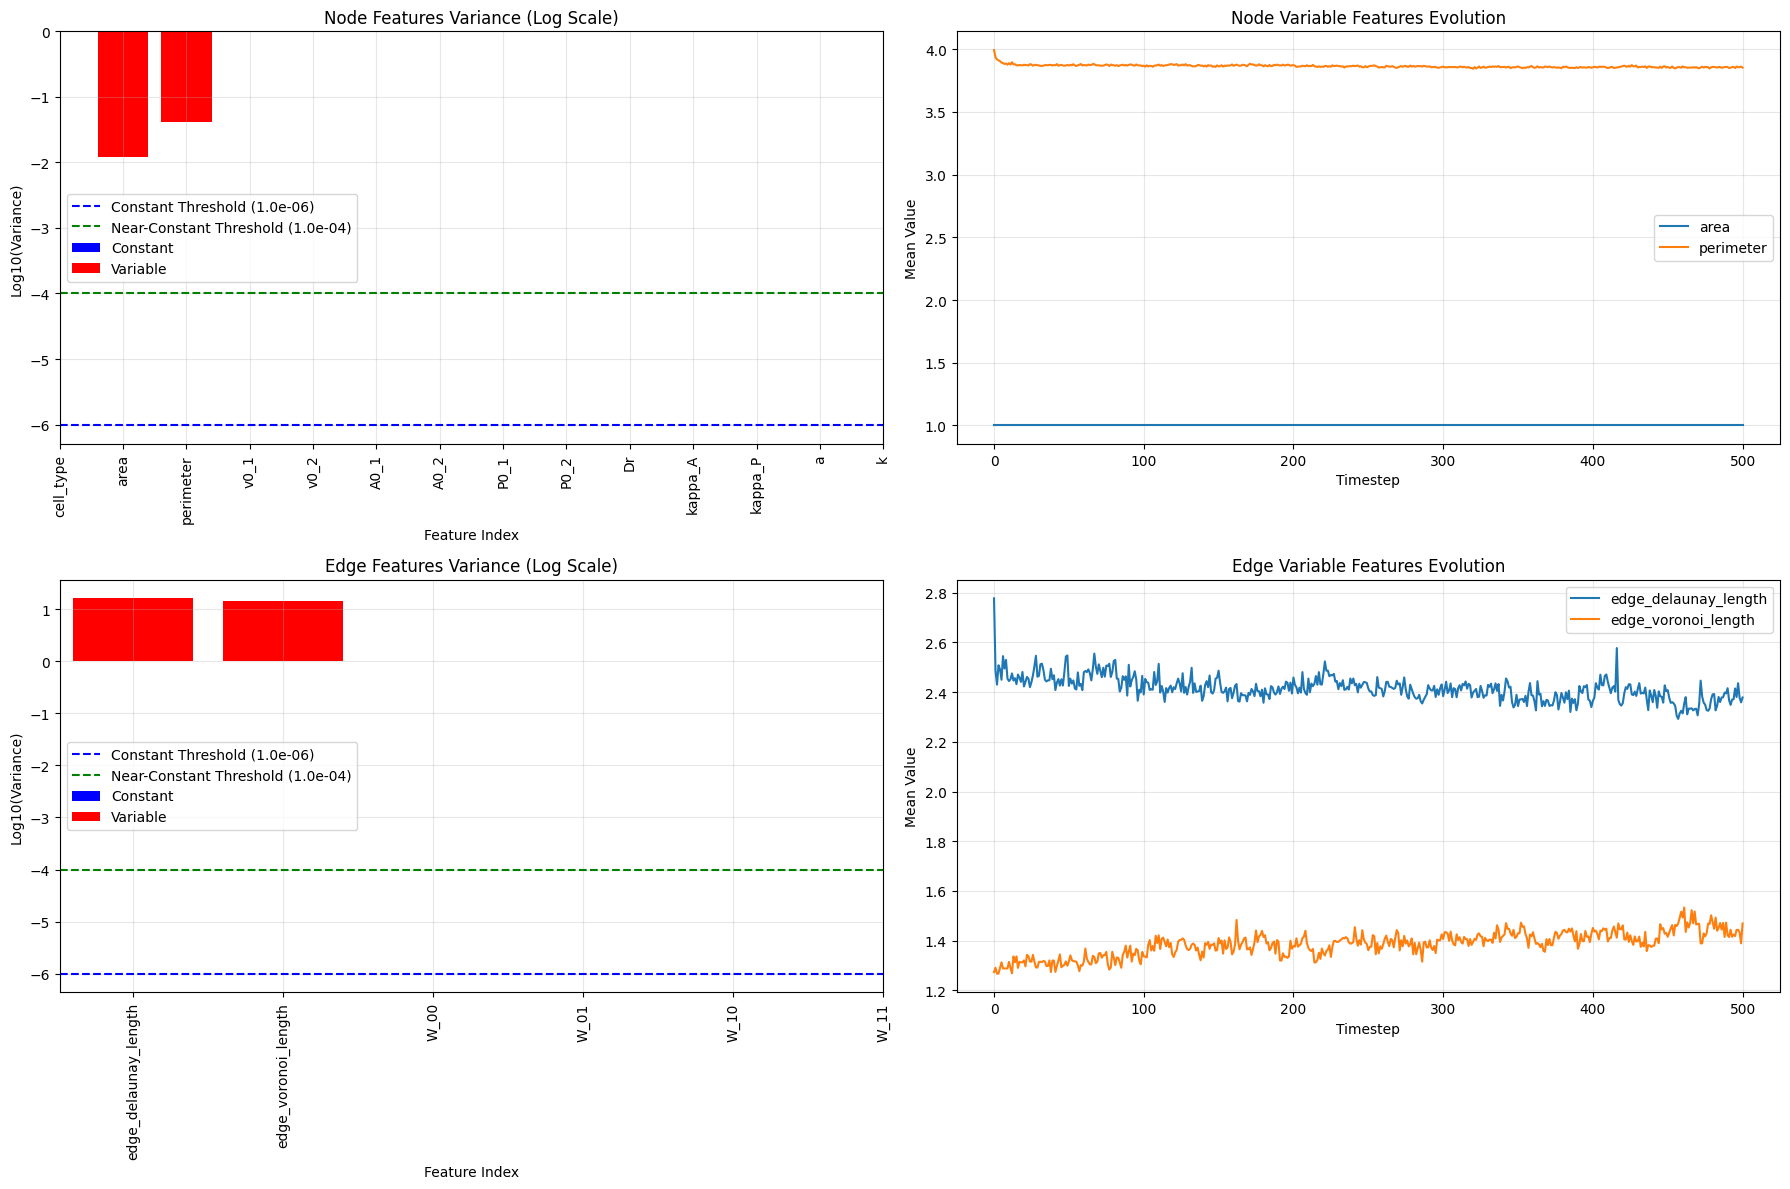

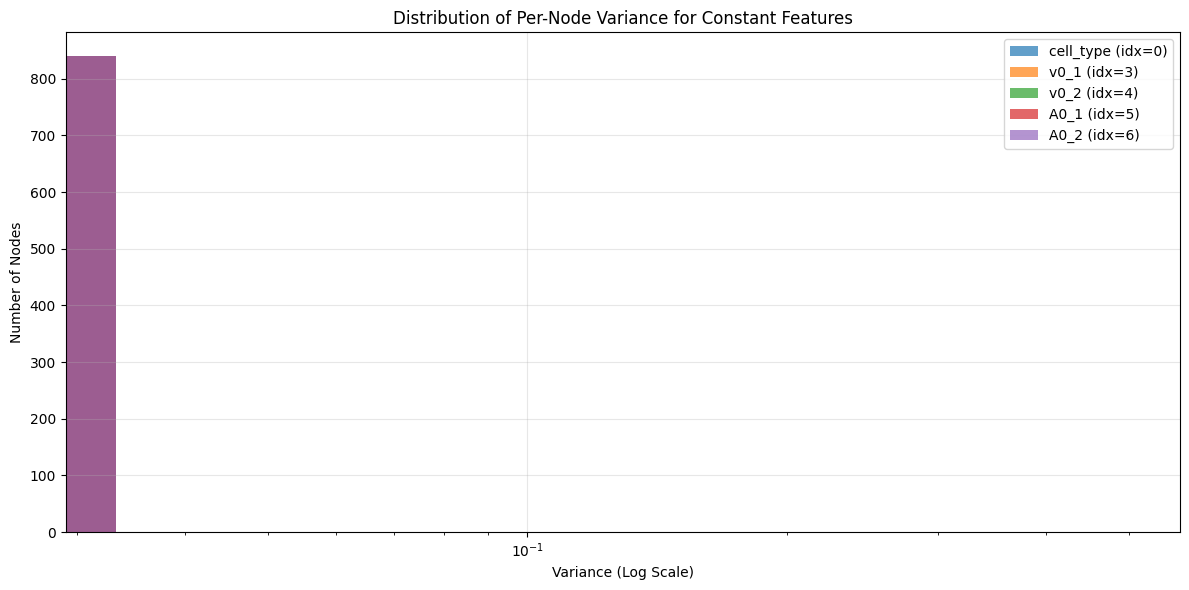

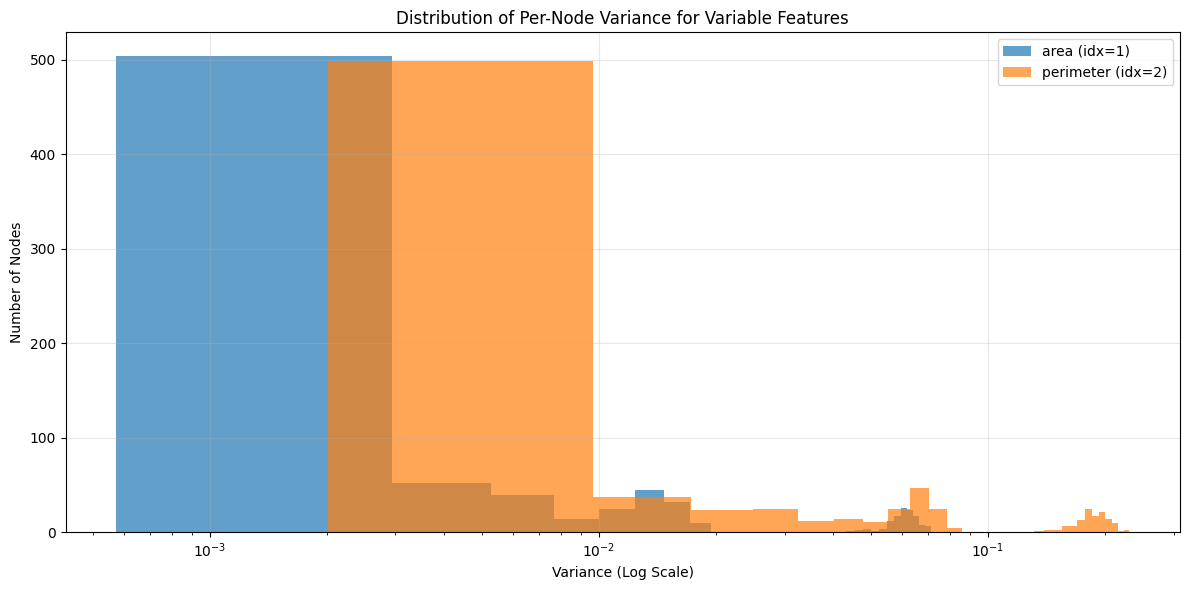


Results for simulation 1:

FEATURE ANALYSIS SUMMARY

NODE FEATURES:
  Total features: 14
  Constant features: 12 (85.7%)
  Near-constant features: 0 (0.0%)
  Variable features: 2 (14.3%)
  Constant feature indices: [0, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13] (cell_type, v0_1, v0_2, A0_1, A0_2, P0_1, P0_2, Dr, kappa_A, kappa_P, a, k)
  Variable feature indices: [1, 2] (area, perimeter)

  Detailed statistics for variable node features:
  ----------------------------------------
  Index  Name            Mean     Std      Min      Max      Range   
  ----------------------------------------
  1      area            1.000    0.110    0.731    1.256    0.525   
  2      perimeter       3.865    0.203    3.342    4.361    1.019   

EDGE FEATURES:
  Tracked 5414 consistent edges out of 18096 total edges
  Total features: 6
  Constant features: 4 (66.7%)
  Near-constant features: 0 (0.0%)
  Variable features: 2 (33.3%)
  Constant feature indices: [2, 3, 4, 5] (W_00, W_01, W_10, W_11)
  Variable 

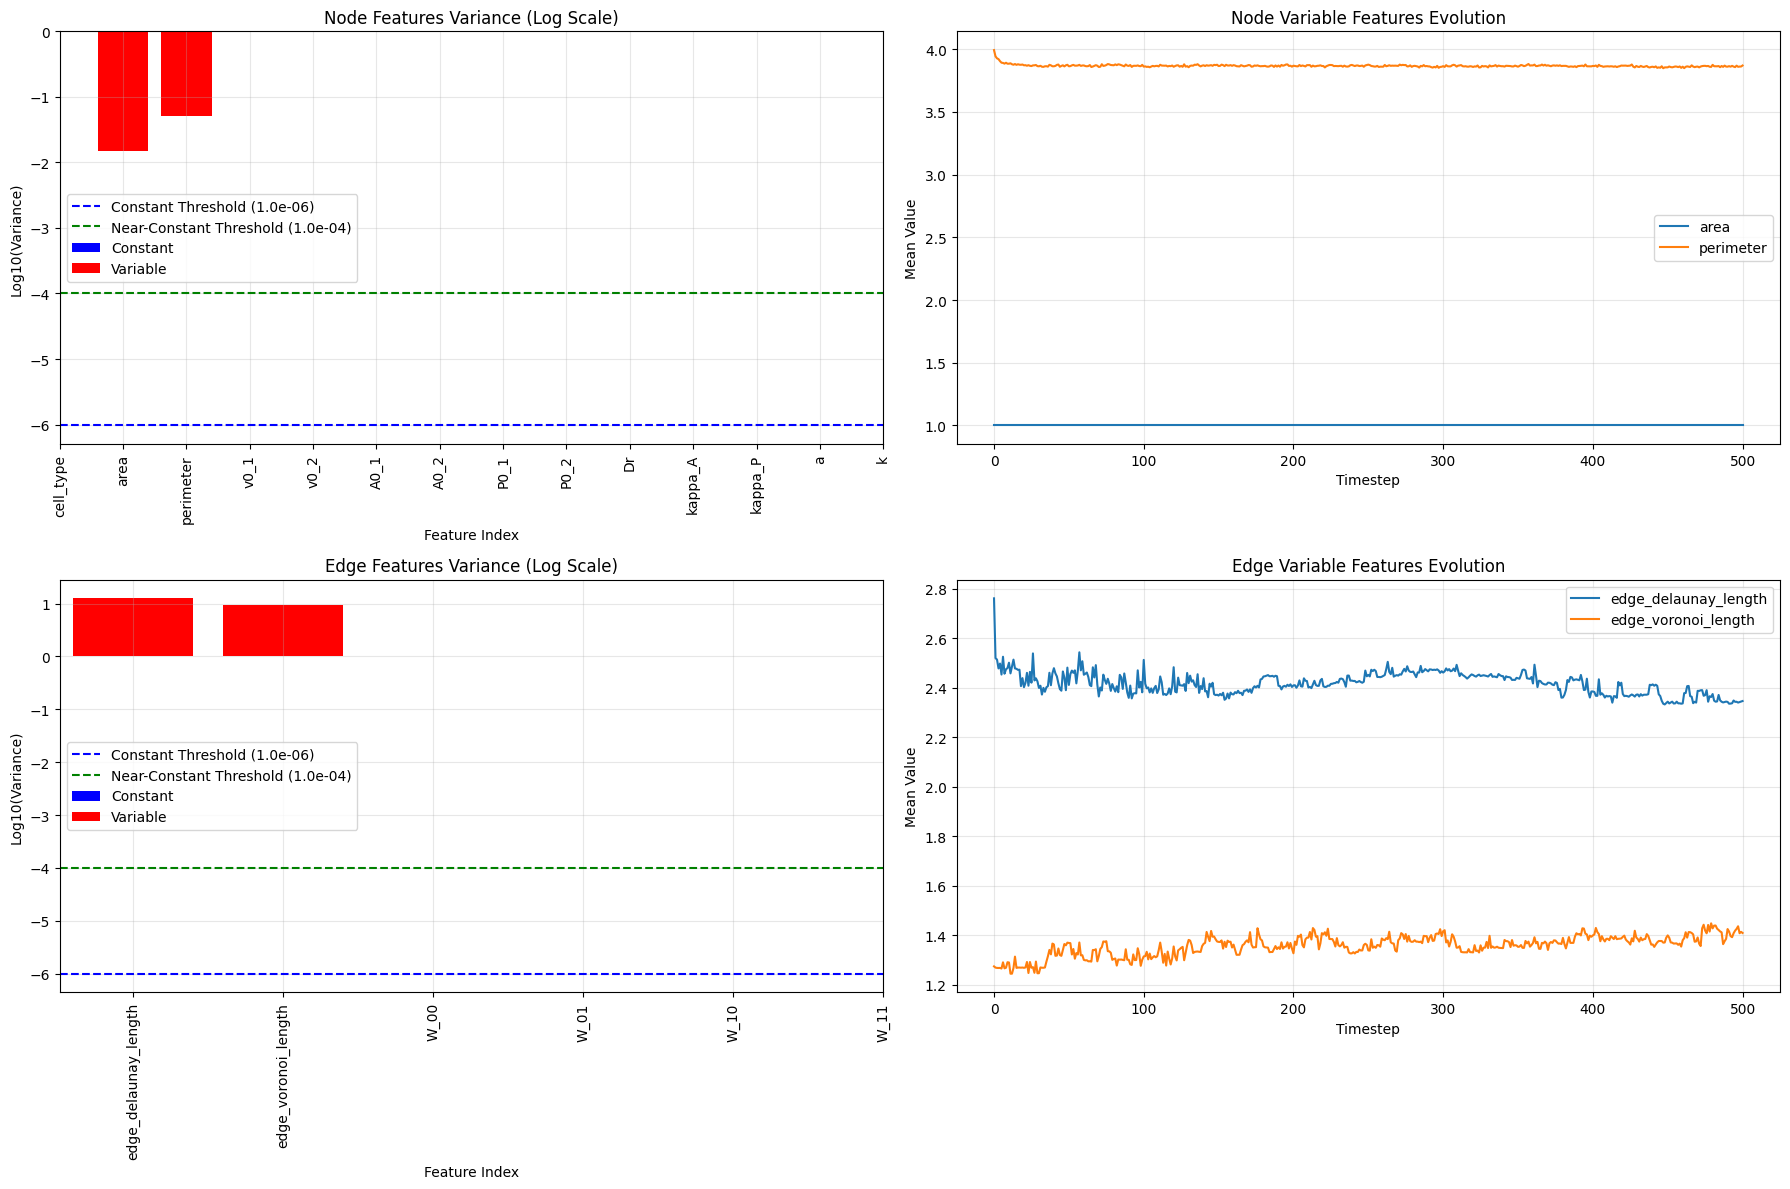

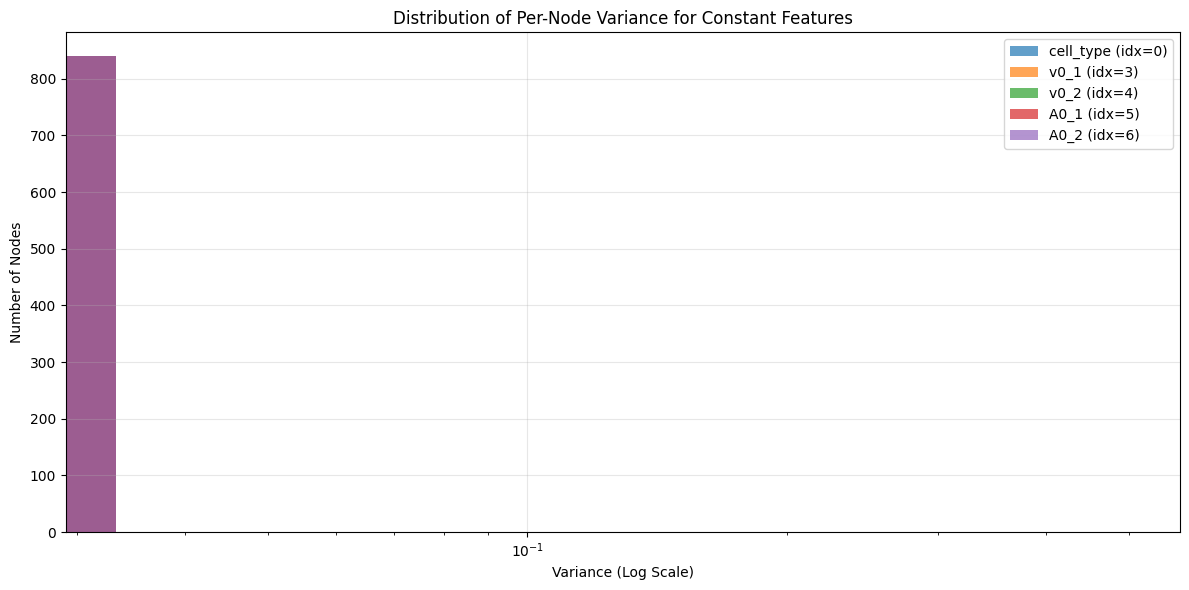

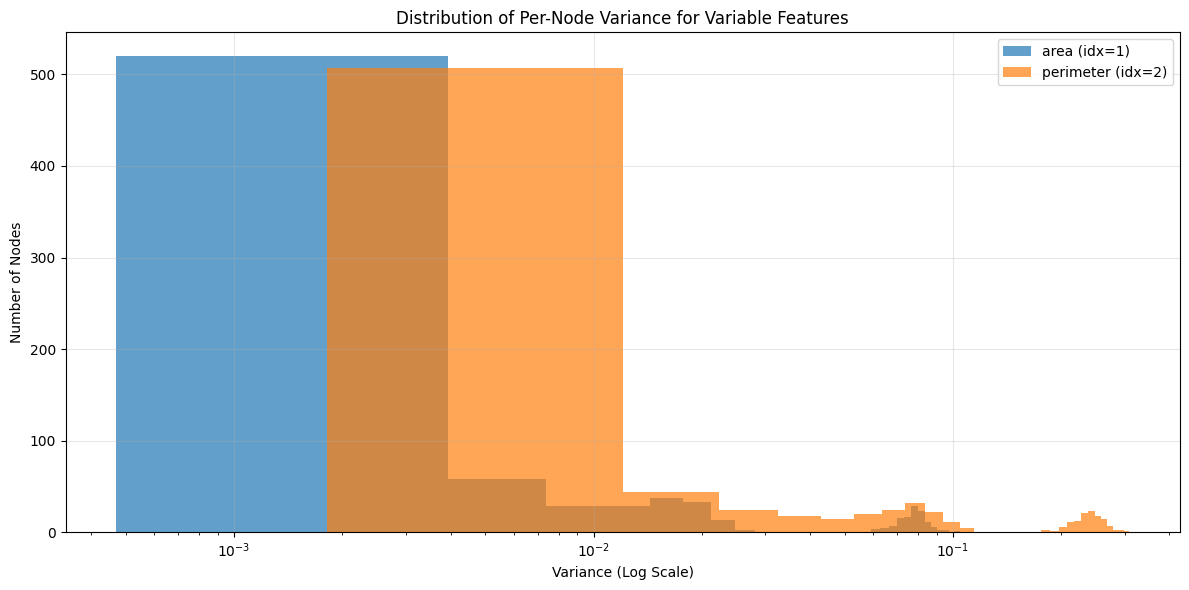


Results for simulation 2:

FEATURE ANALYSIS SUMMARY

NODE FEATURES:
  Total features: 14
  Constant features: 12 (85.7%)
  Near-constant features: 0 (0.0%)
  Variable features: 2 (14.3%)
  Constant feature indices: [0, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13] (cell_type, v0_1, v0_2, A0_1, A0_2, P0_1, P0_2, Dr, kappa_A, kappa_P, a, k)
  Variable feature indices: [1, 2] (area, perimeter)

  Detailed statistics for variable node features:
  ----------------------------------------
  Index  Name            Mean     Std      Min      Max      Range   
  ----------------------------------------
  1      area            1.000    0.123    0.678    1.290    0.612   
  2      perimeter       3.868    0.226    3.252    4.422    1.170   

EDGE FEATURES:
  Tracked 5214 consistent edges out of 20494 total edges
  Total features: 6
  Constant features: 4 (66.7%)
  Near-constant features: 0 (0.0%)
  Variable features: 2 (33.3%)
  Constant feature indices: [2, 3, 4, 5] (W_00, W_01, W_10, W_11)
  Variable 

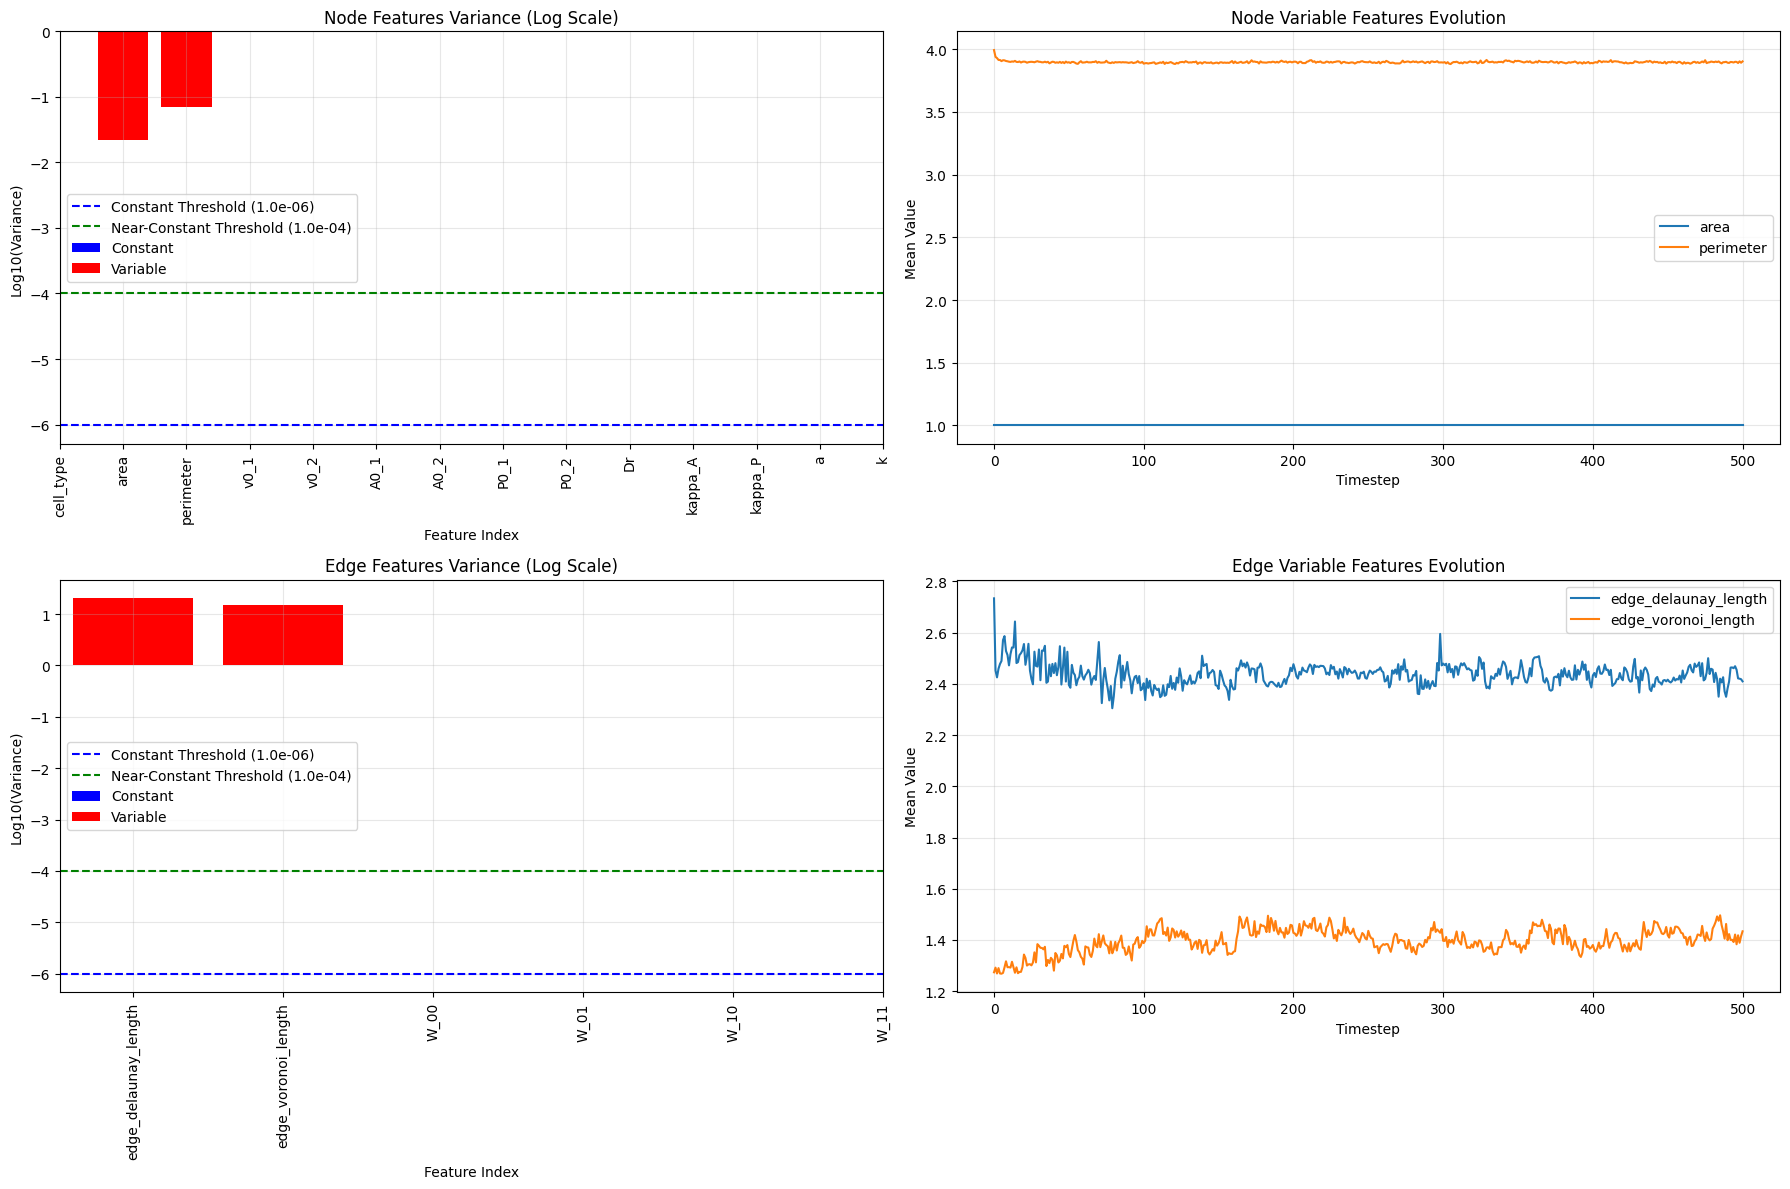

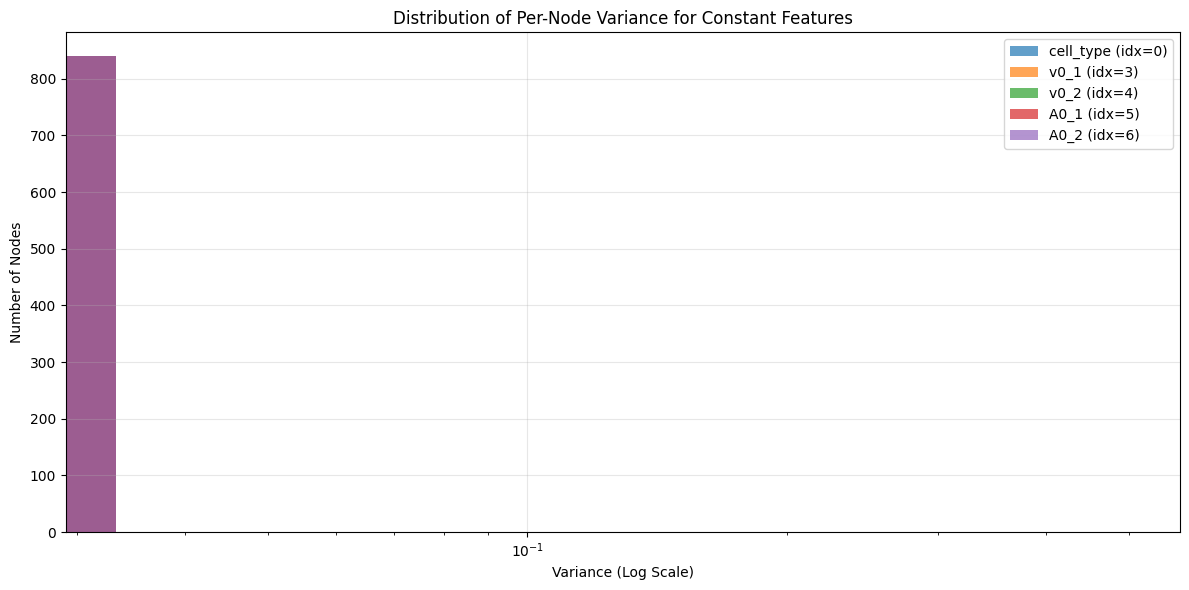

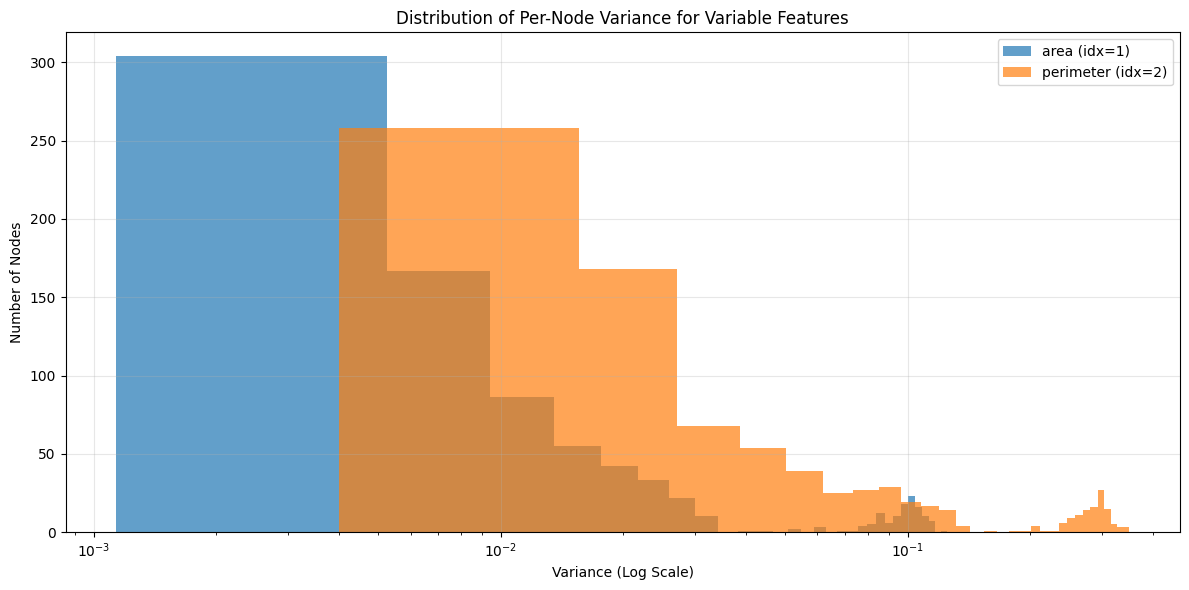


Results for simulation 3:

FEATURE ANALYSIS SUMMARY

NODE FEATURES:
  Total features: 14
  Constant features: 12 (85.7%)
  Near-constant features: 0 (0.0%)
  Variable features: 2 (14.3%)
  Constant feature indices: [0, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13] (cell_type, v0_1, v0_2, A0_1, A0_2, P0_1, P0_2, Dr, kappa_A, kappa_P, a, k)
  Variable feature indices: [1, 2] (area, perimeter)

  Detailed statistics for variable node features:
  ----------------------------------------
  Index  Name            Mean     Std      Min      Max      Range   
  ----------------------------------------
  1      area            1.000    0.147    0.543    1.433    0.890   
  2      perimeter       3.897    0.264    3.033    4.697    1.664   

EDGE FEATURES:
  Tracked 5976 consistent edges out of 34496 total edges
  Total features: 6
  Constant features: 4 (66.7%)
  Near-constant features: 0 (0.0%)
  Variable features: 2 (33.3%)
  Constant feature indices: [2, 3, 4, 5] (W_00, W_01, W_10, W_11)
  Variable 

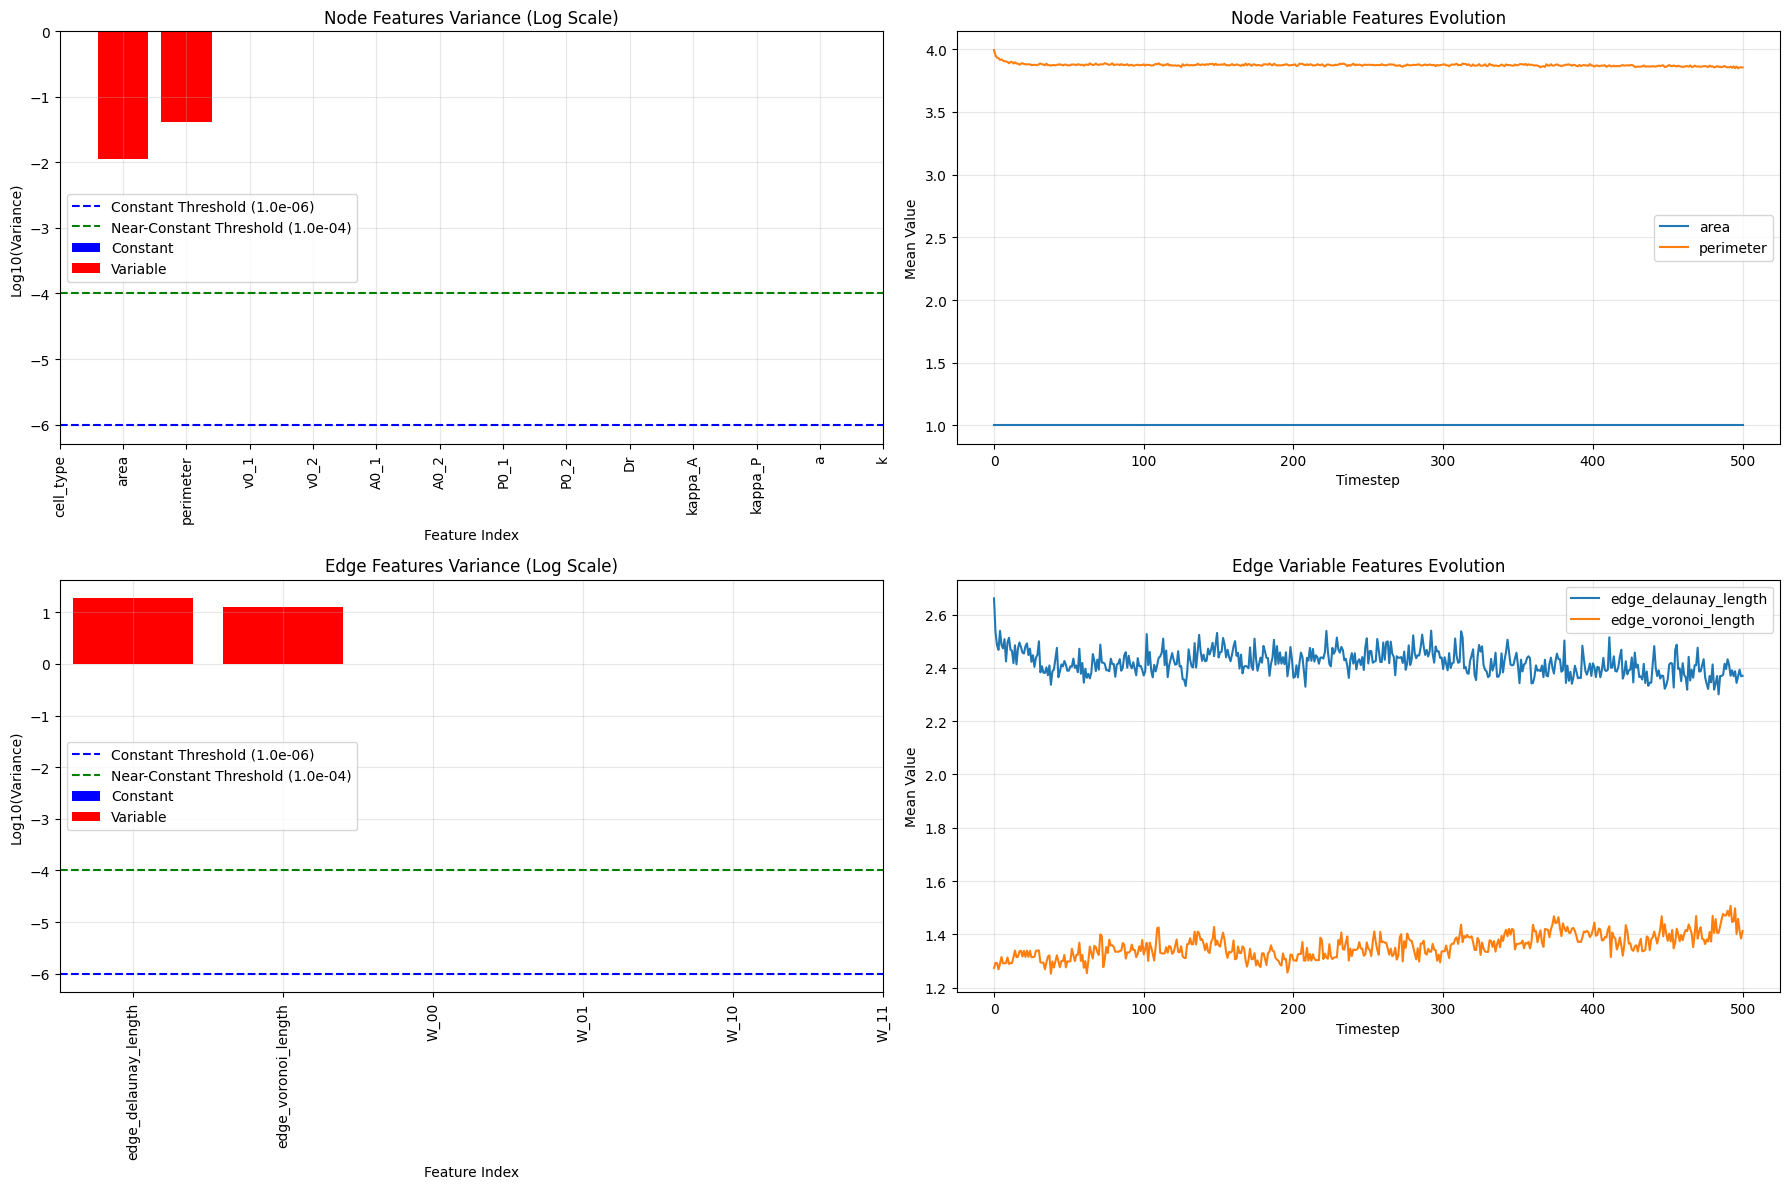

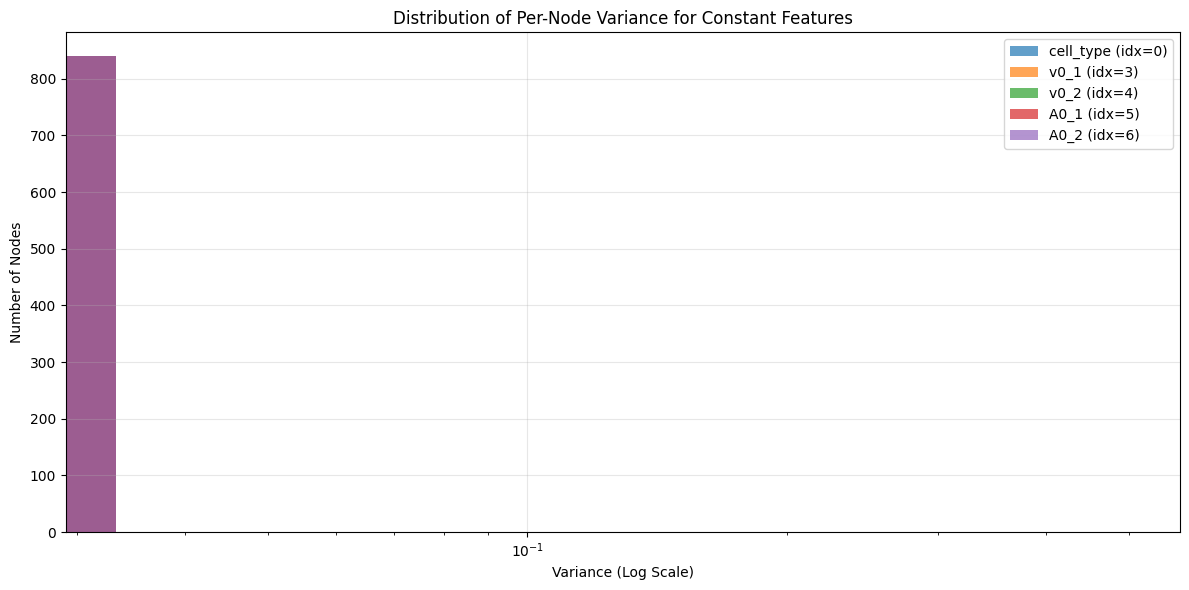

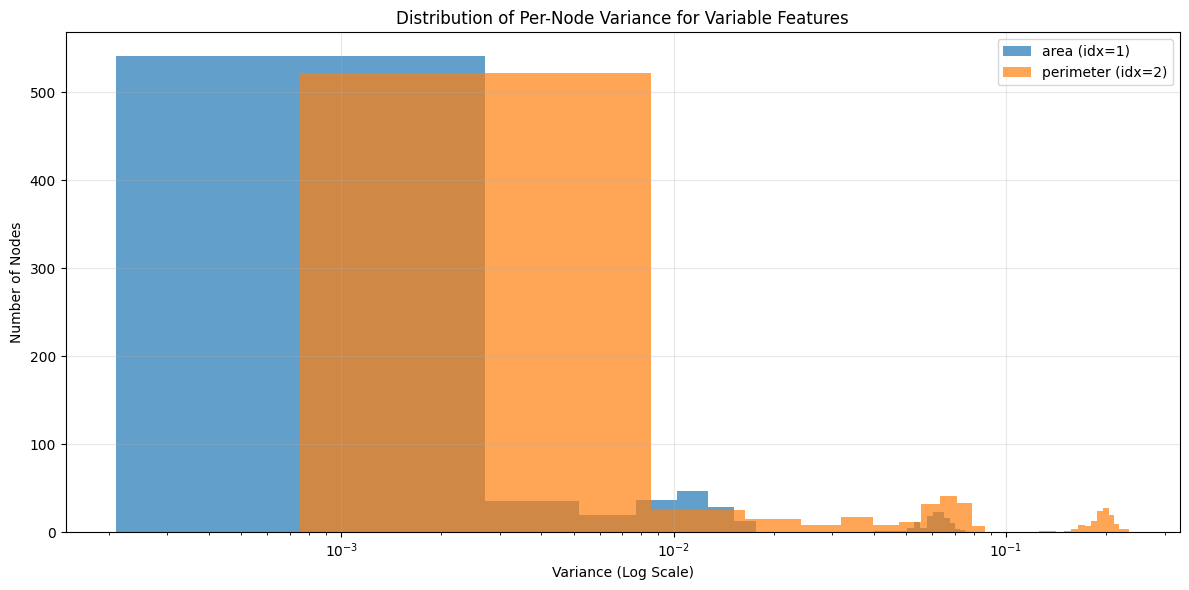


Results for simulation 4:

FEATURE ANALYSIS SUMMARY

NODE FEATURES:
  Total features: 14
  Constant features: 12 (85.7%)
  Near-constant features: 0 (0.0%)
  Variable features: 2 (14.3%)
  Constant feature indices: [0, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13] (cell_type, v0_1, v0_2, A0_1, A0_2, P0_1, P0_2, Dr, kappa_A, kappa_P, a, k)
  Variable feature indices: [1, 2] (area, perimeter)

  Detailed statistics for variable node features:
  ----------------------------------------
  Index  Name            Mean     Std      Min      Max      Range   
  ----------------------------------------
  1      area            1.000    0.106    0.765    1.226    0.461   
  2      perimeter       3.874    0.204    3.385    4.348    0.963   

EDGE FEATURES:
  Tracked 5150 consistent edges out of 16050 total edges
  Total features: 6
  Constant features: 4 (66.7%)
  Near-constant features: 0 (0.0%)
  Variable features: 2 (33.3%)
  Constant feature indices: [2, 3, 4, 5] (W_00, W_01, W_10, W_11)
  Variable 

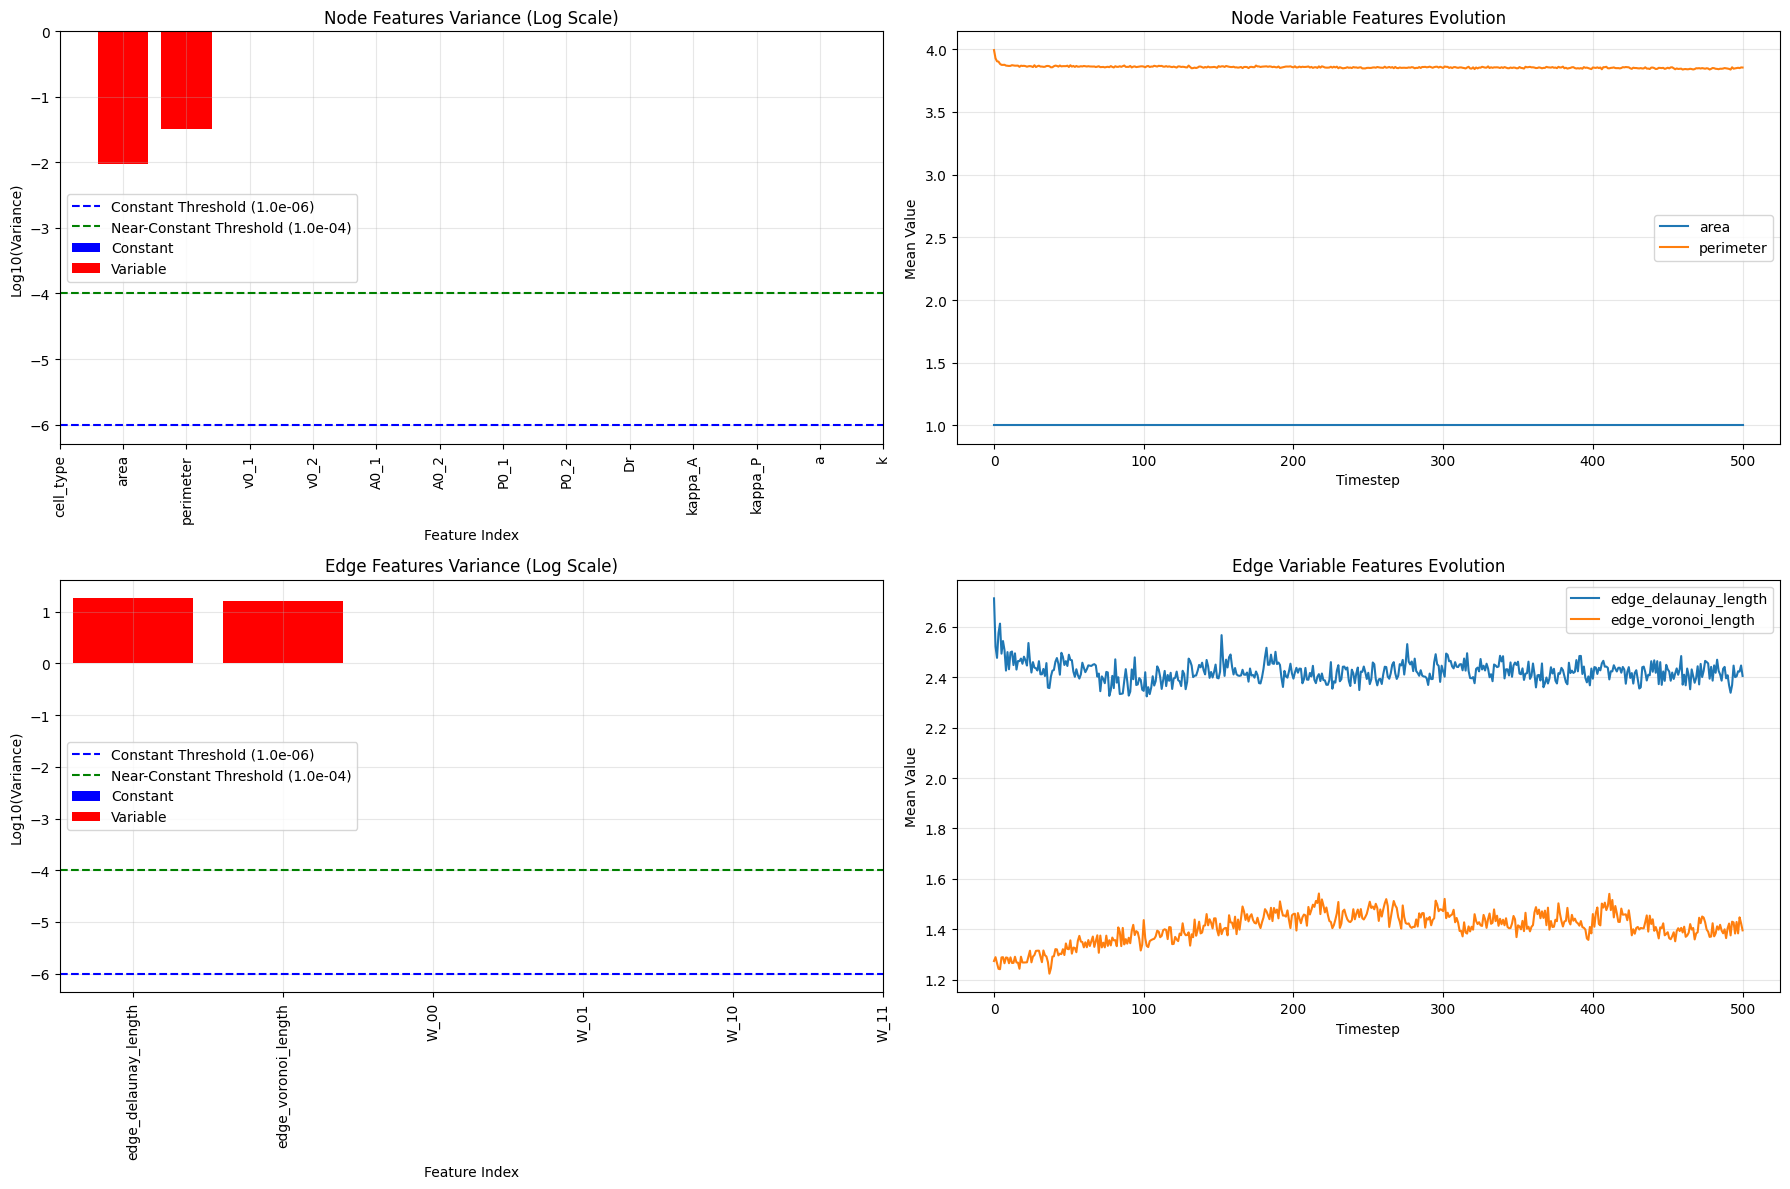

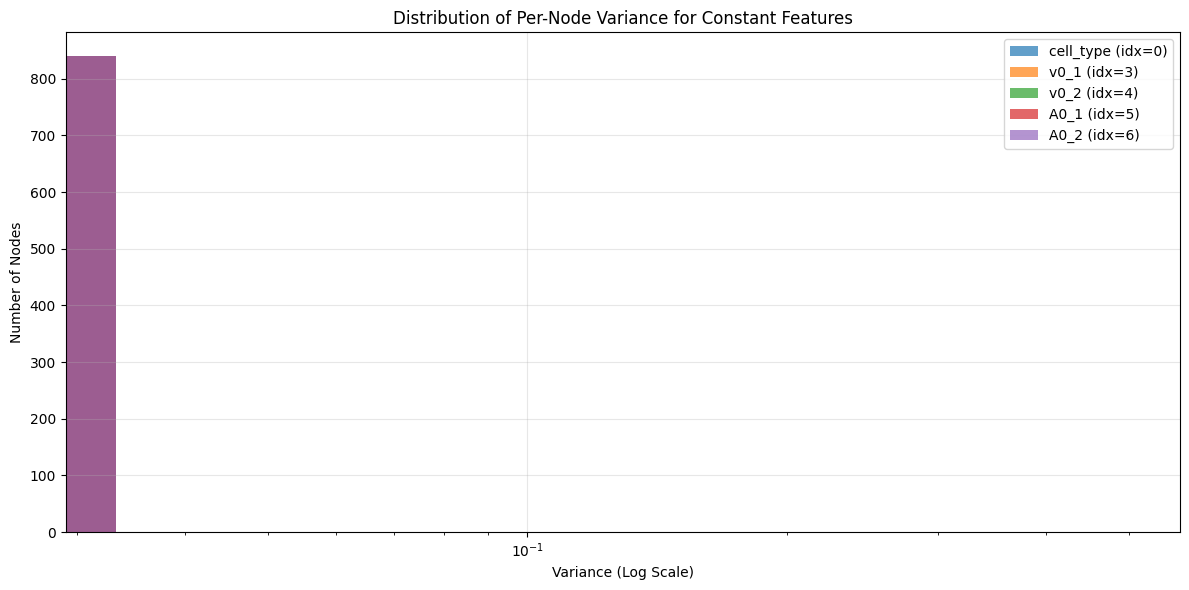

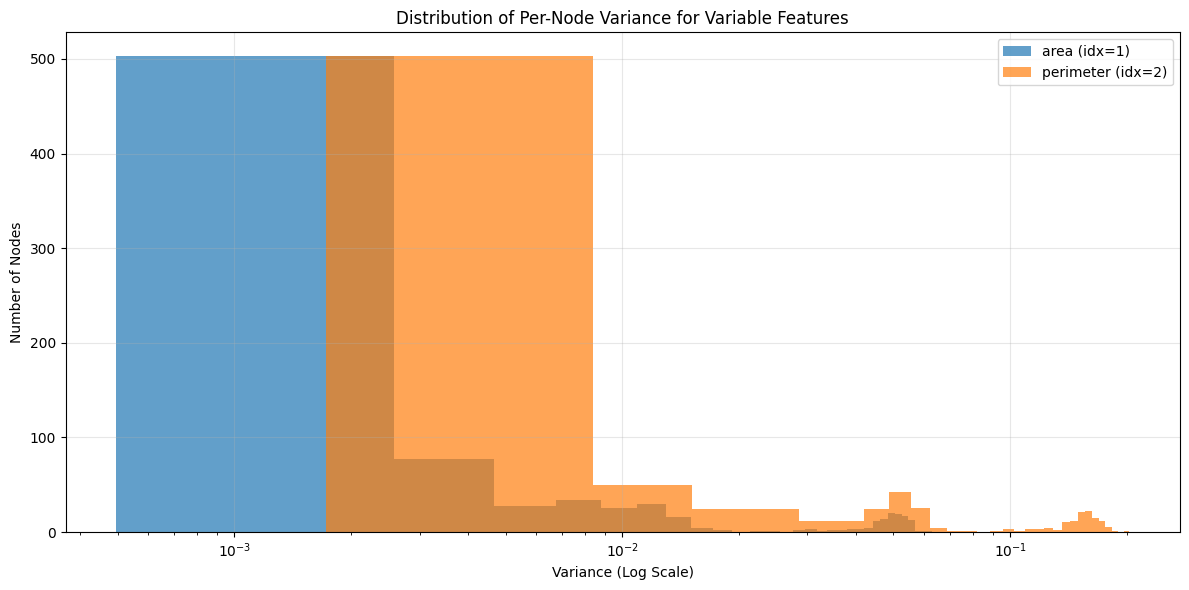


Results for simulation 5:

FEATURE ANALYSIS SUMMARY

NODE FEATURES:
  Total features: 14
  Constant features: 12 (85.7%)
  Near-constant features: 0 (0.0%)
  Variable features: 2 (14.3%)
  Constant feature indices: [0, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13] (cell_type, v0_1, v0_2, A0_1, A0_2, P0_1, P0_2, Dr, kappa_A, kappa_P, a, k)
  Variable feature indices: [1, 2] (area, perimeter)

  Detailed statistics for variable node features:
  ----------------------------------------
  Index  Name            Mean     Std      Min      Max      Range   
  ----------------------------------------
  1      area            1.000    0.097    0.760    1.221    0.461   
  2      perimeter       3.857    0.180    3.395    4.290    0.894   

EDGE FEATURES:
  Tracked 5224 consistent edges out of 16914 total edges
  Total features: 6
  Constant features: 4 (66.7%)
  Near-constant features: 0 (0.0%)
  Variable features: 2 (33.3%)
  Constant feature indices: [2, 3, 4, 5] (W_00, W_01, W_10, W_11)
  Variable 

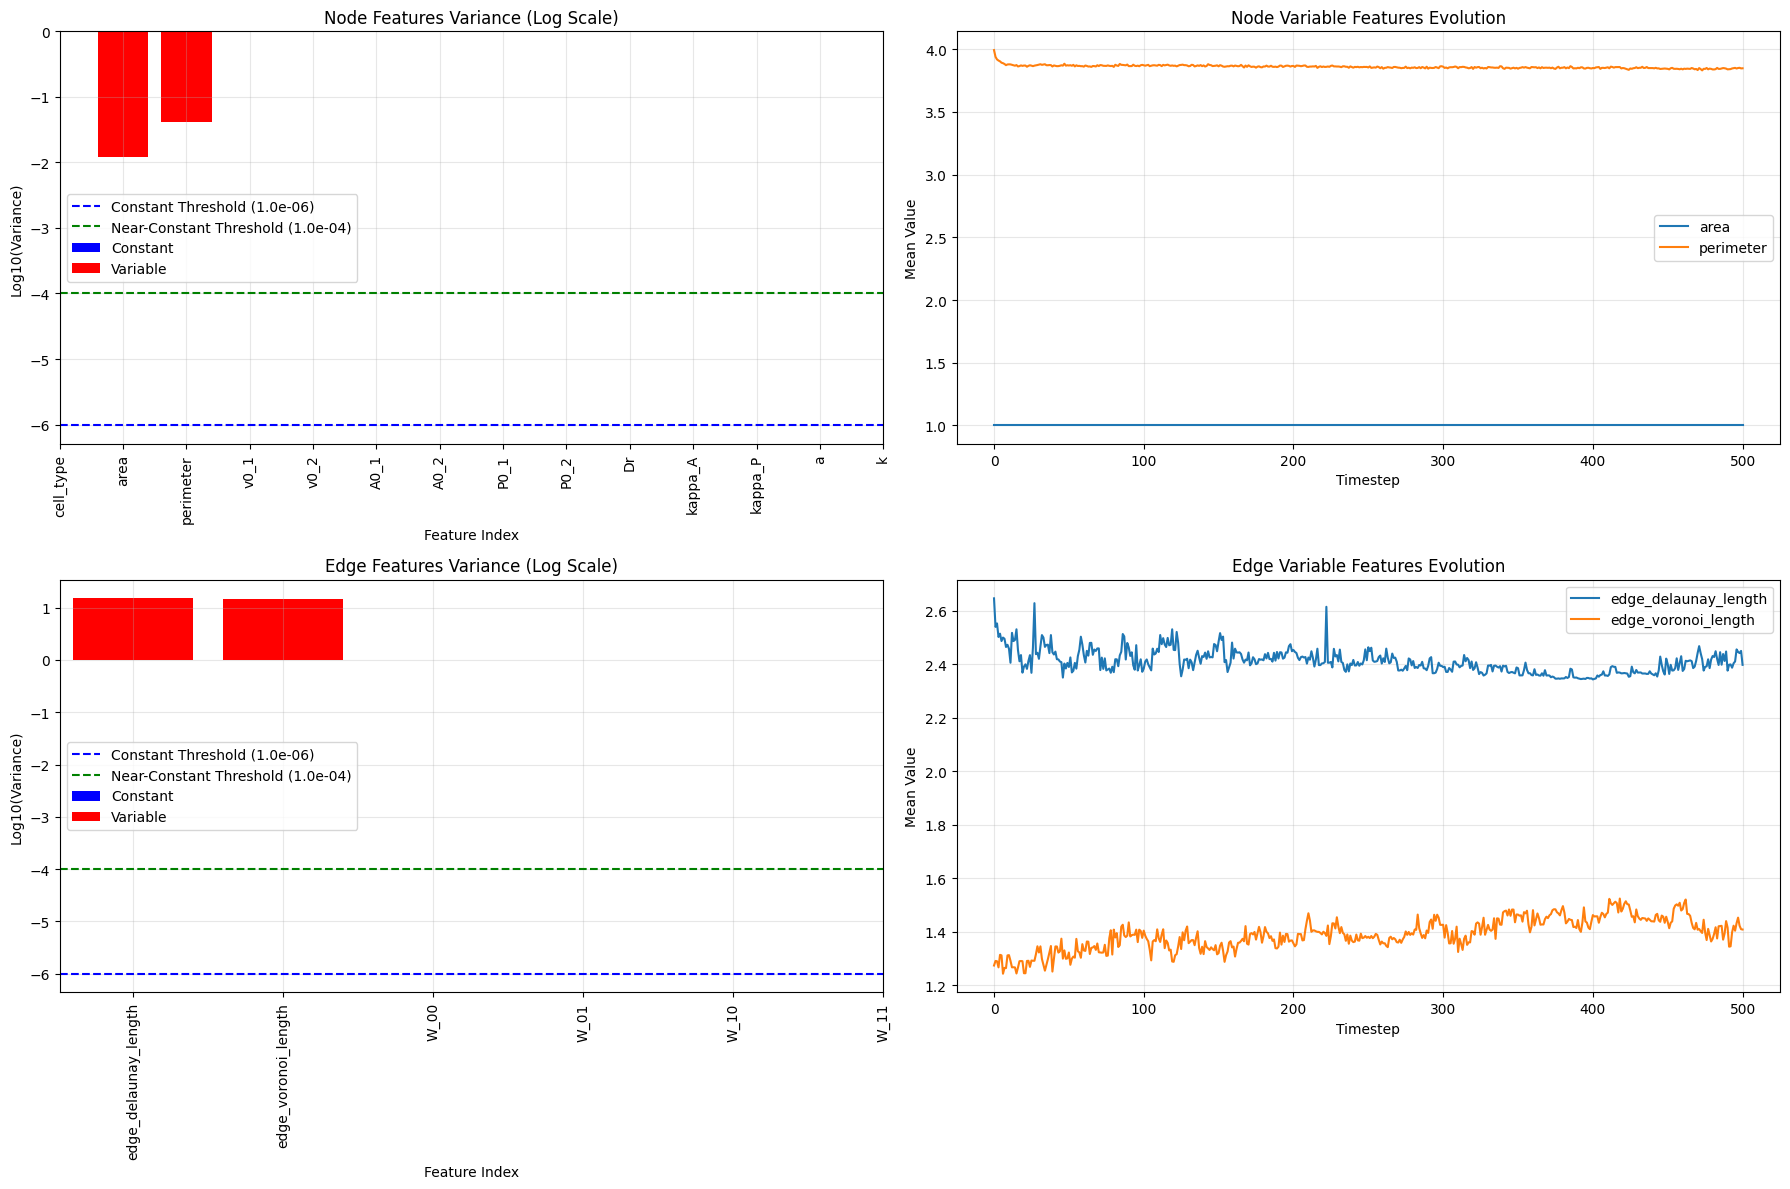

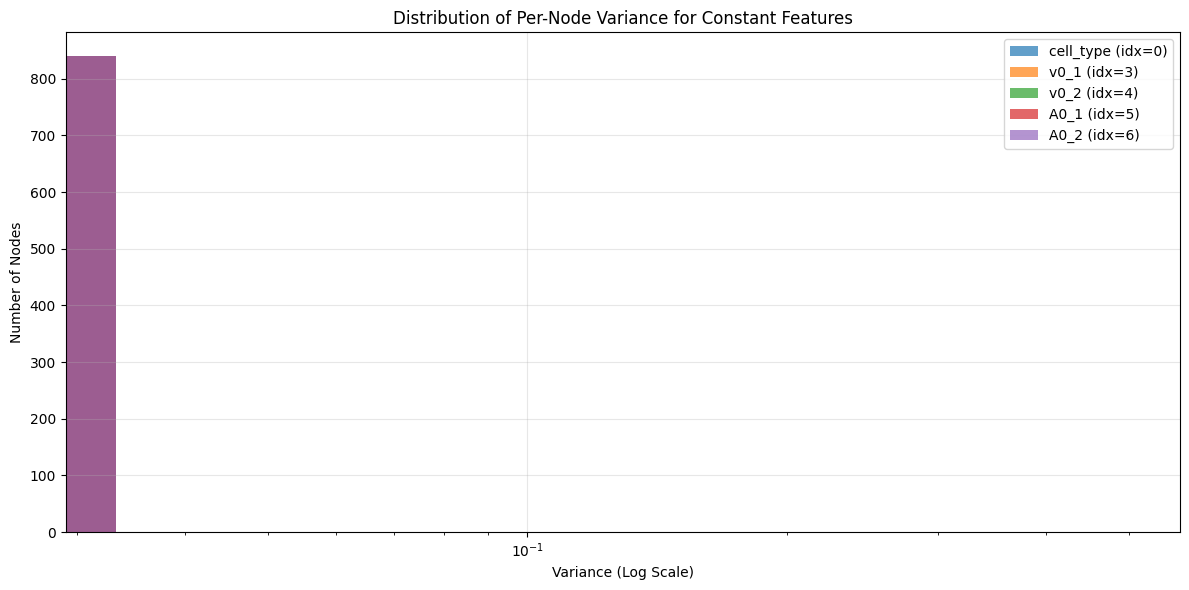

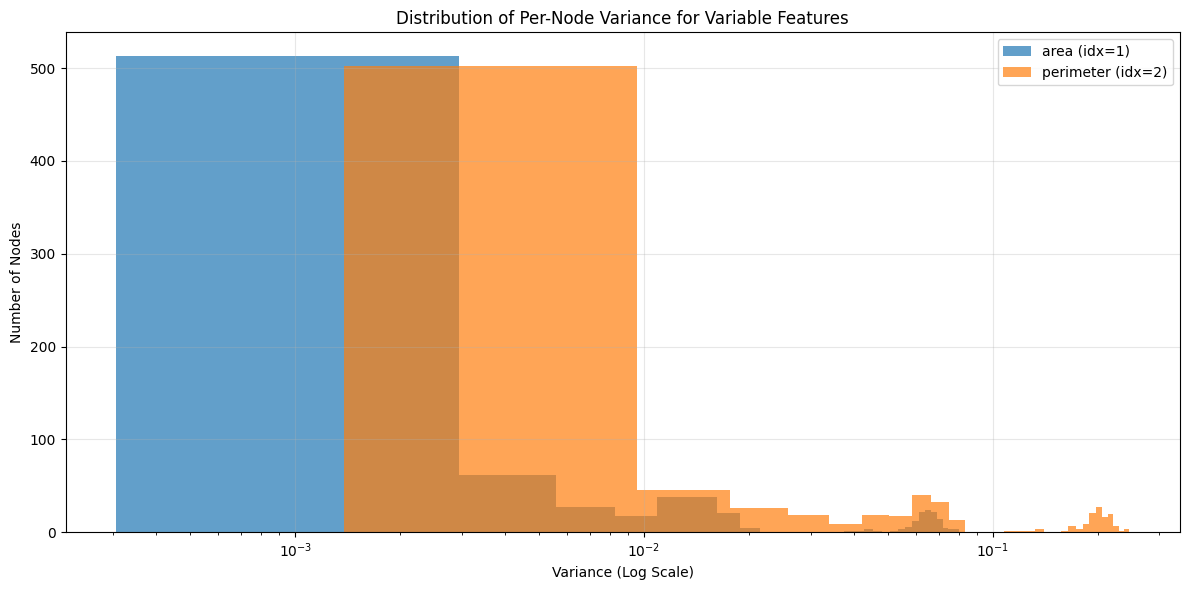


Results for simulation 6:

FEATURE ANALYSIS SUMMARY

NODE FEATURES:
  Total features: 14
  Constant features: 12 (85.7%)
  Near-constant features: 0 (0.0%)
  Variable features: 2 (14.3%)
  Constant feature indices: [0, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13] (cell_type, v0_1, v0_2, A0_1, A0_2, P0_1, P0_2, Dr, kappa_A, kappa_P, a, k)
  Variable feature indices: [1, 2] (area, perimeter)

  Detailed statistics for variable node features:
  ----------------------------------------
  Index  Name            Mean     Std      Min      Max      Range   
  ----------------------------------------
  1      area            1.000    0.111    0.724    1.257    0.533   
  2      perimeter       3.860    0.205    3.330    4.359    1.029   

EDGE FEATURES:
  Tracked 5214 consistent edges out of 17372 total edges
  Total features: 6
  Constant features: 4 (66.7%)
  Near-constant features: 0 (0.0%)
  Variable features: 2 (33.3%)
  Constant feature indices: [2, 3, 4, 5] (W_00, W_01, W_10, W_11)
  Variable 

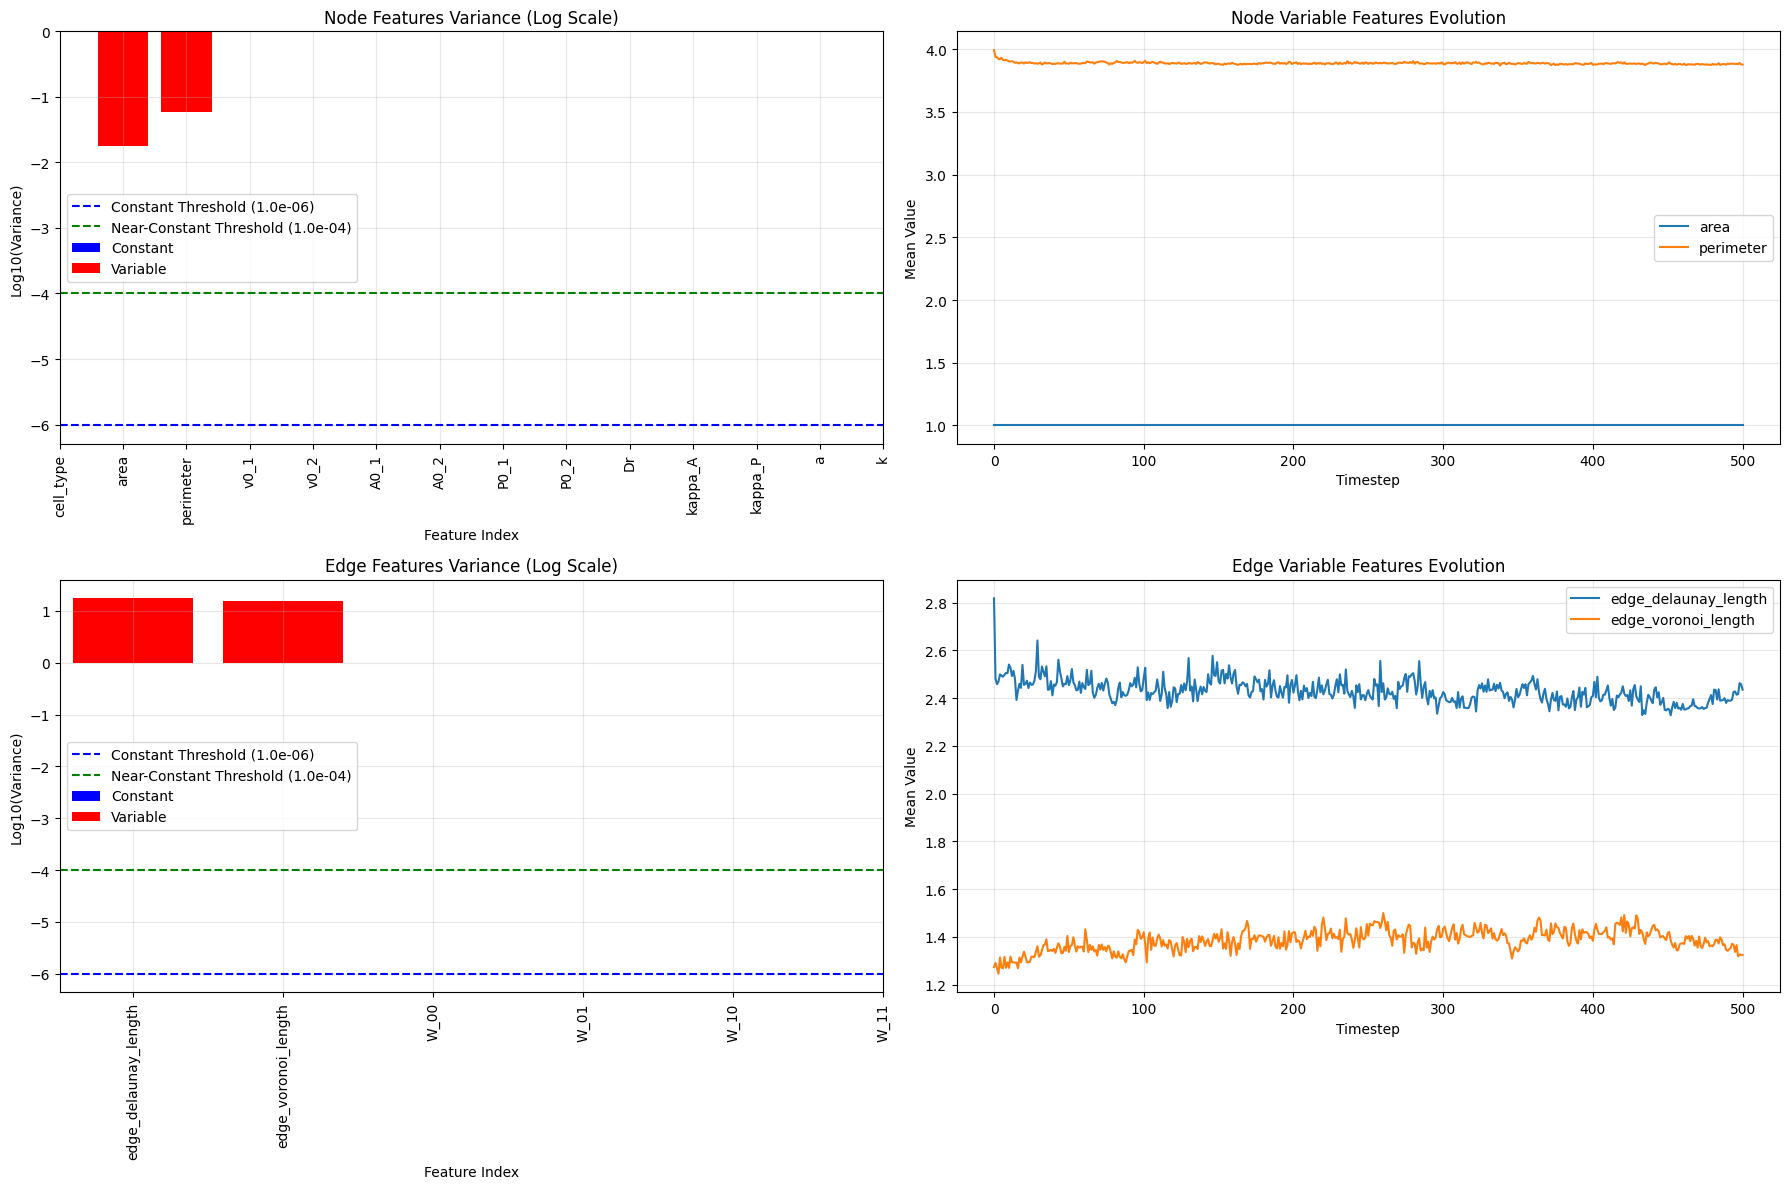

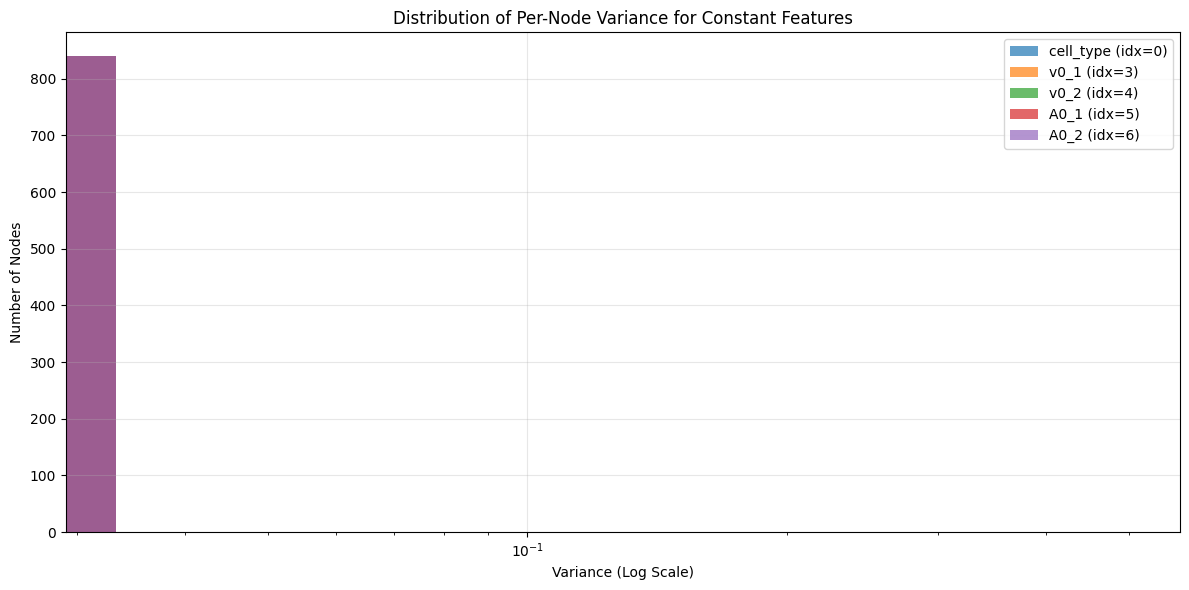

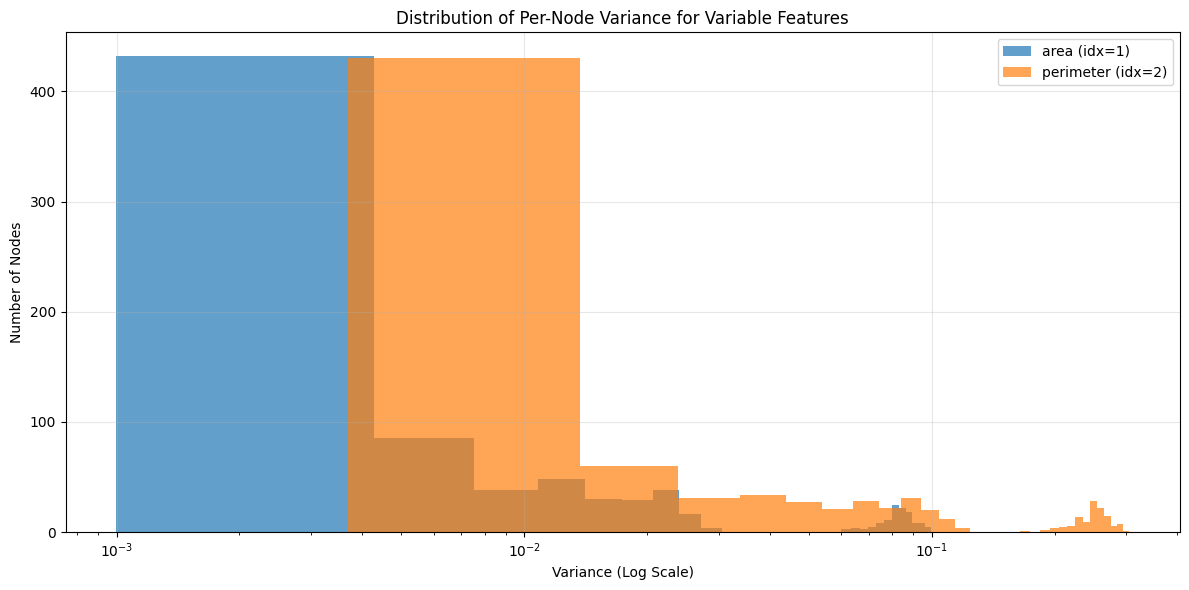


Results for simulation 7:

FEATURE ANALYSIS SUMMARY

NODE FEATURES:
  Total features: 14
  Constant features: 12 (85.7%)
  Near-constant features: 0 (0.0%)
  Variable features: 2 (14.3%)
  Constant feature indices: [0, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13] (cell_type, v0_1, v0_2, A0_1, A0_2, P0_1, P0_2, Dr, kappa_A, kappa_P, a, k)
  Variable feature indices: [1, 2] (area, perimeter)

  Detailed statistics for variable node features:
  ----------------------------------------
  Index  Name            Mean     Std      Min      Max      Range   
  ----------------------------------------
  1      area            1.000    0.132    0.631    1.345    0.713   
  2      perimeter       3.889    0.242    3.191    4.530    1.338   

EDGE FEATURES:
  Tracked 5666 consistent edges out of 23862 total edges
  Total features: 6
  Constant features: 4 (66.7%)
  Near-constant features: 0 (0.0%)
  Variable features: 2 (33.3%)
  Constant feature indices: [2, 3, 4, 5] (W_00, W_01, W_10, W_11)
  Variable 

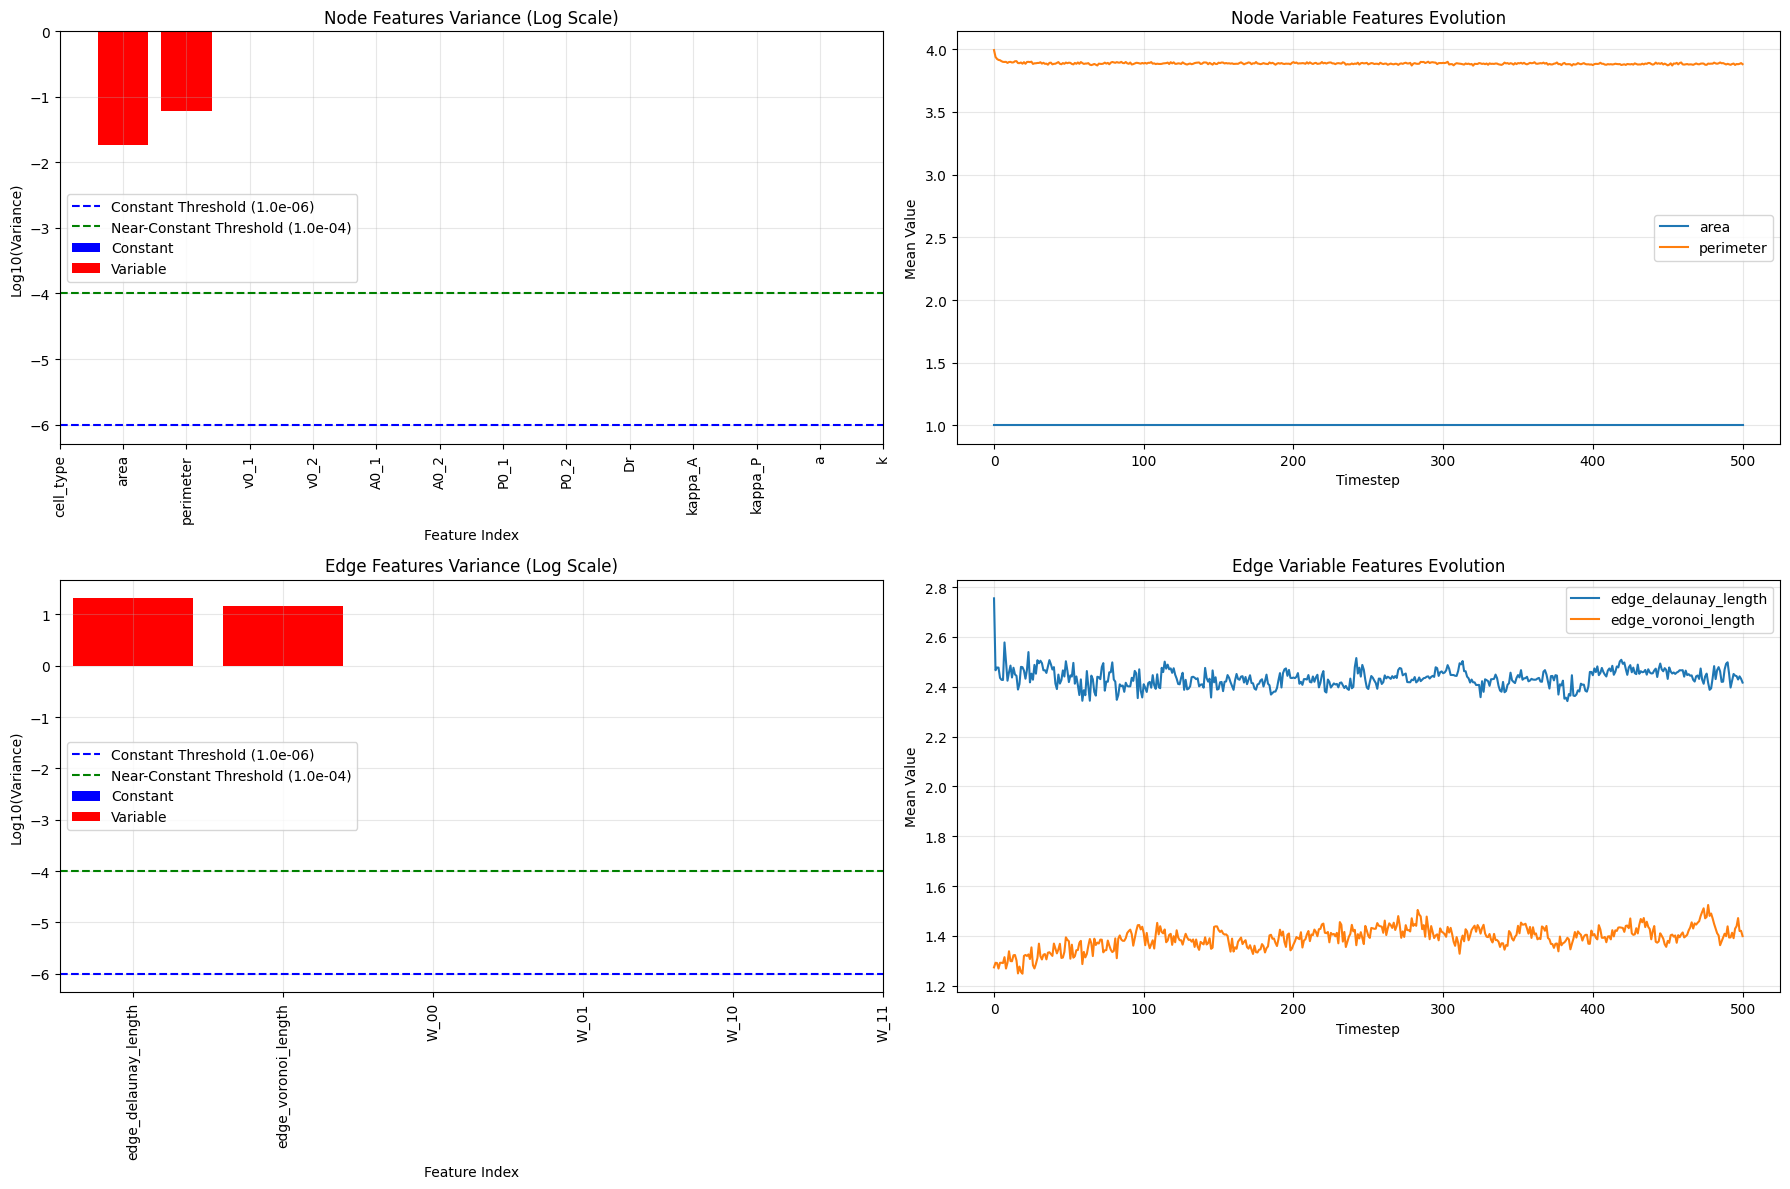

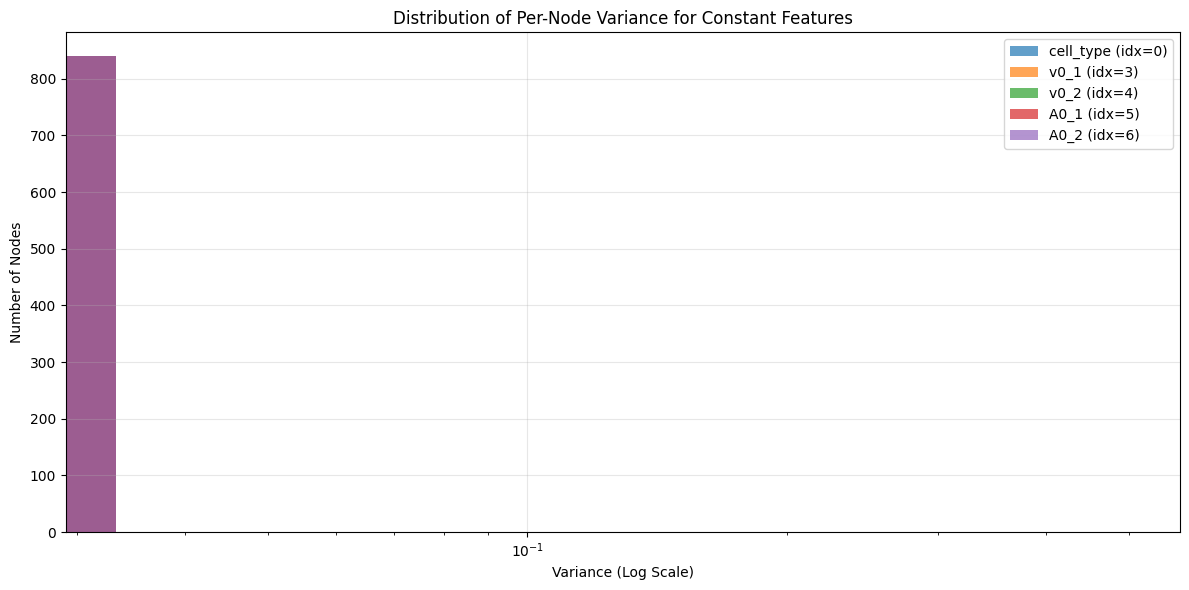

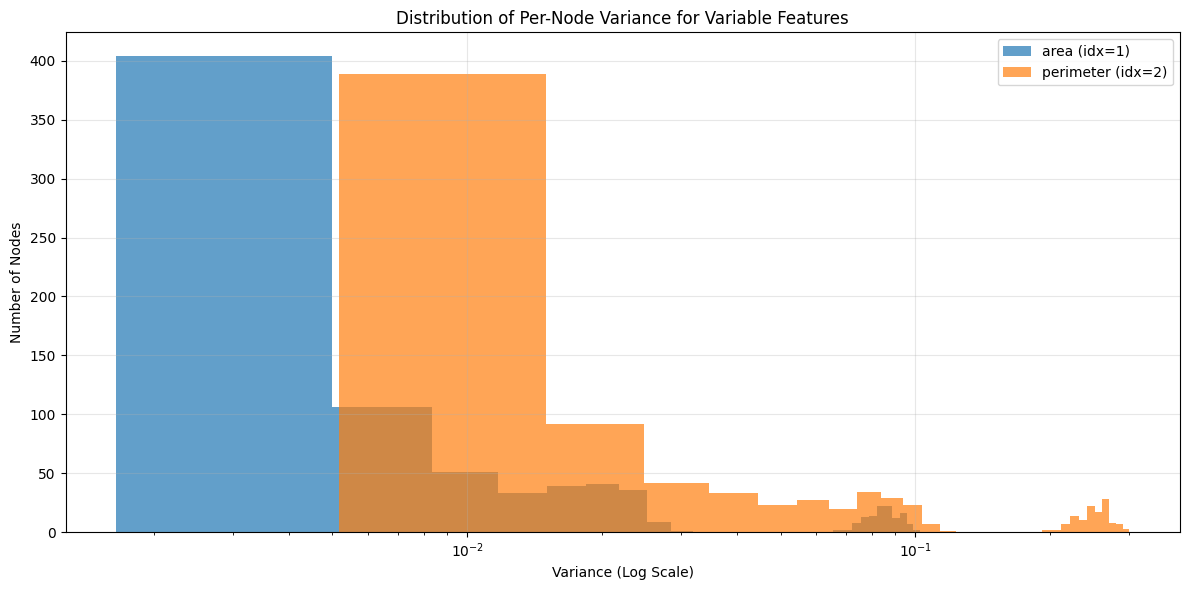


Results for simulation 8:

FEATURE ANALYSIS SUMMARY

NODE FEATURES:
  Total features: 14
  Constant features: 12 (85.7%)
  Near-constant features: 0 (0.0%)
  Variable features: 2 (14.3%)
  Constant feature indices: [0, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13] (cell_type, v0_1, v0_2, A0_1, A0_2, P0_1, P0_2, Dr, kappa_A, kappa_P, a, k)
  Variable feature indices: [1, 2] (area, perimeter)

  Detailed statistics for variable node features:
  ----------------------------------------
  Index  Name            Mean     Std      Min      Max      Range   
  ----------------------------------------
  1      area            1.000    0.136    0.614    1.369    0.755   
  2      perimeter       3.887    0.245    3.156    4.563    1.408   

EDGE FEATURES:
  Tracked 5854 consistent edges out of 28070 total edges
  Total features: 6
  Constant features: 4 (66.7%)
  Near-constant features: 0 (0.0%)
  Variable features: 2 (33.3%)
  Constant feature indices: [2, 3, 4, 5] (W_00, W_01, W_10, W_11)
  Variable 

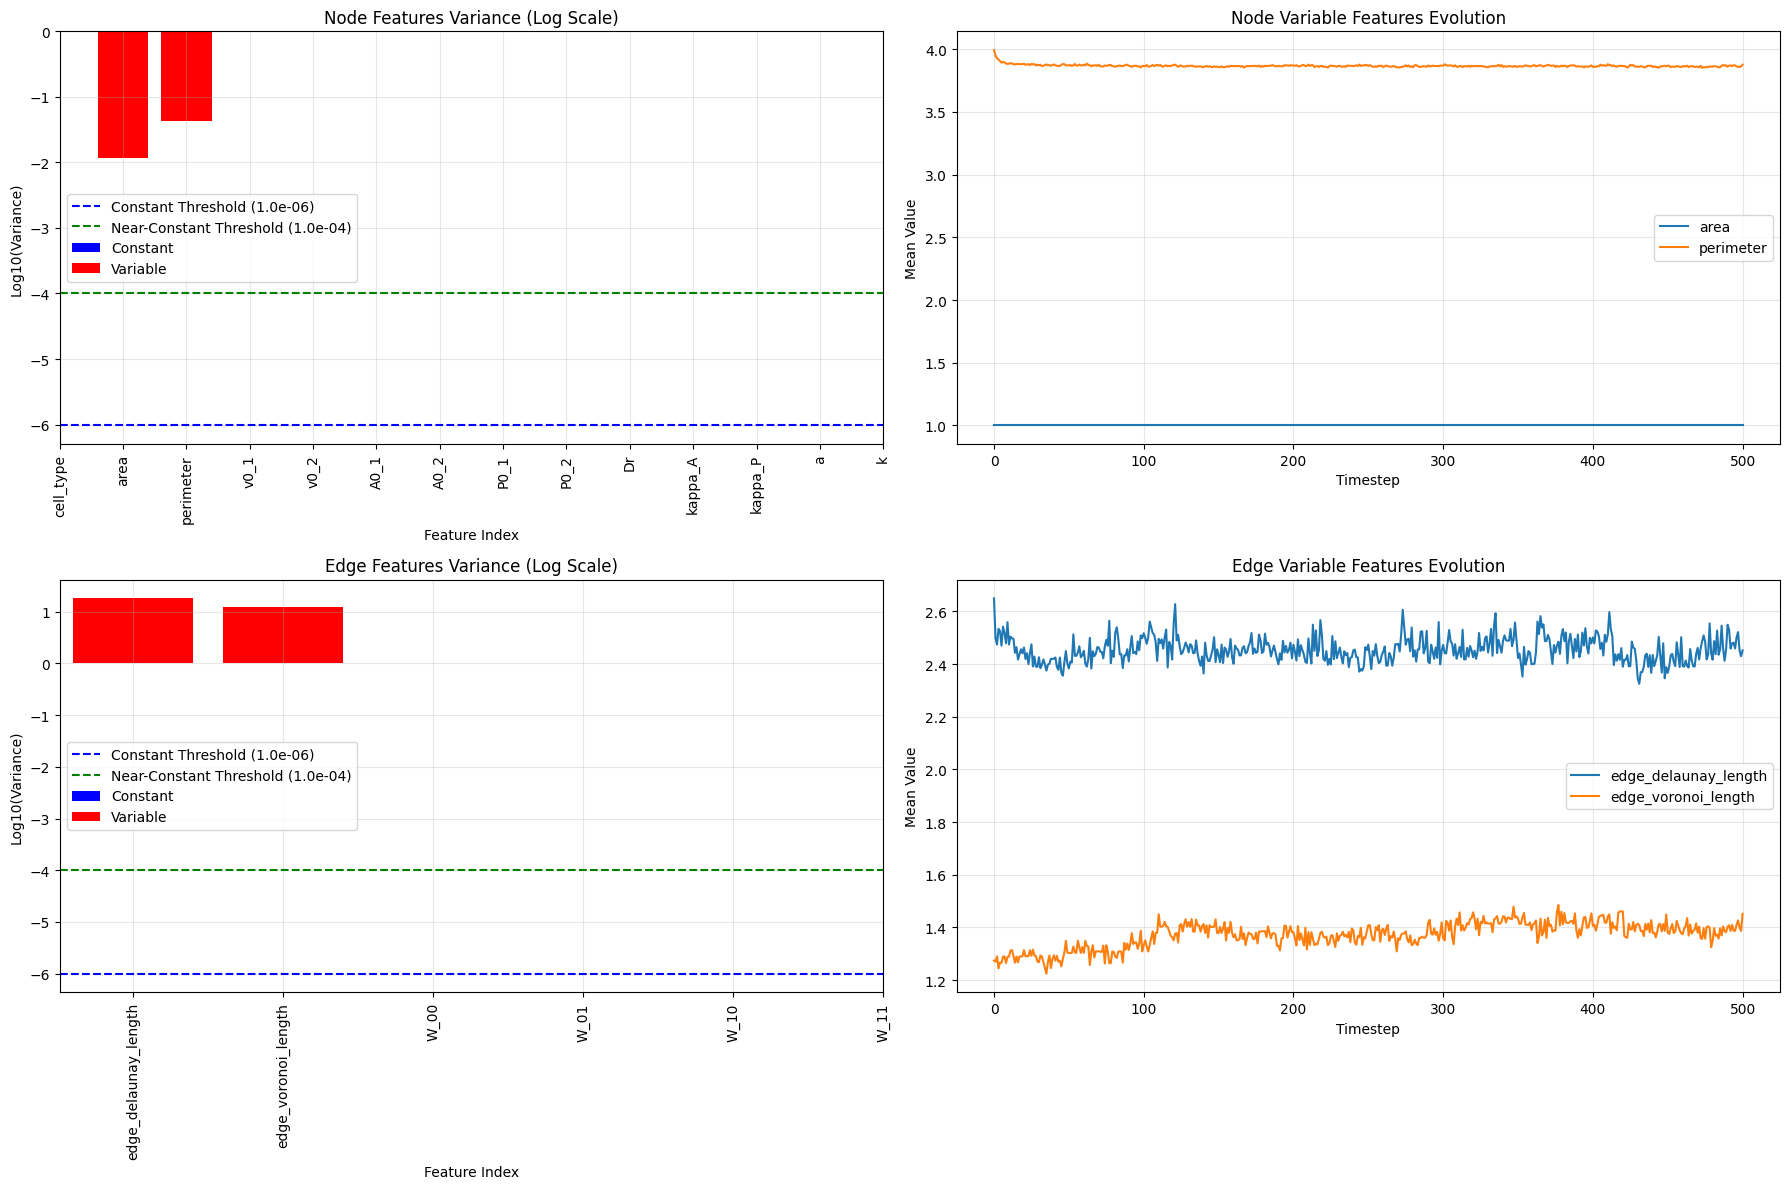

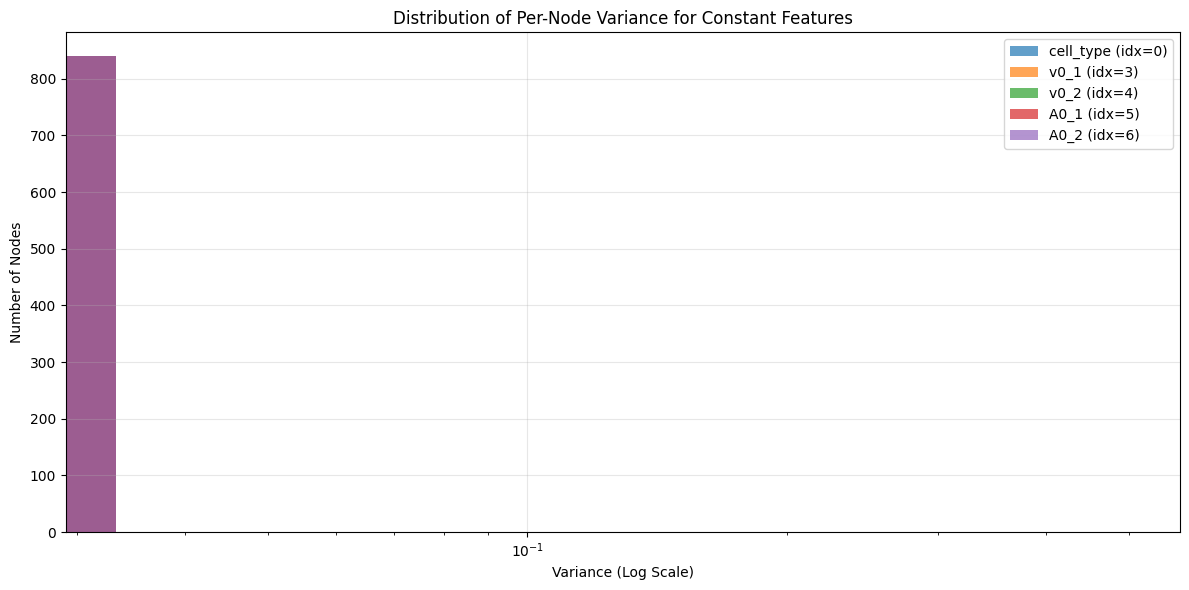

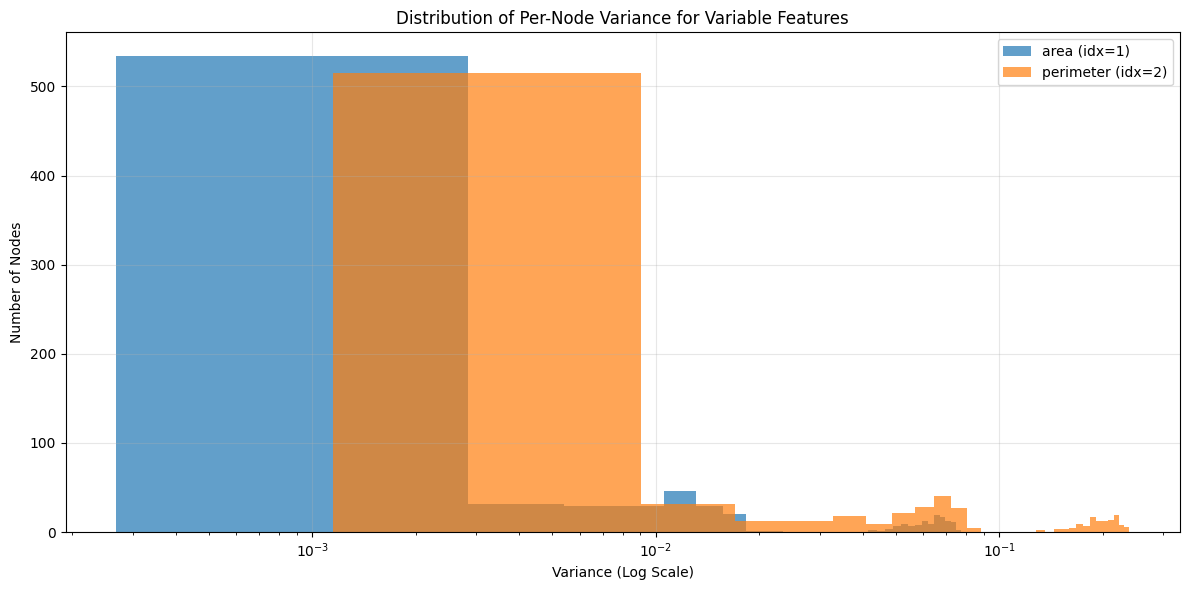


Results for simulation 9:

FEATURE ANALYSIS SUMMARY

NODE FEATURES:
  Total features: 14
  Constant features: 12 (85.7%)
  Near-constant features: 0 (0.0%)
  Variable features: 2 (14.3%)
  Constant feature indices: [0, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13] (cell_type, v0_1, v0_2, A0_1, A0_2, P0_1, P0_2, Dr, kappa_A, kappa_P, a, k)
  Variable feature indices: [1, 2] (area, perimeter)

  Detailed statistics for variable node features:
  ----------------------------------------
  Index  Name            Mean     Std      Min      Max      Range   
  ----------------------------------------
  1      area            1.000    0.109    0.760    1.236    0.475   
  2      perimeter       3.868    0.206    3.376    4.343    0.967   

EDGE FEATURES:
  Tracked 5250 consistent edges out of 16016 total edges
  Total features: 6
  Constant features: 4 (66.7%)
  Near-constant features: 0 (0.0%)
  Variable features: 2 (33.3%)
  Constant feature indices: [2, 3, 4, 5] (W_00, W_01, W_10, W_11)
  Variable 

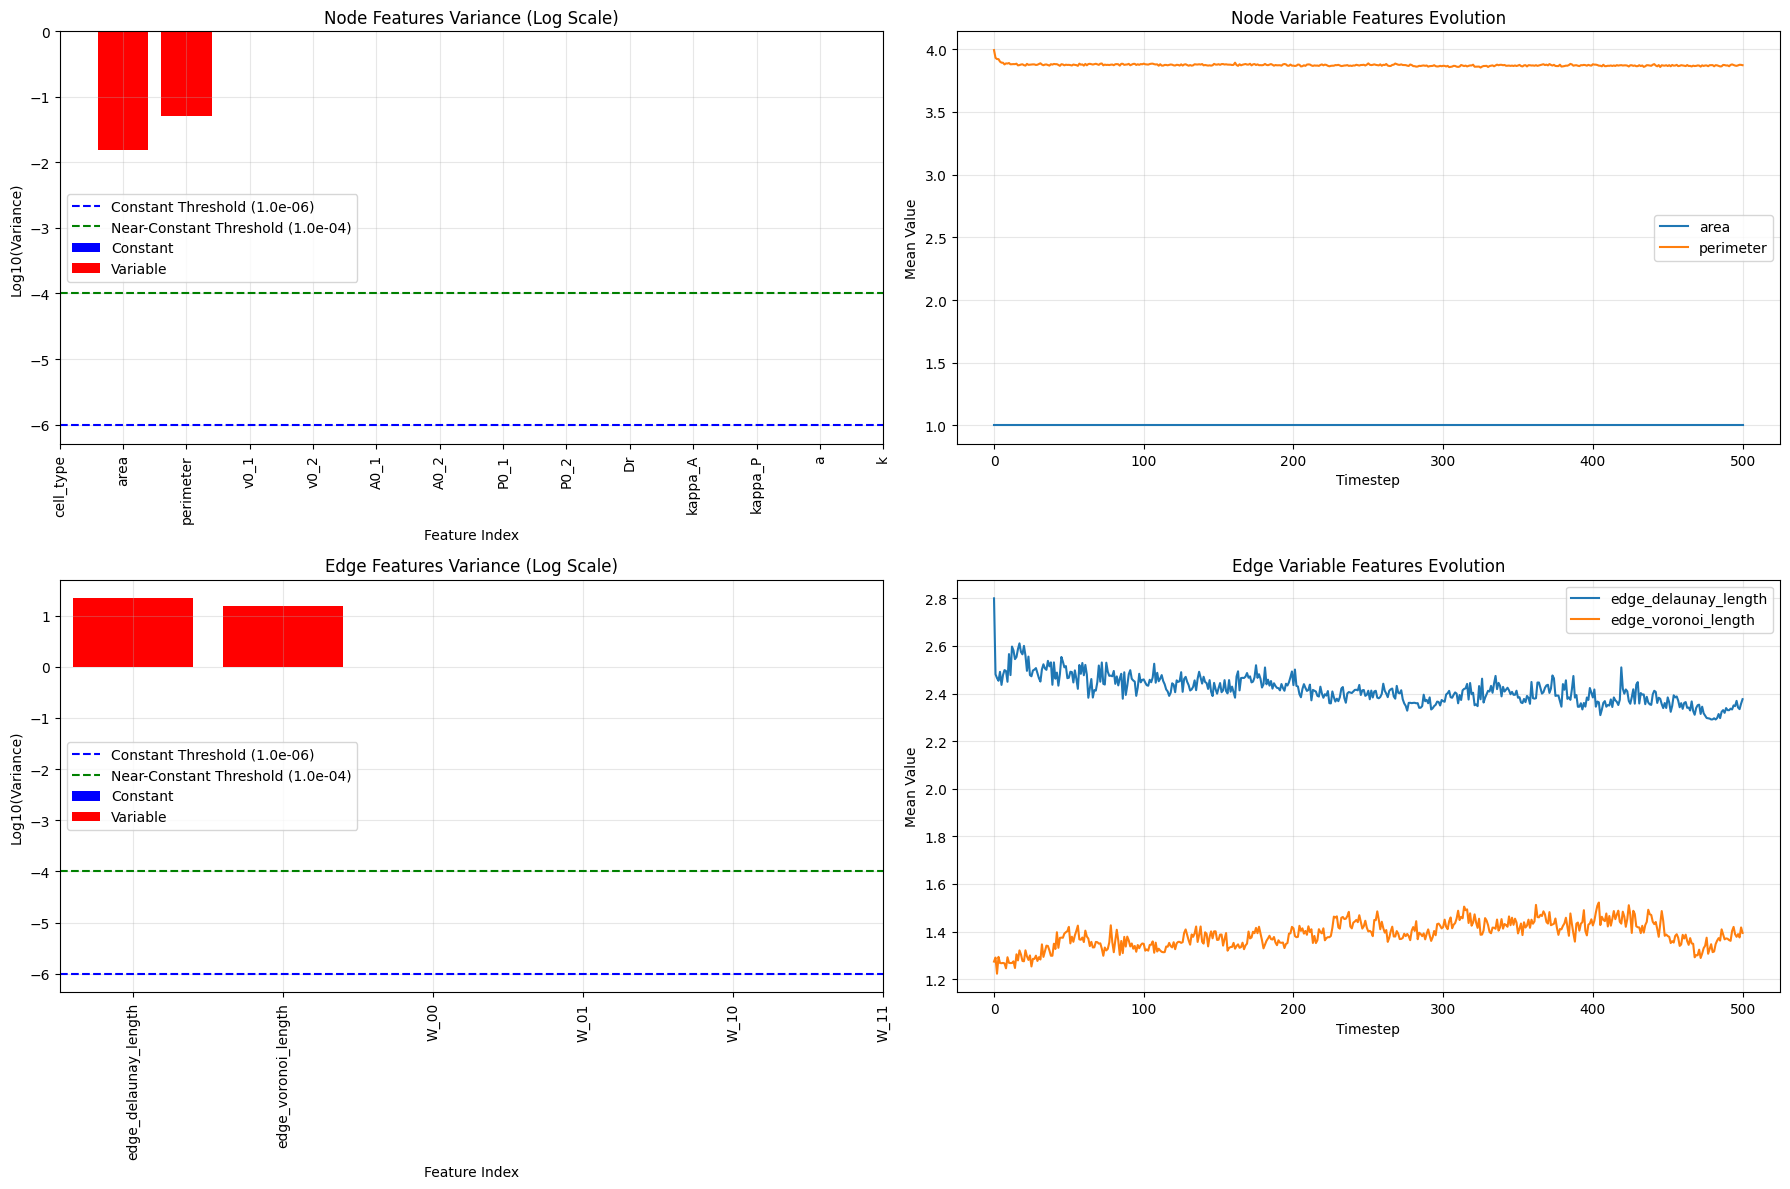

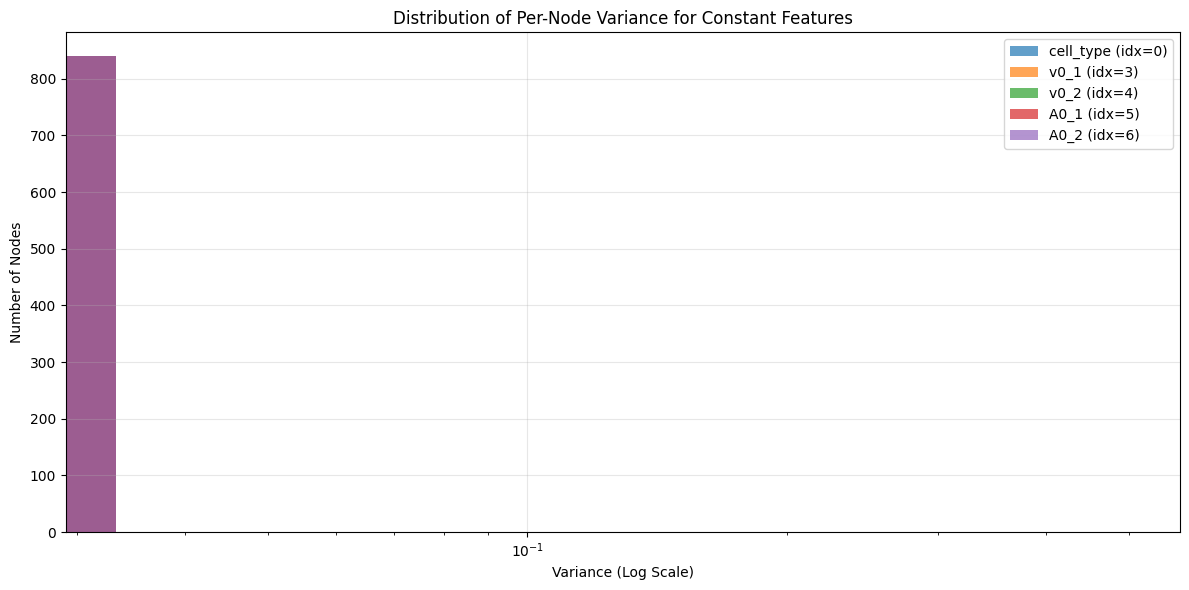

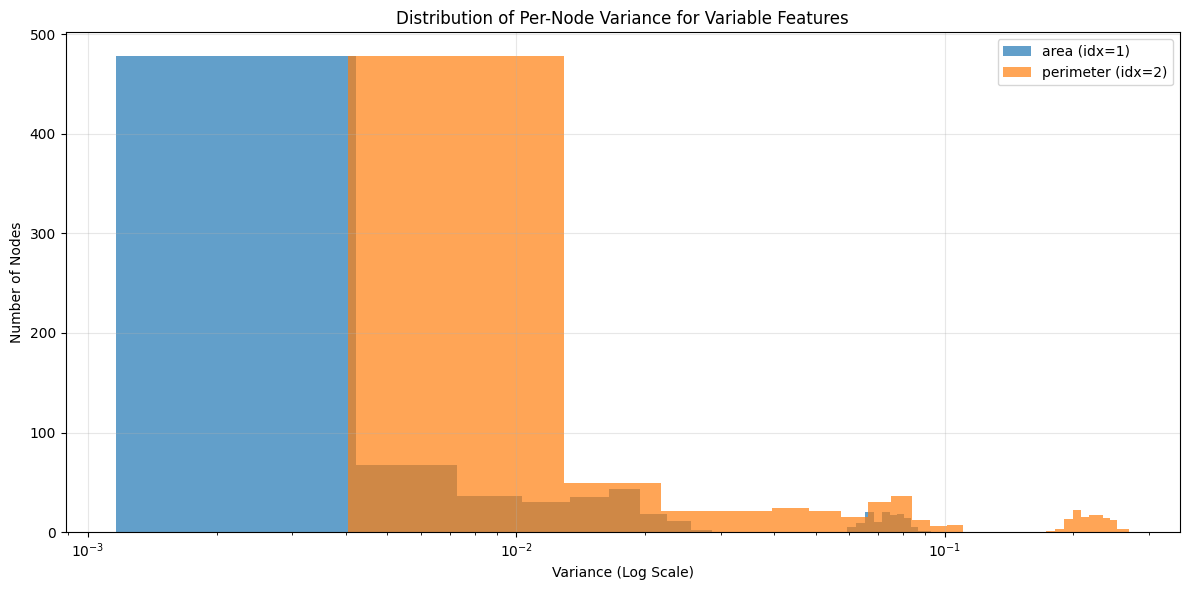


Results for simulation 10:

FEATURE ANALYSIS SUMMARY

NODE FEATURES:
  Total features: 14
  Constant features: 12 (85.7%)
  Near-constant features: 0 (0.0%)
  Variable features: 2 (14.3%)
  Constant feature indices: [0, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13] (cell_type, v0_1, v0_2, A0_1, A0_2, P0_1, P0_2, Dr, kappa_A, kappa_P, a, k)
  Variable feature indices: [1, 2] (area, perimeter)

  Detailed statistics for variable node features:
  ----------------------------------------
  Index  Name            Mean     Std      Min      Max      Range   
  ----------------------------------------
  1      area            1.000    0.124    0.685    1.308    0.623   
  2      perimeter       3.874    0.225    3.266    4.445    1.179   

EDGE FEATURES:
  Tracked 5688 consistent edges out of 21952 total edges
  Total features: 6
  Constant features: 4 (66.7%)
  Near-constant features: 0 (0.0%)
  Variable features: 2 (33.3%)
  Constant feature indices: [2, 3, 4, 5] (W_00, W_01, W_10, W_11)
  Variable

In [4]:
import os
import pickle
import torch
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Dict, Tuple, Optional, Union
from collections import Counter, defaultdict
import glob
from torch_geometric.data import Data


class FeatureAnalyzer:
    """
    Analyzes node and edge features across a temporal sequence of graph data
    to identify constant, near-constant, and variable features.
    
    This component can be used as a preprocessing step for graph transformer models
    to handle features differently based on their variability.
    """
    
    def __init__(
        self, 
        constant_threshold: float = 1e-6,
        near_constant_threshold: float = 1e-4,
        feature_names: Optional[Dict[str, List[str]]] = None
    ):
        """
        Initialize the feature analyzer.
        
        Args:
            constant_threshold: Maximum variance for a feature to be considered constant
            near_constant_threshold: Maximum variance for a feature to be considered near-constant
            feature_names: Dictionary mapping 'node' and 'edge' to lists of feature names
        """
        self.constant_threshold = constant_threshold
        self.near_constant_threshold = near_constant_threshold
        self.feature_names = feature_names or {'node': [], 'edge': []}
        
        # Results storage
        self.node_feature_stats = None
        self.edge_feature_stats = None
        self.node_feature_classification = None
        self.edge_feature_classification = None
        
    def analyze(self, dataset: List[Data]) -> Dict:
        """
        Analyze a dataset consisting of a temporal sequence of graph snapshots.
        
        Args:
            dataset: List of PyG Data objects representing graph snapshots over time
            
        Returns:
            Dictionary containing analysis results
        """
        print(f"Analyzing dataset with {len(dataset)} snapshots...")
        
        # Calculate temporal statistics for node and edge features
        # (tracking the same nodes and edges over time)
        if dataset[0].x is not None:
            self.node_feature_stats = self._calculate_temporal_node_stats(dataset)
        
        if dataset[0].edge_attr is not None:
            self.edge_feature_stats = self._calculate_temporal_edge_stats(dataset)
        
        # Classify features based on variance
        if self.node_feature_stats is not None:
            self.node_feature_classification = self._classify_features(
                self.node_feature_stats['variance'],
                'node'
            )
        
        if self.edge_feature_stats is not None:
            self.edge_feature_classification = self._classify_features(
                self.edge_feature_stats['variance'],
                'edge'
            )
        
        return self._compile_results()
    
    def _calculate_temporal_node_stats(self, dataset: List[Data]) -> Dict:
        """
        Calculate statistics for node features by tracking each node across time.
        
        Args:
            dataset: List of PyG Data objects
            
        Returns:
            Dictionary of feature statistics
        """
        # First determine if node indices are consistent across timesteps
        # (constant number of nodes, no creation/deletion)
        num_nodes_list = [data.x.shape[0] for data in dataset]
        if len(set(num_nodes_list)) != 1:
            print(f"Warning: Number of nodes varies across timesteps ({min(num_nodes_list)}-{max(num_nodes_list)})")
            print("Using consistent node tracking method for variable node count")
            return self._calculate_node_stats_variable_count(dataset)
        
        # Get dimensions
        num_nodes = dataset[0].x.shape[0]
        num_features = dataset[0].x.shape[1]
        num_timesteps = len(dataset)
        
        # Create a tensor to hold features for each node across all timesteps
        # Shape: [num_nodes, num_timesteps, num_features]
        node_features_time_series = torch.zeros((num_nodes, num_timesteps, num_features))
        
        # Populate the tensor
        for t, data in enumerate(dataset):
            node_features_time_series[:, t, :] = data.x
        
        # Calculate statistics along the time dimension for each node, then average across nodes
        # Mean of each feature for each node across time
        node_time_means = node_features_time_series.mean(dim=1)  # [num_nodes, num_features]
        
        # Calculate variance of each feature for each node across time
        node_time_variances = torch.var(node_features_time_series, dim=1)  # [num_nodes, num_features]
        
        # Calculate min and max of each feature for each node across time
        node_time_mins = node_features_time_series.min(dim=1)[0]  # [num_nodes, num_features]
        node_time_maxs = node_features_time_series.max(dim=1)[0]  # [num_nodes, num_features]
        
        # Average the statistics across nodes
        mean_values = node_time_means.mean(dim=0)  # [num_features]
        variance_values = node_time_variances.mean(dim=0)  # [num_features]
        min_values = node_time_mins.mean(dim=0)  # [num_features]
        max_values = node_time_maxs.mean(dim=0)  # [num_features]
        std_values = torch.sqrt(variance_values)  # [num_features]
        
        # Calculate per-timestep mean to analyze trend
        timestep_means = []
        for t in range(num_timesteps):
            timestep_means.append(node_features_time_series[:, t, :].mean(dim=0))
        
        timestep_means_tensor = torch.stack(timestep_means)
        
        return {
            'mean': mean_values,
            'min': min_values,
            'max': max_values,
            'variance': variance_values,
            'std': std_values,
            'range': max_values - min_values,
            'timestep_means': timestep_means_tensor,
            'per_node_variance': node_time_variances,  # Store per-node variance for detailed analysis
            'per_node_feature_time_series': node_features_time_series  # Store full time series
        }
    
    def _calculate_node_stats_variable_count(self, dataset: List[Data]) -> Dict:
        """
        Calculate node feature statistics when node count varies between timesteps.
        This uses the cell_x attribute to track consistent node identities.
        
        Args:
            dataset: List of PyG Data objects
            
        Returns:
            Dictionary of feature statistics
        """
        print("Using cell_x to track nodes across time when node count varies")
        
        # Check if cell_x is available for tracking
        if not hasattr(dataset[0], 'cell_x'):
            print("Warning: cell_x not available for node tracking. Using aggregate statistics.")
            return self._calculate_feature_stats(dataset, 'node')
        
        # Get dimensions
        num_features = dataset[0].x.shape[1]
        
        # Use cell_x to track nodes across time
        # This assumes cell_x contains a unique ID for each node
        node_tracker = {}  # Maps node_id -> list of (timestep, node_idx) tuples
        
        for t, data in enumerate(dataset):
            for node_idx in range(data.x.shape[0]):
                # Use the first column of cell_x as the node identifier
                if hasattr(data, 'cell_x') and data.cell_x is not None:
                    node_id = data.cell_x[node_idx, 0].item()  # Assuming first column is ID
                else:
                    # If cell_x is not available, use node index (less reliable)
                    node_id = node_idx
                
                if node_id not in node_tracker:
                    node_tracker[node_id] = []
                node_tracker[node_id].append((t, node_idx))
        
        # Filter to nodes that appear in at least half of the timesteps
        min_timesteps = len(dataset) // 2
        consistent_nodes = {node_id: indices for node_id, indices in node_tracker.items() 
                           if len(indices) >= min_timesteps}
        
        print(f"Found {len(consistent_nodes)} nodes that appear in at least {min_timesteps} timesteps")
        
        # Collect features for each consistent node
        all_node_variances = []
        all_node_means = []
        all_node_mins = []
        all_node_maxs = []
        
        for node_id, appearances in consistent_nodes.items():
            # Extract features for this node at each timestep it appears
            node_features = []
            
            for t, node_idx in appearances:
                node_features.append(dataset[t].x[node_idx])
            
            # Convert to tensor
            if node_features:
                node_features_tensor = torch.stack(node_features)
                
                # Calculate statistics for this node
                node_mean = node_features_tensor.mean(dim=0)
                node_variance = torch.var(node_features_tensor, dim=0)
                node_min = node_features_tensor.min(dim=0)[0]
                node_max = node_features_tensor.max(dim=0)[0]
                
                all_node_means.append(node_mean)
                all_node_variances.append(node_variance)
                all_node_mins.append(node_min)
                all_node_maxs.append(node_max)
        
        # Average the statistics across nodes
        if all_node_means:
            mean_values = torch.stack(all_node_means).mean(dim=0)
            variance_values = torch.stack(all_node_variances).mean(dim=0)
            min_values = torch.stack(all_node_mins).mean(dim=0)
            max_values = torch.stack(all_node_maxs).mean(dim=0)
            std_values = torch.sqrt(variance_values)
        else:
            # Fallback if no consistent nodes found
            print("Warning: No consistent nodes found. Using aggregate statistics.")
            return self._calculate_feature_stats(dataset, 'node')
        
        # Calculate per-timestep means for trend analysis
        timestep_means = []
        for data in dataset:
            timestep_means.append(data.x.mean(dim=0))
        
        timestep_means_tensor = torch.stack(timestep_means)
        
        return {
            'mean': mean_values,
            'min': min_values,
            'max': max_values,
            'variance': variance_values,
            'std': std_values,
            'range': max_values - min_values,
            'timestep_means': timestep_means_tensor,
            'consistent_nodes': len(consistent_nodes),
            'total_nodes': len(node_tracker)
        }
    
    def _calculate_temporal_edge_stats(self, dataset: List[Data]) -> Dict:
        """
        Calculate statistics for edge features by tracking consistent edges across time.
        
        Args:
            dataset: List of PyG Data objects
            
        Returns:
            Dictionary of feature statistics
        """
        print("Analyzing edge features by tracking consistent edges over time")
        
        # Create a dictionary to track edges across timesteps
        # Key: (source_node, target_node), Value: list of (timestep, edge_idx) tuples
        edge_tracker = {}
        
        # Track edges across all timesteps
        for t, data in enumerate(dataset):
            if data.edge_index is None or data.edge_attr is None:
                continue
                
            edge_index = data.edge_index
            for edge_idx in range(edge_index.shape[1]):
                src = edge_index[0, edge_idx].item()
                dst = edge_index[1, edge_idx].item()
                edge_key = (src, dst)
                
                if edge_key not in edge_tracker:
                    edge_tracker[edge_key] = []
                edge_tracker[edge_key].append((t, edge_idx))
        
        # Filter to edges that appear in at least half of the timesteps
        min_timesteps = len(dataset) // 2
        consistent_edges = {edge: indices for edge, indices in edge_tracker.items()
                          if len(indices) >= min_timesteps}
        
        print(f"Found {len(consistent_edges)} edges that appear in at least {min_timesteps} timesteps")
        
        # If no consistent edges, fall back to aggregate statistics
        if not consistent_edges:
            print("Warning: No consistent edges found. Using aggregate statistics.")
            return self._calculate_feature_stats(dataset, 'edge')
        
        # Get feature dimension
        num_features = dataset[0].edge_attr.shape[1]
        
        # Collect features for each consistent edge
        all_edge_variances = []
        all_edge_means = []
        all_edge_mins = []
        all_edge_maxs = []
        
        for edge_key, appearances in consistent_edges.items():
            # Extract features for this edge at each timestep it appears
            edge_features = []
            
            for t, edge_idx in appearances:
                edge_features.append(dataset[t].edge_attr[edge_idx])
            
            # Convert to tensor
            if edge_features:
                edge_features_tensor = torch.stack(edge_features)
                
                # Calculate statistics for this edge
                edge_mean = edge_features_tensor.mean(dim=0)
                edge_variance = torch.var(edge_features_tensor, dim=0)
                edge_min = edge_features_tensor.min(dim=0)[0]
                edge_max = edge_features_tensor.max(dim=0)[0]
                
                all_edge_means.append(edge_mean)
                all_edge_variances.append(edge_variance)
                all_edge_mins.append(edge_min)
                all_edge_maxs.append(edge_max)
        
        # Average the statistics across edges
        if all_edge_means:
            mean_values = torch.stack(all_edge_means).mean(dim=0)
            variance_values = torch.stack(all_edge_variances).mean(dim=0)
            min_values = torch.stack(all_edge_mins).mean(dim=0)
            max_values = torch.stack(all_edge_maxs).mean(dim=0)
            std_values = torch.sqrt(variance_values)
        else:
            # Fallback
            return self._calculate_feature_stats(dataset, 'edge')
        
        # Calculate per-timestep means for trend analysis
        timestep_means = []
        for data in dataset:
            if data.edge_attr is not None:
                timestep_means.append(data.edge_attr.mean(dim=0))
        
        timestep_means_tensor = torch.stack(timestep_means)
        
        return {
            'mean': mean_values,
            'min': min_values,
            'max': max_values,
            'variance': variance_values,
            'std': std_values,
            'range': max_values - min_values,
            'timestep_means': timestep_means_tensor,
            'consistent_edges': len(consistent_edges),
            'total_edges': len(edge_tracker)
        }
    
    def _calculate_feature_stats(self, dataset: List[Data], feature_type: str) -> Dict:
        """
        Fallback method to calculate aggregate statistics for node or edge features.
        
        Args:
            dataset: List of PyG Data objects
            feature_type: Either 'node' or 'edge'
            
        Returns:
            Dictionary of feature statistics
        """
        print(f"Using aggregate statistics for {feature_type} features")
        
        # Set up correct attribute based on feature type
        if feature_type == 'node':
            get_features = lambda data: data.x
        else:  # edge
            get_features = lambda data: data.edge_attr
        
        # Get dimensions
        first_features = get_features(dataset[0])
        num_features = first_features.shape[1]
        
        # Initialize statistics storage
        mean_values = torch.zeros(num_features)
        min_values = torch.full((num_features,), float('inf'))
        max_values = torch.full((num_features,), float('-inf'))
        
        # First pass: calculate global min, max, and sum for mean
        total_count = 0
        feature_sum = torch.zeros(num_features)
        
        for data in dataset:
            features = get_features(data)
            feature_sum += features.sum(dim=0)
            min_values = torch.minimum(min_values, features.min(dim=0)[0])
            max_values = torch.maximum(max_values, features.max(dim=0)[0])
            total_count += features.shape[0]
        
        # Calculate global mean
        mean_values = feature_sum / total_count
        
        # Second pass: calculate variance
        variance_sum = torch.zeros(num_features)
        for data in dataset:
            features = get_features(data)
            # Calculate squared deviations from mean
            squared_diff = (features - mean_values.unsqueeze(0)) ** 2
            variance_sum += squared_diff.sum(dim=0)
        
        variance_values = variance_sum / total_count
        std_values = torch.sqrt(variance_values)
        
        # Calculate per-timestep mean to analyze trend
        timestep_means = []
        for data in dataset:
            features = get_features(data)
            timestep_means.append(features.mean(dim=0))
        
        timestep_means_tensor = torch.stack(timestep_means)
        
        return {
            'mean': mean_values,
            'min': min_values,
            'max': max_values,
            'variance': variance_values,
            'std': std_values,
            'range': max_values - min_values,
            'timestep_means': timestep_means_tensor
        }
    
    def _classify_features(self, variance_values: torch.Tensor, feature_type: str) -> Dict:
        """
        Classify features as constant, near-constant, or variable based on variance.
        
        Args:
            variance_values: Tensor of variance values for each feature
            feature_type: Either 'node' or 'edge'
            
        Returns:
            Dictionary mapping feature indices to their classification
        """
        constant_indices = []
        near_constant_indices = []
        variable_indices = []
        
        for i, var in enumerate(variance_values):
            if var <= self.constant_threshold:
                constant_indices.append(i)
            elif var <= self.near_constant_threshold:
                near_constant_indices.append(i)
            else:
                variable_indices.append(i)
        
        return {
            'constant': constant_indices,
            'near_constant': near_constant_indices,
            'variable': variable_indices
        }
    
    def _compile_results(self) -> Dict:
        """
        Compile all analysis results into a single dictionary.
        
        Returns:
            Dictionary of analysis results
        """
        results = {
            'node_features': {},
            'edge_features': {}
        }
        
        if self.node_feature_stats is not None:
            results['node_features'] = {
                'stats': self.node_feature_stats,
                'classification': self.node_feature_classification,
                'num_features': len(self.node_feature_stats['mean'])
            }
        
        if self.edge_feature_stats is not None:
            results['edge_features'] = {
                'stats': self.edge_feature_stats,
                'classification': self.edge_feature_classification, 
                'num_features': len(self.edge_feature_stats['mean'])
            }
        
        return results
    
    def get_feature_masks(self) -> Dict[str, Dict[str, torch.Tensor]]:
        """
        Generate boolean masks for different feature categories.
        
        Returns:
            Dictionary of masks for node and edge features
        """
        masks = {'node': {}, 'edge': {}}
        
        if self.node_feature_classification:
            num_node_features = len(self.node_feature_stats['mean'])
            masks['node'] = self._create_masks(self.node_feature_classification, num_node_features)
        
        if self.edge_feature_classification:
            num_edge_features = len(self.edge_feature_stats['mean'])
            masks['edge'] = self._create_masks(self.edge_feature_classification, num_edge_features)
        
        return masks
    
    def _create_masks(self, classification: Dict[str, List[int]], num_features: int) -> Dict[str, torch.Tensor]:
        """
        Create boolean masks from feature classification.
        
        Args:
            classification: Dictionary mapping categories to lists of feature indices
            num_features: Total number of features
            
        Returns:
            Dictionary mapping categories to boolean masks
        """
        masks = {}
        for category, indices in classification.items():
            mask = torch.zeros(num_features, dtype=torch.bool)
            if indices:  # Only set if indices is not empty
                mask[indices] = True
            masks[category] = mask
        return masks
    
    def plot_feature_analysis(self, save_path: Optional[str] = None):
        """
        Generate plots to visualize feature analysis results.
        
        Args:
            save_path: Optional path to save the plots
        """
        if self.node_feature_stats is None and self.edge_feature_stats is None:
            print("No analysis results available. Run analyze() first.")
            return
        
        fig, axes = plt.subplots(2, 2, figsize=(18, 12))
        
        # Plot node feature variance (log scale)
        if self.node_feature_stats is not None:
            self._plot_variance(axes[0, 0], self.node_feature_stats['variance'], 
                             self.node_feature_classification, 'Node Features')
            
            # Plot node feature evolution over time for most variable features
            self._plot_feature_evolution(axes[0, 1], self.node_feature_stats['timestep_means'], 
                                      self.node_feature_classification, 'Node', feature_type='variable')
        
        # Plot edge feature variance (log scale)
        if self.edge_feature_stats is not None:
            self._plot_variance(axes[1, 0], self.edge_feature_stats['variance'], 
                             self.edge_feature_classification, 'Edge Features')
            
            # Plot edge feature evolution over time for most variable features
            self._plot_feature_evolution(axes[1, 1], self.edge_feature_stats['timestep_means'], 
                                      self.edge_feature_classification, 'Edge', feature_type='variable')
        
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()
        
        # Add an additional plot for per-node variance analysis if available
        if self.node_feature_stats is not None and 'per_node_variance' in self.node_feature_stats:
            self._plot_per_node_variance(save_path)
    
    def _plot_per_node_variance(self, base_save_path: Optional[str] = None):
        """
        Plot the distribution of variance values across nodes for each feature.
        
        Args:
            base_save_path: Optional path to save the plots
        """
        if 'per_node_variance' not in self.node_feature_stats:
            return
            
        per_node_variance = self.node_feature_stats['per_node_variance']
        num_features = per_node_variance.shape[1]
        
        # Create separate plots for constant, near-constant, and variable features
        for category, indices in self.node_feature_classification.items():
            if not indices:
                continue
                
            plt.figure(figsize=(12, 6))
            for i, idx in enumerate(indices[:min(5, len(indices))]):  # Plot at most 5 features
                feature_name = self._get_feature_name('node', idx)
                
                # Get variance values for this feature across all nodes
                feature_variance = per_node_variance[:, idx].numpy()
                
                # Plot histogram of variance values
                plt.hist(feature_variance, bins=30, alpha=0.7, label=f"{feature_name} (idx={idx})")
            
            plt.xscale('log')
            plt.xlabel('Variance (Log Scale)')
            plt.ylabel('Number of Nodes')
            plt.title(f'Distribution of Per-Node Variance for {category.capitalize()} Features')
            plt.legend()
            plt.grid(alpha=0.3)
            
            if base_save_path:
                save_dir = os.path.dirname(base_save_path)
                save_name = f"per_node_variance_{category}.png"
                plt.savefig(os.path.join(save_dir, save_name), dpi=300, bbox_inches='tight')
            
            plt.tight_layout()
            plt.show()
    
    def _plot_variance(self, ax, variance, classification, title):
        """Plot feature variance with classification highlighting."""
        features = list(range(len(variance)))
        
        # Plot all features
        ax.bar(features, variance.log10().numpy(), color='lightgrey', alpha=0.7)
        
        # Highlight different categories
        if classification['constant']:
            ax.bar(classification['constant'], 
                  variance[classification['constant']].log10().numpy(), 
                  color='blue', label='Constant')
        
        if classification['near_constant']:
            ax.bar(classification['near_constant'], 
                  variance[classification['near_constant']].log10().numpy(), 
                  color='green', label='Near-Constant')
        
        if classification['variable']:
            ax.bar(classification['variable'], 
                  variance[classification['variable']].log10().numpy(), 
                  color='red', label='Variable')
        
        # Add threshold lines
        ax.axhline(y=np.log10(self.constant_threshold), color='blue', linestyle='--', 
                  label=f'Constant Threshold ({self.constant_threshold:.1e})')
        ax.axhline(y=np.log10(self.near_constant_threshold), color='green', linestyle='--', 
                  label=f'Near-Constant Threshold ({self.near_constant_threshold:.1e})')
        
        # Feature names if available
        if title.startswith('Node') and len(self.feature_names.get('node', [])) == len(variance):
            ax.set_xticks(features)
            ax.set_xticklabels(self.feature_names['node'], rotation=90)
        elif title.startswith('Edge') and len(self.feature_names.get('edge', [])) == len(variance):
            ax.set_xticks(features)
            ax.set_xticklabels(self.feature_names['edge'], rotation=90)
        
        ax.set_xlabel('Feature Index')
        ax.set_ylabel('Log10(Variance)')
        ax.set_title(f'{title} Variance (Log Scale)')
        ax.legend()
        ax.grid(alpha=0.3)
    
    def _plot_feature_evolution(self, ax, timestep_means, classification, prefix, feature_type='variable'):
        """Plot the evolution of features over time."""
        # Get the indices of features to plot
        indices = classification.get(feature_type, [])
        if not indices:
            ax.text(0.5, 0.5, f"No {feature_type} features found", 
                   horizontalalignment='center', verticalalignment='center')
            ax.set_title(f'{prefix} Feature Evolution Over Time')
            return
        
        # Get timestep means for the selected feature type
        selected_means = timestep_means[:, indices]
        
        # Plot each feature's evolution
        timesteps = range(len(timestep_means))
        for i, idx in enumerate(indices):
            feature_name = self.feature_names.get(prefix.lower(), [])[idx] if idx < len(self.feature_names.get(prefix.lower(), [])) else f"Feature {idx}"
            ax.plot(timesteps, selected_means[:, i], label=feature_name)
        
        ax.set_xlabel('Timestep')
        ax.set_ylabel('Mean Value')
        ax.set_title(f'{prefix} {feature_type.capitalize()} Features Evolution')
        
        # Show legend only if we have a reasonable number of features
        if len(indices) <= 10:
            ax.legend()
        ax.grid(alpha=0.3)
        
    def print_summary(self):
        """Print a summary of the feature analysis results."""
        if self.node_feature_classification is None and self.edge_feature_classification is None:
            print("No analysis results available. Run analyze() first.")
            return
        
        print("\n" + "="*50)
        print("FEATURE ANALYSIS SUMMARY")
        print("="*50)
        
        if self.node_feature_classification is not None:
            print("\nNODE FEATURES:")
            if 'consistent_nodes' in self.node_feature_stats:
                print(f"  Tracked {self.node_feature_stats['consistent_nodes']} consistent nodes " + 
                      f"out of {self.node_feature_stats['total_nodes']} total nodes")
            self._print_feature_category_summary('node')
            
            # Print detailed stats for variable features
            self._print_detailed_stats('node', 'variable')
        
        if self.edge_feature_classification is not None:
            print("\nEDGE FEATURES:")
            if 'consistent_edges' in self.edge_feature_stats:
                print(f"  Tracked {self.edge_feature_stats['consistent_edges']} consistent edges " + 
                      f"out of {self.edge_feature_stats['total_edges']} total edges")
            self._print_feature_category_summary('edge')
            
            # Print detailed stats for variable features
            self._print_detailed_stats('edge', 'variable')
    
    def _print_feature_category_summary(self, feature_type):
        """Print summary of feature categories."""
        classification = getattr(self, f"{feature_type}_feature_classification")
        stats = getattr(self, f"{feature_type}_feature_stats")
        
        print(f"  Total features: {len(stats['mean'])}")
        print(f"  Constant features: {len(classification['constant'])} " + 
              f"({100*len(classification['constant'])/len(stats['mean']):.1f}%)")
        print(f"  Near-constant features: {len(classification['near_constant'])} " + 
              f"({100*len(classification['near_constant'])/len(stats['mean']):.1f}%)")
        print(f"  Variable features: {len(classification['variable'])} " + 
              f"({100*len(classification['variable'])/len(stats['mean']):.1f}%)")
        
        if classification['constant']:
            names = self._get_feature_names(feature_type, classification['constant'])
            print(f"  Constant feature indices: {classification['constant']} {names}")
        
        if classification['near_constant']:
            names = self._get_feature_names(feature_type, classification['near_constant'])
            print(f"  Near-constant feature indices: {classification['near_constant']} {names}")
        
        if classification['variable']:
            names = self._get_feature_names(feature_type, classification['variable'])
            print(f"  Variable feature indices: {classification['variable']} {names}")
    
    def _print_detailed_stats(self, feature_type, category):
        """Print detailed statistics for a specific feature category."""
        classification = getattr(self, f"{feature_type}_feature_classification")
        stats = getattr(self, f"{feature_type}_feature_stats")
        
        indices = classification[category]
        if not indices:
            return
        
        print(f"\n  Detailed statistics for {category} {feature_type} features:")
        print("  " + "-"*40)
        print(f"  {'Index':<6} {'Name':<15} {'Mean':<8} {'Std':<8} {'Min':<8} {'Max':<8} {'Range':<8}")
        print("  " + "-"*40)
        
        for idx in indices:
            name = self._get_feature_name(feature_type, idx)
            mean = stats['mean'][idx].item()
            std = stats['std'][idx].item()
            min_val = stats['min'][idx].item()
            max_val = stats['max'][idx].item()
            range_val = stats['range'][idx].item()
            
            print(f"  {idx:<6} {name:<15} {mean:<8.3f} {std:<8.3f} {min_val:<8.3f} {max_val:<8.3f} {range_val:<8.3f}")
    
    def _get_feature_names(self, feature_type, indices):
        """Get feature names for a list of indices."""
        if not self.feature_names or not self.feature_names.get(feature_type):
            return ""
        
        names = []
        for idx in indices:
            if idx < len(self.feature_names[feature_type]):
                names.append(self.feature_names[feature_type][idx])
        
        if names:
            return f"({', '.join(names)})"
        return ""
    
    def _get_feature_name(self, feature_type, idx):
        """Get feature name for a single index."""
        if not self.feature_names or not self.feature_names.get(feature_type):
            return f"Feature {idx}"
        
        if idx < len(self.feature_names[feature_type]):
            return self.feature_names[feature_type][idx]
        return f"Feature {idx}"


def analyze_multiple_datasets(dataset_paths, output_dir="feature_analysis_results", 
                             constant_threshold=1e-6, near_constant_threshold=1e-4):
    """
    Analyze multiple datasets and find consistent patterns across them.
    
    Args:
        dataset_paths: List of paths to dataset pickle files
        output_dir: Directory to save analysis results
        constant_threshold: Threshold for constant features
        near_constant_threshold: Threshold for near-constant features
        
    Returns:
        Dictionary with analysis results
    """
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    
    # Define feature names
    node_feature_names = ["cell_type", "area", "perimeter", "v0_1", "v0_2", 
                         "A0_1", "A0_2", "P0_1", "P0_2", "Dr", "kappa_A", 
                         "kappa_P", "a", "k"]
    edge_feature_names = ["edge_delaunay_length", "edge_voronoi_length", 
                         "W_00", "W_01", "W_10", "W_11"]
    
    feature_names = {
        'node': node_feature_names,
        'edge': edge_feature_names
    }
    
    all_results = []
    all_analyzers = []
    sim_names = []
    
    # Initialize sets for common feature classifications
    common_constant_node = None
    common_variable_node = None
    common_constant_edge = None
    common_variable_edge = None
    
    # Process each dataset
    for i, dataset_path in enumerate(dataset_paths):
        print(f"\n[{i+1}/{len(dataset_paths)}] Processing dataset: {dataset_path}")
        
        # Extract simulation name from path
        sim_name = os.path.basename(os.path.dirname(dataset_path))
        sim_names.append(sim_name)
        
        try:
            # Load dataset
            with open(dataset_path, 'rb') as f:
                dataset = pickle.load(f)
            
            # Create analyzer
            analyzer = FeatureAnalyzer(
                constant_threshold=constant_threshold,
                near_constant_threshold=near_constant_threshold,
                feature_names=feature_names
            )
            
            # Run analysis
            results = analyzer.analyze(dataset)
            all_results.append(results)
            all_analyzers.append(analyzer)
            
            # Save individual analysis plots
            plot_path = os.path.join(output_dir, f"feature_analysis_{sim_name}.png")
            analyzer.plot_feature_analysis(save_path=plot_path)
            
            # Print summary for this dataset
            print(f"\nResults for simulation {sim_name}:")
            analyzer.print_summary()
            
            # Track common feature classifications
            if common_constant_node is None:
                common_constant_node = set(results['node_features']['classification']['constant'])
                common_variable_node = set(results['node_features']['classification']['variable'])
            else:
                common_constant_node &= set(results['node_features']['classification']['constant'])
                common_variable_node &= set(results['node_features']['classification']['variable'])
            
            if 'edge_features' in results and 'classification' in results['edge_features']:
                if common_constant_edge is None:
                    common_constant_edge = set(results['edge_features']['classification']['constant'])
                    common_variable_edge = set(results['edge_features']['classification']['variable'])
                else:
                    common_constant_edge &= set(results['edge_features']['classification']['constant'])
                    common_variable_edge &= set(results['edge_features']['classification']['variable'])
            
        except Exception as e:
            print(f"Error processing {dataset_path}: {e}")
            continue
    
    # Prepare summary results
    summary = {
        'common_constant_node_features': sorted(list(common_constant_node)) if common_constant_node else [],
        'common_variable_node_features': sorted(list(common_variable_node)) if common_variable_node else [],
        'common_constant_edge_features': sorted(list(common_constant_edge)) if common_constant_edge else [],
        'common_variable_edge_features': sorted(list(common_variable_edge)) if common_variable_edge else [],
        'simulation_names': sim_names,
        'num_simulations_analyzed': len(all_results)
    }
    
    # Print cross-dataset summary
    print("\n" + "="*60)
    print("CROSS-DATASET FEATURE ANALYSIS SUMMARY")
    print("="*60)
    print(f"Analyzed {len(all_results)} datasets successfully")
    
    print("\nCommon constant node features across all datasets:")
    if common_constant_node:
        constant_names = [node_feature_names[idx] for idx in summary['common_constant_node_features'] 
                        if idx < len(node_feature_names)]
        print(f"  Indices: {summary['common_constant_node_features']}")
        print(f"  Names: {constant_names}")
    else:
        print("  None")
    
    print("\nCommon variable node features across all datasets:")
    if common_variable_node:
        variable_names = [node_feature_names[idx] for idx in summary['common_variable_node_features'] 
                         if idx < len(node_feature_names)]
        print(f"  Indices: {summary['common_variable_node_features']}")
        print(f"  Names: {variable_names}")
    else:
        print("  None")
    
    if common_constant_edge is not None:
        print("\nCommon constant edge features across all datasets:")
        if common_constant_edge:
            constant_edge_names = [edge_feature_names[idx] for idx in summary['common_constant_edge_features'] 
                                if idx < len(edge_feature_names)]
            print(f"  Indices: {summary['common_constant_edge_features']}")
            print(f"  Names: {constant_edge_names}")
        else:
            print("  None")
        
        print("\nCommon variable edge features across all datasets:")
        if common_variable_edge:
            variable_edge_names = [edge_feature_names[idx] for idx in summary['common_variable_edge_features'] 
                                 if idx < len(edge_feature_names)]
            print(f"  Indices: {summary['common_variable_edge_features']}")
            print(f"  Names: {variable_edge_names}")
        else:
            print("  None")
    
    # Create cross-dataset visualization
    if all_analyzers:
        create_cross_dataset_visualization(all_analyzers, sim_names, output_dir)
    
    # Save summary results
    summary_path = os.path.join(output_dir, "cross_dataset_summary.pkl")
    with open(summary_path, 'wb') as f:
        pickle.dump(summary, f)
    
    print(f"\nSaved cross-dataset summary to {summary_path}")
    print(f"Individual analysis results saved to {output_dir}")
    
    return {
        'summary': summary,
        'all_results': all_results,
        'all_analyzers': all_analyzers
    }


def create_cross_dataset_visualization(analyzers, sim_names, output_dir):
    """Create visualizations comparing feature classifications across datasets."""
    if not analyzers:
        return
    
    # Get the first analyzer for feature dimensions
    first_analyzer = analyzers[0]
    
    # Node features
    if hasattr(first_analyzer, 'node_feature_stats') and first_analyzer.node_feature_stats is not None:
        num_node_features = len(first_analyzer.node_feature_stats['mean'])
        node_classifications = np.zeros((len(analyzers), num_node_features))
        
        # 0 = constant, 1 = near-constant, 2 = variable
        for i, analyzer in enumerate(analyzers):
            for idx in analyzer.node_feature_classification['constant']:
                node_classifications[i, idx] = 0
            for idx in analyzer.node_feature_classification['near_constant']:
                node_classifications[i, idx] = 1
            for idx in analyzer.node_feature_classification['variable']:
                node_classifications[i, idx] = 2
        
        # Create plot
        plt.figure(figsize=(14, 8))
        plt.imshow(node_classifications, cmap='viridis', aspect='auto')
        plt.colorbar(ticks=[0, 1, 2], label='Classification')
        plt.yticks(range(len(sim_names)), sim_names)
        
        # Add feature names if available
        if hasattr(first_analyzer, 'feature_names') and 'node' in first_analyzer.feature_names:
            plt.xticks(range(num_node_features), first_analyzer.feature_names['node'], rotation=90)
        else:
            plt.xticks(range(num_node_features))
        
        plt.title('Node Feature Classification Across Datasets')
        plt.xlabel('Feature Index')
        plt.ylabel('Simulation')
        plt.grid(False)
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, 'node_feature_classification_comparison.png'), dpi=300)
        plt.close()
    
    # Edge features
    if hasattr(first_analyzer, 'edge_feature_stats') and first_analyzer.edge_feature_stats is not None:
        num_edge_features = len(first_analyzer.edge_feature_stats['mean'])
        edge_classifications = np.zeros((len(analyzers), num_edge_features))
        
        # 0 = constant, 1 = near-constant, 2 = variable
        for i, analyzer in enumerate(analyzers):
            for idx in analyzer.edge_feature_classification['constant']:
                edge_classifications[i, idx] = 0
            for idx in analyzer.edge_feature_classification['near_constant']:
                edge_classifications[i, idx] = 1
            for idx in analyzer.edge_feature_classification['variable']:
                edge_classifications[i, idx] = 2
        
        # Create plot
        plt.figure(figsize=(14, 8))
        plt.imshow(edge_classifications, cmap='viridis', aspect='auto')
        plt.colorbar(ticks=[0, 1, 2], label='Classification')
        plt.yticks(range(len(sim_names)), sim_names)
        
        # Add feature names if available
        if hasattr(first_analyzer, 'feature_names') and 'edge' in first_analyzer.feature_names:
            plt.xticks(range(num_edge_features), first_analyzer.feature_names['edge'], rotation=90)
        else:
            plt.xticks(range(num_edge_features))
        
        plt.title('Edge Feature Classification Across Datasets')
        plt.xlabel('Feature Index')
        plt.ylabel('Simulation')
        plt.grid(False)
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, 'edge_feature_classification_comparison.png'), dpi=300)
        plt.close()


# Main execution script
if __name__ == "__main__":
    # Define base paths
    output_base_dir = "output_tensorobjects"
    
    # Find all dataset pickle files
    dataset_paths = []
    for i in range(1, 11):
        sim_dir = os.path.join(output_base_dir, str(i))
        if os.path.exists(sim_dir):
            pickle_pattern = os.path.join(sim_dir, "dataset_0_2000_step_4.pkl")
            matching_files = glob.glob(pickle_pattern)
            if matching_files:
                dataset_paths.extend(matching_files)
    
    if not dataset_paths:
        print("No dataset files found. Please check the paths.")
    else:
        print(f"Found {len(dataset_paths)} dataset files:")
        for path in dataset_paths:
            print(f"  - {path}")
        
        # Run analysis
        results = analyze_multiple_datasets(
            dataset_paths, 
            output_dir="feature_analysis_results",
            constant_threshold=1e-6,
            near_constant_threshold=1e-4
        )

## Base Architecture

TLDR: 
+ Create abstract base classes for each component
+ Define clear interfaces between modules
+ Set up configuration system using dataclasses or JSON/YAML files

Details into the core interfaces for the Graph Transformer model:
1. Configuration System
The GraphTransformerConfig dataclass provides a centralized configuration that:
+ Defines all model dimensions and hyperparameters
+ Makes the architecture flexible and configurable
+ Stores feature masks from your analysis to separate constant and variable features
+ Controls all behavior with clear defaults

2. Feature Processing
The base architecture implements two key components:
+ Feature Separation
+ The _split_features method in BaseModule separates features into constant and variable parts based on the masks from your feature analysis. 

This is crucial for properly handling, for example:
+ Cell type (constant)
+ Physical parameters (constant)
+ Area and perimeter (variable)

Specialized Feature Processors
+ NodeFeatureProcessor: Processes node features separately for constant and variable parts
+ EdgeFeatureProcessor: Does the same for edge features
Both use specialized FeatureProcessor modules to transform raw features into latent representations.

3. W Parameter Encoding
The WParameterEncoder encodes interaction parameters, which:
+ Uses cell types of connected nodes to create specialized edge embeddings
+ Creates embeddings for each possible cell type pair (2×2 for this data)
These embeddings would capture the physical interaction strengths between different cell types.

4. Feature Integration with FiLM
The FeatureIntegrator implements FiLM-like conditioning where:
+ Constant features generate scaling and bias parameters
+ These parameters modulate the variable features, allowing physical parameters to influence how dynamic features evolve

5. Base Model Structure
The GraphTransformerBase class:
+ Combines all base components
+ Implements preprocessing of graph data
+ Provides a clean interface for extensions

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, Batch
from torch_geometric.utils import to_dense_batch
from torch_scatter import scatter_add, scatter_mean
import math
from dataclasses import dataclass, field
from typing import List, Dict, Optional, Union, Tuple
import numpy as np


@dataclass
class GraphTransformerConfig:
    """Configuration for Graph Transformer model."""
    # Feature dimensions
    node_feature_dim: int = 14          # Total node feature dimension
    edge_feature_dim: int = 6           # Total edge feature dimension
    hidden_dim: int = 64                # Hidden dimension for all layers
    output_dim: int = 2                 # Default output dimension (area, perimeter)
    
    # Feature masks (from feature analyzer)
    constant_node_feature_mask: Optional[List[int]] = None  # Indices of constant node features
    variable_node_feature_mask: Optional[List[int]] = None  # Indices of variable node features
    constant_edge_feature_mask: Optional[List[int]] = None  # Indices of constant edge features
    variable_edge_feature_mask: Optional[List[int]] = None  # Indices of variable edge features
    
    # Embedding dimensions
    node_embedding_dim: int = 64        # Node embedding dimension
    edge_embedding_dim: int = 64        # Edge embedding dimension
    
    # Cell type parameters
    num_cell_types: int = 2             # Number of cell types
    cell_type_embedding_dim: int = 16   # Dimension for cell type embedding
    
    # W parameter dimensions (interaction parameters)
    w_embedding_dim: int = 16           # Dimension for W parameter embedding
    
    # Attention parameters
    num_heads: int = 4                  # Number of attention heads
    dropout_rate: float = 0.1           # Dropout rate
    attention_dropout: float = 0.1      # Attention dropout rate
    
    # Temporal parameters
    temporal_history_size: int = 5      # Number of past timesteps to consider
    max_prediction_horizon: int = 1     # Maximum prediction horizon
    
    # Spatial parameters
    max_hops: int = 3                   # Maximum number of hops for multi-scale attention
    use_edge_features: bool = True      # Whether to use edge features
    
    # Training parameters
    learning_rate: float = 0.001        # Learning rate
    weight_decay: float = 0.0001        # Weight decay for regularization
    grad_clip: float = 1.0              # Gradient clipping value
    curriculum_steps: int = 5           # Steps before increasing prediction horizon
    
    # Model structure
    num_layers: int = 3                 # Number of transformer layers
    activation: str = "gelu"            # Activation function
    use_layer_norm: bool = True         # Whether to use layer normalization
    
    # Training options
    class_balanced_loss: bool = True    # Whether to use class-balanced loss
    interpretable_mode: bool = False    # Whether to use interpretable mode
    sparse_attention_threshold: float = 0.01  # Threshold for sparse attention


class BaseModule(nn.Module):
    """Base module with common utilities for all model components."""
    
    def __init__(self, config: GraphTransformerConfig):
        super().__init__()
        self.config = config
        
    def get_activation(self):
        """Get activation function based on config."""
        if self.config.activation.lower() == "relu":
            return nn.ReLU()
        elif self.config.activation.lower() == "gelu":
            return nn.GELU()
        elif self.config.activation.lower() == "leakyrelu":
            return nn.LeakyReLU(0.1)
        else:
            raise ValueError(f"Unsupported activation: {self.config.activation}")
    
    def _split_features(self, features, constant_mask, variable_mask):
        """Split features into constant and variable parts based on masks."""
        if constant_mask is None or variable_mask is None:
            # Default split: first feature is cell type (constant), others variable
            constant_features = features[:, :1]
            variable_features = features[:, 1:]
        else:
            # Use masks to split features
            constant_features = features[:, constant_mask]
            variable_features = features[:, variable_mask]
        
        return constant_features, variable_features


class FeatureProcessor(BaseModule):
    """Base class for processing features (nodes or edges)."""
    
    def __init__(self, config: GraphTransformerConfig, input_dim: int, output_dim: int):
        super().__init__(config)
        self.input_dim = input_dim
        self.output_dim = output_dim
        
        # Basic embedding layer
        self.embedding = nn.Linear(input_dim, output_dim)
        self.norm = nn.LayerNorm(output_dim) if config.use_layer_norm else nn.Identity()
        self.dropout = nn.Dropout(config.dropout_rate)
        self.activation = self.get_activation()
    
    def forward(self, features):
        """Basic feature processing."""
        x = self.embedding(features)
        x = self.norm(x)
        x = self.activation(x)
        return self.dropout(x)


class NodeFeatureProcessor(FeatureProcessor):
    """Process node features, separating constant and variable parts."""
    
    def __init__(self, config: GraphTransformerConfig):
        # Determine dimensions based on masks
        if config.constant_node_feature_mask and config.variable_node_feature_mask:
            constant_dim = len(config.constant_node_feature_mask)
            variable_dim = len(config.variable_node_feature_mask)
        else:
            # Default assumption: first feature is cell type, rest are variable
            constant_dim = 1  # Cell type
            variable_dim = config.node_feature_dim - 1
        
        super().__init__(config, config.node_feature_dim, config.node_embedding_dim)
        
        # Separate processors for constant and variable features
        self.constant_processor = FeatureProcessor(
            config, constant_dim, config.hidden_dim // 2
        )
        self.variable_processor = FeatureProcessor(
            config, variable_dim, config.hidden_dim // 2
        )
        
        # Integration layer
        self.integrator = nn.Linear(config.hidden_dim, config.node_embedding_dim)
    
    def forward(self, node_features):
        """
        Process node features by separating constant and variable parts.
        
        Args:
            node_features: Node features [num_nodes, node_feature_dim]
            
        Returns:
            Processed node embeddings [num_nodes, node_embedding_dim]
        """
        # Split features using masks from config
        constant_features, variable_features = self._split_features(
            node_features, 
            self.config.constant_node_feature_mask, 
            self.config.variable_node_feature_mask
        )
        
        # Process each part
        constant_embedding = self.constant_processor(constant_features)
        variable_embedding = self.variable_processor(variable_features)
        
        # Concatenate and integrate
        combined = torch.cat([constant_embedding, variable_embedding], dim=-1)
        return self.integrator(combined)


class EdgeFeatureProcessor(FeatureProcessor):
    """Process edge features, separating constant and variable parts."""
    
    def __init__(self, config: GraphTransformerConfig):
        # Determine dimensions based on masks
        if config.constant_edge_feature_mask and config.variable_edge_feature_mask:
            constant_dim = len(config.constant_edge_feature_mask)
            variable_dim = len(config.variable_edge_feature_mask)
        else:
            # Default assumption (based on analysis results)
            constant_dim = 4  # W parameters
            variable_dim = config.edge_feature_dim - 4
        
        super().__init__(config, config.edge_feature_dim, config.edge_embedding_dim)
        
        # Separate processors for constant and variable features
        self.constant_processor = FeatureProcessor(
            config, constant_dim, config.hidden_dim // 2
        )
        self.variable_processor = FeatureProcessor(
            config, variable_dim, config.hidden_dim // 2
        )
        
        # Integration layer
        self.integrator = nn.Linear(config.hidden_dim, config.edge_embedding_dim)
    
    def forward(self, edge_features):
        """
        Process edge features by separating constant and variable parts.
        
        Args:
            edge_features: Edge features [num_edges, edge_feature_dim]
            
        Returns:
            Processed edge embeddings [num_edges, edge_embedding_dim]
        """
        # Split features using masks from config
        constant_features, variable_features = self._split_features(
            edge_features, 
            self.config.constant_edge_feature_mask, 
            self.config.variable_edge_feature_mask
        )
        
        # Process each part
        constant_embedding = self.constant_processor(constant_features)
        variable_embedding = self.variable_processor(variable_features)
        
        # Concatenate and integrate
        combined = torch.cat([constant_embedding, variable_embedding], dim=-1)
        return self.integrator(combined)


class WParameterEncoder(BaseModule):
    """
    Specialized encoder for W interaction parameters.
    Uses cell types of connected nodes to encode edge interaction strengths.
    """
    
    def __init__(self, config: GraphTransformerConfig):
        super().__init__(config)
        
        # Embedding table for all possible cell type pairs
        self.W_embedding = nn.Embedding(
            config.num_cell_types * config.num_cell_types, 
            config.w_embedding_dim
        )
        
    def forward(self, edge_index, node_features):
        """
        Encode W parameters based on cell types of connected nodes.
        
        Args:
            edge_index: Edge connectivity [2, num_edges]
            node_features: Node features [num_nodes, node_feature_dim]
            
        Returns:
            W embeddings for each edge [num_edges, w_embedding_dim]
        """
        # Extract cell types (assuming cell type is the first feature)
        cell_types = node_features[:, 0].long()
        
        # Get source and target node cell types
        src_types = cell_types[edge_index[0]]
        dst_types = cell_types[edge_index[1]]
        
        # Compute indices for W matrix lookup
        W_indices = src_types * self.config.num_cell_types + dst_types
        
        # Get embeddings
        return self.W_embedding(W_indices)


class FeatureIntegrator(BaseModule):
    """
    Integrates different feature embeddings using FiLM-like conditioning.
    Constant features modulate the processing of variable features.
    """
    
    def __init__(self, config: GraphTransformerConfig, feature_dim: int):
        super().__init__(config)
        self.feature_dim = feature_dim
        
        # FiLM conditioning layers
        self.scale_generator = nn.Linear(feature_dim, feature_dim)
        self.bias_generator = nn.Linear(feature_dim, feature_dim)
        
        # Output projection
        self.output_projection = nn.Linear(feature_dim, feature_dim)
        self.norm = nn.LayerNorm(feature_dim) if config.use_layer_norm else nn.Identity()
        self.activation = self.get_activation()
        
    def forward(self, constant_embedding, variable_embedding):
        """
        Apply FiLM conditioning: variable_embedding * scale + bias
        
        Args:
            constant_embedding: Embedding of constant features
            variable_embedding: Embedding of variable features
            
        Returns:
            Integrated features
        """
        # Generate scaling and bias from constant features
        scale = self.scale_generator(constant_embedding)
        bias = self.bias_generator(constant_embedding)
        
        # Apply conditioning: variable_embedding * scale + bias
        conditioned = variable_embedding * torch.sigmoid(scale) + bias
        
        # Final projection
        output = self.output_projection(conditioned)
        output = self.norm(output)
        return self.activation(output)


class GraphTransformerBase(BaseModule):
    """Base class for Graph Transformer model."""
    
    def __init__(self, config: GraphTransformerConfig):
        super().__init__(config)
        
        # Feature processors
        self.node_processor = NodeFeatureProcessor(config)
        self.edge_processor = EdgeFeatureProcessor(config)
        
        # W parameter encoder
        self.w_encoder = WParameterEncoder(config)
        
        # Feature integrators
        self.node_integrator = FeatureIntegrator(config, config.node_embedding_dim)
        self.edge_integrator = FeatureIntegrator(config, config.edge_embedding_dim)
        
    def preprocess_batch(self, batch):
        """
        Preprocess a batch of graph data.
        
        Args:
            batch: A batch of graph data
            
        Returns:
            Processed node embeddings, edge embeddings, edge_index
        """
        # Extract components from batch
        node_features = batch.x
        edge_index = batch.edge_index
        edge_features = batch.edge_attr
        
        # Process node features
        node_embeddings = self.node_processor(node_features)
        
        # Process edge features
        edge_embeddings = self.edge_processor(edge_features)
        
        # Get W embeddings
        w_embeddings = self.w_encoder(edge_index, node_features)
        
        # Split node features for integration
        constant_node_features, variable_node_features = self._split_features(
            node_features, 
            self.config.constant_node_feature_mask, 
            self.config.variable_node_feature_mask
        )
        
        # Process constant node features for FiLM conditioning
        constant_node_embeddings = self.node_processor.constant_processor(constant_node_features)
        
        # Split edge features for integration
        constant_edge_features, variable_edge_features = self._split_features(
            edge_features, 
            self.config.constant_edge_feature_mask, 
            self.config.variable_edge_feature_mask
        )
        
        # Process constant edge features for FiLM conditioning
        constant_edge_embeddings = self.edge_processor.constant_processor(constant_edge_features)
        
        # Integrate features
        integrated_node_embeddings = self.node_integrator(
            constant_node_embeddings, node_embeddings
        )
        
        # Integrate edge features with W embeddings
        integrated_edge_embeddings = self.edge_integrator(
            w_embeddings, edge_embeddings
        )
        
        return integrated_node_embeddings, integrated_edge_embeddings, edge_index
    
    def forward(self, batch):
        """
        Process a batch of graph data.
        
        Args:
            batch: A batch of graph data
            
        Returns:
            Node representations
        """
        # This is a placeholder to be implemented by subclasses
        node_embeddings, edge_embeddings, edge_index = self.preprocess_batch(batch)
        
        return node_embeddings


# Example of how to use the base architecture
def example_usage():
    # Define configuration
    config = GraphTransformerConfig(
        node_feature_dim=14,
        edge_feature_dim=6,
        constant_node_feature_mask=[0, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],  # Example from analysis
        variable_node_feature_mask=[1, 2],  # Area and perimeter
        constant_edge_feature_mask=[2, 3, 4, 5],  # W parameters
        variable_edge_feature_mask=[0, 1]  # Edge lengths
    )
    
    # Create model
    model = GraphTransformerBase(config)
    
    # Create a dummy batch
    num_nodes = 10
    num_edges = 30
    
    x = torch.randn(num_nodes, config.node_feature_dim)
    edge_index = torch.randint(0, num_nodes, (2, num_edges))
    edge_attr = torch.randn(num_edges, config.edge_feature_dim)
    
    batch = Data(x=x, edge_index=edge_index, edge_attr=edge_attr)
    
    # Forward pass
    output = model(batch)
    
    print(f"Output shape: {output.shape}")
    
    return output

Core Components Explanation
The core components build on the base architecture to implement the transformational layers:
1. Attention Mechanisms
Multi-Head Attention
The foundation of the transformer architecture:

Splits queries/keys/values into multiple heads
Allows attention to focus on different aspects of the data
Includes dropout and residual connections for stability

Temporal Attention
Addresses your requirement for "Temporal History Consideration":

Processes node history across multiple timesteps
Uses causal masking to ensure nodes only attend to past states
Adds positional encodings to capture time sequence
Particularly important for predicting cell evolution

Multi-Scale Attention
Implements your "Learning Optimal Attention Radius" requirement:

Processes information at multiple hop distances (1-hop, 2-hop, 3-hop)
Uses learnable weights to combine information from different hops
Incorporates edge features into message passing
Will learn the effective "radius of influence" for different cells

2. Transformer Layer
The TransformerLayer combines:

Multi-scale spatial attention
Feed-forward network
Residual connections
Layer normalization
Using pre-norm architecture for stability

3. Complete Graph Transformer
The GraphTransformer integrates all components:

Base feature processing
Temporal attention
Stack of transformer layers
Output prediction head

4. Temporal Graph Transformer
The TemporalGraphTransformer extends the model with:

Explicit handling of graph sequences
LSTM-based temporal integration
Ability to predict multiple steps into the future

Key Implementation Details

Modular Design:

Clear separation of concerns between components
Abstract base classes with well-defined interfaces
Factory function for creating different model variants


Feature Handling:

Separate processing for constant vs. variable features
Integration mechanisms that let physical parameters guide the model


Flexible Attention:

Multi-scale spatial attention learns optimal neighborhood sizes
Temporal attention captures historical patterns
Ability to extract attention maps for interpretability


Progressive Training:

Built-in support for curriculum learning (increasing prediction horizon)
Designed for stable gradient flow with pre-norm architecture



This implementation fully addresses your requirements for processing graph-structured cell simulation data, with particular attention to:

Handling constant and variable features differently
Encoding W parameters into the model
Considering temporal history
Learning optimal attention radius
Maintaining interpretability

In [26]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, Batch
from torch_geometric.utils import to_dense_batch, add_self_loops
from torch_scatter import scatter_add, scatter_mean
import math
from dataclasses import dataclass
from typing import List, Dict, Optional, Union, Tuple
import numpy as np

# Import base architecture - adjust this import to match your file structure
# If both files are in the same directory:
try:
    from graph_transformer_base import GraphTransformerConfig, BaseModule, GraphTransformerBase
except ImportError:
    # If the module is not found, assume we're running in the same file for demonstration
    # In a real implementation, properly structure these as separate files/modules
    print("Using local imports - in production, organize these as proper modules")
    from __main__ import GraphTransformerConfig, BaseModule, GraphTransformerBase


class MultiHeadAttention(BaseModule):
    """Multi-head attention module for graph data."""
    
    def __init__(self, config: GraphTransformerConfig, input_dim: int):
        super().__init__(config)
        self.input_dim = input_dim
        self.num_heads = config.num_heads
        self.head_dim = input_dim // config.num_heads
        assert input_dim % config.num_heads == 0, "input_dim must be divisible by num_heads"
        
        # Projections for queries, keys, values
        self.query_proj = nn.Linear(input_dim, input_dim)
        self.key_proj = nn.Linear(input_dim, input_dim)
        self.value_proj = nn.Linear(input_dim, input_dim)
        
        # Output projection
        self.output_proj = nn.Linear(input_dim, input_dim)
        
        # Dropout
        self.attention_dropout = nn.Dropout(config.attention_dropout)
        self.output_dropout = nn.Dropout(config.dropout_rate)
        
        # Layer normalization
        self.norm = nn.LayerNorm(input_dim) if config.use_layer_norm else nn.Identity()
        
    def forward(self, 
                query: torch.Tensor, 
                key: torch.Tensor, 
                value: torch.Tensor, 
                mask: Optional[torch.Tensor] = None,
                return_attention: bool = False):
        """
        Multi-head attention forward pass.
        
        Args:
            query: Query tensor [batch_size, num_query_nodes, input_dim]
            key: Key tensor [batch_size, num_key_nodes, input_dim]
            value: Value tensor [batch_size, num_key_nodes, input_dim]
            mask: Optional attention mask [batch_size, num_query_nodes, num_key_nodes]
            return_attention: Whether to return attention weights
            
        Returns:
            Output tensor [batch_size, num_query_nodes, input_dim]
            Attention weights if return_attention=True
        """
        batch_size, num_query_nodes, _ = query.shape
        _, num_key_nodes, _ = key.shape
        
        # Apply projections and reshape for multi-head attention
        # [batch_size, num_nodes, input_dim] -> [batch_size, num_nodes, num_heads, head_dim]
        q = self.query_proj(query).view(batch_size, num_query_nodes, self.num_heads, self.head_dim)
        k = self.key_proj(key).view(batch_size, num_key_nodes, self.num_heads, self.head_dim)
        v = self.value_proj(value).view(batch_size, num_key_nodes, self.num_heads, self.head_dim)
        
        # Transpose for attention computation
        # [batch_size, num_nodes, num_heads, head_dim] -> [batch_size, num_heads, num_nodes, head_dim]
        q = q.transpose(1, 2)
        k = k.transpose(1, 2)
        v = v.transpose(1, 2)
        
        # Compute attention scores
        # [batch_size, num_heads, num_query_nodes, head_dim] @ [batch_size, num_heads, head_dim, num_key_nodes]
        # -> [batch_size, num_heads, num_query_nodes, num_key_nodes]
        scores = torch.matmul(q, k.transpose(-1, -2)) / math.sqrt(self.head_dim)
        
        # Apply mask if provided
        if mask is not None:
            # Expand mask for multi-head attention
            # [batch_size, num_query_nodes, num_key_nodes] -> [batch_size, 1, num_query_nodes, num_key_nodes]
            expanded_mask = mask.unsqueeze(1)
            scores = scores.masked_fill(expanded_mask == 0, float('-inf'))
        
        # Normalize scores to probabilities
        attention_weights = F.softmax(scores, dim=-1)
        
        # Apply dropout to attention weights
        attention_weights = self.attention_dropout(attention_weights)
        
        # Apply attention weights to values
        # [batch_size, num_heads, num_query_nodes, num_key_nodes] @ [batch_size, num_heads, num_key_nodes, head_dim]
        # -> [batch_size, num_heads, num_query_nodes, head_dim]
        context = torch.matmul(attention_weights, v)
        
        # Transpose and reshape back
        # [batch_size, num_heads, num_query_nodes, head_dim] -> [batch_size, num_query_nodes, num_heads, head_dim]
        context = context.transpose(1, 2).contiguous()
        
        # [batch_size, num_query_nodes, num_heads, head_dim] -> [batch_size, num_query_nodes, input_dim]
        context = context.view(batch_size, num_query_nodes, self.input_dim)
        
        # Apply output projection
        output = self.output_proj(context)
        output = self.output_dropout(output)
        
        if return_attention:
            # Average attention weights across heads for interpretability
            avg_attention = attention_weights.mean(dim=1)
            return output, avg_attention
        
        return output


class TemporalAttention(BaseModule):
    """Attention mechanism for temporal information in graph sequences."""
    
    def __init__(self, config: GraphTransformerConfig):
        super().__init__(config)
        self.temporal_history_size = config.temporal_history_size
        
        # Multi-head attention for temporal information
        self.attention = MultiHeadAttention(config, config.node_embedding_dim)
        
        # Position encoding for temporal positions
        self.position_encoding = nn.Parameter(
            torch.zeros(config.temporal_history_size, config.node_embedding_dim)
        )
        nn.init.normal_(self.position_encoding, mean=0, std=0.02)
        
        # Output normalization
        self.norm = nn.LayerNorm(config.node_embedding_dim) if config.use_layer_norm else nn.Identity()
        
    def forward(self, node_features_history):
        """
        Apply temporal attention to node features history.
        
        Args:
            node_features_history: Node features across timesteps 
                [batch_size, num_nodes, history_size, embedding_dim]
            
        Returns:
            Updated node features with temporal context [batch_size, num_nodes, embedding_dim]
        """
        batch_size, num_nodes, history_size, embedding_dim = node_features_history.shape
        
        # Add positional encoding to each timestep
        pos_encoded = node_features_history + self.position_encoding.unsqueeze(0).unsqueeze(0)
        
        # Reshape for attention computation
        # [batch_size, num_nodes, history_size, embedding_dim] -> 
        # [batch_size * num_nodes, history_size, embedding_dim]
        pos_encoded = pos_encoded.view(batch_size * num_nodes, history_size, embedding_dim)
        
        # Create causal mask for temporal attention (can only attend to past)
        # [history_size, history_size] where upper triangle is 0
        causal_mask = torch.triu(
            torch.ones(history_size, history_size, device=node_features_history.device), 
            diagonal=1
        ).eq(0).unsqueeze(0).repeat(batch_size * num_nodes, 1, 1)
        
        # Use current timestep (last in sequence) as query, all timesteps as keys/values
        query = pos_encoded[:, -1:, :]  # [batch_size * num_nodes, 1, embedding_dim]
        key_value = pos_encoded         # [batch_size * num_nodes, history_size, embedding_dim]
        
        # Apply attention
        output, _ = self.attention(query, key_value, key_value, causal_mask, return_attention=True)
        
        # Reshape back to original dimensions
        # [batch_size * num_nodes, 1, embedding_dim] -> [batch_size, num_nodes, embedding_dim]
        output = output.view(batch_size, num_nodes, embedding_dim)
        
        # Apply layer normalization
        return self.norm(output)


class MultiScaleAttention(BaseModule):
    """Attention mechanism that operates across multiple hop distances."""
    
    def __init__(self, config: GraphTransformerConfig):
        super().__init__(config)
        self.max_hops = config.max_hops
        
        # Multi-head attention for spatial information
        self.attention = MultiHeadAttention(config, config.node_embedding_dim)
        
        # Hop-specific projections
        self.hop_projections = nn.ModuleList([
            nn.Linear(config.node_embedding_dim, config.node_embedding_dim)
            for _ in range(config.max_hops)
        ])
        
        # Learnable weights for combining different hops
        self.hop_weights = nn.Parameter(torch.ones(config.max_hops) / config.max_hops)
        
        # Edge feature projections
        self.edge_proj = nn.Linear(config.edge_embedding_dim, config.node_embedding_dim)
        
        # Output normalization
        self.norm = nn.LayerNorm(config.node_embedding_dim) if config.use_layer_norm else nn.Identity()
        
    def forward(self, node_embeddings, edge_index, edge_embeddings, batch=None):
        """
        Apply multi-scale attention to graph nodes.
        
        Args:
            node_embeddings: Node features [num_nodes, embedding_dim]
            edge_index: Edge connectivity [2, num_edges]
            edge_embeddings: Edge features [num_edges, edge_embedding_dim]
            batch: Optional batch assignment for nodes
            
        Returns:
            Updated node embeddings [num_nodes, embedding_dim]
        """
        num_nodes = node_embeddings.size(0)
        
        # Ensure edge_index has self-loops for 0-hop connections
        edge_index_with_self, _ = add_self_loops(edge_index, num_nodes=num_nodes)
        
        # Project edge features to match node_embedding dimension
        edge_proj = self.edge_proj(edge_embeddings)
        
        # Compute hop-specific node representations
        hop_representations = []
        
        # 0-hop: self representation
        hop_representations.append(self.hop_projections[0](node_embeddings))
        
        # Initialize current message for message passing
        current_message = node_embeddings
        
        # Compute representations for hops 1 to max_hops - 1
        for hop in range(1, self.max_hops):
            # Message passing: aggregate features from neighbors
            # For each target node, gather source node features
            source_features = current_message[edge_index[0]]
            
            # Combine source features with edge features
            if self.config.use_edge_features:
                # Weight messages by edge features
                messages = source_features * edge_proj
            else:
                messages = source_features
            
            # Aggregate messages at target nodes
            aggregated = scatter_mean(
                messages, edge_index[1], dim=0, dim_size=num_nodes
            )
            
            # Update current message for next hop
            current_message = aggregated
            
            # Apply hop-specific projection
            hop_representations.append(self.hop_projections[hop](current_message))
        
        # Combine hop representations using learnable weights
        hop_weights = F.softmax(self.hop_weights, dim=0)
        combined_representation = sum(w * rep for w, rep in zip(hop_weights, hop_representations))
        
        # Reshape for attention if batched
        if batch is not None:
            # Create dense batch from node embeddings
            dense_embeddings, mask = to_dense_batch(combined_representation, batch)
            
            # Apply self-attention within each graph
            batch_size, max_nodes, _ = dense_embeddings.shape
            
            # Create attention mask from dense batch mask
            attention_mask = mask.unsqueeze(1) & mask.unsqueeze(2)
            
            # Apply self-attention
            output, _ = self.attention(
                dense_embeddings, dense_embeddings, dense_embeddings, 
                attention_mask, return_attention=False
            )
            
            # Convert back to sparse representation
            output = output[mask]
        else:
            # If not batched, treat as a single graph
            # Reshape for attention: [num_nodes, embedding_dim] -> [1, num_nodes, embedding_dim]
            reshaped = combined_representation.unsqueeze(0)
            
            # Apply self-attention
            output, _ = self.attention(reshaped, reshaped, reshaped, None, return_attention=False)
            
            # Remove batch dimension: [1, num_nodes, embedding_dim] -> [num_nodes, embedding_dim]
            output = output.squeeze(0)
        
        # Apply layer normalization and residual connection
        return self.norm(output + node_embeddings)


class FeedForward(BaseModule):
    """Standard feed-forward network for transformer architecture."""
    
    def __init__(self, config: GraphTransformerConfig, input_dim: int, output_dim: int):
        super().__init__(config)
        self.input_dim = input_dim
        self.output_dim = output_dim
        
        # Two-layer feed-forward network
        self.fc1 = nn.Linear(input_dim, input_dim * 4)
        self.fc2 = nn.Linear(input_dim * 4, output_dim)
        
        # Activation, normalization, and dropout
        self.activation = self.get_activation()
        self.norm = nn.LayerNorm(output_dim) if config.use_layer_norm else nn.Identity()
        self.dropout = nn.Dropout(config.dropout_rate)
        
    def forward(self, x):
        """
        Apply feed-forward transformation.
        
        Args:
            x: Input tensor [batch_size, ..., input_dim]
            
        Returns:
            Transformed tensor [batch_size, ..., output_dim]
        """
        # First linear layer and activation
        h = self.fc1(x)
        h = self.activation(h)
        
        # Second linear layer and dropout
        h = self.fc2(h)
        h = self.dropout(h)
        
        # If input and output dimensions match, add residual connection
        if self.input_dim == self.output_dim:
            h = h + x
            
        # Apply normalization
        return self.norm(h)


class TransformerLayer(BaseModule):
    """A complete transformer layer with multi-scale attention and feed-forward network."""
    
    def __init__(self, config: GraphTransformerConfig):
        super().__init__(config)
        
        # Multi-scale attention for spatial information
        self.spatial_attention = MultiScaleAttention(config)
        
        # Feed-forward network
        self.feed_forward = FeedForward(config, config.node_embedding_dim, config.node_embedding_dim)
        
        # Pre-norm layer normalizations
        self.norm1 = nn.LayerNorm(config.node_embedding_dim) if config.use_layer_norm else nn.Identity()
        self.norm2 = nn.LayerNorm(config.node_embedding_dim) if config.use_layer_norm else nn.Identity()
        
    def forward(self, node_embeddings, edge_index, edge_embeddings, batch=None):
        """
        Apply a transformer layer to graph data.
        
        Args:
            node_embeddings: Node features [num_nodes, embedding_dim]
            edge_index: Edge connectivity [2, num_edges]
            edge_embeddings: Edge features [num_edges, edge_embedding_dim]
            batch: Optional batch assignment for nodes
            
        Returns:
            Updated node embeddings [num_nodes, embedding_dim]
        """
        # Pre-norm architecture: normalize before attention
        normed_embeddings = self.norm1(node_embeddings)
        
        # Apply spatial attention
        attention_output = self.spatial_attention(
            normed_embeddings, edge_index, edge_embeddings, batch
        )
        
        # Residual connection
        attention_output = attention_output + node_embeddings
        
        # Pre-norm before feed-forward
        normed_attention = self.norm2(attention_output)
        
        # Apply feed-forward network
        output = self.feed_forward(normed_attention)
        
        # Residual connection with original input
        output = output + attention_output
        
        return output


class GraphTransformer(GraphTransformerBase):
    """
    Complete Graph Transformer model combining all components.
    """
    
    def __init__(self, config: GraphTransformerConfig):
        super().__init__(config)
        
        # Temporal attention for historical information
        self.temporal_attention = TemporalAttention(config)
        
        # Stack of transformer layers
        self.layers = nn.ModuleList([
            TransformerLayer(config) for _ in range(config.num_layers)
        ])
        
        # Output prediction head
        self.output_head = nn.Sequential(
            nn.Linear(config.node_embedding_dim, config.node_embedding_dim),
            self.get_activation(),
            nn.Dropout(config.dropout_rate),
            nn.Linear(config.node_embedding_dim, config.output_dim)
        )
        
    def forward(self, 
                batch, 
                node_history=None, 
                prediction_horizon=1, 
                return_attention=False):
        """
        Process a batch of graph data to predict future node states.
        
        Args:
            batch: A batch of current graph data
            node_history: Optional history of node features for temporal processing
                [batch_size, num_nodes, history_size, node_feature_dim]
            prediction_horizon: How many steps into the future to predict
            return_attention: Whether to return attention maps
            
        Returns:
            Predicted node features [num_nodes, output_dim]
            Attention maps if return_attention=True
        """
        # Extract basic components and preprocess
        node_embeddings, edge_embeddings, edge_index = self.preprocess_batch(batch)
        
        # Apply temporal attention if history is provided
        if node_history is not None:
            # Preprocess historical node features
            history_embeddings = []
            for t in range(node_history.size(2)):  # For each timestep
                t_embeddings, _, _ = self.preprocess_batch(node_history[:, :, t])
                history_embeddings.append(t_embeddings)
            
            # Stack historical embeddings
            history_tensor = torch.stack(history_embeddings, dim=2)
            
            # Apply temporal attention
            temporal_context = self.temporal_attention(history_tensor)
            
            # Combine with current embeddings
            node_embeddings = node_embeddings + temporal_context
        
        # Process through transformer layers
        attention_maps = []
        for layer in self.layers:
            # Apply transformer layer
            node_embeddings = layer(node_embeddings, edge_index, edge_embeddings, batch.batch)
            
            # Store attention maps if needed
            if return_attention and hasattr(layer.spatial_attention, 'attention'):
                _, attn = layer.spatial_attention.attention(
                    node_embeddings.unsqueeze(0),
                    node_embeddings.unsqueeze(0),
                    node_embeddings.unsqueeze(0),
                    return_attention=True
                )
                attention_maps.append(attn)
        
        # Apply output head to get predictions
        predictions = self.output_head(node_embeddings)
        
        if return_attention:
            return predictions, attention_maps
        
        return predictions


class TemporalGraphTransformer(GraphTransformer):
    """
    Extension of GraphTransformer that explicitly handles sequences of graphs.
    Designed for predicting future states based on temporal history.
    """
    
    def __init__(self, config: GraphTransformerConfig):
        super().__init__(config)
        
        # Additional sequential model for temporal integration
        self.temporal_integrator = nn.LSTM(
            config.node_embedding_dim,
            config.node_embedding_dim,
            num_layers=1,
            batch_first=True
        )
        
    def forward_sequence(self, 
                         sequence_batch, 
                         prediction_horizon=1, 
                         return_intermediate=False):
        """
        Process a sequence of graphs to predict future states.
        
        Args:
            sequence_batch: List of graph batches representing a temporal sequence
            prediction_horizon: How many steps into the future to predict
            return_intermediate: Whether to return intermediate predictions
            
        Returns:
            Predicted future node features
        """
        # Process each timestep to get embeddings
        sequence_embeddings = []
        for t, batch in enumerate(sequence_batch):
            # Get node embeddings for this timestep
            node_emb, edge_emb, edge_idx = self.preprocess_batch(batch)
            
            # Pass through transformer layers
            for layer in self.layers:
                node_emb = layer(node_emb, edge_idx, edge_emb, batch.batch)
                
            sequence_embeddings.append(node_emb)
        
        # Stack embeddings to create a sequence for each node
        # Assume consistent node ordering across timesteps
        num_nodes = sequence_embeddings[0].size(0)
        seq_length = len(sequence_embeddings)
        hidden_dim = sequence_embeddings[0].size(1)
        
        # [seq_length, num_nodes, hidden_dim] -> [num_nodes, seq_length, hidden_dim]
        stacked = torch.stack(sequence_embeddings, dim=1)
        
        # Apply temporal integration with LSTM
        output, (h_n, c_n) = self.temporal_integrator(stacked)
        
        # Use final hidden state for prediction
        final_embedding = output[:, -1]
        
        # Apply output head for prediction
        predictions = self.output_head(final_embedding)
        
        if return_intermediate:
            # Apply output head to all timesteps
            all_predictions = [self.output_head(emb) for emb in sequence_embeddings]
            return predictions, all_predictions
        
        return predictions


def create_model_from_config(config, model_type="standard"):
    """
    Factory function to create the appropriate model based on configuration.
    
    Args:
        config: GraphTransformerConfig object
        model_type: Type of model to create ("standard" or "temporal")
        
    Returns:
        Instantiated model
    """
    if model_type.lower() == "standard":
        return GraphTransformer(config)
    elif model_type.lower() == "temporal":
        return TemporalGraphTransformer(config)
    else:
        raise ValueError(f"Unknown model type: {model_type}")

Using local imports - in production, organize these as proper modules


In [ ]:
# Example of how to use the model
def example_usage():
    # Define configuration based on feature analysis results
    config = GraphTransformerConfig(
        node_feature_dim=14,
        edge_feature_dim=6,
        hidden_dim=64,
        output_dim=2,  # Predict area and perimeter
        constant_node_feature_mask=[0, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],  # Based on analysis
        variable_node_feature_mask=[1, 2],  # Area and perimeter
        constant_edge_feature_mask=[2, 3, 4, 5],  # W parameters
        variable_edge_feature_mask=[0, 1],  # Edge lengths
        node_embedding_dim=64,
        edge_embedding_dim=64,
        num_cell_types=2,
        temporal_history_size=5,
        max_hops=3
    )
    
    # Create model
    model = create_model_from_config(config, model_type="temporal")
    
    # Print model summary
    print(f"Created {model.__class__.__name__} with {sum(p.numel() for p in model.parameters())} parameters")
    
    return model

Phase 3: Advanced Components Explanation
Phase 3 consists of two major components: the Optimization Framework and Interpretability Tools. These components provide sophisticated training capabilities and allow you to understand what the model is learning.
1. Optimization Framework
The optimization framework in graph-transformer-optimization.py provides advanced training capabilities:
Custom Loss Functions

WeightedMSELoss:

Addresses the class imbalance issue (85.71% type 0 vs. 14.29% type 1 cells)
Applies different weights to losses for different cell types
Makes the model pay more attention to minority cell types


RobustRootMSELoss:

Reduces sensitivity to outliers using a Huber-like approach
Helps training stability when data contains extreme values


PhysicsInformedLoss:

Incorporates physical constraints into the loss function
Example constraints: area must be positive, isoperimetric inequality
Guides the model toward physically plausible predictions



Advanced Training Components

CurriculumScheduler:

Implements curriculum learning by gradually increasing prediction horizon
Adapts difficulty based on validation performance
Both adaptive and linear schedules are supported
Makes learning complex temporal dynamics more manageable


EarlyStopping:

Prevents overfitting by monitoring validation performance
Restores best weights when training would start to overfit
Improves model generalization


SparsityRegularizer:

Encourages sparsity in attention weights
Uses multiple sparsity-inducing penalties (L1, entropy, threshold)
Makes attention maps more interpretable



Comprehensive Trainer
The GraphTransformerTrainer integrates all these components:

Manages training loops with gradient clipping
Handles curriculum learning and early stopping
Provides detailed metrics and visualization
Includes model checkpoint saving/loading
Produces training history plots

In [47]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingWarmRestarts
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import os
from typing import Dict, List, Tuple, Optional, Union, Callable
import time
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# Import previous components - adjust paths as needed
try:
    from graph_transformer_base import GraphTransformerConfig, BaseModule
    from graph_transformer_core import GraphTransformer, TemporalGraphTransformer
except ImportError:
    # Fallback for demonstration
    print("Using local imports - in production, organize these as proper modules")
    from __main__ import GraphTransformerConfig, BaseModule, GraphTransformer, TemporalGraphTransformer


class WeightedMSELoss(nn.Module):
    """
    Weighted Mean Squared Error loss for balancing different cell types.
    """
    def __init__(self, class_weights=None):
        super().__init__()
        self.class_weights = class_weights  # Dictionary mapping class indices to weights
    
    def forward(self, pred, target, cell_types=None):
        """
        Compute weighted MSE loss.
        
        Args:
            pred: Predictions [batch_size, output_dim]
            target: Targets [batch_size, output_dim]
            cell_types: Cell type for each node [batch_size]
            
        Returns:
            Weighted MSE loss
        """
        if self.class_weights is None or cell_types is None:
            # Fall back to standard MSE if no weights or cell types
            return F.mse_loss(pred, target)
        
        # Compute squared errors
        squared_errors = (pred - target) ** 2
        
        # Apply weights based on cell types
        weights = torch.tensor(
            [self.class_weights.get(ct.item(), 1.0) for ct in cell_types],
            device=pred.device
        ).view(-1, 1)
        
        # Apply weights and average
        weighted_errors = weights * squared_errors
        return weighted_errors.mean()


class RobustRootMSELoss(nn.Module):
    """
    Robust Root Mean Squared Error loss that's less sensitive to outliers.
    """
    def __init__(self, beta=1.0):
        super().__init__()
        self.beta = beta  # Controls robustness
    
    def forward(self, pred, target):
        """
        Compute robust RMSE loss using Huber-like approach.
        
        Args:
            pred: Predictions [batch_size, output_dim]
            target: Targets [batch_size, output_dim]
            
        Returns:
            Robust RMSE loss
        """
        # Compute absolute errors
        errors = torch.abs(pred - target)
        
        # Apply Huber-like function
        small_errors = 0.5 * (errors ** 2)
        large_errors = self.beta * (errors - 0.5 * self.beta)
        loss = torch.where(errors <= self.beta, small_errors, large_errors)
        
        # Return mean
        return loss.mean().sqrt()


class PhysicsInformedLoss(nn.Module):
    """
    Loss function that incorporates physical constraints.
    """
    def __init__(self, mse_weight=1.0, physics_weight=0.1):
        super().__init__()
        self.mse_weight = mse_weight
        self.physics_weight = physics_weight
        self.mse_loss = nn.MSELoss()
    
    def forward(self, pred, target, node_features=None):
        """
        Compute loss with additional physics-based regularization.
        
        Args:
            pred: Predictions [batch_size, output_dim]
            target: Targets [batch_size, output_dim]
            node_features: Optional node features for physics constraints
            
        Returns:
            Combined loss
        """
        # Standard MSE loss
        mse = self.mse_loss(pred, target)
        
        # Initialize physics loss
        physics_loss = torch.tensor(0.0, device=pred.device)
        
        if node_features is not None:
            # Example physics constraint: area should be positive
            area_pred = pred[:, 0]  # Assuming first output is area
            physics_loss += torch.relu(-area_pred).mean()
            
            # Example constraint: perimeter should be consistent with area
            # P ≥ 2√(π·A) for any 2D shape (isoperimetric inequality)
            if pred.shape[1] > 1:  # If we predict both area and perimeter
                area_pred = torch.relu(area_pred) + 1e-6  # Ensure positive area
                perimeter_pred = pred[:, 1]  # Assuming second output is perimeter
                min_perimeter = 2 * torch.sqrt(torch.pi * area_pred)
                perimeter_error = torch.relu(min_perimeter - perimeter_pred)
                physics_loss += perimeter_error.mean()
        
        # Combined loss
        return self.mse_weight * mse + self.physics_weight * physics_loss


class SparsityRegularizer(nn.Module):
    """
    Regularizer to encourage sparsity in attention weights.
    """
    def __init__(self, lambda_sparse=0.01, threshold=0.01):
        super().__init__()
        self.lambda_sparse = lambda_sparse
        self.threshold = threshold
    
    def forward(self, attention_weights):
        """
        Compute sparsity regularization.
        
        Args:
            attention_weights: Attention weights [batch_size, num_heads, seq_len, seq_len]
            
        Returns:
            Sparsity loss
        """
        # L1 regularization for sparsity
        l1_loss = torch.abs(attention_weights).mean()
        
        # Entropy regularization (encourages peaked distributions)
        entropy = -(attention_weights * torch.log(attention_weights + 1e-10)).sum(dim=-1).mean()
        
        # Threshold sparsity (encourages many values to be near zero)
        threshold_penalty = torch.relu(attention_weights - self.threshold).mean()
        
        return self.lambda_sparse * (l1_loss + entropy + threshold_penalty)


class CurriculumScheduler:
    """
    Scheduler for curriculum learning that gradually increases task difficulty.
    """
    def __init__(
        self, 
        initial_horizon=1, 
        max_horizon=5, 
        patience=3, 
        improvement_threshold=0.05,
        schedule_type='adaptive'
    ):
        self.current_horizon = initial_horizon
        self.max_horizon = max_horizon
        self.patience = patience
        self.improvement_threshold = improvement_threshold
        self.schedule_type = schedule_type
        self.best_loss = float('inf')
        self.epochs_without_improvement = 0
        self.epochs_at_current_horizon = 0
    
    def step(self, validation_loss):
        """
        Update curriculum based on validation performance.
        
        Args:
            validation_loss: Current validation loss
            
        Returns:
            Current prediction horizon
        """
        if self.schedule_type == 'adaptive':
            # Check if we've improved
            if validation_loss < self.best_loss * (1 - self.improvement_threshold):
                # Significant improvement
                self.best_loss = validation_loss
                self.epochs_without_improvement = 0
            else:
                self.epochs_without_improvement += 1
            
            # If stagnating for 'patience' epochs, increase difficulty
            if self.epochs_without_improvement >= self.patience:
                if self.current_horizon < self.max_horizon:
                    self.current_horizon += 1
                    print(f"Increasing prediction horizon to {self.current_horizon}")
                    self.epochs_without_improvement = 0
        
        elif self.schedule_type == 'linear':
            # Simple linear schedule
            self.epochs_at_current_horizon += 1
            if self.epochs_at_current_horizon >= self.patience:
                if self.current_horizon < self.max_horizon:
                    self.current_horizon += 1
                    print(f"Increasing prediction horizon to {self.current_horizon}")
                    self.epochs_at_current_horizon = 0
        
        return self.current_horizon


class EarlyStopping:
    """
    Early stopping implementation to prevent overfitting.
    """
    def __init__(self, patience=10, min_delta=0.001, restore_best_weights=True):
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best_weights = restore_best_weights
        self.best_loss = float('inf')
        self.counter = 0
        self.early_stop = False
        self.best_weights = None
    
    def __call__(self, model, validation_loss):
        """
        Check if training should be stopped.
        
        Args:
            model: Current model
            validation_loss: Current validation loss
            
        Returns:
            True if training should stop, False otherwise
        """
        if validation_loss < self.best_loss - self.min_delta:
            # Improvement
            self.best_loss = validation_loss
            self.counter = 0
            if self.restore_best_weights:
                self.best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            # No improvement
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
                
                # Restore best weights if requested
                if self.restore_best_weights and self.best_weights is not None:
                    model.load_state_dict(self.best_weights)
                    print("Restored best weights from early stopping")
        
        return self.early_stop


class GraphTransformerTrainer:
    """
    Comprehensive trainer for Graph Transformer models.
    """
    def __init__(
        self, 
        model, 
        config: GraphTransformerConfig,
        optimizer=None,
        scheduler=None,
        loss_fn=None,
        device=None
    ):
        self.model = model
        self.config = config
        
        # Set device
        self.device = device if device is not None else torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = self.model.to(self.device)
        
        # Set optimizer
        self.optimizer = optimizer if optimizer is not None else torch.optim.Adam(
            model.parameters(), 
            lr=config.learning_rate,
            weight_decay=config.weight_decay
        )
        
        # Set up learning rate scheduler
        self.scheduler = scheduler if scheduler is not None else ReduceLROnPlateau(
            self.optimizer, 
            mode='min', 
            factor=0.5, 
            patience=5,
            verbose=True
        )
        
        # Set loss function
        if config.class_balanced_loss and loss_fn is None:
            # Calculate class weights based on distribution
            class_weights = {0: 0.2, 1: 0.8}  # Example weights favoring minority class
            self.loss_fn = WeightedMSELoss(class_weights)
        else:
            self.loss_fn = loss_fn if loss_fn is not None else nn.MSELoss()
        
        # Set up curriculum scheduler
        self.curriculum = CurriculumScheduler(
            initial_horizon=1,
            max_horizon=config.max_prediction_horizon,
            patience=config.curriculum_steps
        )
        
        # Set up early stopping
        self.early_stopping = EarlyStopping(patience=15, restore_best_weights=True)
        
        # Sparsity regularizer for interpretable attention
        self.sparsity_reg = SparsityRegularizer(
            lambda_sparse=0.01 if config.interpretable_mode else 0,
            threshold=config.sparse_attention_threshold
        )
        
        # Training history
        self.history = {
            'train_loss': [],
            'val_loss': [],
            'learning_rate': [],
            'prediction_horizon': [],
            'epoch_time': []
        }
    
    def train_epoch(self, train_loader, epoch):
        """
        Train for one epoch.
        
        Args:
            train_loader: DataLoader for training data
            epoch: Current epoch number
            
        Returns:
            Average training loss
        """
        self.model.train()
        total_loss = 0
        
        start_time = time.time()
        
        for batch_idx, batch in enumerate(train_loader):
            # Move batch to device
            batch = batch.to(self.device)
            
            # Get current prediction horizon from curriculum
            prediction_horizon = self.curriculum.current_horizon
            
            # Zero gradients
            self.optimizer.zero_grad()
            
            # Forward pass with attention weights
            predictions, attention_weights = self.model(
                batch, 
                prediction_horizon=prediction_horizon,
                return_attention=True
            )
            
            # Compute loss
            main_loss = self.loss_fn(predictions, batch.y[:, :self.config.output_dim])
            
            # Add sparsity regularization if in interpretable mode
            sparsity_loss = sum(self.sparsity_reg(attn) for attn in attention_weights) if self.config.interpretable_mode else 0
            
            # Combined loss
            loss = main_loss + sparsity_loss
            
            # Backward pass
            loss.backward()
            
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.config.grad_clip)
            
            # Optimizer step
            self.optimizer.step()
            
            # Accumulate loss
            total_loss += loss.item()
            
            # Progress update for large datasets
            if batch_idx % 10 == 0:
                print(f"Epoch {epoch} | Batch {batch_idx}/{len(train_loader)} | Loss: {loss.item():.4f}")
        
        # Calculate average loss
        avg_loss = total_loss / len(train_loader)
        
        # Record time
        epoch_time = time.time() - start_time
        self.history['epoch_time'].append(epoch_time)
        
        return avg_loss
    
    def validate(self, val_loader):
        """
        Validate the model.
        
        Args:
            val_loader: DataLoader for validation data
            
        Returns:
            Average validation loss
        """
        self.model.eval()
        total_loss = 0
        
        with torch.no_grad():
            for batch in val_loader:
                # Move batch to device
                batch = batch.to(self.device)
                
                # Forward pass
                predictions = self.model(batch)
                
                # Compute loss
                loss = self.loss_fn(predictions, batch.y[:, :self.config.output_dim])
                
                # Accumulate loss
                total_loss += loss.item()
        
        # Calculate average loss
        avg_loss = total_loss / len(val_loader)
        
        return avg_loss
    
    def predict(self, loader):
        """
        Generate predictions for a dataset.
        
        Args:
            loader: DataLoader for prediction
            
        Returns:
            Predictions and actual values
        """
        self.model.eval()
        all_predictions = []
        all_targets = []
        
        with torch.no_grad():
            for batch in loader:
                # Move batch to device
                batch = batch.to(self.device)
                
                # Forward pass
                predictions = self.model(batch)
                
                # Collect predictions and targets
                all_predictions.append(predictions.cpu().numpy())
                all_targets.append(batch.y[:, :self.config.output_dim].cpu().numpy())
        
        # Concatenate results
        predictions = np.concatenate(all_predictions, axis=0)
        targets = np.concatenate(all_targets, axis=0)
        
        return predictions, targets
    
    def evaluate(self, loader):
        """
        Evaluate model performance with detailed metrics.
        
        Args:
            loader: DataLoader for evaluation
            
        Returns:
            Dictionary of evaluation metrics
        """
        predictions, targets = self.predict(loader)
        
        # Calculate metrics
        metrics = {}
        
        # Overall RMSE
        metrics['rmse'] = np.sqrt(mean_squared_error(targets, predictions))
        
        # R^2 score
        metrics['r2'] = r2_score(targets, predictions)
        
        # Per-output metrics
        for i in range(self.config.output_dim):
            metrics[f'rmse_output_{i}'] = np.sqrt(mean_squared_error(targets[:, i], predictions[:, i]))
            metrics[f'r2_output_{i}'] = r2_score(targets[:, i], predictions[:, i])
        
        return metrics
    
    def train(self, train_loader, val_loader, num_epochs=100):
        """
        Full training loop.
        
        Args:
            train_loader: DataLoader for training data
            val_loader: DataLoader for validation data
            num_epochs: Number of epochs to train for
            
        Returns:
            Training history
        """
        print(f"Starting training on {self.device}")
        
        for epoch in range(num_epochs):
            # Train for one epoch
            train_loss = self.train_epoch(train_loader, epoch)
            
            # Validate
            val_loss = self.validate(val_loader)
            
            # Update curriculum
            prediction_horizon = self.curriculum.step(val_loss)
            
            # Update learning rate scheduler
            self.scheduler.step(val_loss)
            
            # Check early stopping
            if self.early_stopping(self.model, val_loss):
                print(f"Early stopping at epoch {epoch}")
                break
            
            # Record history
            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)
            self.history['learning_rate'].append(self.optimizer.param_groups[0]['lr'])
            self.history['prediction_horizon'].append(prediction_horizon)
            
            # Print progress
            print(f"Epoch {epoch} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
                  f"LR: {self.optimizer.param_groups[0]['lr']:.6f} | Horizon: {prediction_horizon}")
        
        return self.history
    
    def save_model(self, path):
        """
        Save model checkpoint.
        
        Args:
            path: Path to save the model
        """
        checkpoint = {
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'scheduler_state_dict': self.scheduler.state_dict(),
            'config': self.config,
            'history': self.history
        }
        torch.save(checkpoint, path)
        print(f"Model saved to {path}")
    
    def load_model(self, path):
        """
        Load model checkpoint.
        
        Args:
            path: Path to load the model from
        """
        checkpoint = torch.load(path, map_location=self.device)
        self.model.load_state_dict(checkpoint['model_state_dict'])
        self.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        self.scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        self.history = checkpoint['history']
        print(f"Model loaded from {path}")
    
    def plot_training_history(self, save_path=None):
        """
        Plot training history.
        
        Args:
            save_path: Optional path to save the plot
        """
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        
        # Plot loss
        axes[0, 0].plot(self.history['train_loss'], label='Train Loss')
        axes[0, 0].plot(self.history['val_loss'], label='Validation Loss')
        axes[0, 0].set_title('Loss Evolution')
        axes[0, 0].set_xlabel('Epoch')
        axes[0, 0].set_ylabel('Loss')
        axes[0, 0].legend()
        axes[0, 0].grid(alpha=0.3)
        
        # Plot learning rate
        axes[0, 1].plot(self.history['learning_rate'])
        axes[0, 1].set_title('Learning Rate Evolution')
        axes[0, 1].set_xlabel('Epoch')
        axes[0, 1].set_ylabel('Learning Rate')
        axes[0, 1].set_yscale('log')
        axes[0, 1].grid(alpha=0.3)
        
        # Plot prediction horizon
        axes[1, 0].plot(self.history['prediction_horizon'], '-o')
        axes[1, 0].set_title('Prediction Horizon Evolution')
        axes[1, 0].set_xlabel('Epoch')
        axes[1, 0].set_ylabel('Prediction Horizon')
        axes[1, 0].grid(alpha=0.3)
        
        # Plot epoch time
        axes[1, 1].plot(self.history['epoch_time'])
        axes[1, 1].set_title('Epoch Time')
        axes[1, 1].set_xlabel('Epoch')
        axes[1, 1].set_ylabel('Time (seconds)')
        axes[1, 1].grid(alpha=0.3)
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        
        plt.show()


# Example of how to use the optimization framework
def example_usage():
    # Create model and config
    config = GraphTransformerConfig(
        node_feature_dim=14,
        edge_feature_dim=6,
        hidden_dim=64,
        output_dim=2,  # Predict area and perimeter
        constant_node_feature_mask=[0, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
        variable_node_feature_mask=[1, 2],
        interpretable_mode=True  # Enable interpretability features
    )
    
    model = GraphTransformer(config)
    
    # Create trainer
    trainer = GraphTransformerTrainer(model, config)
    
    # We would train the model here if we had data loaders
    # history = trainer.train(train_loader, val_loader, num_epochs=50)
    
    # For now, just return the trainer
    return trainer

Using local imports - in production, organize these as proper modules


Interpretability Tools
The interpretability tools in graph-transformer-interpretability.py help extract insights from the trained model:
Attention Analysis
The AttentionAnalyzer helps understand what the model is attending to:

Attention Map Extraction:

Extracts attention weights from the transformer layers
Shows which nodes are influencing others


Hop Importance Analysis:

Extracts the learned weights for different hop distances
Tells you the effective "radius of influence" for different cells


Graph Attention Visualization:

Creates network visualizations with attention as edge weights
Shows the spatial patterns of information flow


Cell Type Interaction Analysis:

Analyzes how attention flows between different cell types
Reveals which cell type pairs have stronger interactions



Feature Importance Analysis
The FeatureImportanceAnalyzer helps identify which features matter most:

Permutation Importance:

Measures how performance degrades when a feature is permuted
Identifies which features are most critical for predictions
Works for both node and edge features


Feature Importance Visualization:

Creates bar charts of feature importance
Distinguishes node vs. edge features



Symbolic Regression Interface
The SymbolicRegressionInterface attempts to distill the model's behavior into interpretable equations:

Model Behavior Extraction:

Collects input features and model predictions
Creates a dataset for symbolic regression


Symbolic Model Fitting:

Uses genetic programming (gplearn) to find symbolic equations
Can also use simpler linear models as baselines
Different complexity levels (low/medium/high)


Equation Simplification:

Converts equations to sympy for symbolic simplification
Makes equations more readable and interpretable


Equation Fit Visualization:

Shows how well symbolic equations match model predictions
Provides R² and RMSE metrics



Comprehensive Interpreter
The ComprehensiveInterpreter unifies all interpretability tools:

Single Interface:

Provides access to all interpretability tools
Makes it easy to generate complete interpretability reports


Report Generation:

Creates visualizations for attention, feature importance, and symbolic equations
Compiles results into JSON reports
Saves all outputs to a specified directory

In [48]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import pandas as pd
from typing import Dict, List, Tuple, Optional, Union, Callable
import sympy as sp
from sympy import symbols, simplify, expand
import gplearn.genetic
from gplearn.genetic import SymbolicRegressor
import os
import json
import pickle
from scipy.sparse import csr_matrix
from scipy.spatial.distance import pdist, squareform

# Import previous components - adjust paths as needed
try:
    from graph_transformer_base import GraphTransformerConfig
    from graph_transformer_core import GraphTransformer
    from graph_transformer_optimization import GraphTransformerTrainer
except ImportError:
    # Fallback for demonstration
    print("Using local imports - in production, organize these as proper modules")
    try:
        from __main__ import GraphTransformerConfig, GraphTransformer, GraphTransformerTrainer
    except ImportError:
        print("Required components not found - this module requires the base architecture and optimization framework")


class AttentionAnalyzer:
    """
    Tool for analyzing and visualizing attention patterns in the Graph Transformer.
    """
    def __init__(self, model, config):
        self.model = model
        self.config = config
        self.device = next(model.parameters()).device

    def extract_attention_maps(self, batch):
        """
        Extract attention maps from the model.
        
        Args:
            batch: Input batch of graph data
            
        Returns:
            List of attention weight matrices
        """
        self.model.eval()

        with torch.no_grad():
            # Forward pass with attention extraction
            _, attention_maps = self.model(batch.to(self.device), return_attention=True)

        return attention_maps

    def get_hop_importance(self):
        """
        Extract the learned importance of different hop distances.
        
        Returns:
            Dictionary mapping hop distances to their importance weights
        """
        hop_weights = {}

        # Extract hop weights from all transformer layers
        for i, layer in enumerate(self.model.layers):
            if hasattr(layer.spatial_attention, 'hop_weights'):
                # Get raw weights
                raw_weights = layer.spatial_attention.hop_weights.cpu().detach()

                # Apply softmax to get normalized importance
                weights = torch.softmax(raw_weights, dim=0).numpy()

                # Store in dictionary
                hop_weights[f'layer_{i}'] = {f'hop_{j}': float(weights[j]) for j in range(len(weights))}

        return hop_weights

    def visualize_attention(self, attention_maps, node_indices=None, save_path=None):
        """
        Visualize attention patterns as heatmaps.
        
        Args:
            attention_maps: List of attention weight matrices
            node_indices: Optional subset of nodes to visualize
            save_path: Optional path to save the visualization
        """
        num_layers = len(attention_maps)

        # Set up the figure
        fig, axes = plt.subplots(1, num_layers, figsize=(5 * num_layers, 5))
        if num_layers == 1:
            axes = [axes]

        for i, attn in enumerate(attention_maps):
            # Move to CPU and convert to numpy
            attn_np = attn.cpu().numpy()

            # If node_indices is provided, select a subset
            if node_indices is not None:
                attn_np = attn_np[node_indices][:, node_indices]

            # Create heatmap
            sns.heatmap(
                attn_np, 
                ax=axes[i], 
                cmap='viridis', 
                vmin=0, 
                vmax=attn_np.max(),
                square=True
            )
            axes[i].set_title(f'Layer {i+1} Attention')
            axes[i].set_xlabel('Target Nodes')
            axes[i].set_ylabel('Source Nodes')

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')

        plt.show()

    def visualize_graph_attention(self, batch, attention_map, cell_positions=None, 
                                  threshold=0.05, save_path=None):
        """
        Visualize attention directly on the graph structure.
        
        Args:
            batch: Input batch of graph data
            attention_map: Attention weight matrix from a specific layer
            cell_positions: Optional x,y positions for visualization (e.g., from cell_x)
            threshold: Minimum attention value to show an edge
            save_path: Optional path to save the visualization
        """
        # Create networkx graph
        G = nx.DiGraph()

        # Extract edge indices and convert to CPU
        edge_index = batch.edge_index.cpu().numpy()

        # Add nodes to graph
        for i in range(batch.x.shape[0]):
            # Get node features
            node_features = batch.x[i].cpu().numpy()

            # Determine node color based on cell type (first feature)
            cell_type = int(node_features[0])
            color = 'skyblue' if cell_type == 0 else 'salmon'

            # Add node with attributes
            G.add_node(i, cell_type=cell_type, color=color)

        # Add edges with attention weights
        attention_np = attention_map.cpu().numpy()

        # Add attention edges above threshold
        for i in range(attention_np.shape[0]):
            for j in range(attention_np.shape[1]):
                if attention_np[i, j] > threshold:
                    G.add_edge(i, j, weight=float(attention_np[i, j]), 
                               width=float(attention_np[i, j]) * 5)

        # Set up node positions
        if cell_positions is not None:
            # Use provided cell positions
            pos = {i: (float(pos[0]), float(pos[1])) 
                   for i, pos in enumerate(cell_positions.cpu().numpy())}
        else:
            # Use force-directed layout
            pos = nx.spring_layout(G)

        # Set up figure
        plt.figure(figsize=(12, 10))

        # Get node colors from attributes
        node_colors = [G.nodes[n]['color'] for n in G.nodes]

        # Draw nodes
        nx.draw_networkx_nodes(G, pos, node_size=100, node_color=node_colors, alpha=0.8)

        # Draw edges with varying width and transparency based on attention
        for (u, v, d) in G.edges(data=True):
            nx.draw_networkx_edges(
                G, pos, edgelist=[(u, v)], width=d['width'],
                alpha=min(d['weight'] * 5, 0.9),
                edge_color='gray', arrows=True, arrowsize=10
            )

        # Draw node labels
        nx.draw_networkx_labels(G, pos, font_size=8)

        plt.title('Graph Attention Visualization')
        plt.axis('off')

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')

        plt.show()

        return G

    def analyze_cell_type_interactions(self, batch, attention_maps):
        """
        Analyze how attention flows between different cell types.
        
        Args:
            batch: Input batch of graph data
            attention_maps: List of attention weight matrices
            
        Returns:
            Dictionary with cell type interaction analysis
        """
        # Extract cell types
        cell_types = batch.x[:, 0].long().cpu().numpy()
        unique_types = np.unique(cell_types)
        num_types = len(unique_types)

        # Initialize results
        interactions = {f'layer_{i}': np.zeros((num_types, num_types)) 
                        for i in range(len(attention_maps))}

        # For each layer
        for layer_idx, attn in enumerate(attention_maps):
            attn_np = attn.cpu().numpy()

            # Collect interactions between cell types
            for src_type_idx, src_type in enumerate(unique_types):
                for tgt_type_idx, tgt_type in enumerate(unique_types):
                    # Get indices of nodes with these cell types
                    src_indices = np.where(cell_types == src_type)[0]
                    tgt_indices = np.where(cell_types == tgt_type)[0]

                    # Get attention from src->tgt
                    if len(src_indices) > 0 and len(tgt_indices) > 0:
                        attn_values = attn_np[src_indices][:, tgt_indices]
                        interactions[f'layer_{layer_idx}'][src_type_idx, tgt_type_idx] = attn_values.mean()

        # Create visualization
        fig, axes = plt.subplots(1, len(attention_maps), figsize=(5 * len(attention_maps), 5))
        if len(attention_maps) == 1:
            axes = [axes]

        for i, layer in enumerate(interactions.keys()):
            sns.heatmap(
                interactions[layer],
                ax=axes[i],
                cmap='viridis',
                vmin=0,
                vmax=np.max(interactions[layer]),
                square=True,
                annot=True,
                fmt=".3f",
                xticklabels=[f'Type {t}' for t in unique_types],
                yticklabels=[f'Type {t}' for t in unique_types]
            )
            axes[i].set_title(f'{layer} Cell Type Interactions')
            axes[i].set_xlabel('Target Cell Type')
            axes[i].set_ylabel('Source Cell Type')

        plt.tight_layout()
        plt.show()

        return interactions

    def analyze_spatial_attention_patterns(self, batch, attention_map, cell_positions=None):
        """
        Analyze how attention relates to spatial distance between cells.
        
        Args:
            batch: Input batch of graph data
            attention_map: Attention weight matrix
            cell_positions: Optional x,y positions of cells (from cell_x)
            
        Returns:
            Dictionary with spatial attention analysis
        """
        # Need cell positions for spatial analysis
        if cell_positions is None:
            if hasattr(batch, 'cell_x'):
                cell_positions = batch.cell_x.cpu().numpy()
            else:
                raise ValueError("Cell positions required for spatial analysis")
        elif torch.is_tensor(cell_positions):
            cell_positions = cell_positions.cpu().numpy()

        # Extract attention weights
        attention_np = attention_map.cpu().numpy()

        # Calculate pairwise distances between cells
        distances = squareform(pdist(cell_positions))

        # Flatten the matrices for correlation analysis
        flat_attention = attention_np.flatten()
        flat_distances = distances.flatten()

        # Remove diagonal elements (self-attention)
        mask = ~np.eye(attention_np.shape[0], dtype=bool).flatten()
        flat_attention = flat_attention[mask]
        flat_distances = flat_distances[mask]

        # Calculate correlation
        correlation = np.corrcoef(flat_attention, flat_distances)[0, 1]

        # Create scatter plot
        plt.figure(figsize=(10, 6))
        plt.scatter(flat_distances, flat_attention, alpha=0.1, s=5)

        # Add trend line
        z = np.polyfit(flat_distances, flat_attention, 1)
        p = np.poly1d(z)
        plt.plot(np.sort(flat_distances), p(np.sort(flat_distances)), "r--", linewidth=2)

        plt.xlabel('Spatial Distance')
        plt.ylabel('Attention Weight')
        plt.title(f'Attention vs. Spatial Distance (Correlation: {correlation:.3f})')
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

        # Create distance bins and analyze average attention by distance
        max_dist = np.max(flat_distances)
        num_bins = 10
        bin_edges = np.linspace(0, max_dist, num_bins + 1)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

        bin_attentions = []
        for i in range(num_bins):
            mask = (flat_distances >= bin_edges[i]) & (flat_distances < bin_edges[i+1])
            bin_attentions.append(np.mean(flat_attention[mask]))

        # Create bar chart
        plt.figure(figsize=(10, 6))
        plt.bar(range(num_bins), bin_attentions, width=0.7)
        plt.xticks(range(num_bins), [f"{bin_edges[i]:.1f}-{bin_edges[i+1]:.1f}" for i in range(num_bins)], rotation=45)
        plt.xlabel('Distance Bins')
        plt.ylabel('Average Attention Weight')
        plt.title('Average Attention by Distance')
        plt.grid(alpha=0.3, axis='y')
        plt.tight_layout()
        plt.show()

        return {
            'correlation': correlation,
            'distance_bins': bin_edges.tolist(),
            'bin_attentions': bin_attentions
        }


class FeatureImportanceAnalyzer:
    """
    Analyzes the importance of different features in the model's predictions.
    """
    def __init__(self, model, config):
        self.model = model
        self.config = config
        self.device = next(model.parameters()).device

        # Feature names for better interpretability
        self.node_feature_names = [
            "cell_type", "area", "perimeter", "v0_1", "v0_2", 
            "A0_1", "A0_2", "P0_1", "P0_2", "Dr", "kappa_A", 
            "kappa_P", "a", "k"
        ]
        self.edge_feature_names = [
            "edge_delaunay_length", "edge_voronoi_length", 
            "W_00", "W_01", "W_10", "W_11"
        ]

    def compute_permutation_importance(self, loader, n_repeats=10):
        """
        Compute feature importance using permutation technique.
        
        Args:
            loader: DataLoader for evaluation
            n_repeats: Number of permutation repeats
            
        Returns:
            DataFrame with feature importances
        """
        self.model.eval()

        # Get baseline performance
        baseline_loss = 0
        all_predictions = []
        all_targets = []

        with torch.no_grad():
            for batch in loader:
                batch = batch.to(self.device)
                predictions = self.model(batch)

                # MSE loss as baseline metric
                targets = batch.y[:, :self.config.output_dim]
                loss = F.mse_loss(predictions, targets).item()
                baseline_loss += loss

                all_predictions.append(predictions.cpu().numpy())
                all_targets.append(targets.cpu().numpy())

        baseline_loss /= len(loader)

        # Concatenate results
        predictions = np.concatenate(all_predictions, axis=0)
        targets = np.concatenate(all_targets, axis=0)

        # Compute baseline metrics
        baseline_rmse = np.sqrt(mean_squared_error(targets, predictions))
        baseline_r2 = r2_score(targets, predictions)

        print(f"Baseline RMSE: {baseline_rmse:.4f}, R²: {baseline_r2:.4f}")

        # Calculate importance for node features
        node_importances = []
        for feature_idx in range(self.config.node_feature_dim):
            importance = self._permute_and_evaluate(loader, 'node', feature_idx, n_repeats)
            node_importances.append({
                'feature_type': 'node',
                'feature_idx': feature_idx,
                'feature_name': self.node_feature_names[feature_idx] if feature_idx < len(self.node_feature_names) else f'node_{feature_idx}',
                'importance': importance,
                'normalized_importance': importance / baseline_rmse
            })

        # Calculate importance for edge features
        edge_importances = []
        for feature_idx in range(self.config.edge_feature_dim):
            importance = self._permute_and_evaluate(loader, 'edge', feature_idx, n_repeats)
            edge_importances.append({
                'feature_type': 'edge',
                'feature_idx': feature_idx,
                'feature_name': self.edge_feature_names[feature_idx] if feature_idx < len(self.edge_feature_names) else f'edge_{feature_idx}',
                'importance': importance,
                'normalized_importance': importance / baseline_rmse
            })

        # Combine and create DataFrame
        all_importances = node_importances + edge_importances
        df = pd.DataFrame(all_importances)

        # Sort by importance
        df = df.sort_values('normalized_importance', ascending=False)

        return df

    def _permute_and_evaluate(self, loader, feature_type, feature_idx, n_repeats=10):
        """
        Evaluate model performance with a specific feature permuted.
        
        Args:
            loader: DataLoader for evaluation
            feature_type: 'node' or 'edge'
            feature_idx: Index of feature to permute
            n_repeats: Number of permutation repeats
            
        Returns:
            Importance score (increase in error)
        """
        self.model.eval()

        permutation_losses = []

        for _ in range(n_repeats):
            permutation_loss = 0

            with torch.no_grad():
                for batch in loader:
                    # Create a copy of the batch to avoid modifying the original
                    permuted_batch = self._clone_batch(batch)

                    # Permute the specified feature
                    if feature_type == 'node':
                        values = permuted_batch.x[:, feature_idx].clone()
                        permuted_values = values[torch.randperm(values.size(0))]
                        permuted_batch.x[:, feature_idx] = permuted_values
                    else:  # edge
                        values = permuted_batch.edge_attr[:, feature_idx].clone()
                        permuted_values = values[torch.randperm(values.size(0))]
                        permuted_batch.edge_attr[:, feature_idx] = permuted_values

                    # Move to device
                    permuted_batch = permuted_batch.to(self.device)

                    # Get predictions with permuted feature
                    predictions = self.model(permuted_batch)

                    # Compute loss
                    targets = permuted_batch.y[:, :self.config.output_dim]
                    loss = F.mse_loss(predictions, targets).item()
                    permutation_loss += loss

            permutation_losses.append(permutation_loss / len(loader))

        # Average loss across repeats
        mean_permutation_loss = np.mean(permutation_losses)

        # Compute importance (difference in RMSE)
        importance = np.sqrt(mean_permutation_loss) - self._compute_baseline_rmse(loader)

        return importance

    def _clone_batch(self, batch):
        """Create a deep copy of a batch for permutation."""
        permuted_batch = batch.clone()
        return permuted_batch

    def _compute_baseline_rmse(self, loader):
        """Compute baseline RMSE for comparison."""
        self.model.eval()

        all_predictions = []
        all_targets = []

        with torch.no_grad():
            for batch in loader:
                batch = batch.to(self.device)
                predictions = self.model(batch)
                targets = batch.y[:, :self.config.output_dim]

                all_predictions.append(predictions.cpu().numpy())
                all_targets.append(targets.cpu().numpy())

        # Concatenate results
        predictions = np.concatenate(all_predictions, axis=0)
        targets = np.concatenate(all_targets, axis=0)

        # Compute RMSE
        rmse = np.sqrt(mean_squared_error(targets, predictions))

        return rmse

    def visualize_feature_importance(self, importance_df, top_n=None, save_path=None):
        """
        Visualize feature importance results.
        
        Args:
            importance_df: DataFrame with importance values
            top_n: Optional number of top features to show
            save_path: Optional path to save the visualization
        """
        # Sort by importance
        df = importance_df.sort_values('normalized_importance', ascending=False)

        # Limit to top_n if specified
        if top_n is not None:
            df = df.head(top_n)

        # Plot
        plt.figure(figsize=(12, 8))

        # Create color map based on feature type
        colors = df['feature_type'].map({'node': 'skyblue', 'edge': 'salmon'})

        # Create bar plot
        bars = plt.barh(df['feature_name'], df['normalized_importance'], color=colors)

        # Add labels
        plt.xlabel('Normalized Importance')
        plt.ylabel('Feature')
        plt.title('Feature Importance (Permutation Method)')

        # Add legend
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor='skyblue', label='Node Features'),
            Patch(facecolor='salmon', label='Edge Features')
        ]
        plt.legend(handles=legend_elements)

        # Add grid
        plt.grid(axis='x', alpha=0.3)

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')

        plt.show()


class SymbolicRegressionInterface:
    """
    Interface for extracting interpretable symbolic equations from the trained model.
    """
    def __init__(self, model, config):
        self.model = model
        self.config = config
        self.device = next(model.parameters()).device

        # Feature names
        self.node_feature_names = [
            "cell_type", "area", "perimeter", "v0_1", "v0_2", 
            "A0_1", "A0_2", "P0_1", "P0_2", "Dr", "kappa_A", 
            "kappa_P", "a", "k"
        ]
        self.edge_feature_names = [
            "edge_delaunay_length", "edge_voronoi_length", 
            "W_00", "W_01", "W_10", "W_11"
        ]

    def extract_model_behavior(self, loader, output_names=None):
        """
        Extract model behavior as a dataset for symbolic regression.
        
        Args:
            loader: DataLoader with graph data
            output_names: Optional names for output features
            
        Returns:
            Feature matrix X and target matrix y
        """
        self.model.eval()

        all_features = []
        all_predictions = []

        with torch.no_grad():
            for batch in loader:
                # Extract node features
                node_features = batch.x.cpu().numpy()

                # Get node predictions
                predictions = self.model(batch.to(self.device))
                predictions = predictions.cpu().numpy()

                # Store data
                all_features.append(node_features)
                all_predictions.append(predictions)

        # Concatenate results
        X = np.concatenate(all_features, axis=0)
        y = np.concatenate(all_predictions, axis=0)

        # Create feature names
        feature_names = self.node_feature_names[:X.shape[1]]

        if output_names is None:
            if y.shape[1] == 2:
                output_names = ['area', 'perimeter']
            else:
                output_names = [f'output_{i}' for i in range(y.shape[1])]

        print(f"Extracted {X.shape[0]} samples with {X.shape[1]} features and {y.shape[1]} outputs")

        return X, y, feature_names, output_names

    def fit_symbolic_models(self, X, y, feature_names, output_names, 
                            method='gplearn', complexity='medium', n_jobs=-1):
        """
        Fit symbolic regression models to explain model behavior.
        
        Args:
            X: Feature matrix
            y: Target matrix
            feature_names: Names of input features
            output_names: Names of output features
            method: 'gplearn' for genetic programming or 'linear' for simpler models
            complexity: 'low', 'medium', or 'high'
            n_jobs: Number of parallel jobs
            
        Returns:
            Dictionary of fitted models
        """
        models = {}
        equations = {}

        # Set complexity parameters
        if complexity == 'low':
            population_size = 1000
            generations = 20
            function_set = ('add', 'sub', 'mul', 'div')
            max_samples = 0.8
        elif complexity == 'medium':
            population_size = 2000
            generations = 50
            function_set = ('add', 'sub', 'mul', 'div', 'sqrt', 'log', 'abs', 'neg', 'inv')
            max_samples = 0.9
        else:  # high
            population_size = 5000
            generations = 100
            function_set = ('add', 'sub', 'mul', 'div', 'sqrt', 'log', 'abs', 'neg', 'inv', 
                           'sin', 'cos', 'tan', 'exp')
            max_samples = 1.0

        # Fit models for each output
        for i, output_name in enumerate(output_names):
            print(f"Fitting symbolic model for {output_name}...")

            if method == 'gplearn':
                # Use genetic programming for complex relationships
                model = SymbolicRegressor(
                    population_size=population_size,
                    generations=generations,
                    function_set=function_set,
                    metric='mse',
                    p_crossover=0.7,
                    p_subtree_mutation=0.1,
                    p_hoist_mutation=0.05,
                    p_point_mutation=0.1,
                    max_samples=max_samples,
                    parsimony_coefficient=0.01,
                    random_state=42,
                    n_jobs=n_jobs
                )
                model.fit(X, y[:, i])

                # Extract and simplify the equation
                eq_str = str(model._program)

                # Try to convert to sympy for further simplification
                try:
                    eq = self._convert_to_sympy(eq_str, feature_names)
                    equations[output_name] = eq
                except Exception as e:
                    print(f"Could not convert to sympy: {e}")
                    equations[output_name] = eq_str

            elif method == 'linear':
                # Use simpler models for linear relationships or benchmarking
                linear_model = Lasso(alpha=0.01)
                linear_model.fit(X, y[:, i])

                # Create equation string
                eq_str = self._create_linear_equation(
                    linear_model.intercept_, 
                    linear_model.coef_, 
                    feature_names
                )

                model = linear_model
                equations[output_name] = eq_str

            models[output_name] = model

            # Evaluate the model
            y_pred = model.predict(X)
            mse = mean_squared_error(y[:, i], y_pred)
            r2 = r2_score(y[:, i], y_pred)

            print(f"  {output_name} - RMSE: {np.sqrt(mse):.4f}, R²: {r2:.4f}")
            print(f"  Equation: {equations[output_name]}")
            print("  -------------")

        return models, equations

    def _convert_to_sympy(self, eq_str, feature_names):
        """Convert gplearn equation to sympy for simplification."""
        # Replace X0, X1, etc. with actual feature names
        for i, name in enumerate(feature_names):
            eq_str = eq_str.replace(f'X{i}', name)

        # Replace operators
        eq_str = eq_str.replace('add', '+')
        eq_str = eq_str.replace('sub', '-')
        eq_str = eq_str.replace('mul', '*')
        eq_str = eq_str.replace('div', '/')
        eq_str = eq_str.replace('neg', '-')

        # Create sympy expression
        expr = sp.sympify(eq_str)

        # Simplify
        simplified = sp.simplify(expr)

        return str(simplified)

    def _create_linear_equation(self, intercept, coefficients, feature_names):
        """Create equation string from linear model coefficients."""
        terms = []

        if abs(intercept) > 1e-4:
            terms.append(f"{intercept:.4f}")

        for coef, name in zip(coefficients, feature_names):
            if abs(coef) > 1e-4:  # Include only non-zero coefficients
                terms.append(f"{coef:.4f} * {name}")

        return " + ".join(terms)

    def visualize_equation_fit(self, X, y, models, output_names, save_path=None):
        """
        Visualize how well the symbolic equations fit the model behavior.
        
        Args:
            X: Feature matrix
            y: Target matrix
            models: Dictionary of fitted models
            output_names: Names of output features
            save_path: Optional path to save the visualization
        """
        # Set up plot
        n_outputs = len(output_names)
        fig, axes = plt.subplots(1, n_outputs, figsize=(6 * n_outputs, 5))
        if n_outputs == 1:
            axes = [axes]

        for i, output_name in enumerate(output_names):
            model = models[output_name]

            # Get predictions
            y_pred = model.predict(X)

            # Scatter plot of actual vs predicted
            axes[i].scatter(y[:, i], y_pred, alpha=0.5, s=10)

            # Add diagonal line
            min_val = min(y[:, i].min(), y_pred.min())
            max_val = max(y[:, i].max(), y_pred.max())
            axes[i].plot([min_val, max_val], [min_val, max_val], 'r--')

            # Add R² value
            r2 = r2_score(y[:, i], y_pred)
            rmse = np.sqrt(mean_squared_error(y[:, i], y_pred))
            axes[i].text(
                0.05, 0.95, 
                f"R² = {r2:.4f}\nRMSE = {rmse:.4f}", 
                transform=axes[i].transAxes,
                fontsize=12,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
            )

            # Set labels
            axes[i].set_xlabel(f'Actual {output_name}')
            axes[i].set_ylabel(f'Predicted {output_name}')
            axes[i].set_title(f'Symbolic Model Fit: {output_name}')

            # Add grid
            axes[i].grid(alpha=0.3)

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')

        plt.show()


class ComprehensiveInterpreter:
    """
    Unified interface for all interpretability tools.
    """
    def __init__(self, model, config):
        self.model = model
        self.config = config

        # Initialize all analyzers
        self.attention_analyzer = AttentionAnalyzer(model, config)
        self.feature_analyzer = FeatureImportanceAnalyzer(model, config)
        self.symbolic_analyzer = SymbolicRegressionInterface(model, config)

    def generate_comprehensive_report(self, loader, output_dir="interpretation_results"):
        """
        Generate a comprehensive interpretation report.
        
        Args:
            loader: DataLoader with graph data
            output_dir: Directory to save results
            
        Returns:
            Dictionary with summary of findings
        """
        # Create output directory
        os.makedirs(output_dir, exist_ok=True)

        # 1. Analyze attention patterns
        print("Analyzing attention patterns...")
        sample_batch = next(iter(loader))
        attention_maps = self.attention_analyzer.extract_attention_maps(sample_batch)

        # Visualize attention
        self.attention_analyzer.visualize_attention(
            attention_maps, 
            save_path=os.path.join(output_dir, "attention_heatmaps.png")
        )

        # Visualize graph attention
        G = self.attention_analyzer.visualize_graph_attention(
            sample_batch, 
            attention_maps[0],  # First layer
            cell_positions=sample_batch.cell_x if hasattr(sample_batch, 'cell_x') else None,
            save_path=os.path.join(output_dir, "graph_attention.png")
        )

        # Analyze cell type interactions
        interactions = self.attention_analyzer.analyze_cell_type_interactions(
            sample_batch, attention_maps
        )

        # Get hop importance
        hop_importance = self.attention_analyzer.get_hop_importance()

        # 2. Analyze feature importance
        print("\nAnalyzing feature importance...")
        importance_df = self.feature_analyzer.compute_permutation_importance(loader)

        # Visualize feature importance
        self.feature_analyzer.visualize_feature_importance(
            importance_df,
            save_path=os.path.join(output_dir, "feature_importance.png")
        )

        # 3. Extract symbolic equations
        print("\nExtracting symbolic equations...")
        X, y, feature_names, output_names = self.symbolic_analyzer.extract_model_behavior(loader)

        models, equations = self.symbolic_analyzer.fit_symbolic_models(
            X, y, feature_names, output_names, method='gplearn'
        )

        # Visualize equation fit
        self.symbolic_analyzer.visualize_equation_fit(
            X, y, models, output_names,
            save_path=os.path.join(output_dir, "equation_fit.png")
        )

        # 4. Compile results into a report
        report = {
            'attention': {
                'hop_importance': hop_importance,
                'cell_type_interactions': {k: v.tolist() for k, v in interactions.items()}
            },
            'feature_importance': importance_df.to_dict(orient='records'),
            'symbolic_equations': {
                output: str(eq) for output, eq in equations.items()
            }
        }

        # Save report as JSON
        with open(os.path.join(output_dir, "interpretation_report.json"), 'w') as f:
            json.dump(report, f, indent=2)

        print(f"\nInterpretation report saved to {output_dir}")

        return report




# Example usage
def example_usage():
    # Create model and config
    config = GraphTransformerConfig(
        node_feature_dim=14,
        edge_feature_dim=6,
        hidden_dim=64,
        output_dim=2,  # Predict area and perimeter
        constant_node_feature_mask=[0, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
        variable_node_feature_mask=[1, 2],
        interpretable_mode=True  # Enable interpretability features
    )

    model = GraphTransformer(config)

    # Create interpreter
    interpreter = ComprehensiveInterpreter(model, config)

    # We would generate report if we had data loaders
    # report = interpreter.generate_comprehensive_report(loader)

    return interpreter


# If running as a script, you can call example_usage()
# if __name__ == "__main__":
#     interp = example_usage()
#     print("Interpreter created:", interp)


Using local imports - in production, organize these as proper modules


Training Block:
Train your model on the biological cell simulation data
Evaluate its performance on predicting cell properties (area, perimeter)
Generate a comprehensive interpretability report with visualizations

The model should be able to:

Learn the dynamics of how cells evolve over time
Capture the different behaviors of the two cell types
Understand the importance of W interaction parameters
Make physically plausible predictions about cell properties

In [49]:
#####################################################################
#                  GRAPH TRANSFORMER MASTER CONFIGURATION                #
#####################################################################

import os
import torch

#------------------------- GENERAL SETTINGS -------------------------#
# Paths and directories
BASE_DIR = "output_tensorobjects"  # Base directory for simulation data
LOG_DIR = "training_logs"          # Output directory for logs and visualizations
SAVE_MODELS = True                 # Whether to save trained models
SAVE_CHECKPOINTS = True            # Whether to save checkpoints during training

# Training parameters
NUM_EPOCHS = 30                    # Number of training epochs
BATCH_SIZE = 4                     # Batch size for training
LEARNING_RATE = 0.001              # Initial learning rate
WEIGHT_DECAY = 0.0001              # Weight decay for regularization
GRAD_CLIP = 1.0                    # Gradient clipping value
TRAIN_RATIO = 0.8                  # Ratio of data to use for training vs testing
RANDOM_SEED = 42                   # Random seed for reproducibility

#---------------------- MODEL ARCHITECTURE -------------------------#
# Graph Transformer dimensions
HIDDEN_DIM = 64                    # Hidden dimension for all layers
NODE_EMBEDDING_DIM = 64            # Node embedding dimension
EDGE_EMBEDDING_DIM = 64           # Edge embedding dimension

# Transformer parameters
NUM_LAYERS = 3                     # Number of transformer layers
NUM_HEADS = 4                      # Number of attention heads
DROPOUT_RATE = 0.1                 # Dropout rate
ATTENTION_DROPOUT = 0.1            # Attention dropout rate

# Temporal parameters
TEMPORAL_HISTORY_SIZE = 3          # Number of past timesteps to consider
MAX_PREDICTION_HORIZON = 1         # Maximum prediction horizon

# Spatial parameters
MAX_HOPS = 2                       # Maximum number of hops for multi-scale attention
USE_EDGE_FEATURES = True           # Whether to use edge features
USE_LAYER_NORM = True              # Whether to use layer normalization
ACTIVATION = "gelu"                # Activation function
INTERPRETABLE_MODE = True          # Whether to enable attention visualization

#---------------------- FEATURE CONFIGURATION ----------------------#
# Feature masks from analysis
CONSTANT_NODE_FEATURES = [0, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
VARIABLE_NODE_FEATURES = [1, 2]    # Area and perimeter
CONSTANT_EDGE_FEATURES = [2, 3, 4, 5]  # W parameters
VARIABLE_EDGE_FEATURES = [0, 1]    # Edge lengths

# Feature names for better interpretability
NODE_FEATURE_NAMES = [
    "cell_type", "area", "perimeter", "v0_1", "v0_2", 
    "A0_1", "A0_2", "P0_1", "P0_2", "Dr", "kappa_A", 
    "kappa_P", "a", "k"
]
EDGE_FEATURE_NAMES = [
    "edge_delaunay_length", "edge_voronoi_length", 
    "W_00", "W_01", "W_10", "W_11"
]

#---------------------- LOSS FUNCTION SETTINGS --------------------#
# Loss component weights
NODE_LOSS_WEIGHT = 1.0             # Weight for node feature loss
EDGE_LOSS_WEIGHT = 0.5             # Weight for edge feature loss
CONNECTIVITY_LOSS_WEIGHT = 0.3     # Weight for connectivity/topology loss

# Adaptive loss settings
USE_ADAPTIVE_WEIGHTS = True        # Whether to adapt loss weights during training
FEATURE_SPECIFIC_WEIGHTS = {       # Optional specific weights for important features
    1: 1.2,                        # Higher weight for area prediction
}

#--------------------- OPTIMIZATION SETTINGS ----------------------#
# Learning rate scheduling
LR_SCHEDULER_PATIENCE = 5          # Patience for ReduceLROnPlateau scheduler
LR_SCHEDULER_FACTOR = 0.5          # Factor to reduce learning rate by
LR_SCHEDULER_MIN_LR = 1e-6         # Minimum learning rate

# Early stopping
EARLY_STOPPING_PATIENCE = 10       # Patience for early stopping
EARLY_STOPPING_MIN_DELTA = 0.001   # Minimum improvement for early stopping

#---------------------- VISUALIZATION SETTINGS --------------------#
# Training visualization
CREATE_PLOTS = True                # Whether to create training plots
PLOT_FREQUENCY = 5                 # Epochs between detailed visualizations
SAVE_ATTENTION_MAPS = True         # Whether to save attention maps for visualization
ATTENTION_VIZ_DIR = "attention_visualizations"  # Directory for attention visualizations

# Real-time logging
LOG_FREQUENCY = 5                 # Batches between logging
DETAILED_LOGGING = True           # Whether to log detailed loss breakdowns

# Device configuration (automatic)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# If using CPU, optimize performance
if not torch.cuda.is_available():
    NUM_CPU_THREADS = os.cpu_count()
    torch.set_num_threads(NUM_CPU_THREADS)

# Print configuration summary
print(f"Using device: {DEVICE}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")
else:
    print(f"CPU threads: {NUM_CPU_THREADS}")
print(f"Training for {NUM_EPOCHS} epochs with batch size {BATCH_SIZE}")
print(f"Loss weights - Node: {NODE_LOSS_WEIGHT}, Edge: {EDGE_LOSS_WEIGHT}, Connectivity: {CONNECTIVITY_LOSS_WEIGHT}")

#####################################################################
#                END OF CONFIGURATION SECTION                       #
#####################################################################

Using device: cpu
CPU threads: 10
Training for 30 epochs with batch size 4
Loss weights - Node: 1.0, Edge: 0.5, Connectivity: 0.3


In [50]:
def debug_shapes(model, sample_graph):
    """
    Debug function to print shapes of tensors through the model's forward pass.
    """
    print("\n==== DEBUGGING TENSOR SHAPES ====")
    device = next(model.parameters()).device
    sample_graph = sample_graph.to(device)
    
    # Print input shapes
    print(f"Input node features shape: {sample_graph.x.shape}")
    if hasattr(sample_graph, 'edge_attr'):
        print(f"Input edge features shape: {sample_graph.edge_attr.shape}")
    print(f"Edge index shape: {sample_graph.edge_index.shape}")
    
    # Trace through feature processing
    try:
        with torch.no_grad():
            print("\n--- Feature Processing ---")
            # Process node features
            node_emb = model.node_processor(sample_graph.x)
            print(f"After node_processor: {node_emb.shape}")
            
            # Process edge features
            if hasattr(sample_graph, 'edge_attr'):
                edge_emb = model.edge_processor(sample_graph.edge_attr)
                print(f"After edge_processor: {edge_emb.shape}")
                
                # Process W parameters
                w_emb = model.w_encoder(sample_graph.edge_index, sample_graph.x)
                print(f"After w_encoder: {w_emb.shape}")
                
                # Try full preprocessing
                node_emb, edge_emb, edge_idx = model.preprocess_batch(sample_graph)
                print(f"After preprocess_batch - node_emb: {node_emb.shape}, edge_emb: {edge_emb.shape}")
            
            print("\n--- Attention Layers ---")
            # Trace through transformer layers
            for i, layer in enumerate(model.layers):
                print(f"Before layer {i+1} - node_emb shape: {node_emb.shape}")
                
                # Debug the layer internals
                if i == 0:  # Just check first layer in detail
                    print(f"  Layer {i+1} - MultiScaleAttention parameters:")
                    for name, param in layer.spatial_attention.named_parameters():
                        print(f"    {name}: {param.shape}")
                
                # Try running the layer
                try:
                    node_emb = layer(node_emb, edge_idx, edge_emb, getattr(sample_graph, 'batch', None))
                    print(f"After layer {i+1} - node_emb shape: {node_emb.shape}")
                except Exception as e:
                    print(f"Error in layer {i+1}: {e}")
                    # Try to identify the exact component causing the issue
                    try:
                        # Check spatial attention
                        print("  Testing spatial attention...")
                        attn_out = layer.spatial_attention(node_emb, edge_idx, edge_emb, getattr(sample_graph, 'batch', None))
                        print(f"  Spatial attention output: {attn_out.shape}")
                    except Exception as e2:
                        print(f"  Error in spatial attention: {e2}")
                    break
            
            # Try output head
            try:
                print("\n--- Output Prediction ---")
                print(f"Before output_head - node_emb shape: {node_emb.shape}")
                predictions = model.output_head(node_emb)
                print(f"Predictions shape: {predictions.shape}")
            except Exception as e:
                print(f"Error in output head: {e}")
    
    except Exception as e:
        print(f"Error during debugging: {e}")
    
    print("\n==== END DEBUGGING ====\n")

In [58]:
"""
Enhanced Graph Transformer Training Script

This script implements training for a graph transformer model on
dynamic cellular graphs, optimizing for node features, edge features,
and connectivity prediction simultaneously.

This version assumes model architecture and configuration are already defined in the notebook.
"""

# Import standard libraries
import pickle
import random
from datetime import datetime
from typing import Dict, List, Tuple, Optional, Union
import os
import json

# Import numerical and visualization libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Import PyTorch and related libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.utils import to_networkx

# Create output directory
os.makedirs(LOG_DIR, exist_ok=True)

# Debugging function for tensor shapes
def debug_shapes(model, sample_graph):
    """
    Debug function to print shapes of tensors through the model's forward pass.
    """
    print("\n==== DEBUGGING TENSOR SHAPES ====")
    device = next(model.parameters()).device
    sample_graph = sample_graph.to(device)
    
    # Print input shapes
    print(f"Input node features shape: {sample_graph.x.shape}")
    if hasattr(sample_graph, 'edge_attr'):
        print(f"Input edge features shape: {sample_graph.edge_attr.shape}")
    print(f"Edge index shape: {sample_graph.edge_index.shape}")
    
    # Trace through feature processing
    try:
        with torch.no_grad():
            print("\n--- Feature Processing ---")
            # Process node features
            node_emb = model.node_processor(sample_graph.x)
            print(f"After node_processor: {node_emb.shape}")
            
            # Process edge features
            if hasattr(sample_graph, 'edge_attr'):
                edge_emb = model.edge_processor(sample_graph.edge_attr)
                print(f"After edge_processor: {edge_emb.shape}")
                
                # Process W parameters
                w_emb = model.w_encoder(sample_graph.edge_index, sample_graph.x)
                print(f"After w_encoder: {w_emb.shape}")
                
                # Try full preprocessing
                node_emb, edge_emb, edge_idx = model.preprocess_batch(sample_graph)
                print(f"After preprocess_batch - node_emb: {node_emb.shape}, edge_emb: {edge_emb.shape}")
            
            print("\n--- Attention Layers ---")
            # Trace through transformer layers
            for i, layer in enumerate(model.layers):
                print(f"Before layer {i+1} - node_emb shape: {node_emb.shape}")
                
                # Debug the layer internals
                if i == 0:  # Just check first layer in detail
                    print(f"  Layer {i+1} - MultiScaleAttention parameters:")
                    for name, param in layer.spatial_attention.named_parameters():
                        print(f"    {name}: {param.shape}")
                
                # Try running the layer
                try:
                    node_emb = layer(node_emb, edge_idx, edge_emb, getattr(sample_graph, 'batch', None))
                    print(f"After layer {i+1} - node_emb shape: {node_emb.shape}")
                except Exception as e:
                    print(f"Error in layer {i+1}: {e}")
                    # Try to identify the exact component causing the issue
                    try:
                        # Check spatial attention
                        print("  Testing spatial attention...")
                        attn_out = layer.spatial_attention(node_emb, edge_idx, edge_emb, getattr(sample_graph, 'batch', None))
                        print(f"  Spatial attention output: {attn_out.shape}")
                    except Exception as e2:
                        print(f"  Error in spatial attention: {e2}")
                    break
            
            # Try output head
            try:
                print("\n--- Output Prediction ---")
                print(f"Before output_head - node_emb shape: {node_emb.shape}")
                predictions = model.output_head(node_emb)
                print(f"Predictions shape: {predictions.shape}")
            except Exception as e:
                print(f"Error in output head: {e}")
    
    except Exception as e:
        print(f"Error during debugging: {e}")
    
    print("\n==== END DEBUGGING ====\n")

# Set random seed for reproducibility
def set_random_seeds():
    """Set random seeds for reproducibility."""
    random.seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)
    torch.manual_seed(RANDOM_SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(RANDOM_SEED)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_random_seeds()

# Function to log training details
def log_message(log_file, message):
    """Log a message to file and print to console."""
    with open(log_file, 'a') as f:
        timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        f.write(f"[{timestamp}] {message}\n")
    print(message)

# Enhanced edge matching function with optimization for CPU
def enhanced_edge_matching(source_edge_index, target_edge_index, batch_size=1000):
    """
    Find edges that exist in both source and target graphs with optimized batching.
    
    Args:
        source_edge_index: Edge index from source graph [2, num_source_edges]
        target_edge_index: Edge index from target graph [2, num_target_edges]
        batch_size: Number of edges to process in each batch for memory efficiency
        
    Returns:
        source_mask: Boolean mask for source edges that have a match in target
        target_mask: Boolean mask for target edges that have a match in source
        edge_mapping: Dictionary mapping source edge indices to target edge indices
    """
    # Convert to numpy for faster CPU processing
    src_edges_np = source_edge_index.cpu().numpy()
    tgt_edges_np = target_edge_index.cpu().numpy()
    
    # Initialize masks and mapping
    source_mask = np.zeros(src_edges_np.shape[1], dtype=bool)
    target_mask = np.zeros(tgt_edges_np.shape[1], dtype=bool)
    edge_mapping = {}
    
    # Create sorted edge sets for faster lookup
    # Sort edges for consistency (i,j) == (j,i)
    source_edges = []
    for i in range(src_edges_np.shape[1]):
        s, t = src_edges_np[0, i], src_edges_np[1, i]
        source_edges.append((min(s, t), max(s, t), i))
    
    target_edges = []
    for i in range(tgt_edges_np.shape[1]):
        s, t = tgt_edges_np[0, i], tgt_edges_np[1, i]
        target_edges.append((min(s, t), max(s, t), i))
    
    # Sort by node IDs for faster matching
    source_edges.sort()
    target_edges.sort()
    
    # Match edges in batches to avoid memory issues
    s_idx = 0
    t_idx = 0
    
    while s_idx < len(source_edges) and t_idx < len(target_edges):
        s_edge = source_edges[s_idx]
        t_edge = target_edges[t_idx]
        
        if s_edge[0] == t_edge[0] and s_edge[1] == t_edge[1]:
            # Match found
            source_mask[s_edge[2]] = True
            target_mask[t_edge[2]] = True
            edge_mapping[s_edge[2]] = t_edge[2]
            s_idx += 1
            t_idx += 1
        elif s_edge < t_edge:
            s_idx += 1
        else:
            t_idx += 1
    
    # Convert back to PyTorch tensors
    source_mask = torch.from_numpy(source_mask)
    target_mask = torch.from_numpy(target_mask)
    
    return source_mask, target_mask, edge_mapping

# Custom sequential dataset that creates pairs of consecutive timepoints
class SequentialGraphDataset(torch.utils.data.Dataset):
    """Create a dataset of consecutive graph snapshots for training."""
    def __init__(self, timesteps):
        self.timesteps = timesteps
        self.pairs = [(timesteps[i], timesteps[i+1]) for i in range(len(timesteps)-1)]
        
    def __len__(self):
        return len(self.pairs)
    
    def __getitem__(self, idx):
        return self.pairs[idx]

# Unified loss function that handles node features, edge features, and connectivity
class UnifiedGraphLoss(nn.Module):
    """
    Unified loss function with weighted components for node features, edge features, and connectivity.
    """
    def __init__(self, node_weight=1.0, edge_weight=0.5, connectivity_weight=0.3, 
                 use_adaptive_weights=False):
        super().__init__()
        self.node_weight = node_weight
        self.edge_weight = edge_weight
        self.connectivity_weight = connectivity_weight
        self.use_adaptive_weights = use_adaptive_weights
        self.mse_loss = nn.MSELoss(reduction='none')
        
        # For adaptive weighting
        if use_adaptive_weights:
            self.loss_history = {
                'node': [],
                'edge': [],
                'connectivity': []
            }
            self.history_length = 20  # Number of batches to track
        
    def forward(self, source, target, node_pred, edge_pred, log_losses=True):
        """
        Compute weighted combination of node feature, edge feature, and connectivity losses.
        
        Args:
            source: Source graph data
            target: Target graph data
            node_pred: Predicted node features [num_nodes, output_dim]
            edge_pred: Predicted edge features [num_edges, output_dim]
            log_losses: Whether to return detailed loss components for logging
            
        Returns:
            Unified loss, and detailed components if log_losses=True
        """
        losses = {}
        
        # 1. Node feature loss
        target_node_features = target.x[:, VARIABLE_NODE_FEATURES]
        node_losses = self.mse_loss(node_pred, target_node_features)
        node_loss = node_losses.mean()
        
        # Per-feature node losses for logging
        if log_losses:
            losses['node'] = node_loss.item()
            losses['node_detailed'] = [node_losses[:, i].mean().item() for i in range(node_losses.shape[1])]
        
        # 2. Edge feature loss (if available)
        if edge_pred is not None and hasattr(target, 'edge_attr'):
            # Find matching edges between source and target
            source_mask, target_mask, edge_mapping = enhanced_edge_matching(
                source.edge_index, target.edge_index
            )
            
            # Count matched edges for connectivity loss
            connectivity_score = source_mask.float().mean()
            
            if source_mask.sum() > 0:
                # Get matched edges for loss calculation
                source_matched = torch.where(source_mask)[0]
                
                # Get predictions for matched edges
                edge_pred_matched = edge_pred[source_matched]
                
                # Get target features in matching order
                edge_target_features = []
                for src_idx in source_matched:
                    if src_idx.item() in edge_mapping:
                        tgt_idx = edge_mapping[src_idx.item()]
                        edge_target_features.append(target.edge_attr[tgt_idx][VARIABLE_EDGE_FEATURES])
                
                if len(edge_target_features) > 0:
                    edge_target_tensor = torch.stack(edge_target_features)
                    
                    # Compute edge feature loss
                    edge_losses = self.mse_loss(edge_pred_matched, edge_target_tensor)
                    edge_loss = edge_losses.mean()
                    
                    # Per-feature edge losses for logging
                    if log_losses:
                        losses['edge'] = edge_loss.item()
                        losses['edge_detailed'] = [edge_losses[:, i].mean().item() for i in range(edge_losses.shape[1])]
                else:
                    edge_loss = torch.tensor(0.0, device=node_pred.device)
                    if log_losses:
                        losses['edge'] = 0.0
                        losses['edge_detailed'] = [0.0] * len(VARIABLE_EDGE_FEATURES)
            else:
                edge_loss = torch.tensor(0.0, device=node_pred.device)
                if log_losses:
                    losses['edge'] = 0.0
                    losses['edge_detailed'] = [0.0] * len(VARIABLE_EDGE_FEATURES)
        else:
            edge_loss = torch.tensor(0.0, device=node_pred.device)
            connectivity_score = torch.tensor(0.0, device=node_pred.device)
            if log_losses:
                losses['edge'] = 0.0
                losses['edge_detailed'] = [0.0] * len(VARIABLE_EDGE_FEATURES)
        
        # 3. Connectivity loss based on edge matching ratio
        connectivity_loss = 1.0 - connectivity_score
        
        if log_losses:
            losses['connectivity'] = connectivity_loss.item()
            
        # Update adaptive weights if enabled
        if self.use_adaptive_weights:
            self._update_adaptive_weights(losses)
            
        # Weighted sum of all loss components
        total_loss = (
            self.node_weight * node_loss + 
            self.edge_weight * edge_loss + 
            self.connectivity_weight * connectivity_loss
        )
        
        if log_losses:
            losses['total'] = total_loss.item()
            return total_loss, losses
        
        return total_loss
        
    def _update_adaptive_weights(self, losses):
        """Update weights adaptively based on loss magnitudes."""
        # Update history
        for key in ['node', 'edge', 'connectivity']:
            if key in losses and losses[key] > 0:
                self.loss_history[key].append(losses[key])
                if len(self.loss_history[key]) > self.history_length:
                    self.loss_history[key].pop(0)
        
        # Only update if we have enough history
        if all(len(h) >= 10 for h in self.loss_history.values()):
            # Calculate average losses
            avg_losses = {k: sum(v)/len(v) for k, v in self.loss_history.items()}
            
            # Normalize weights based on relative loss magnitudes
            total_loss = sum(avg_losses.values())
            if total_loss > 0:
                # Adjust weights to balance the components
                self.node_weight = NODE_LOSS_WEIGHT * (avg_losses['node'] / total_loss)
                self.edge_weight = EDGE_LOSS_WEIGHT * (avg_losses['edge'] / total_loss) 
                self.connectivity_weight = CONNECTIVITY_LOSS_WEIGHT * (avg_losses['connectivity'] / total_loss)
                
                # Normalize to keep total weight sum unchanged
                total_weight = self.node_weight + self.edge_weight + self.connectivity_weight
                original_weight = NODE_LOSS_WEIGHT + EDGE_LOSS_WEIGHT + CONNECTIVITY_LOSS_WEIGHT
                
                self.node_weight *= original_weight / total_weight
                self.edge_weight *= original_weight / total_weight
                self.connectivity_weight *= original_weight / total_weight
    
    def get_weights(self):
        """Return current loss component weights."""
        return {
            'node': self.node_weight,
            'edge': self.edge_weight,
            'connectivity': self.connectivity_weight
        }

# Function to load graph data from simulations
def load_simulation_data(base_dir, sim_indices=None):
    """
    Load simulation data from specified directories.
    
    Args:
        base_dir: Base directory containing simulation folders
        sim_indices: List of simulation indices to load (loads all if None)
        
    Returns:
        Dictionary mapping simulation indices to lists of timesteps
    """
    sim_data = {}
    
    # If no specific indices provided, scan directory for all simulations
    if sim_indices is None:
        sim_indices = [int(d) for d in os.listdir(base_dir) 
                      if os.path.isdir(os.path.join(base_dir, d)) and d.isdigit()]
    
    for sim_idx in sim_indices:
        sim_dir = os.path.join(base_dir, str(sim_idx))
        if not os.path.exists(sim_dir):
            print(f"Simulation directory {sim_dir} not found")
            continue
        
        # The dataset file with spaced timesteps
        dataset_path = os.path.join(sim_dir, "dataset_0_2000_step_4.pkl")
        
        if os.path.exists(dataset_path):
            print(f"Loading {dataset_path}")
            with open(dataset_path, 'rb') as f:
                dataset = pickle.load(f)
                
            # The dataset should be a list of snapshots spaced by t=4
            if isinstance(dataset, list):
                # Sort by timepoint if needed
                dataset = sorted(dataset, key=lambda x: x.t if hasattr(x, 't') else 0)
                sim_data[sim_idx] = dataset
                
                # Print some information about the timesteps
                if len(dataset) > 0 and hasattr(dataset[0], 't'):
                    timesteps = [data.t for data in dataset[:5]]  # Show first 5 timesteps
                    print(f"Simulation {sim_idx}: Found {len(dataset)} snapshots with timesteps {timesteps}...")
                else:
                    print(f"Simulation {sim_idx}: Found {len(dataset)} snapshots")
            else:
                print(f"Warning: Dataset in {dataset_path} is not a list")
    
    return sim_data

# Function to visualize attention patterns
def visualize_attention_patterns(history, log_dir=LOG_DIR):
    """Visualize learned attention patterns."""
    if not history['attention_weights']:
        print("No attention weights collected for visualization")
        return
    
    # Create directory for attention visualizations
    attention_dir = os.path.join(log_dir, ATTENTION_VIZ_DIR)
    os.makedirs(attention_dir, exist_ok=True)
    
    # Process each saved attention snapshot
    for att_data in history['attention_weights']:
        epoch = att_data['epoch']
        attention_weights = att_data['weights']
        
        # Process each attention layer
        for layer_idx, layer_weights in enumerate(attention_weights):
            # Average attention across heads if multi-headed
            if len(layer_weights.shape) > 2:
                avg_attention = layer_weights.mean(axis=1)
            else:
                avg_attention = layer_weights
            
            # Create heatmap visualization
            plt.figure(figsize=(10, 8))
            sns.heatmap(avg_attention, cmap='viridis', annot=False)
            plt.title(f'Attention Patterns - Epoch {epoch+1}, Layer {layer_idx+1}')
            plt.xlabel('Target Nodes')
            plt.ylabel('Source Nodes')
            plt.tight_layout()
            plt.savefig(os.path.join(attention_dir, f"attention_epoch{epoch+1}_layer{layer_idx+1}.png"), dpi=300)
            plt.close()
    
    # Create attention evolution visualization for the first layer
    if len(history['attention_weights']) > 1:
        # Plot how attention changes over epochs for the first layer
        epochs = [data['epoch'] + 1 for data in history['attention_weights']]
        
        # Get dimensions from first attention matrix
        first_attention = history['attention_weights'][0]['weights'][0]
        if len(first_attention.shape) > 2:
            first_attention = first_attention.mean(axis=1)
        
        n_nodes = min(10, first_attention.shape[0])  # Limit to 10 nodes for clarity
        
        # Create evolution plot
        plt.figure(figsize=(12, 8))
        for i in range(n_nodes):
            # Track attention pattern for node i across epochs
            attention_evolution = [data['weights'][0].mean(axis=1)[i, :n_nodes].mean() 
                                 if len(data['weights'][0].shape) > 2 
                                 else data['weights'][0][i, :n_nodes].mean() 
                                 for data in history['attention_weights']]
            
            plt.plot(epochs, attention_evolution, 'o-', label=f'Node {i}')
        
        plt.title('Attention Evolution Over Training')
        plt.xlabel('Epoch')
        plt.ylabel('Average Attention Strength')
        plt.legend()
        plt.grid(alpha=0.3)
        plt.savefig(os.path.join(attention_dir, "attention_evolution.png"), dpi=300)
        plt.close()

# Function to visualize training history
def visualize_training_history(history, log_dir=LOG_DIR):
    """Create visualization of training losses and metrics."""
    # Create figure with multiple subplots
    fig, axes = plt.subplots(3, 1, figsize=(12, 18))
    
    # Plot 1: Total losses
    axes[0].plot(history['epoch'], history['train_loss'], 'o-', label='Train Loss')
    axes[0].plot(history['epoch'], history['test_loss'], 's-', label='Test Loss')
    axes[0].set_title('Total Loss Evolution')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Plot 2: Component losses
    axes[1].plot(history['epoch'], history['train_node_loss'], 'o-', label='Node Loss')
    axes[1].plot(history['epoch'], history['train_edge_loss'], 's-', label='Edge Loss')
    axes[1].plot(history['epoch'], history['train_connectivity_loss'], '^-', label='Connectivity Loss')
    axes[1].set_title('Loss Components')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    # Plot 3: Learning rate
    axes[2].plot(history['epoch'], history['learning_rate'], 'o-')
    axes[2].set_title('Learning Rate')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Learning Rate')
    axes[2].set_yscale('log')
    axes[2].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(log_dir, "training_history.png"), dpi=300)
    plt.close()

# Main training function - modified to use pre-existing model and config
def train_model(model, config, sim_data, train_sim_indices, test_sim_indices):
    """
    Train the Graph Transformer model on simulation data.
    
    Args:
        model: Pre-initialized Graph Transformer model
        config: Configuration object for the model
        sim_data: Dictionary mapping simulation indices to timestep lists
        train_sim_indices: Indices of simulations to use for training
        test_sim_indices: Indices of simulations to use for testing
        
    Returns:
        Trained model and training history
    """
    # Create train and test datasets
    train_sim_data = {idx: sim_data[idx] for idx in train_sim_indices if idx in sim_data}
    test_sim_data = {idx: sim_data[idx] for idx in test_sim_indices if idx in sim_data}
    
    # Set device - use pre-existing model rather than creating a new one
    model = model.to(DEVICE)
    
    # Run debugging to check dimensions
    print("\nRunning shape debugging on sample data...")
    sample_sim_idx = next(iter(train_sim_data.keys()))
    sample_graph = train_sim_data[sample_sim_idx][0]
    debug_shapes(model, sample_graph)
    
    # Check key dimensions in config
    print("\nModel configuration dimensions:")
    print(f"node_feature_dim: {config.node_feature_dim}")
    print(f"edge_feature_dim: {config.edge_feature_dim}")
    print(f"hidden_dim: {config.hidden_dim}")
    if hasattr(config, 'node_embedding_dim'):
        print(f"node_embedding_dim: {config.node_embedding_dim}")
    if hasattr(config, 'edge_embedding_dim'):
        print(f"edge_embedding_dim: {config.edge_embedding_dim}")
    
    # Check for dimension mismatches
    if hasattr(config, 'node_embedding_dim') and config.hidden_dim != config.node_embedding_dim:
        print("\nWARNING: hidden_dim and node_embedding_dim are different!")
        print("This could cause matrix multiplication issues in attention layers.")
    
    # Check MultiHeadAttention dimension consistency
    if hasattr(config, 'node_embedding_dim') and hasattr(config, 'num_heads'):
        if config.node_embedding_dim % config.num_heads != 0:
            print("\nWARNING: node_embedding_dim is not divisible by num_heads!")
            print("This will cause issues in MultiHeadAttention layers.")
    
    # Create optimizer
    optimizer = torch.optim.Adam(
        model.parameters(), 
        lr=config.learning_rate if hasattr(config, 'learning_rate') else LEARNING_RATE,
        weight_decay=config.weight_decay if hasattr(config, 'weight_decay') else WEIGHT_DECAY
    )
    
    # Create learning rate scheduler
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=LR_SCHEDULER_FACTOR, 
        patience=LR_SCHEDULER_PATIENCE, verbose=True,
        min_lr=LR_SCHEDULER_MIN_LR
    )
    
    # Create unified loss function
    criterion = UnifiedGraphLoss(
        node_weight=NODE_LOSS_WEIGHT,
        edge_weight=EDGE_LOSS_WEIGHT,
        connectivity_weight=CONNECTIVITY_LOSS_WEIGHT,
        use_adaptive_weights=USE_ADAPTIVE_WEIGHTS
    )
    
    # Create log file
    log_file = os.path.join(LOG_DIR, "training_log.txt")
    with open(log_file, 'w') as f:
        f.write(f"Training log for Graph Transformer model\n")
        f.write("=" * 50 + "\n")
        f.write(f"Training on simulations: {train_sim_indices}\n")
        f.write(f"Testing on simulations: {test_sim_indices}\n")
        f.write(f"Model parameters: {sum(p.numel() for p in model.parameters())}\n")
    
    # Create datasets for each simulation
    train_datasets = {}
    for sim_idx, timesteps in train_sim_data.items():
        train_datasets[sim_idx] = SequentialGraphDataset(timesteps)
    
    test_datasets = {}
    for sim_idx, timesteps in test_sim_data.items():
        test_datasets[sim_idx] = SequentialGraphDataset(timesteps)
    
    # Initialize training history
    history = {
        'epoch': [],
        'train_loss': [],
        'test_loss': [],
        'train_node_loss': [],
        'train_edge_loss': [],
        'train_connectivity_loss': [],
        'test_node_loss': [],
        'test_edge_loss': [],
        'test_connectivity_loss': [],
        'learning_rate': [],
        'attention_weights': []  # Store attention weights for visualization
    }
    
    # Training loop
    for epoch in range(NUM_EPOCHS):
        model.train()
        epoch_losses = {
            'total': 0.0,
            'node': 0.0,
            'edge': 0.0,
            'connectivity': 0.0,
            'batch_count': 0
        }
        
        # Process each simulation
        for sim_idx, dataset in train_datasets.items():
            # Create batches for this simulation (can be single pairs if needed)
            num_pairs = len(dataset)
            indices = list(range(num_pairs))
            random.shuffle(indices)
            
            # Process in batches or individually
            batch_size = min(BATCH_SIZE, num_pairs)
            num_batches = (num_pairs + batch_size - 1) // batch_size
            
            # Process each batch
            for batch_idx in tqdm(range(num_batches), desc=f"Epoch {epoch+1}/{NUM_EPOCHS}, Sim {sim_idx}"):
                # Get pair indices for this batch
                start_idx = batch_idx * batch_size
                end_idx = min(start_idx + batch_size, num_pairs)
                batch_indices = indices[start_idx:end_idx]
                
                # Reset gradients
                optimizer.zero_grad()
                
                # Accumulate gradients over the batch
                batch_losses = {
                    'total': 0.0,
                    'node': 0.0,
                    'edge': 0.0,
                    'connectivity': 0.0
                }
                
                for pair_idx in batch_indices:
                    source, target = dataset[pair_idx]
                    
                    # Move data to device
                    source = source.to(DEVICE)
                    target = target.to(DEVICE)
                    
                    # Forward pass with attention visualization
                    node_pred, edge_pred, attention_weights = model(
                        source, 
                        prediction_horizon=1,
                        return_attention=True
                    )
                    
                    # Compute unified loss with detailed components
                    loss, detailed_losses = criterion(source, target, node_pred, edge_pred)
                    
                    # Scale loss by batch size
                    scaled_loss = loss / len(batch_indices)
                    scaled_loss.backward()
                    
                    # Accumulate detailed losses
                    for k, v in detailed_losses.items():
                        batch_losses[k] += v
                
                # Apply gradient clipping
                grad_clip = config.grad_clip if hasattr(config, 'grad_clip') else GRAD_CLIP
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                
                # Update parameters
                optimizer.step()
                
                # Average batch losses
                for k in batch_losses:
                    batch_losses[k] /= len(batch_indices)
                    epoch_losses[k] += batch_losses[k]
                
                epoch_losses['batch_count'] += 1
                
                # Real-time reporting of MSEs
                if batch_idx % LOG_FREQUENCY == 0 or batch_idx == num_batches - 1:
                    log_message(log_file, (
                        f"Epoch {epoch+1}, Sim {sim_idx}, Batch {batch_idx+1}/{num_batches}: "
                        f"Total={batch_losses['total']:.6f}, "
                        f"Node={batch_losses['node']:.6f}, "
                        f"Edge={batch_losses['edge']:.6f}, "
                        f"Connectivity={batch_losses['connectivity']:.6f}"
                    ))
                    
                    # Log loss component weights if adaptive
                    if USE_ADAPTIVE_WEIGHTS:
                        weights = criterion.get_weights()
                        log_message(log_file, (
                            f"  Loss weights: Node={weights['node']:.3f}, "
                            f"Edge={weights['edge']:.3f}, "
                            f"Connectivity={weights['connectivity']:.3f}"
                        ))
                
                # Store attention weights for visualization
                if SAVE_ATTENTION_MAPS and epoch % PLOT_FREQUENCY == 0 and batch_idx == num_batches - 1:
                    history['attention_weights'].append({
                        'epoch': epoch,
                        'weights': [w.detach().cpu().numpy() for w in attention_weights]
                    })
        
        # Calculate average epoch losses
        for k in ['total', 'node', 'edge', 'connectivity']:
            epoch_losses[k] /= max(1, epoch_losses['batch_count'])
        
        # Evaluation on test set
        model.eval()
        test_losses = {
            'total': 0.0,
            'node': 0.0,
            'edge': 0.0,
            'connectivity': 0.0,
            'batch_count': 0
        }
        
        with torch.no_grad():
            for sim_idx, dataset in test_datasets.items():
                for pair_idx in tqdm(range(len(dataset)), desc=f"Evaluating Sim {sim_idx}"):
                    source, target = dataset[pair_idx]
                    
                    # Move data to device
                    source = source.to(DEVICE)
                    target = target.to(DEVICE)
                    
                    # Forward pass
                    node_pred, edge_pred, _ = model(source, prediction_horizon=1)
                    
                    # Compute loss
                    _, detailed_losses = criterion(source, target, node_pred, edge_pred)
                    
                    # Accumulate losses
                    for k, v in detailed_losses.items():
                        test_losses[k] += v
                    
                    test_losses['batch_count'] += 1
        
        # Calculate average test losses
        for k in ['total', 'node', 'edge', 'connectivity']:
            test_losses[k] /= max(1, test_losses['batch_count'])
        
        # Update learning rate scheduler
        scheduler.step(test_losses['total'])
        
        # Update history
        history['epoch'].append(epoch + 1)
        history['train_loss'].append(epoch_losses['total'])
        history['test_loss'].append(test_losses['total'])
        history['train_node_loss'].append(epoch_losses['node'])
        history['train_edge_loss'].append(epoch_losses['edge'])
        history['train_connectivity_loss'].append(epoch_losses['connectivity'])
        history['test_node_loss'].append(test_losses['node'])
        history['test_edge_loss'].append(test_losses['edge'])
        history['test_connectivity_loss'].append(test_losses['connectivity'])
        history['learning_rate'].append(optimizer.param_groups[0]['lr'])
        
        # Log epoch summary
        log_message(log_file, (
            f"\nEPOCH {epoch+1}/{NUM_EPOCHS} SUMMARY\n"
            f"Train - Total: {epoch_losses['total']:.6f}, "
            f"Node: {epoch_losses['node']:.6f}, "
            f"Edge: {epoch_losses['edge']:.6f}, "
            f"Connectivity: {epoch_losses['connectivity']:.6f}\n"
            f"Test  - Total: {test_losses['total']:.6f}, "
            f"Node: {test_losses['node']:.6f}, "
            f"Edge: {test_losses['edge']:.6f}, "
            f"Connectivity: {test_losses['connectivity']:.6f}\n"
            f"Learning Rate: {optimizer.param_groups[0]['lr']:.6f}"
        ))
        
        # Create visualizations periodically
        if CREATE_PLOTS and epoch % PLOT_FREQUENCY == 0:
            visualize_training_history(history, LOG_DIR)
        
        # Save checkpoint if requested
        if SAVE_CHECKPOINTS and (epoch + 1) % 5 == 0:
            checkpoint_path = os.path.join(LOG_DIR, f"checkpoint_epoch_{epoch+1}.pt")
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'config': config,
                'history': history
            }, checkpoint_path)
            log_message(log_file, f"Saved checkpoint to {checkpoint_path}")
    
    # Save final model
    if SAVE_MODELS:
        model_path = os.path.join(LOG_DIR, "final_model.pt")
        torch.save({
            'model_state_dict': model.state_dict(),
            'config': config,
            'history': history
        }, model_path)
        log_message(log_file, f"Saved final model to {model_path}")
    
    # Create final visualizations
    if CREATE_PLOTS:
        visualize_training_history(history, log_dir=LOG_DIR)
        visualize_attention_patterns(history, log_dir=LOG_DIR)
    
    return model, history

# Main execution function that takes pre-existing model and config
def main(model, config):
    """
    Main execution function for the training script.
    
    Args:
        model: Pre-initialized Graph Transformer model
        config: Configuration for the model
        
    Returns:
        Trained model and training history
    """
    print(f"Starting Graph Transformer training with pre-defined model")
    
    # Load simulation data
    sim_data = load_simulation_data(BASE_DIR)
    
    if not sim_data:
        print("No simulation data found. Please check the data path.")
        return None, None
    
    # Split simulations into training and testing
    sim_indices = list(sim_data.keys())
    random.shuffle(sim_indices)
    split_idx = int(len(sim_indices) * TRAIN_RATIO)
    train_indices = sim_indices[:split_idx]
    test_indices = sim_indices[split_idx:]
    
    print(f"Training on simulations: {train_indices}")
    print(f"Testing on simulations: {test_indices}")
    
    # Train the model
    model, history = train_model(model, config, sim_data, train_indices, test_indices)
    
    print("Training complete!")
    print(f"Final train loss: {history['train_loss'][-1]:.6f}")
    print(f"Final test loss: {history['test_loss'][-1]:.6f}")
    print(f"All logs and visualizations saved to {LOG_DIR}")
    
    # Save final training history as JSON
    history_path = os.path.join(LOG_DIR, "training_history.json")
    with open(history_path, 'w') as f:
        # Convert numpy arrays to lists for JSON serialization
        json_history = {}
        for k, v in history.items():
            if k != 'attention_weights':  # Skip large attention data
                json_history[k] = v if isinstance(v, list) else v.tolist() if hasattr(v, 'tolist') else v
        json.dump(json_history, f, indent=2)
    
    return model, history


Here is where we:

Load all_datasets.pkl.
For each (Graph_t, adj_label_{t+1}), convert to PyG format.
Use NeighborLoader to sample subgraphs for each node (or a fraction of them).
Build next-step labels (adj, area, perimeter, boundary length, etc.) restricted to subgraph nodes.
Save subgraph+label to some file for training.

In [6]:
# Cell 1: Imports and Helper Functions
import os
import math
import pickle
import networkx as nx
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

def compute_two_hop_neighbors(G):
    """
    Compute the two-hop neighborhood for each node in a NetworkX graph.
    Returns a dictionary mapping node -> set(candidate nodes within 2 hops).
    """
    two_hop_neighbors = {}
    for node in G.nodes():
        # Compute all nodes within 2 hops.
        neighbors = nx.single_source_shortest_path_length(G, node, cutoff=2)
        candidate_nodes = set(neighbors.keys()) - {node}  # exclude self
        two_hop_neighbors[node] = candidate_nodes
    return two_hop_neighbors


In [7]:
# Cell 2: Define HGT Module Components
from torch_scatter import scatter_softmax

class TemporalEncoding(nn.Module):
    """
    Learnable temporal encoding: maps a scalar time difference to a d_model-dimensional embedding.
    """
    def __init__(self, d_model):
        super(TemporalEncoding, self).__init__()
        self.d_model = d_model
        self.embedding = nn.Linear(1, d_model)  # learnable mapping from ΔT (scalar) to embedding

    def forward(self, delta_t):
        # delta_t: Tensor of shape [E, 1]
        return self.embedding(delta_t)  # returns tensor of shape [E, d_model]

class HGTLayer(nn.Module):
    """
    A single HGT layer that aggregates information from all neighbors.
    By stacking two such layers, each node’s receptive field covers its two-hop neighborhood.
    """
    def __init__(self, d_model, num_heads):
        super(HGTLayer, self).__init__()
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        
        # Linear projections for query, key, value.
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        
        # Edge-type-specific transformation (using a default for all types)
        self.edge_attn = nn.ModuleDict({
            "default": nn.Linear(d_model, d_model)
        })
        
        # Final output projection.
        self.out_proj = nn.Linear(d_model, d_model)
        
    def forward(self, node_features, edge_index, edge_types, time_gaps, temporal_encoder):
        """
        Args:
          node_features: [N, d_model]
          edge_index: [2, E] (first row: source indices, second row: target indices)
          edge_types: list of length E (edge type names; use "default" if not specified)
          time_gaps: Tensor [E, 1] (ΔT for each edge)
          temporal_encoder: instance of TemporalEncoding.
        Returns:
          updated_node_features: [N, d_model]
          attn_weights: [E, num_heads]
        """
        N = node_features.size(0)
        E = edge_index.size(1)
        
        # Compute projections.
        Q = self.W_q(node_features)  # [N, d_model]
        K = self.W_k(node_features)  # [N, d_model]
        V = self.W_v(node_features)  # [N, d_model]
        
        # Reshape for multi-head attention.
        Q = Q.view(N, self.num_heads, self.d_k)  # [N, H, d_k]
        K = K.view(N, self.num_heads, self.d_k)
        V = V.view(N, self.num_heads, self.d_k)
        
        # Gather source and target projections.
        src = edge_index[0]  # [E]
        tgt = edge_index[1]  # [E]
        Q_tgt = Q[tgt]  # [E, H, d_k]
        K_src = K[src]  # [E, H, d_k]
        V_src = V[src]  # [E, H, d_k]
        
        # Incorporate temporal encoding into keys.
        time_emb = temporal_encoder(time_gaps)  # [E, d_model]
        time_emb = time_emb.view(E, self.num_heads, self.d_k)
        K_src = K_src + time_emb
        
        # Transform key via edge-type-specific transformation.
        K_transformed = []
        for i, etype in enumerate(edge_types):
            if etype in self.edge_attn:
                trans = self.edge_attn[etype]
            else:
                trans = self.edge_attn["default"]
            transformed = trans(K_src[i].view(1, -1)).view(self.num_heads, self.d_k)
            K_transformed.append(transformed)
        K_transformed = torch.stack(K_transformed, dim=0)  # [E, H, d_k]
        
        # Compute scaled dot-product attention scores.
        scores = (Q_tgt * K_transformed).sum(dim=-1) / math.sqrt(self.d_k)  # [E, H]
        
        # For each target node, apply softmax over incoming edges.
        attn_weights = self._edge_softmax(scores, tgt, N)  # [E, H]
        
        # Weighted sum of source values.
        messages = attn_weights.unsqueeze(-1) * V_src  # [E, H, d_k]
        aggregated = self._scatter_sum(messages, tgt, N)  # [N, H, d_k]
        aggregated = aggregated.view(N, self.d_model)
        
        updated = self.out_proj(aggregated) + node_features  # residual connection
        return updated, attn_weights

    def _edge_softmax(self, scores, tgt, N):
        # scores: [E, H]
        # tgt: [E] indicates the target node for each edge.
        # This applies softmax over the 0th dimension, grouped by tgt.
        attn_weights = scatter_softmax(scores, tgt, dim=0)
        return attn_weights

    def _scatter_sum(self, messages, tgt, N):
        """
        Sums messages for each target node.
        """
        aggregated = torch.zeros(N, self.num_heads, self.d_k, device=messages.device)
        for i, t in enumerate(tgt):
            aggregated[t] += messages[i]
        return aggregated

class HGTModel(nn.Module):
    """
    HGT Model that predicts the next graph's properties from the current graph.
    Each node's embedding is used to predict its outgoing edge features and connection scores.
    Now includes an input projection to map raw node features to d_model.
    """
    def __init__(self, input_dim=128, d_model=512, num_heads=4, num_layers=2):
        super(HGTModel, self).__init__()
        self.d_model = d_model
        # Input projection: maps raw features (e.g., 128) to d_model (512)
        self.input_proj = nn.Linear(input_dim, d_model)
        
        # Stack HGT layers.
        self.layers = nn.ModuleList([HGTLayer(d_model, num_heads) for _ in range(num_layers)])
        
        # Decoder head for predicting edge features (assume 6 edge properties).
        self.edge_decoder = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Linear(d_model, 6)
        )
        # Connection decoder (produces raw logit).
        self.conn_decoder = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Linear(d_model, 1)
        )
        self.temporal_encoder = TemporalEncoding(d_model)
    
    def forward(self, node_features, edge_index, edge_types, time_gaps):
        # Project raw node features to d_model.
        node_features = self.input_proj(node_features)  # Now node_features should have shape [N, d_model]
        
        attn_weights_all = []
        for layer in self.layers:
            node_features, attn_weights = layer(node_features, edge_index, edge_types, time_gaps, self.temporal_encoder)
            attn_weights_all.append(attn_weights)
        
        pred_edge_features = self.edge_decoder(node_features)  # [N, 6]
        pred_conn_logits = self.conn_decoder(node_features)      # [N, 1]
        return node_features, pred_edge_features, pred_conn_logits, attn_weights_all



In [8]:

#OLD d_model = 128 FUNCTION DEFINITION 
class HGTModel(nn.Module):
    """
    HGT Model that predicts the next graph's properties from the current graph.
    Each node's embedding is used to predict its outgoing edge features and connection scores.
    """
    def __init__(self, d_model=128, num_heads=4, num_layers=2):
        super(HGTModel, self).__init__()
        self.layers = nn.ModuleList([HGTLayer(d_model, num_heads) for _ in range(num_layers)])
        
        # Decoder head for predicting edge features (assume 6 edge properties).
        self.edge_decoder = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Linear(d_model, 6)
        )
        # Connection decoder (produces a raw logit).
        self.conn_decoder = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Linear(d_model, 1)
        )
        # No temperature scaling or sigmoid.
        self.temporal_encoder = TemporalEncoding(d_model)
    
    def forward(self, node_features, edge_index, edge_types, time_gaps):
        """
        Args:
          node_features: [N, d_model]
          edge_index: [2, E]
          edge_types: list of length E (if not provided, use "default")
          time_gaps: [E, 1] tensor of time differences for each edge.
        Returns:
          updated node features, predicted edge features (per node),
          raw connection logits (per node), and list of attention weights.
        """
        attn_weights_all = []
        for layer in self.layers:
            node_features, attn_weights = layer(node_features, edge_index, edge_types, time_gaps, self.temporal_encoder)
            attn_weights_all.append(attn_weights)
        
        pred_edge_features = self.edge_decoder(node_features)  # [N, 6]
        # Raw connection logits.
        pred_conn_logits = self.conn_decoder(node_features)      # [N, 1]
        return node_features, pred_edge_features, pred_conn_logits, attn_weights_all

In [9]:
# Cell 3: Function to load a graph object
import os
import pickle
import networkx as nx

def load_graph(sim_number, timepoint, base_dir="graphs"):
    """
    Load a graph object from file.
    Args:
      sim_number: str or int indicating simulation number (e.g., "1")
      timepoint: str or int indicating the timepoint (e.g., "0")
      base_dir: base directory containing simulation folders.
    Returns:
      G: the loaded NetworkX graph.
    """
    graph_path = os.path.join(base_dir, str(sim_number), f"graph_{timepoint}.gpickle")
    with open(graph_path, 'rb') as f:
        G = pickle.load(f)
    print(f"[DEBUG] Loaded graph from: {graph_path}")
    #print(f"[DEBUG] Graph has {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")
    return G

# Test the function (debug output)
G_test = load_graph(sim_number="1", timepoint="0")


[DEBUG] Loaded graph from: graphs/1/graph_0.gpickle


In [10]:
# Cell 4: Function to convert a NetworkX graph to tensors.
import torch
import torch.nn as nn

def convert_graph_to_tensors(G, d_model=128):
    """
    Converts a NetworkX graph into tensors for model input.
    Returns:
      node_features: [N, d_model] tensor
      edge_index: [2, E] tensor of indices
      time_gaps: [E, 1] tensor of ΔT for each edge
      edge_types: list of length E (default type: "default")
      node_id_to_index: mapping from graph node id to tensor index
    """
    node_features_list = []
    node_ids = []
    node_time = {}
    for node_id, attr in G.nodes(data=True):
        feat = torch.tensor(attr.get("features"), dtype=torch.float)
        node_features_list.append(feat)
        node_ids.append(node_id)
        node_time[node_id] = attr.get("t", 0)
    node_features = torch.stack(node_features_list, dim=0)
    N, d_in = node_features.shape
    #print(f"[DEBUG] Node features tensor shape: {node_features.shape}")
    if d_in != d_model:
        # Simple projection layer
        proj = nn.Linear(d_in, d_model)
        node_features = proj(node_features)
        #print(f"[DEBUG] Projected node features to shape: {node_features.shape}")
    node_id_to_index = {node_id: i for i, node_id in enumerate(node_ids)}
    edge_src = []
    edge_tgt = []
    time_gaps_list = []
    edge_types = []  # All edges are of type "default"
    for u, v, attr in G.edges(data=True):
        if u in node_id_to_index and v in node_id_to_index:
            edge_src.append(node_id_to_index[u])
            edge_tgt.append(node_id_to_index[v])
            dt = node_time[v] - node_time[u]
            time_gaps_list.append(dt)
            edge_types.append("default")
        else:
            print(f"[WARNING] Edge ({u}, {v}) not in node mapping.")
    if len(edge_src) > 0:
        edge_index = torch.tensor([edge_src, edge_tgt], dtype=torch.long)
        time_gaps = torch.tensor(time_gaps_list, dtype=torch.float).unsqueeze(1)
    else:
        edge_index = torch.empty((2, 0), dtype=torch.long)
        time_gaps = torch.empty((0, 1), dtype=torch.float)
    #print(f"[DEBUG] Edge index shape: {edge_index.shape}")
    #print(f"[DEBUG] Time gaps shape: {time_gaps.shape}")
    return node_features, edge_index, time_gaps, edge_types, node_id_to_index

# Test conversion function with loaded graph.
node_feats, edge_idx, time_gaps, e_types, node_map = convert_graph_to_tensors(G_test, d_model=128)


In [11]:
import glob
import torch.optim as optim

# Set device.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[DEBUG] Using device: {device}")

# Instantiate the model (assume HGTModel is defined as above) and move it to device.
num_heads = 4
num_layers = 2
model = HGTModel(d_model=128, num_heads=num_heads, num_layers=num_layers)
model.to(device)

optimizer = optim.Adam(model.parameters(), lr=5e-3)
criterion_mse = nn.MSELoss()
criterion_bce = nn.BCEWithLogitsLoss()

def extract_time(f):
    base = os.path.basename(f)
    t_str = base.split("_")[1].split(".")[0]
    return int(t_str)

[DEBUG] Using device: cpu


In [15]:
import os
import pickle
import networkx as nx
import numpy as np

def build_rolling_graph(sim_folder, timepoint, K=20):
    """
    Build a rolling graph for a given timepoint.
    The returned graph spans timepoints [max(0, timepoint-K+1), timepoint].
    Each node is re-labeled as a tuple (original_id, t), and edges between different 
    timepoints have a 'delta_t' attribute reflecting the time difference.
    
    Args:
        sim_folder (str): Path to the simulation folder (e.g., "graphs/1").
        timepoint (int): The current timepoint.
        K (int): The size of the rolling window.
    
    Returns:
        G_roll (nx.DiGraph): A directed graph spanning the window.
    """
    # List all graph files in sim_folder.
    files = sorted([f for f in os.listdir(sim_folder) if f.startswith("graph_") and f.endswith(".gpickle")],
                   key=lambda x: int(x.split("_")[1].split(".")[0]))
    # Get available timepoints ≤ timepoint.
    t_list = [int(f.split("_")[1].split(".")[0]) for f in files if int(f.split("_")[1].split(".")[0]) <= timepoint]
    # Keep only the last K timepoints.
    window = t_list[-K:]
    
    G_roll = nx.DiGraph()
    # Add nodes and edges from each graph in the window.
    for t in window:
        file_name = f"graph_{t}.gpickle"
        path = os.path.join(sim_folder, file_name)
        with open(path, 'rb') as f:
            G_t = pickle.load(f)
        for node, data in G_t.nodes(data=True):
            new_id = (node, t)
            data["t"] = t
            G_roll.add_node(new_id, **data)
        for u, v, data in G_t.edges(data=True):
            new_u = (u, t)
            new_v = (v, t)
            if new_u in G_roll.nodes() and new_v in G_roll.nodes():
                # For same-time edges, delta_t is 0.
                data["delta_t"] = 0.0
                G_roll.add_edge(new_u, new_v, **data)
    # Add inter-time edges: For the same original node across consecutive timepoints.
    nodes_by_orig = {}
    for node in G_roll.nodes():
        orig, t = node
        nodes_by_orig.setdefault(orig, []).append(node)
    for orig, nodes in nodes_by_orig.items():
        nodes = sorted(nodes, key=lambda x: x[1])
        for i in range(len(nodes) - 1):
            u = nodes[i]
            v = nodes[i+1]
            dt = v[1] - u[1]
            # Here, we set features to zeros (you can adjust if needed).
            G_roll.add_edge(u, v, delta_t=dt, features=np.zeros(6))
    return G_roll

def load_rolling_graph(sim_num, timepoint, K=20):
    """
    Helper function to load a rolling graph for a given simulation number and timepoint.
    """
    sim_folder = os.path.join("graphs", str(sim_num))
    return build_rolling_graph(sim_folder, timepoint, K)


In [16]:
def extract_time(f):
    base = os.path.basename(f)
    t_str = base.split("_")[1].split(".")[0]
    return int(t_str)

# --- Helper: Scheduled Sampling Function (if desired) ---
def scheduled_sampling(teacher_forcing_prob, ground_truth, prediction):
    """
    With probability teacher_forcing_prob, return the ground truth;
    otherwise, return the model's prediction.
    Both tensors are detached.
    """
    if random.random() < teacher_forcing_prob:
        return ground_truth.detach()
    else:
        return prediction.detach()

In [ ]:
import glob
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import os
import random

# Set device.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[DEBUG] Using device: {device}")

# Instantiate the model with 4 layers.
num_heads = 4
num_layers = 4  # 4 layers total.
model = HGTModel(d_model=128, num_heads=num_heads, num_layers=num_layers)
model.to(device)

optimizer = optim.AdamW(model.parameters(), lr=5e-3)
criterion_mse = nn.MSELoss()
criterion_bce = nn.BCEWithLogitsLoss()

def extract_time(f):
    base = os.path.basename(f)
    t_str = base.split("_")[1].split(".")[0]
    return int(t_str)

# --- Helper: Scheduled Sampling Function (if desired) ---
def scheduled_sampling(teacher_forcing_prob, ground_truth, prediction):
    """
    With probability teacher_forcing_prob, return the ground truth;
    otherwise, return the model's prediction.
    Both tensors are detached.
    """
    if random.random() < teacher_forcing_prob:
        return ground_truth.detach()
    else:
        return prediction.detach()

teacher_forcing_prob = 0.8  # Set fixed probability (optional)

# Loop over simulation folders ("graphs/1" to "graphs/10")
for sim_num in range(1, 11):
    sim_folder = os.path.join("graphs", str(sim_num))
    graph_files = glob.glob(os.path.join(sim_folder, "graph_*.gpickle"))
    if not graph_files:
        print(f"[DEBUG] No graphs found in {sim_folder}. Skipping simulation {sim_num}.")
        continue
    graph_files = sorted(graph_files, key=extract_time)
    # For rolling graphs, select timepoints every 20 (or use all if desired)
    available_timepoints = [extract_time(f) for f in graph_files][::1]
    print(f"\n--- Training Simulation {sim_num} on timepoints: {available_timepoints} ---")
    
    # Pre-load and convert rolling graphs for each available timepoint.
    simulation_data = []
    for t in available_timepoints:
        # Build a rolling graph spanning up to 20 timepoints.
        G_roll = load_rolling_graph(sim_num, t, K=20)
        node_feats, edge_idx, time_gaps, e_types, node_map = convert_graph_to_tensors(G_roll, d_model=128)
        simulation_data.append({
            "node_feats": node_feats.to(device),
            "edge_idx": edge_idx.to(device),
            "time_gaps": time_gaps.to(device),
            "e_types": e_types,
            "node_map": node_map,  # Assumes keys are tuples (original_id, t), sorted by t.
            "graph": G_roll
        })
        print(f"Appended rolled graph for time {t}")
    
    total_timepoints = len(simulation_data)
    
    # Loop over consecutive time transitions.
    for i in range(total_timepoints - 1):
        current_data = simulation_data[i]
        next_data = simulation_data[i+1]
        
        node_feats_current = current_data["node_feats"]
        edge_idx_current = current_data["edge_idx"]
        time_gaps_current = current_data["time_gaps"]
        e_types_current = current_data["e_types"]
        
        node_feats_next = next_data["node_feats"]
        G_next = next_data["graph"]
        node_map_next = next_data["node_map"]
        
        model.train()
        optimizer.zero_grad()
        
        # --- Forward Pass ---
        # The model returns:
        #   final_node_features (from 4 hops, gated) for node feature prediction,
        #   pred_edge_features and pred_conn_logits computed from shallow features (after 2 hops).
        final_node_features, pred_edge_features, pred_conn_logits, attn_weights_all = model(
            node_feats_current, edge_idx_current, e_types_current, time_gaps_current
        )
        
        # --- Calibration: Determine target nodes in the next rolled graph ---
        # We assume node_map_next keys are tuples (original_id, t), sorted by t.
        sorted_ids_next = sorted(list(node_map_next.keys()), key=lambda x: (x[1], x[0]))
        max_time = max([node[1] for node in sorted_ids_next])
        n_target = sum(1 for node in sorted_ids_next if node[1] == max_time)
        print(f"[DEBUG] Next rolled graph: n_target = {n_target} (nodes with time = {max_time})")
        
        # --- Loss Computation ---
        # Loss 1: Feature Loss: Compute MSE on the final n_target rows.
        loss_features = criterion_mse(final_node_features[-n_target:], node_feats_next[-n_target:])
        
        # Loss 2: Connectivity Loss: For the target nodes (last n_target rows), compute connectivity.
        conn_targets = []
        for node in sorted_ids_next[-n_target:]:
            if isinstance(G_next, nx.DiGraph):
                conn = 1.0 if G_next.out_degree(node) > 0 else 0.0
            else:
                conn = 1.0 if G_next.degree(node) > 0 else 0.0
            conn_targets.append(conn)
        conn_targets = torch.tensor(conn_targets, dtype=torch.float).unsqueeze(1).to(device)
        loss_conn = criterion_bce(pred_conn_logits[-n_target:], conn_targets)
        
        # Loss 3: Edge Feature Loss: For the target nodes, compute average outgoing edge features.
        target_edge_features_list = []
        for node in sorted_ids_next[-n_target:]:
            outgoing_edges = []
            for u, v, attr in G_next.out_edges(node, data=True):
                outgoing_edges.append(np.array(attr.get("features")))
            if outgoing_edges:
                avg_feat = np.mean(outgoing_edges, axis=0)
                target_edge_features_list.append(torch.tensor(avg_feat, dtype=torch.float))
            else:
                target_edge_features_list.append(torch.zeros(6))
        target_edge_features = torch.stack(target_edge_features_list, dim=0).to(device)
        loss_edge = criterion_mse(pred_edge_features[-n_target:], target_edge_features)
        
        # --- Total Loss and Backpropagation ---
        total_loss = loss_features + loss_conn + loss_edge
        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()
        
        print(f"Sim {sim_num}, Time {available_timepoints[i]} -> {available_timepoints[i+1]} | "
              f"Losses: Feat {loss_features.item():.4f}, Conn {loss_conn.item():.4f}, Edge {loss_edge.item():.4f}")
        
        # --- Optional: Scheduled Sampling can be applied here ---
        # simulation_data[i+1]["node_feats"] = scheduled_sampling(teacher_forcing_prob, node_feats_next.detach(), final_node_features.detach())
    
    print(f"Completed training simulation {sim_num}.\n")


[DEBUG] Using device: cpu

--- Training Simulation 1 on timepoints: [0, 4, 8, 12, 16, 20, 24, 28, 32, 36, 40, 44, 48, 52, 56, 60, 64, 68, 72, 76, 80, 84, 88, 92, 96, 100, 104, 108, 112, 116, 120, 124, 128, 132, 136, 140, 144, 148, 152, 156, 160, 164, 168, 172, 176, 180, 184, 188, 192, 196, 200, 204, 208, 212, 216, 220, 224, 228, 232, 236, 240, 244, 248, 252, 256, 260, 264, 268, 272, 276, 280, 284, 288, 292, 296, 300, 304, 308, 312, 316, 320, 324, 328, 332, 336, 340, 344, 348, 352, 356, 360, 364, 368, 372, 376, 380, 384, 388, 392, 396, 400, 404, 408, 412, 416, 420, 424, 428, 432, 436, 440, 444, 448, 452, 456, 460, 464, 468, 472, 476, 480, 484, 488, 492, 496, 500, 504, 508, 512, 516, 520, 524, 528, 532, 536, 540, 544, 548, 552, 556, 560, 564, 568, 572, 576, 580, 584, 588, 592, 596, 600, 604, 608, 612, 616, 620, 624, 628, 632, 636, 640, 644, 648, 652, 656, 660, 664, 668, 672, 676, 680, 684, 688, 692, 696, 700, 704, 708, 712, 716, 720, 724, 728, 732, 736, 740, 744, 748, 752, 756, 760, 764,

In [ ]:


I want to use the model trained in the following code to solely predict the connectivity starting at t=0, then looping to t=2000; showing the output of changing connectivity between the nodes in kamada kawai layout, with node coloring depending on the cell type of that node index, which is the first column of new_features for each node in each graph object (constructed via G.add_node(node_id, features=new_features, t). specify a folder for input gpickles (for predicting each next step) and a path to the desired model (input_folder = "/Users/sophia01px2019/Downloads/gartner_lab_rotation/GutSPV_tri2/graphs/11" output each graph (generated by networkx) in the folder predicted_figs
-it should just be that you are running a regular test using 11 as a test set, outputting losses, and graphing the connectivity on kamada kawai only, assuming the cell types do not change and node indices are constant
-output a cell of code after these cells in a jupyter notebook

# Cell 2: Parse simulation parameter files.
def parse_simulation_parameters(param_path):
    params = {}
    with open(param_path, 'r') as f:
        accumulated_line = ""
        for line in f:
            stripped = line.strip()
            if not stripped or stripped.startswith('#'):
                continue
            # If the line ends with a backslash, accumulate it
            if stripped.endswith('\\'):
                accumulated_line += stripped[:-1].strip() + " "
                continue
            else:
                full_line = accumulated_line + stripped
                accumulated_line = ""  # reset for the next parameter

            # Remove inline comments (split on '#' and take the first part)
            full_line = full_line.split('#')[0].strip()
            # Use regex to extract the key and value
            match = re.match(r'(\w+)\s*=\s*(.+)', full_line)
            if match:
                key = match.group(1)
                raw_val = match.group(2).rstrip(',')
                try:
                    value = eval(raw_val, {"__builtins__": None}, {})
                    params[key] = value
                except Exception as e:
                    print(f"Warning: Could not parse parameter {key} from line: {full_line}")
    return params



# Example usage:
# params = parse_simulation_parameters("path/to/parameter_file.py")
# print(params)



# Test (optional):
# params = parse_simulation_parameters("/path/to/parameter_file.py")
# print(params)

# Cell 3: Convert a 2D adjacency matrix into a bidirectional edge_index tensor.
def convert_adj_to_edge_index(adj_matrix):
    """
    Given a 2D adjacency matrix (with 1 indicating an edge, 0 otherwise),
    return a torch.LongTensor of shape [2, num_edges] containing both directions.
    """
    adj = np.array(adj_matrix)
    src, tgt = np.nonzero(adj)
    edge_index = torch.tensor([np.concatenate([src, tgt]), 
                                 np.concatenate([tgt, src])], dtype=torch.long)
    return edge_index

# Example test:
# adj_sample = [[0, 1, 0],
#               [0, 0, 1],
#               [1, 0, 0]]
# print(convert_adj_to_edge_index(adj_sample))

def build_dataset_all_sims(data_dirs, param_files, output_base_dir, t_start, t_end, t_step):
    """
    For each simulation folder in data_dirs (with corresponding parameter file in param_files),
    loop over timepoints t_start to t_end (with step t_step) and build a list of PyG Data objects.
    
    In addition, for each snapshot, also build a graph object (using NetworkX) that mirrors the same data.
    
    In the graph, the node identity is taken from the first column of the cell_x array,
    and the second column is prepended to the node feature vector as an attribute.
    
    Returns:
      - all_sim_dataset: dict mapping simulation folder names to their list of Data objects.
      - all_sim_graphs: dict mapping simulation folder names to a corresponding list of graph objects.
    """
    import networkx as nx  # using NetworkX for graph objects
    import os, pickle, numpy as np, torch

    all_sim_dataset = {}
    all_sim_graphs = {}  # dictionary to hold graphs per simulation
    
    for sim_idx, sim_folder in enumerate(data_dirs):
        print(f"Processing simulation folder: {sim_folder}")
        param_path = param_files[sim_idx]
        sim_params = parse_simulation_parameters(param_path)
        # Ensure W is a list of lists.
        if isinstance(sim_params.get("W"), tuple):
            sim_params["W"] = list(sim_params["W"])
        print("Loaded parameters:", sim_params)
        
        # Define hyperparameters for feature dimensions and names.
        var_node_names = ["area", "perimeter"]
        var_node_dim = len(var_node_names)
        
        var_edge_names = ["edge_delaunay_length", "edge_voronoi_length"]
        var_edge_dim = len(var_edge_names)
        
        cons_node_names = ["v0_1", "v0_2", "A0_1", "A0_2", "P0_1", "P0_2", "Dr", "kappa_A", "kappa_P", "a", "k"]
        cons_node_dim = len(cons_node_names)
        
        cons_edge_names = ["W_00", "W_01", "W_10", "W_11", "init_noise", "stripe_thickness", "stripe_density"]
        cons_edge_dim = len(cons_edge_names)
        
        sim_dataset = []
        sim_graphs = []  # list to store NetworkX graph objects corresponding to each timepoint
        
        # Create a folder to store graphs for this simulation.
        sim_name = os.path.basename(sim_folder)
        graphs_base_dir = "graphs"
        sim_graphs_dir = os.path.join(graphs_base_dir, sim_name)
        os.makedirs(sim_graphs_dir, exist_ok=True)
        
        for t in range(t_start, t_end + 1, t_step):
            file_path = os.path.join(sim_folder, f"data_{t}.npy")
            if not os.path.isfile(file_path):
                print(f"Warning: File not found: {file_path}. Skipping timepoint {t}.")
                continue
            try:
                data_dict = np.load(file_path, allow_pickle=True).item()
            except Exception as e:
                print(f"Error loading {file_path}: {e}")
                continue

            if "cell_x" not in data_dict:
                print(f"Warning: 'cell_x' not found in {file_path}. Skipping timepoint {t}.")
                continue
            num_nodes = len(data_dict["cell_x"])
            print(f"Timepoint {t}: Found {num_nodes} nodes.")
            
            # --- Process Node Features ---
            # Variable node features: "area" and "perimeter"
            area = torch.tensor(data_dict.get("area"), dtype=torch.float).unsqueeze(1)
            perimeter = torch.tensor(data_dict.get("perimeter"), dtype=torch.float).unsqueeze(1)
            var_node_features = torch.cat([area, perimeter], dim=1)  # shape (N, 2)
            
            # Constant node features from simulation parameters via "cell_type"
            cell_type = data_dict.get("cell_type")
            if cell_type is None:
                print(f"Warning: 'cell_type' missing in {file_path}. Skipping timepoint {t}.")
                continue
            cell_type = torch.tensor(cell_type, dtype=torch.long)  # shape (N,)
            num_cell_types = int(cell_type.max().item() + 1)
            
            # Process v0, A0, P0: if defined as 1D, expand them.
            v0_tensor = torch.tensor(sim_params.get("v0"), dtype=torch.float)
            if v0_tensor.dim() == 1:
                v0_tensor = v0_tensor.unsqueeze(0).repeat(num_cell_types, 1)
            v0_features = v0_tensor[cell_type]
            
            A0_tensor = torch.tensor(sim_params.get("A0"), dtype=torch.float)
            if A0_tensor.dim() == 1:
                A0_tensor = A0_tensor.unsqueeze(0).repeat(num_cell_types, 1)
            A0_features = A0_tensor[cell_type]
            
            P0_tensor = torch.tensor(sim_params.get("P0"), dtype=torch.float)
            if P0_tensor.dim() == 1:
                P0_tensor = P0_tensor.unsqueeze(0).repeat(num_cell_types, 1)
            P0_features = P0_tensor[cell_type]
            
            global_consts = torch.tensor([sim_params.get("Dr"), sim_params.get("kappa_A"), 
                                            sim_params.get("kappa_P"), sim_params.get("a"), sim_params.get("k")],
                                           dtype=torch.float)
            global_node_features = global_consts.repeat(num_nodes, 1)
            const_node_features = torch.cat([v0_features, A0_features, P0_features, global_node_features], dim=1)
            
            # Concatenate variable and constant node features.
            node_features = torch.cat([var_node_features, const_node_features], dim=1)
            
            # --- Process Edge Features ---
            cell_adj = data_dict.get("cell_adj")
            if cell_adj is None:
                print(f"Warning: 'cell_adj' missing in {file_path}. Skipping timepoint {t}.")
                continue
            edge_index = convert_adj_to_edge_index(cell_adj)
            
            # Variable edge features: "edge_delaunay_length" and "edge_voronoi_length"
            edge_delaunay = np.array(data_dict.get("edge_delaunay_length"))
            edge_voronoi = np.array(data_dict.get("edge_voronoi_length"))
            src = edge_index[0].numpy()
            tgt = edge_index[1].numpy()
            var_edge_list = []
            for i, j in zip(src, tgt):
                var_edge_list.append([edge_delaunay[i, j], edge_voronoi[i, j]])
            var_edge_features = torch.tensor(var_edge_list, dtype=torch.float)
            
            # Constant edge features: use "cell_type" of source and target to index into W.
            cons_edge_features_list = []
            cell_type_np = cell_type.numpy()
            for i, j in zip(src, tgt):
                ct_src = cell_type_np[i]
                ct_tgt = cell_type_np[j]
                W_entry = sim_params.get("W")[ct_src][ct_tgt]
                if isinstance(W_entry, (list, tuple)):
                    W_vals = list(W_entry)
                else:
                    W_vals = [W_entry]
                cons_feat = W_vals + [sim_params.get("init_noise"),
                                      sim_params.get("stripe_thickness"),
                                      sim_params.get("stripe_density")]
                cons_edge_features_list.append(cons_feat)
            cons_edge_features = torch.tensor(cons_edge_features_list, dtype=torch.float)
            edge_features = torch.cat([var_edge_features, cons_edge_features], dim=1)
            
            # --- Output the feature order only once per simulation (when t == t_start) ---
            if t == t_start:
                node_feature_order = ", ".join(var_node_names + cons_node_names)
                edge_feature_order = ", ".join(var_edge_names + cons_edge_names)
                print(f"Simulation {os.path.basename(sim_folder)} - Node features order: {node_feature_order}")
                print(f"Simulation {os.path.basename(sim_folder)} - Edge features order: {edge_feature_order}")
            
            # --- Create the PyG Data object ---
            data_obj = Data(x=node_features, edge_index=edge_index, edge_attr=edge_features)
            data_obj.cell_x = torch.tensor(data_dict.get("cell_x"), dtype=torch.float)
            data_obj.t = t
            sim_dataset.append(data_obj)
            
                # --- Build a corresponding graph object (using NetworkX) ---
            G = nx.DiGraph()  # Using a directed graph; use nx.Graph() for undirected.
            # Get cell_x array from data_dict
            cell_x_array = np.array(data_dict.get("cell_x"))
            for idx in range(num_nodes):
                # Use the row index as the unique node ID.
                node_id = idx
                # Create a new feature vector:
                # Prepend the second column of cell_x to the node_features vector.
                # Also, store the original first column as a separate attribute.
                new_features = np.concatenate(([cell_x_array[idx, 1]], node_features[idx].numpy()))
                G.add_node(node_id,
                        features=new_features,       # node features now start with the value from the second column
                        #orig_id=int(cell_x_array[idx, 0]),  # original ID from first column, for reference
                        #full_cell_x=cell_x_array[idx],  # store the full row for debugging if needed
                        t=t)
            # Add edges using the indices from edge_index.
            for i, j, edge_attr in zip(src, tgt, edge_features):
                G.add_edge(i, j, features=edge_attr.numpy())
                
            # Debug prints: output shapes and graph sizes.
            print(f"DEBUG (t={t}): node_features.shape = {new_features.shape}, edge_features.shape = {edge_attr.numpy().shape}")
            print(f"DEBUG (t={t}): Graph has {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")
            sim_graphs.append(G)
                
            # Save the graph for this timepoint using pickle.
            graph_filename = os.path.join(sim_graphs_dir, f"graph_{t}.gpickle")
            with open(graph_filename, 'wb') as f:
                pickle.dump(G, f, pickle.HIGHEST_PROTOCOL)
            print(f"Saved graph for simulation {sim_name} at timepoint {t} to {graph_filename}")
            
            sim_graphs.append(G)
        
        # Save the dataset for this simulation.
        sim_output_dir = os.path.join(output_base_dir, sim_name)
        os.makedirs(sim_output_dir, exist_ok=True)
        output_file = os.path.join(sim_output_dir, f"dataset_{t_start}_{t_end}_step_{t_step}.pkl")
        with open(output_file, 'wb') as f:
            pickle.dump(sim_dataset, f)
        print(f"Saved dataset for {sim_name} to {output_file}")
        all_sim_dataset[sim_name] = sim_dataset
        all_sim_graphs[sim_name] = sim_graphs
    return all_sim_dataset, all_sim_graphs

# Define simulation directories and parameter files:
data_dirs = [
    f"/Users/sophia01px2019/Downloads/gartner_lab_rotation/GutSPV_tri2/output_Fig5I/{i}"
    for i in range(11, 12)
]
param_files = [
    f"/Users/sophia01px2019/Downloads/gartner_lab_rotation/GutSPV_tri2/DPAC1_parameters/{i}.py"
    for i in range(11, 12)
]
output_base_dir = "output_tensorobjects"
T_START = 0
T_END = 2000
T_STEP = 4

# Build the dataset and corresponding graph objects for all simulations:
all_sim_data, all_sim_graphs = build_dataset_all_sims(data_dirs, param_files, output_base_dir, T_START, T_END, T_STEP)

# Cell 1: Imports and Helper Functions
import os
import math
import pickle
import networkx as nx
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

def compute_two_hop_neighbors(G):
    """
    Compute the two-hop neighborhood for each node in a NetworkX graph.
    Returns a dictionary mapping node -> set(candidate nodes within 2 hops).
    """
    two_hop_neighbors = {}
    for node in G.nodes():
        # Compute all nodes within 2 hops.
        neighbors = nx.single_source_shortest_path_length(G, node, cutoff=2)
        candidate_nodes = set(neighbors.keys()) - {node}  # exclude self
        two_hop_neighbors[node] = candidate_nodes
    return two_hop_neighbors

# Cell 2: Define HGT Module Components
from torch_scatter import scatter_softmax

class TemporalEncoding(nn.Module):
    """
    Learnable temporal encoding: maps a scalar time difference to a d_model-dimensional embedding.
    """
    def __init__(self, d_model):
        super(TemporalEncoding, self).__init__()
        self.d_model = d_model
        self.embedding = nn.Linear(1, d_model)  # learnable mapping from ΔT (scalar) to embedding

    def forward(self, delta_t):
        # delta_t: Tensor of shape [E, 1]
        return self.embedding(delta_t)  # returns tensor of shape [E, d_model]

class HGTLayer(nn.Module):
    """
    A single HGT layer that aggregates information from all neighbors.
    By stacking two such layers, each node’s receptive field covers its two-hop neighborhood.
    """
    def __init__(self, d_model, num_heads):
        super(HGTLayer, self).__init__()
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        
        # Linear projections for query, key, value.
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        
        # Edge-type-specific transformation (using a default for all types)
        self.edge_attn = nn.ModuleDict({
            "default": nn.Linear(d_model, d_model)
        })
        
        # Final output projection.
        self.out_proj = nn.Linear(d_model, d_model)
        
    def forward(self, node_features, edge_index, edge_types, time_gaps, temporal_encoder):
        """
        Args:
          node_features: [N, d_model]
          edge_index: [2, E] (first row: source indices, second row: target indices)
          edge_types: list of length E (edge type names; use "default" if not specified)
          time_gaps: Tensor [E, 1] (ΔT for each edge)
          temporal_encoder: instance of TemporalEncoding.
        Returns:
          updated_node_features: [N, d_model]
          attn_weights: [E, num_heads]
        """
        N = node_features.size(0)
        E = edge_index.size(1)
        
        # Compute projections.
        Q = self.W_q(node_features)  # [N, d_model]
        K = self.W_k(node_features)  # [N, d_model]
        V = self.W_v(node_features)  # [N, d_model]
        
        # Reshape for multi-head attention.
        Q = Q.view(N, self.num_heads, self.d_k)  # [N, H, d_k]
        K = K.view(N, self.num_heads, self.d_k)
        V = V.view(N, self.num_heads, self.d_k)
        
        # Gather source and target projections.
        src = edge_index[0]  # [E]
        tgt = edge_index[1]  # [E]
        Q_tgt = Q[tgt]  # [E, H, d_k]
        K_src = K[src]  # [E, H, d_k]
        V_src = V[src]  # [E, H, d_k]
        
        # Incorporate temporal encoding into keys.
        time_emb = temporal_encoder(time_gaps)  # [E, d_model]
        time_emb = time_emb.view(E, self.num_heads, self.d_k)
        K_src = K_src + time_emb
        
        # Transform key via edge-type-specific transformation.
        K_transformed = []
        for i, etype in enumerate(edge_types):
            if etype in self.edge_attn:
                trans = self.edge_attn[etype]
            else:
                trans = self.edge_attn["default"]
            transformed = trans(K_src[i].view(1, -1)).view(self.num_heads, self.d_k)
            K_transformed.append(transformed)
        K_transformed = torch.stack(K_transformed, dim=0)  # [E, H, d_k]
        
        # Compute scaled dot-product attention scores.
        scores = (Q_tgt * K_transformed).sum(dim=-1) / math.sqrt(self.d_k)  # [E, H]
        
        # For each target node, apply softmax over incoming edges.
        attn_weights = self._edge_softmax(scores, tgt, N)  # [E, H]
        
        # Weighted sum of source values.
        messages = attn_weights.unsqueeze(-1) * V_src  # [E, H, d_k]
        aggregated = self._scatter_sum(messages, tgt, N)  # [N, H, d_k]
        aggregated = aggregated.view(N, self.d_model)
        
        updated = self.out_proj(aggregated) + node_features  # residual connection
        return updated, attn_weights

    def _edge_softmax(self, scores, tgt, N):
        # scores: [E, H]
        # tgt: [E] indicates the target node for each edge.
        # This applies softmax over the 0th dimension, grouped by tgt.
        attn_weights = scatter_softmax(scores, tgt, dim=0)
        return attn_weights

    def _scatter_sum(self, messages, tgt, N):
        """
        Sums messages for each target node.
        """
        aggregated = torch.zeros(N, self.num_heads, self.d_k, device=messages.device)
        for i, t in enumerate(tgt):
            aggregated[t] += messages[i]
        return aggregated

class HGTModel(nn.Module):
    """
    HGT Model that predicts the next graph's properties from the current graph.
    Each node's embedding is used to predict its outgoing edge features and connection scores.
    Now includes an input projection to map raw node features to d_model.
    """
    def __init__(self, input_dim=128, d_model=512, num_heads=4, num_layers=2):
        super(HGTModel, self).__init__()
        self.d_model = d_model
        # Input projection: maps raw features (e.g., 128) to d_model (512)
        self.input_proj = nn.Linear(input_dim, d_model)
        
        # Stack HGT layers.
        self.layers = nn.ModuleList([HGTLayer(d_model, num_heads) for _ in range(num_layers)])
        
        # Decoder head for predicting edge features (assume 6 edge properties).
        self.edge_decoder = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Linear(d_model, 6)
        )
        # Connection decoder (produces raw logit).
        self.conn_decoder = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Linear(d_model, 1)
        )
        self.temporal_encoder = TemporalEncoding(d_model)
    
    def forward(self, node_features, edge_index, edge_types, time_gaps):
        # Project raw node features to d_model.
        node_features = self.input_proj(node_features)  # Now node_features should have shape [N, d_model]
        
        attn_weights_all = []
        for layer in self.layers:
            node_features, attn_weights = layer(node_features, edge_index, edge_types, time_gaps, self.temporal_encoder)
            attn_weights_all.append(attn_weights)
        
        pred_edge_features = self.edge_decoder(node_features)  # [N, 6]
        pred_conn_logits = self.conn_decoder(node_features)      # [N, 1]
        return node_features, pred_edge_features, pred_conn_logits, attn_weights_all



#OLD d_model = 128 FUNCTION DEFINITION 
class HGTModel(nn.Module):
    """
    HGT Model that predicts the next graph's properties from the current graph.
    Each node's embedding is used to predict its outgoing edge features and connection scores.
    """
    def __init__(self, d_model=128, num_heads=4, num_layers=2):
        super(HGTModel, self).__init__()
        self.layers = nn.ModuleList([HGTLayer(d_model, num_heads) for _ in range(num_layers)])
        
        # Decoder head for predicting edge features (assume 6 edge properties).
        self.edge_decoder = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Linear(d_model, 6)
        )
        # Connection decoder (produces a raw logit).
        self.conn_decoder = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Linear(d_model, 1)
        )
        # No temperature scaling or sigmoid.
        self.temporal_encoder = TemporalEncoding(d_model)
    
    def forward(self, node_features, edge_index, edge_types, time_gaps):
        """
        Args:
          node_features: [N, d_model]
          edge_index: [2, E]
          edge_types: list of length E (if not provided, use "default")
          time_gaps: [E, 1] tensor of time differences for each edge.
        Returns:
          updated node features, predicted edge features (per node),
          raw connection logits (per node), and list of attention weights.
        """
        attn_weights_all = []
        for layer in self.layers:
            node_features, attn_weights = layer(node_features, edge_index, edge_types, time_gaps, self.temporal_encoder)
            attn_weights_all.append(attn_weights)
        
        pred_edge_features = self.edge_decoder(node_features)  # [N, 6]
        # Raw connection logits.
        pred_conn_logits = self.conn_decoder(node_features)      # [N, 1]
        return node_features, pred_edge_features, pred_conn_logits, attn_weights_all
# Cell 3: Function to load a graph object
import os
import pickle
import networkx as nx

def load_graph(sim_number, timepoint, base_dir="graphs"):
    """
    Load a graph object from file.
    Args:
      sim_number: str or int indicating simulation number (e.g., "1")
      timepoint: str or int indicating the timepoint (e.g., "0")
      base_dir: base directory containing simulation folders.
    Returns:
      G: the loaded NetworkX graph.
    """
    graph_path = os.path.join(base_dir, str(sim_number), f"graph_{timepoint}.gpickle")
    with open(graph_path, 'rb') as f:
        G = pickle.load(f)
    print(f"[DEBUG] Loaded graph from: {graph_path}")
    #print(f"[DEBUG] Graph has {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")
    return G

# Test the function (debug output)
G_test = load_graph(sim_number="1", timepoint="0")


# Cell 4: Function to convert a NetworkX graph to tensors.
import torch
import torch.nn as nn

def convert_graph_to_tensors(G, d_model=128):
    """
    Converts a NetworkX graph into tensors for model input.
    Returns:
      node_features: [N, d_model] tensor
      edge_index: [2, E] tensor of indices
      time_gaps: [E, 1] tensor of ΔT for each edge
      edge_types: list of length E (default type: "default")
      node_id_to_index: mapping from graph node id to tensor index
    """
    node_features_list = []
    node_ids = []
    node_time = {}
    for node_id, attr in G.nodes(data=True):
        feat = torch.tensor(attr.get("features"), dtype=torch.float)
        node_features_list.append(feat)
        node_ids.append(node_id)
        node_time[node_id] = attr.get("t", 0)
    node_features = torch.stack(node_features_list, dim=0)
    N, d_in = node_features.shape
    #print(f"[DEBUG] Node features tensor shape: {node_features.shape}")
    if d_in != d_model:
        # Simple projection layer
        proj = nn.Linear(d_in, d_model)
        node_features = proj(node_features)
        #print(f"[DEBUG] Projected node features to shape: {node_features.shape}")
    node_id_to_index = {node_id: i for i, node_id in enumerate(node_ids)}
    edge_src = []
    edge_tgt = []
    time_gaps_list = []
    edge_types = []  # All edges are of type "default"
    for u, v, attr in G.edges(data=True):
        if u in node_id_to_index and v in node_id_to_index:
            edge_src.append(node_id_to_index[u])
            edge_tgt.append(node_id_to_index[v])
            dt = node_time[v] - node_time[u]
            time_gaps_list.append(dt)
            edge_types.append("default")
        else:
            print(f"[WARNING] Edge ({u}, {v}) not in node mapping.")
    if len(edge_src) > 0:
        edge_index = torch.tensor([edge_src, edge_tgt], dtype=torch.long)
        time_gaps = torch.tensor(time_gaps_list, dtype=torch.float).unsqueeze(1)
    else:
        edge_index = torch.empty((2, 0), dtype=torch.long)
        time_gaps = torch.empty((0, 1), dtype=torch.float)
    #print(f"[DEBUG] Edge index shape: {edge_index.shape}")
    #print(f"[DEBUG] Time gaps shape: {time_gaps.shape}")
    return node_features, edge_index, time_gaps, edge_types, node_id_to_index

# Test conversion function with loaded graph.
node_feats, edge_idx, time_gaps, e_types, node_map = convert_graph_to_tensors(G_test, d_model=128)


import os
import pickle
import networkx as nx
import numpy as np

def build_rolling_graph(sim_folder, timepoint, K=20):
    """
    Build a rolling graph for a given timepoint.
    The returned graph spans timepoints [max(0, timepoint-K+1), timepoint].
    Each node is re-labeled as a tuple (original_id, t), and edges between different 
    timepoints have a 'delta_t' attribute reflecting the time difference.
    
    Args:
        sim_folder (str): Path to the simulation folder (e.g., "graphs/1").
        timepoint (int): The current timepoint.
        K (int): The size of the rolling window.
    
    Returns:
        G_roll (nx.DiGraph): A directed graph spanning the window.
    """
    # List all graph files in sim_folder.
    files = sorted([f for f in os.listdir(sim_folder) if f.startswith("graph_") and f.endswith(".gpickle")],
                   key=lambda x: int(x.split("_")[1].split(".")[0]))
    # Get available timepoints ≤ timepoint.
    t_list = [int(f.split("_")[1].split(".")[0]) for f in files if int(f.split("_")[1].split(".")[0]) <= timepoint]
    # Keep only the last K timepoints.
    window = t_list[-K:]
    
    G_roll = nx.DiGraph()
    # Add nodes and edges from each graph in the window.
    for t in window:
        file_name = f"graph_{t}.gpickle"
        path = os.path.join(sim_folder, file_name)
        with open(path, 'rb') as f:
            G_t = pickle.load(f)
        for node, data in G_t.nodes(data=True):
            new_id = (node, t)
            data["t"] = t
            G_roll.add_node(new_id, **data)
        for u, v, data in G_t.edges(data=True):
            new_u = (u, t)
            new_v = (v, t)
            if new_u in G_roll.nodes() and new_v in G_roll.nodes():
                # For same-time edges, delta_t is 0.
                data["delta_t"] = 0.0
                G_roll.add_edge(new_u, new_v, **data)
    # Add inter-time edges: For the same original node across consecutive timepoints.
    nodes_by_orig = {}
    for node in G_roll.nodes():
        orig, t = node
        nodes_by_orig.setdefault(orig, []).append(node)
    for orig, nodes in nodes_by_orig.items():
        nodes = sorted(nodes, key=lambda x: x[1])
        for i in range(len(nodes) - 1):
            u = nodes[i]
            v = nodes[i+1]
            dt = v[1] - u[1]
            # Here, we set features to zeros (you can adjust if needed).
            G_roll.add_edge(u, v, delta_t=dt, features=np.zeros(6))
    return G_roll

def load_rolling_graph(sim_num, timepoint, K=20):
    """
    Helper function to load a rolling graph for a given simulation number and timepoint.
    """
    sim_folder = os.path.join("graphs", str(sim_num))
    return build_rolling_graph(sim_folder, timepoint, K)


# %% Cell 1: Imports and Helper Functions
import os
import math
import pickle
import random
import glob
from collections import defaultdict

import networkx as nx
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_scatter import scatter_softmax, scatter_add

# Force CPU usage.
device = torch.device("cpu")
print(f"[DEBUG] Using device: {device}")

def compute_two_hop_neighbors(G):
    """
    Compute the two-hop neighborhood for each node in a NetworkX graph.
    Returns a dictionary mapping node -> set(candidate nodes within 2 hops).
    """
    two_hop_neighbors = {}
    for node in G.nodes():
        # Compute all nodes within 2 hops.
        neighbors = nx.single_source_shortest_path_length(G, node, cutoff=2)
        candidate_nodes = set(neighbors.keys()) - {node}  # exclude self
        two_hop_neighbors[node] = candidate_nodes
    return two_hop_neighbors

def build_rolling_graph(sim_folder, timepoint, K=8):
    """
    Build a rolling graph for a given timepoint.
    This graph includes nodes and edges from the current timepoint and up to K-1 past timepoints.
    Nodes are tagged with their original time, and inter-time edges have a time difference attribute.
    """
    # List graph files and sort by time.
    files = sorted(
        [f for f in os.listdir(sim_folder) if f.startswith("graph_") and f.endswith(".gpickle")],
        key=lambda x: int(x.split("_")[1].split(".")[0])
    )
    t_list = [int(f.split("_")[1].split(".")[0]) for f in files]
    window = [t for t in t_list if t <= timepoint][-K:]
    
    G_roll = nx.DiGraph()
    # Add nodes and intra-time edges.
    for t in window:
        path = os.path.join(sim_folder, f"graph_{t}.gpickle")
        with open(path, 'rb') as f:
            G_t = pickle.load(f)
        for node, data in G_t.nodes(data=True):
            new_id = (node, t)
            new_data = data.copy()
            new_data["t"] = t
            G_roll.add_node(new_id, **new_data)
        for u, v, data in G_t.edges(data=True):
            new_u, new_v = (u, t), (v, t)
            if new_u in G_roll.nodes() and new_v in G_roll.nodes():
                edge_data = data.copy()
                edge_data["delta_t"] = 0.0
                G_roll.add_edge(new_u, new_v, **edge_data)
                
    # Add inter-time edges connecting the same node across different timepoints.
    nodes_by_id = {}
    for (node, t) in G_roll.nodes():
        nodes_by_id.setdefault(node, []).append((node, t))
    for node, nodes in nodes_by_id.items():
        nodes = sorted(nodes, key=lambda x: x[1])
        for i in range(len(nodes) - 1):
            u, v = nodes[i], nodes[i+1]
            dt = v[1] - u[1]
            G_roll.add_edge(u, v, delta_t=dt, features=np.zeros(6))
    return G_roll

# %% Cell 2: Model Definitions

class TemporalEncoding(nn.Module):
    """
    Learnable temporal encoding: maps a scalar time difference to a d_model-dimensional embedding.
    """
    def __init__(self, d_model):
        super(TemporalEncoding, self).__init__()
        self.embedding = nn.Linear(1, d_model)  # maps ΔT to embedding

    def forward(self, delta_t):
        return self.embedding(delta_t)

class HGTLayer(nn.Module):
    """
    A single HGT layer that aggregates information from all neighbors.
    """
    def __init__(self, d_model, num_heads):
        super(HGTLayer, self).__init__()
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        # For CPU efficiency, we group edge-type operations.
        self.edge_attn = nn.ModuleDict({
            "default": nn.Linear(d_model, d_model)
        })
        self.out_proj = nn.Linear(d_model, d_model)

    def forward(self, node_features, edge_index, edge_types, time_gaps, temporal_encoder):
        N = node_features.size(0)
        E = edge_index.size(1)
        
        # Compute Q, K, V and reshape.
        Q = self.W_q(node_features).view(N, self.num_heads, self.d_k)
        K = self.W_k(node_features).view(N, self.num_heads, self.d_k)
        V = self.W_v(node_features).view(N, self.num_heads, self.d_k)
        
        src, tgt = edge_index[0], edge_index[1]
        Q_tgt = Q[tgt]  # [E, num_heads, d_k]
        K_src = K[src]
        V_src = V[src]
        
        # Temporal encoding: add to key vectors.
        time_emb = temporal_encoder(time_gaps).view(E, self.num_heads, self.d_k)
        K_src = K_src + time_emb
        
        # Group edges by type to vectorize the per-edge-type linear transformation.
        K_transformed = torch.empty_like(K_src)
        type_to_indices = defaultdict(list)
        for i, etype in enumerate(edge_types):
            type_to_indices[etype].append(i)
        for etype, idx_list in type_to_indices.items():
            indices = torch.tensor(idx_list, dtype=torch.long, device=K_src.device)
            if etype in self.edge_attn:
                trans = self.edge_attn[etype]
            else:
                trans = self.edge_attn["default"]
            # Reshape for the linear layer.
            k_batch = K_src.index_select(0, indices).reshape(-1, self.d_model)
            transformed = trans(k_batch).reshape(-1, self.num_heads, self.d_k)
            K_transformed.index_copy_(0, indices, transformed)

        # Compute attention scores and apply scatter_softmax.
        scores = (Q_tgt * K_transformed).sum(dim=-1) / math.sqrt(self.d_k)
        attn_weights = scatter_softmax(scores, tgt, dim=0)
        messages = attn_weights.unsqueeze(-1) * V_src
        
        # Aggregate messages using a vectorized scatter-add.
        aggregated = scatter_add(messages, tgt, dim=0, dim_size=N)
        aggregated = aggregated.view(N, self.d_model)
        updated = self.out_proj(aggregated) + node_features
        return updated, attn_weights

class HGTModel(nn.Module):
    """
    HGT Model with multiple layers.
    Final node features (4-hop) are computed and then gated with the original features.
    Connectivity and edge feature predictions are computed from shallow features (2-hop).
    """
    def __init__(self, d_model=128, num_heads=4, num_layers=4):
        super(HGTModel, self).__init__()
        self.layers = nn.ModuleList([HGTLayer(d_model, num_heads) for _ in range(num_layers)])
        
        self.edge_decoder = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Linear(d_model, 6)
        )
        self.conn_decoder = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Linear(d_model, 1)
        )
        self.temporal_encoder = TemporalEncoding(d_model)
        self.gating_layer = nn.Linear(d_model, d_model)
    
    def forward(self, node_features, edge_index, edge_types, time_gaps):
        orig_features = node_features
        attn_weights_all = []
        shallow_features = None
        for i, layer in enumerate(self.layers):
            node_features, attn_weights = layer(
                node_features, edge_index, edge_types, time_gaps, self.temporal_encoder
            )
            attn_weights_all.append(attn_weights)
            if i == 1:  # after 2 layers
                shallow_features = node_features
        # Gated combination: combine updated features with original.
        gate = torch.sigmoid(self.gating_layer(node_features))
        final_node_features = gate * node_features + (1 - gate) * orig_features
        pred_edge_features = self.edge_decoder(shallow_features)
        pred_conn_logits = self.conn_decoder(shallow_features)
        return final_node_features, pred_edge_features, pred_conn_logits, attn_weights_all

def convert_graph_to_tensors(G, d_model=128):
    """
    Convert a NetworkX graph into tensors for model input.
    Assumes each node has a "features" attribute (a numpy array) and "t" (timestamp).
    Returns:
      node_features: [N, d_model]
      edge_index: [2, E]
      time_gaps: [E, 1]
      edge_types: list of length E (default type for all edges)
      node_id_to_index: dict mapping node id to tensor index.
    """
    # Sort nodes by timestamp then original id.
    sorted_nodes = sorted(list(G.nodes()), key=lambda x: (x[1], x[0]))
    node_feats_list = []
    for node in sorted_nodes:
        feat = torch.tensor(G.nodes[node].get("features"), dtype=torch.float)
        node_feats_list.append(feat)
    node_features = torch.stack(node_feats_list, dim=0)
    N, d_in = node_features.shape
    # If dimensions differ, project to d_model.
    if d_in != d_model:
        proj = nn.Linear(d_in, d_model)
        node_features = proj(node_features)
    node_features = node_features.to(device)
    node_id_to_index = {node: i for i, node in enumerate(sorted_nodes)}
    
    edge_src, edge_tgt, time_gap_list, edge_types = [], [], [], []
    for u, v, data in G.edges(data=True):
        if u in node_id_to_index and v in node_id_to_index:
            edge_src.append(node_id_to_index[u])
            edge_tgt.append(node_id_to_index[v])
            delta_t = data.get("delta_t", 0.0)
            time_gap_list.append(delta_t)
            edge_types.append("default")
    if edge_src:
        edge_index = torch.tensor([edge_src, edge_tgt], dtype=torch.long, device=device)
        time_gaps = torch.tensor(time_gap_list, dtype=torch.float, device=device).unsqueeze(1)
    else:
        edge_index = torch.empty((2, 0), dtype=torch.long, device=device)
        time_gaps = torch.empty((0, 1), dtype=torch.float, device=device)
    return node_features, edge_index, time_gaps, edge_types, node_id_to_index

def load_rolling_graph(sim_num, timepoint, K=8):
    sim_folder = os.path.join("graphs", str(sim_num))
    return build_rolling_graph(sim_folder, timepoint, K=K)

def extract_time(f):
    return int(os.path.basename(f).split("_")[1].split(".")[0])

# %% Cell 3: Training Loop
# Instantiate model and optimizer.
num_heads = 4
num_layers = 4
model = HGTModel(d_model=128, num_heads=num_heads, num_layers=num_layers).to(device)
# Adjusted learning rate to 1e-4.
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
criterion_mse = nn.MSELoss()
criterion_bce = nn.BCEWithLogitsLoss()

def scheduled_sampling(teacher_forcing_prob, ground_truth, prediction):
    """
    Return ground truth with probability teacher_forcing_prob; otherwise return prediction.
    Both tensors are detached.
    """
    return ground_truth.detach() if random.random() < teacher_forcing_prob else prediction.detach()

teacher_forcing_prob = 0.8

# Loop over simulation folders ("graphs/1" to "graphs/10")
for sim_num in range(1, 11):
    sim_folder = os.path.join("graphs", str(sim_num))
    graph_files = glob.glob(os.path.join(sim_folder, "graph_*.gpickle"))
    if not graph_files:
        print(f"[DEBUG] No graphs found in {sim_folder}. Skipping simulation {sim_num}.")
        continue
    graph_files = sorted(graph_files, key=extract_time)
    print(f"\n--- Training Simulation {sim_num} with {len(graph_files)} timepoints ---")
    
    available_timepoints = [extract_time(f) for f in graph_files][::4]
    print(f"Timepoints used: {available_timepoints}")
    
    # Pre-load and convert rolling graphs for each available timepoint.
    simulation_data = []
    for t in available_timepoints:
        G_roll = load_rolling_graph(sim_num, t, K=8)
        node_feats, edge_idx, time_gaps, e_types, node_map = convert_graph_to_tensors(G_roll, d_model=128)
        simulation_data.append({
            "node_feats": node_feats,
            "edge_idx": edge_idx,
            "time_gaps": time_gaps,
            "e_types": e_types,
            "node_map": node_map,
            "graph": G_roll
        })
        print(f"Appended timepoint: {t}")
    
    total_timepoints = len(simulation_data)
    # Loop over consecutive time transitions.
    for i in range(total_timepoints - 1):
        current_data = simulation_data[i]
        next_data = simulation_data[i+1]
        
        node_feats_current = current_data["node_feats"]
        edge_idx_current = current_data["edge_idx"]
        time_gaps_current = current_data["time_gaps"]
        e_types_current = current_data["e_types"]
        
        node_feats_next = next_data["node_feats"]
        G_next = next_data["graph"]
        node_map_next = next_data["node_map"]
        
        model.train()
        optimizer.zero_grad()
        
        # Forward pass.
        final_node_features, pred_edge_features, pred_conn_logits, attn_weights_all = model(
            node_feats_current, edge_idx_current, e_types_current, time_gaps_current
        )
        
        # Identify target nodes in the next graph (those with the maximum timestamp).
        sorted_ids_next = sorted(list(node_map_next.keys()), key=lambda x: (x[1], x[0]))
        max_time = max(node[1] for node in sorted_ids_next)
        n_target = sum(1 for node in sorted_ids_next if node[1] == max_time)
        print(f"[DEBUG] Next graph: n_target = {n_target} (time = {max_time})")
        
        # Loss 1: Feature Loss.
        loss_features = criterion_mse(final_node_features[-n_target:], node_feats_next[-n_target:])
        
        # Loss 2: Connectivity Loss.
        conn_targets = []
        for node in sorted_ids_next[-n_target:]:
            conn = 1.0 if (G_next.out_degree(node) if isinstance(G_next, nx.DiGraph) else G_next.degree(node)) > 0 else 0.0
            conn_targets.append(conn)
        conn_targets = torch.tensor(conn_targets, dtype=torch.float, device=device).unsqueeze(1)
        loss_conn = criterion_bce(pred_conn_logits[-n_target:], conn_targets)
        
        # Loss 3: Edge Feature Loss.
        target_edge_features_list = []
        for node in sorted_ids_next[-n_target:]:
            outgoing_edges = [np.array(attr.get("features")) for _, _, attr in G_next.out_edges(node, data=True)]
            if outgoing_edges:
                avg_feat = np.mean(outgoing_edges, axis=0)
                target_edge_features_list.append(torch.tensor(avg_feat, dtype=torch.float))
            else:
                target_edge_features_list.append(torch.zeros(6))
        target_edge_features = torch.stack(target_edge_features_list, dim=0).to(device)
        loss_edge = criterion_mse(pred_edge_features[-n_target:], target_edge_features)
        
        # Parallel loss minimization: backward each loss separately.
        optimizer.zero_grad()
        loss_features.backward(retain_graph=True)
        loss_conn.backward(retain_graph=True)
        loss_edge.backward()
        # Apply gradient clipping.
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        print(f"Sim {sim_num}, Time {available_timepoints[i]} -> {available_timepoints[i+1]} | "
              f"Losses: Feat {loss_features.item():.4f}, Conn {loss_conn.item():.4f}, Edge {loss_edge.item():.4f}")
        
        # (Optional) Scheduled Sampling update.
        simulation_data[i+1]["node_feats"] = scheduled_sampling(teacher_forcing_prob, node_feats_next.detach(), final_node_features.detach())
    
    # Save the model after completing the simulation loop.
    torch.save(model.state_dict(), f"model_sim_{sim_num}.pth")
    print(f"Model saved to model_sim_{sim_num}.pth")
    
    print(f"Completed training simulation {sim_num}.\n")


## optimized & pure training loop without time frame loading

In [12]:
torch.save(model.state_dict(), "trained_model_sim1to3.pth")
print("Model saved to trained_model_sim1to3.pth")

Model saved to trained_model_sim1to3.pth


In [17]:
# Cell 5: Predict Network Connectivity Evolution
import os
import torch
import pickle
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.animation as animation
from IPython.display import HTML

# Configuration
input_folder = "/Users/sophia01px2019/Downloads/gartner_lab_rotation/GutSPV_tri2/graphs/11"
model_path = "model_after_sim_10.pth"  # Path to your trained model
output_folder = "predicted_figs"
start_time = 0
end_time = 2000
interval = 4  # Step size
rolling_window = 8  # Use K=8 rolling window as in the training code

# Create output directory
os.makedirs(output_folder, exist_ok=True)

# Define the correct model architecture with gating layer
class HGTModel(nn.Module):
    """
    HGT Model with multiple layers and gating layer matching the training architecture.
    """
    def __init__(self, d_model=128, num_heads=4, num_layers=4):
        super(HGTModel, self).__init__()
        self.layers = nn.ModuleList([HGTLayer(d_model, num_heads) for _ in range(num_layers)])
        
        self.edge_decoder = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Linear(d_model, 6)
        )
        self.conn_decoder = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Linear(d_model, 1)
        )
        self.temporal_encoder = TemporalEncoding(d_model)
        # Add the gating layer that was present in the training model
        self.gating_layer = nn.Linear(d_model, d_model)
    
    def forward(self, node_features, edge_index, edge_types, time_gaps):
        orig_features = node_features
        attn_weights_all = []
        shallow_features = None
        for i, layer in enumerate(self.layers):
            node_features, attn_weights = layer(
                node_features, edge_index, edge_types, time_gaps, self.temporal_encoder
            )
            attn_weights_all.append(attn_weights)
            if i == 1:  # after 2 layers
                shallow_features = node_features
        # Gated combination: combine updated features with original
        gate = torch.sigmoid(self.gating_layer(node_features))
        final_node_features = gate * node_features + (1 - gate) * orig_features
        pred_edge_features = self.edge_decoder(shallow_features)
        pred_conn_logits = self.conn_decoder(shallow_features)
        return final_node_features, pred_edge_features, pred_conn_logits, attn_weights_all

# Load the model
device = torch.device("cpu")
model = HGTModel(d_model=128, num_heads=4, num_layers=4).to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

# Function to load initial graphs
def load_initial_graphs():
    """Load available graphs from the input folder to initialize the prediction"""
    graphs = {}
    for t in range(0, start_time + 1, interval):
        try:
            graph_path = os.path.join(input_folder, f"graph_{t}.gpickle")
            with open(graph_path, 'rb') as f:
                graphs[t] = pickle.load(f)
                print(f"Loaded initial graph at t={t}")
        except FileNotFoundError:
            print(f"Warning: Could not find graph for t={t}")
    return graphs

# Helper function to build a rolling graph for prediction
def build_rolling_graph(graph_dict, current_time, K=8):
    """Build a rolling graph using available graphs up to current_time"""
    G_roll = nx.DiGraph()
    
    # Get the time window
    available_times = sorted([t for t in graph_dict.keys() if t <= current_time])
    window = available_times[-min(K, len(available_times)):]
    
    # Add nodes and intra-time edges from each graph in the window
    for t in window:
        G_t = graph_dict[t]
        
        # Add nodes with time tag
        for node, data in G_t.nodes(data=True):
            new_id = (node, t)
            new_data = data.copy()
            new_data["t"] = t
            G_roll.add_node(new_id, **new_data)
        
        # Add intra-time edges
        for u, v, data in G_t.edges(data=True):
            new_u, new_v = (u, t), (v, t)
            if new_u in G_roll.nodes() and new_v in G_roll.nodes():
                edge_data = data.copy()
                edge_data["delta_t"] = 0.0
                G_roll.add_edge(new_u, new_v, **edge_data)
    
    # Add inter-time edges (temporal connections)
    nodes_by_id = {}
    for (node, t) in G_roll.nodes():
        nodes_by_id.setdefault(node, []).append((node, t))
    
    for node, time_nodes in nodes_by_id.items():
        time_nodes = sorted(time_nodes, key=lambda x: x[1])
        for i in range(len(time_nodes) - 1):
            u, v = time_nodes[i], time_nodes[i+1]
            dt = v[1] - u[1]
            G_roll.add_edge(u, v, delta_t=dt, features=np.zeros(6))
    
    return G_roll

# Function to predict the next graph state
def predict_next_graph(graph_dict, current_time, next_time):
    """Predict the next graph state using the model"""
    # Build rolling graph from available graphs
    G_roll = build_rolling_graph(graph_dict, current_time, K=rolling_window)
    
    # Convert to tensors for model input
    node_features, edge_index, time_gaps, edge_types, node_map = convert_graph_to_tensors(G_roll, d_model=128)
    
    # Make prediction
    with torch.no_grad():
        _, pred_edge_features, pred_conn_logits, _ = model(
            node_features, edge_index, edge_types, time_gaps
        )
    
    # Create new graph for next time point
    G_next = nx.DiGraph()
    
    # Get the current graph to extract node properties
    G_current = graph_dict[current_time]
    
    # Add all nodes from current graph to next graph (preserving cell types)
    for node_id, data in G_current.nodes(data=True):
        # Copy features (maintaining cell type)
        new_features = data['features'].copy()
        G_next.add_node(node_id, features=new_features, t=next_time)
    
    # Use the two-hop neighbors function to find potential connections
    two_hop_neighbors = compute_two_hop_neighbors(G_current)
    
    # For all nodes, predict connectivity
    for orig_node in G_current.nodes():
        # Find this node in the rolling graph's node map
        rolling_node = (orig_node, current_time)
        if rolling_node not in node_map:
            print(f"Warning: Node {rolling_node} not found in node map")
            continue
            
        node_idx = node_map[rolling_node]
        
        # Get predicted connection probability
        conn_prob = torch.sigmoid(pred_conn_logits[node_idx]).item()
        
        # Determine connectivity based on predicted probability
        if conn_prob > 0.5:  # Threshold for connectivity
            # Get potential neighbors (two-hop)
            potential_neighbors = two_hop_neighbors.get(orig_node, set())
            
            # Sort neighbors by some criteria (e.g., current connectivity)
            sorted_neighbors = sorted(potential_neighbors)
            
            # Select a subset of neighbors based on connection probability
            # Higher probability means more connections
            num_connections = max(1, int(len(sorted_neighbors) * conn_prob))
            selected_neighbors = sorted_neighbors[:num_connections]
            
            for target in selected_neighbors:
                # Add edge with predicted features
                edge_features = pred_edge_features[node_idx].detach().cpu().numpy()
                G_next.add_edge(orig_node, target, features=edge_features)
    
    return G_next

# Function to visualize the graph
def visualize_graph(graph, time_point):
    """Visualize and save graph using Kamada-Kawai layout with consistent node coloring by index"""
    plt.figure(figsize=(12, 10))
    
    # Get Kamada-Kawai layout for node positions
    pos = nx.kamada_kawai_layout(graph)
    
    # Get sorted node indices
    node_indices = sorted(list(graph.nodes()))
    
    # Create a consistent color mapping based on node index
    # Use a red to purple rainbow color map
    cmap = plt.cm.rainbow
    node_colors = [cmap(i/len(node_indices)) for i in range(len(node_indices))]
    
    # Draw the graph
    nx.draw_networkx_nodes(graph, pos, node_color=node_colors, node_size=100, alpha=0.8)
    nx.draw_networkx_edges(graph, pos, width=0.5, alpha=0.5, arrows=True)
    
    plt.title(f"Network Connectivity at t={time_point}")
    plt.axis('off')
    
    # Save the figure
    output_path = os.path.join(output_folder, f"graph_t{time_point:04d}.png")
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.close()
    
    return output_path

# Main prediction and visualization loop
print("Loading initial graphs...")
graph_dict = load_initial_graphs()

if not graph_dict or start_time not in graph_dict:
    raise ValueError(f"Could not load initial graph at t={start_time}")

# Visualize initial state
print("Visualizing initial graph...")
initial_fig_path = visualize_graph(graph_dict[start_time], start_time)
print(f"Saved initial graph visualization to {initial_fig_path}")

# Prediction loop
print(f"Starting prediction loop from t={start_time} to t={end_time}")
all_figures = [initial_fig_path]

current_time = start_time
while current_time < end_time:
    next_time = current_time + interval
    print(f"Predicting t={next_time}...")
    
    # Predict next graph
    G_next = predict_next_graph(graph_dict, current_time, next_time)
    
    # Add predicted graph to dictionary
    graph_dict[next_time] = G_next
    
    # Visualize and save
    fig_path = visualize_graph(G_next, next_time)
    all_figures.append(fig_path)
    
    # Update current time
    current_time = next_time

print(f"Prediction complete. Generated {len(all_figures)} figures in {output_folder}")

# Optional: Print network statistics
def print_graph_stats():
    """Print statistics about the predicted graphs"""
    stats = []
    for t in sorted(graph_dict.keys()):
        G = graph_dict[t]
        stats.append({
            'time': t,
            'nodes': G.number_of_nodes(),
            'edges': G.number_of_edges(),
            'density': nx.density(G),
            'connected_components': nx.number_connected_components(G.to_undirected())
        })
    
    # Print as a table
    print("\nGraph Statistics:")
    print(f"{'Time':<8} {'Nodes':<8} {'Edges':<8} {'Density':<10} {'Components'}")
    print("-" * 50)
    for stat in stats:
        print(f"{stat['time']:<8} {stat['nodes']:<8} {stat['edges']:<8} {stat['density']:.6f}  {stat['connected_components']}")

# Print statistics
print_graph_stats()

/var/folders/_2/xkrjp2q52cn8mxmjrvp731500000gq/T/ipykernel_75997/1511811031.py:68: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path,

Loading initial graphs...
Loaded initial graph at t=0
Visualizing initial graph...
Saved initial graph visualization to predicted_figs/graph_t0000.png
Starting prediction loop from t=0 to t=2000
Predicting t=4...
Predicting t=8...


KeyboardInterrupt: 

Error in callback <function flush_figures at 0x334c3e040> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

In [31]:
# Cell 7: Revised Training Loop with Pre-loaded Graph Tensors and Connectivity Reweighting

import glob
import torch.optim as optim

# Set device.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[DEBUG] Using device: {device}")

# Instantiate the model (assume HGTModel is defined in Cell 2) and move it to device.
num_heads = 4
num_layers = 2
model = HGTModel(d_model=128, num_heads=num_heads, num_layers=num_layers)
model.to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-5)
criterion_mse = nn.MSELoss()
criterion_bce = nn.BCEWithLogitsLoss()

def extract_time(f):
    base = os.path.basename(f)
    t_str = base.split("_")[1].split(".")[0]
    return int(t_str)

# For each simulation folder ("graphs/1" to "graphs/10")
for sim_num in range(1, 11):
    sim_folder = os.path.join("graphs", str(sim_num))
    graph_files = glob.glob(os.path.join(sim_folder, "graph_*.gpickle"))
    if not graph_files:
        print(f"[DEBUG] No graphs found in {sim_folder}. Skipping simulation {sim_num}.")
        continue
    graph_files = sorted(graph_files, key=extract_time)
    print(f"\n--- Training Simulation {sim_num} with {len(graph_files)} timepoints ---")
    
    # Pre-load and convert all graphs for this simulation into tensors.
    simulation_data = []
    for gf in graph_files:
        G = load_graph(sim_num, extract_time(gf))
        node_feats, edge_idx, time_gaps, e_types, node_map = convert_graph_to_tensors(G, d_model=128)
        simulation_data.append({
            "node_feats": node_feats.to(device),
            "edge_idx": edge_idx.to(device),
            "time_gaps": time_gaps.to(device),
            "e_types": e_types,
            "node_map": node_map,
            "graph": G  # Keep the original graph for computing targets.
        })
    
    # Loop over consecutive time transitions.
    for i in range(len(simulation_data) - 1):
        current_data = simulation_data[i]
        next_data = simulation_data[i+1]
        
        # Extract tensors for current and next timepoints.
        node_feats_current = current_data["node_feats"]
        edge_idx_current = current_data["edge_idx"]
        time_gaps_current = current_data["time_gaps"]
        e_types_current = current_data["e_types"]
        
        node_feats_next = next_data["node_feats"]
        G_next = next_data["graph"]
        
        model.train()
        optimizer.zero_grad()
        
        # --- Stage 1: Forward Pass ---
        # Predict connectivity, node embeddings, and edge features from the current graph.
        updated_node_features, pred_edge_features, pred_conn_logits, attn_weights_all = model(
            node_feats_current, edge_idx_current, e_types_current, time_gaps_current
        )
        
        # Compute connectivity probability using a sigmoid.
        conn_prob = torch.sigmoid(pred_conn_logits)  # shape [N, 1]
        
        # --- Stage 2: Reweight Predictions Using Connectivity ---
        # For each node, multiply its predicted embedding and edge features by its connectivity probability.
        final_node_features = updated_node_features * conn_prob  # element-wise multiply
        final_edge_features = pred_edge_features * conn_prob       # assume each node’s edge prediction is weighted by its connectivity
        
        # --- Loss Computation ---
        # 1. Feature Loss: MSE between final (connectivity-weighted) node features and target node features.
        loss_features = criterion_mse(final_node_features, node_feats_next)
        
        # 2. Connectivity Loss: For each node in G_next, set target=1 if node has an outgoing edge, else 0.
        connectivity_targets = []
        for node in G_next.nodes():
            if isinstance(G_next, nx.DiGraph):
                conn = 1.0 if G_next.out_degree(node) > 0 else 0.0
            else:
                conn = 1.0 if G_next.degree(node) > 0 else 0.0
            connectivity_targets.append(conn)
        connectivity_targets = torch.tensor(connectivity_targets, dtype=torch.float).unsqueeze(1).to(device)
        loss_conn = criterion_bce(pred_conn_logits, connectivity_targets)
        
        # 3. Edge Feature Loss: For each node, compute average outgoing edge features in G_next.
        target_edge_features_list = []
        for node in G_next.nodes():
            outgoing_edges = []
            for u, v, attr in G_next.out_edges(node, data=True):
                # Assume each edge has a "features" attribute.
                outgoing_edges.append(np.array(attr.get("features")))
            if outgoing_edges:
                avg_feat = np.mean(outgoing_edges, axis=0)
                target_edge_features_list.append(torch.tensor(avg_feat, dtype=torch.float))
            else:
                target_edge_features_list.append(torch.zeros(6))
        target_edge_features = torch.stack(target_edge_features_list, dim=0).to(device)
        loss_edge = criterion_mse(final_edge_features, target_edge_features)
        
        # --- Parallel Loss Minimization: Backpropagate each loss separately ---
        optimizer.zero_grad()
        loss_features.backward(retain_graph=True)
        loss_conn.backward(retain_graph=True)
        loss_edge.backward()
        optimizer.step()
        
        print(f"Sim {sim_num}, Time {extract_time(graph_files[i])} -> {extract_time(graph_files[i+1])} | "
              f"Losses: Feat {loss_features.item():.4f}, Conn {loss_conn.item():.4f}, Edge {loss_edge.item():.4f}")
    
    print(f"Completed training simulation {sim_num}.\n")


[DEBUG] Using device: cpu

--- Training Simulation 1 with 501 timepoints ---
[DEBUG] Loaded graph from: graphs/1/graph_0.gpickle
[DEBUG] Loaded graph from: graphs/1/graph_4.gpickle
[DEBUG] Loaded graph from: graphs/1/graph_8.gpickle
[DEBUG] Loaded graph from: graphs/1/graph_12.gpickle
[DEBUG] Loaded graph from: graphs/1/graph_16.gpickle
[DEBUG] Loaded graph from: graphs/1/graph_20.gpickle
[DEBUG] Loaded graph from: graphs/1/graph_24.gpickle
[DEBUG] Loaded graph from: graphs/1/graph_28.gpickle
[DEBUG] Loaded graph from: graphs/1/graph_32.gpickle
[DEBUG] Loaded graph from: graphs/1/graph_36.gpickle
[DEBUG] Loaded graph from: graphs/1/graph_40.gpickle
[DEBUG] Loaded graph from: graphs/1/graph_44.gpickle
[DEBUG] Loaded graph from: graphs/1/graph_48.gpickle
[DEBUG] Loaded graph from: graphs/1/graph_52.gpickle
[DEBUG] Loaded graph from: graphs/1/graph_56.gpickle
[DEBUG] Loaded graph from: graphs/1/graph_60.gpickle
[DEBUG] Loaded graph from: graphs/1/graph_64.gpickle
[DEBUG] Loaded graph from

KeyboardInterrupt: 

Loading graph samples...
Loaded graph at t=0
Loaded graph at t=1176
Loaded graph at t=1356
Loaded graph at t=1536
Loaded graph at t=1716
Loaded graph at t=1896
Loaded graph at t=276
Loaded graph at t=452
Loaded graph at t=636
Loaded graph at t=812

Generating model prediction dataset...
Building dataset from model predictions...
Generated dataset with 500 samples

Analyzing model with symbolic regression...
Running symbolic regression with 14 features
    |   Population Average    |             Best Individual              |
---- ------------------------- ------------------------------------------ ----------
 Gen   Length          Fitness   Length          Fitness      OOB Fitness  Time Left
   0    10.54          35.0125        3      0.000450337      0.000452632      6.44s
Symbolic regression results:
Best expression: div(X1, X1)
R² score: -54.9215
RMSE: 0.0005

Analyzing feature importance...
Baseline R² score: -55.4312


100%|██████████| 14/14 [00:00<00:00, 217.46it/s]


Top features for predicting connectivity according to the model:
     feature  importance_score
0  feature_0               0.0
1  feature_1               0.0
2  feature_2               0.0
3  feature_3               0.0
4  feature_4               0.0
5  feature_5               0.0
6  feature_6               0.0
7  feature_7               0.0
8  feature_8               0.0
9  feature_9               0.0

Plotting feature importance...


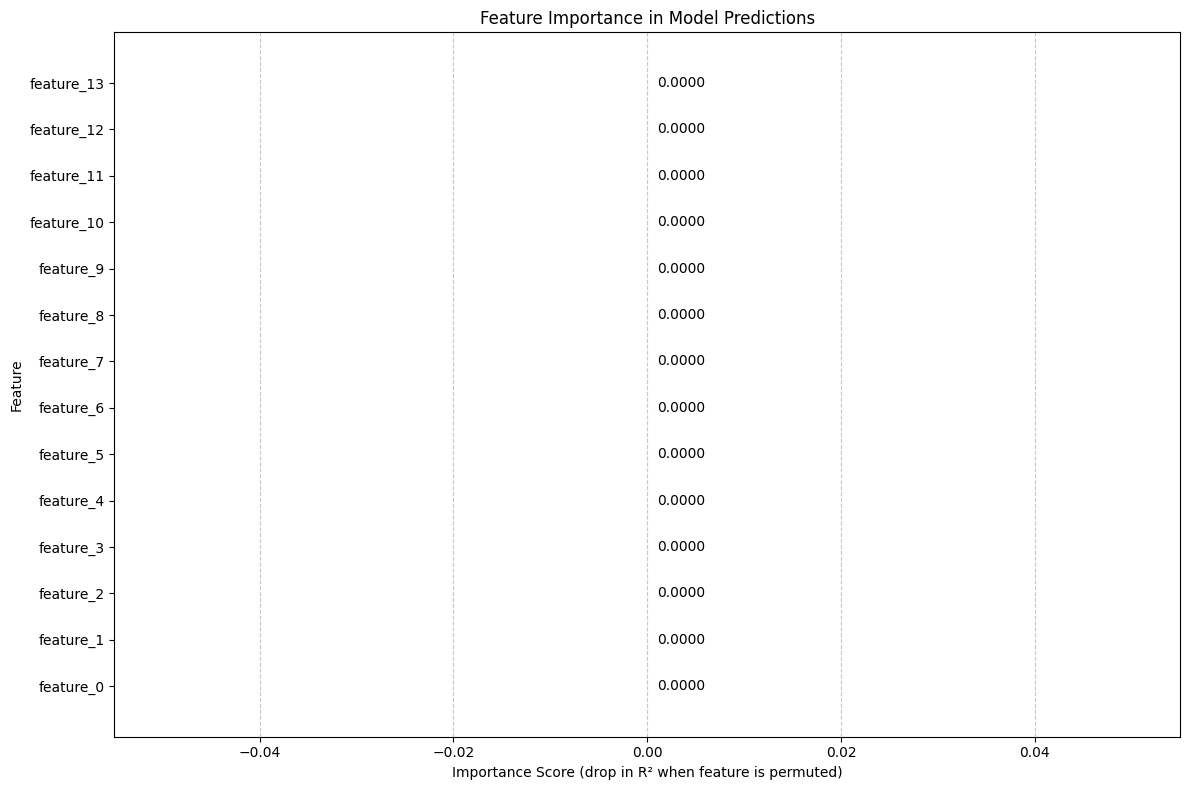


Feature importance plot saved to: predicted_figs/model_feature_importance.png

Interpretation of symbolic expression:
The model's connectivity prediction can be approximated by:
div(X1, X1)

Analyzing distributions of top features:


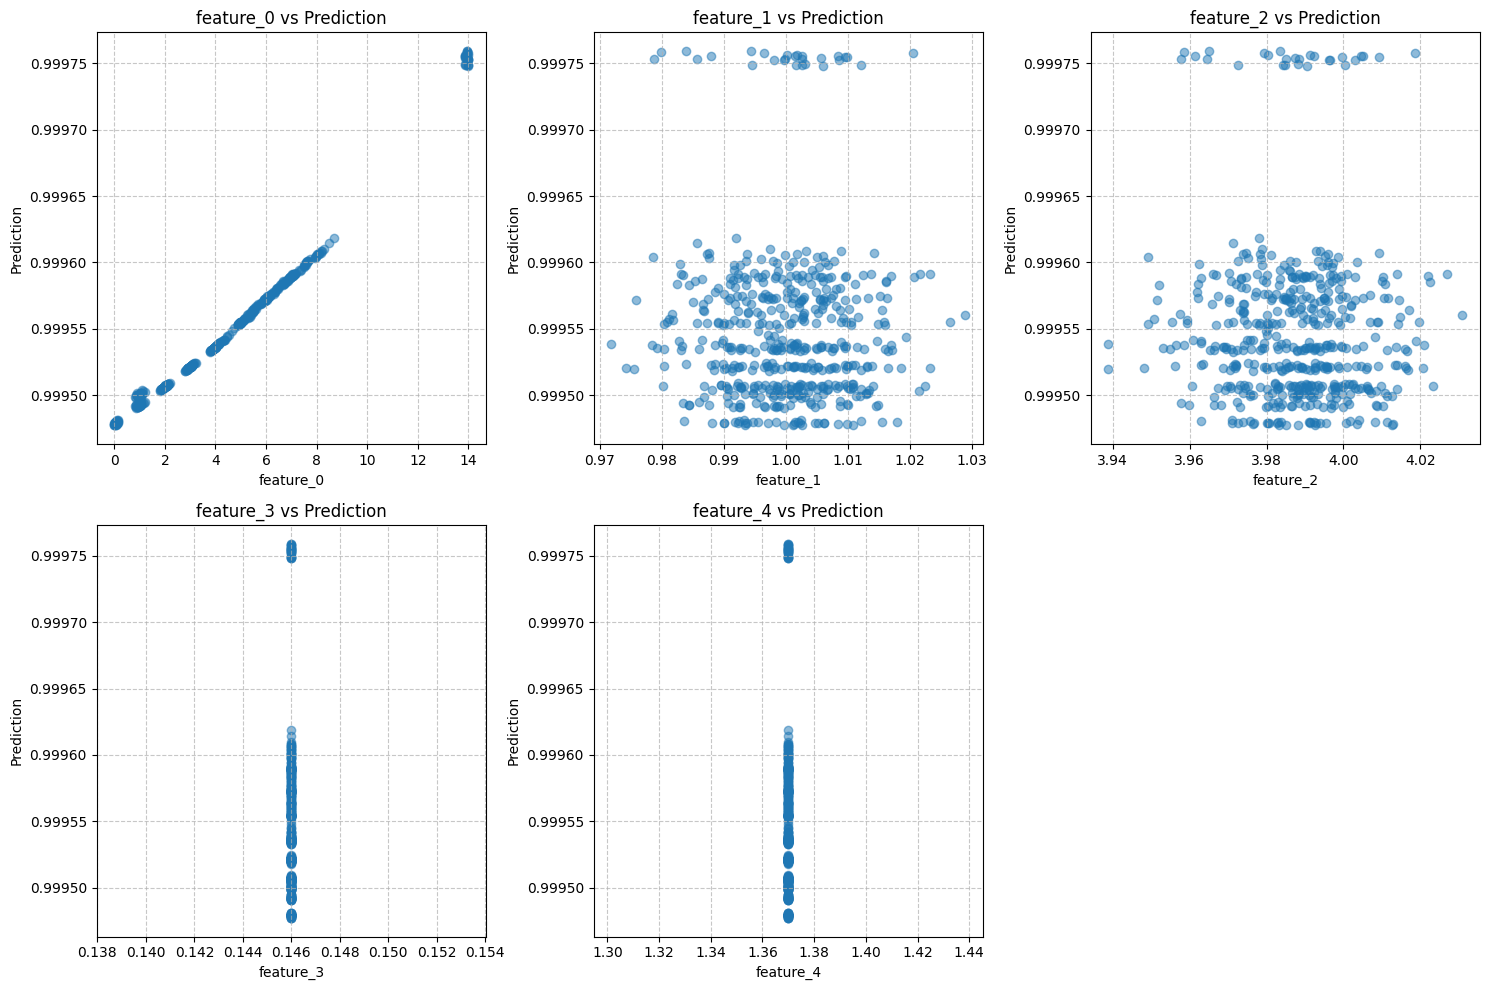

In [17]:
# Cell 6: Model Analysis with Symbolic Regression
import os
import numpy as np
import pandas as pd
import pickle
import torch
import networkx as nx
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Try to import gplearn - install if not available
try:
    from gplearn.genetic import SymbolicRegressor
except ImportError:
    print("Installing gplearn...")
    !pip install gplearn
    from gplearn.genetic import SymbolicRegressor

# Configuration
model_path = "model_after_sim_10.pth"  # Path to your trained model
input_folder = "/Users/sophia01px2019/Downloads/gartner_lab_rotation/GutSPV_tri2/graphs/11"
sample_size = 500  # Number of samples to generate for symbolic regression

# Define the correct model architecture with gating layer
class HGTModel(nn.Module):
    """
    HGT Model with multiple layers and gating layer matching the training architecture.
    """
    def __init__(self, d_model=128, num_heads=4, num_layers=4):
        super(HGTModel, self).__init__()
        self.layers = nn.ModuleList([HGTLayer(d_model, num_heads) for _ in range(num_layers)])
        
        self.edge_decoder = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Linear(d_model, 6)
        )
        self.conn_decoder = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Linear(d_model, 1)
        )
        self.temporal_encoder = TemporalEncoding(d_model)
        # Add the gating layer that was present in the training model
        self.gating_layer = nn.Linear(d_model, d_model)
    
    def forward(self, node_features, edge_index, edge_types, time_gaps):
        orig_features = node_features
        attn_weights_all = []
        shallow_features = None
        for i, layer in enumerate(self.layers):
            node_features, attn_weights = layer(
                node_features, edge_index, edge_types, time_gaps, self.temporal_encoder
            )
            attn_weights_all.append(attn_weights)
            if i == 1:  # after 2 layers
                shallow_features = node_features
        # Gated combination: combine updated features with original
        gate = torch.sigmoid(self.gating_layer(node_features))
        final_node_features = gate * node_features + (1 - gate) * orig_features
        pred_edge_features = self.edge_decoder(shallow_features)
        pred_conn_logits = self.conn_decoder(shallow_features)
        return final_node_features, pred_edge_features, pred_conn_logits, attn_weights_all

# Load the trained model
device = torch.device("cpu")
model = HGTModel(d_model=128, num_heads=4, num_layers=4).to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

# Function to load graphs from the input folder
def load_graph_samples(input_folder, max_samples=10):
    """Load a sample of graphs from the input folder for analysis"""
    graph_files = [f for f in os.listdir(input_folder) if f.startswith("graph_") and f.endswith(".gpickle")]
    if len(graph_files) > max_samples:
        # Use a representative sample across timepoints
        graph_files = sorted(graph_files)[::len(graph_files)//max_samples][:max_samples]
    
    graphs = {}
    for filename in graph_files:
        t = int(filename.split("_")[1].split(".")[0])
        graph_path = os.path.join(input_folder, filename)
        with open(graph_path, 'rb') as f:
            graphs[t] = pickle.load(f)
            print(f"Loaded graph at t={t}")
    
    return graphs

# Function to build a dataset of node features and model predictions
def build_model_prediction_dataset(model, graphs, sample_size=500):
    """
    Build a dataset containing node features and the model's connectivity predictions
    
    Args:
        model: The trained HGT model
        graphs: Dictionary of NetworkX graphs
        sample_size: Target number of samples to generate
        
    Returns:
        DataFrame containing feature values and model predictions
    """
    print("Building dataset from model predictions...")
    all_data = []
    
    with torch.no_grad():
        for t, G in graphs.items():
            # Create a rolling graph for this timepoint
            G_roll = build_rolling_graph(input_folder, t)
            
            # Convert the graph to tensors
            node_features, edge_index, time_gaps, edge_types, node_map = convert_graph_to_tensors(G_roll)
            
            # Get model predictions
            _, _, pred_conn_logits, _ = model(node_features, edge_index, edge_types, time_gaps)
            pred_conn_probs = torch.sigmoid(pred_conn_logits).cpu().numpy()
            
            # Extract features and predictions for each node
            for node_id, data in G.nodes(data=True):
                # Get the node features
                node_features_raw = data['features']
                
                # Find this node in the rolling graph's node map (the most recent instance)
                rolling_node = None
                for potential_node in node_map:
                    if isinstance(potential_node, tuple) and potential_node[0] == node_id:
                        if rolling_node is None or potential_node[1] > rolling_node[1]:
                            rolling_node = potential_node
                
                if rolling_node is None:
                    continue
                
                node_idx = node_map[rolling_node]
                pred_prob = pred_conn_probs[node_idx][0]
                
                # Create a record
                record = {
                    'time': t,
                    'node_id': node_id,
                    'prediction': pred_prob
                }
                
                # Add all raw features
                for i, feat_val in enumerate(node_features_raw):
                    record[f'feature_{i}'] = feat_val
                
                all_data.append(record)
                
                # If we have enough samples, stop
                if len(all_data) >= sample_size:
                    break
            
            if len(all_data) >= sample_size:
                break
    
    # Convert to DataFrame
    df = pd.DataFrame(all_data)
    print(f"Generated dataset with {len(df)} samples")
    
    return df

# Function to perform symbolic regression on model predictions
def analyze_model_with_symbolic_regression(df):
    """
    Use symbolic regression to find a mathematical expression 
    that approximates the model's prediction behavior
    
    Args:
        df: DataFrame with features and model predictions
        
    Returns:
        program: The best symbolic regression model
        importance_df: DataFrame with feature importance scores
    """
    # Prepare data
    feature_cols = [col for col in df.columns if col.startswith('feature_')]
    X = df[feature_cols]
    y = df['prediction']
    
    print(f"Running symbolic regression with {len(feature_cols)} features")
    
    # Train symbolic regression model
    est_gp = SymbolicRegressor(
        population_size=1000,
        generations=20,
        stopping_criteria=0.95,
        p_crossover=0.7,
        p_subtree_mutation=0.1,
        p_hoist_mutation=0.05,
        p_point_mutation=0.1,
        max_samples=0.9,
        verbose=1,
        parsimony_coefficient=0.01,
        random_state=42,
        function_set=('add', 'sub', 'mul', 'div', 'log', 'sqrt', 'abs')
    )
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Fit model
    est_gp.fit(X_train, y_train)
    
    # Evaluate
    y_pred = est_gp.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    print(f"Symbolic regression results:")
    print(f"Best expression: {est_gp._program}")
    print(f"R² score: {r2:.4f}")
    print(f"RMSE: {rmse:.4f}")
    
    # Analyze feature importance using permutation approach
    importance_df = analyze_feature_importance(est_gp, X, y, feature_cols)
    
    return est_gp, importance_df

def analyze_feature_importance(model, X, y, feature_names, n_repeats=5):
    """
    Analyze feature importance using permutation importance
    
    Args:
        model: Trained symbolic regression model
        X: Feature data
        y: Target data
        feature_names: List of feature names
        n_repeats: Number of times to repeat permutation
        
    Returns:
        DataFrame with feature importance scores
    """
    print("\nAnalyzing feature importance...")
    
    # Baseline score
    baseline_score = r2_score(y, model.predict(X))
    print(f"Baseline R² score: {baseline_score:.4f}")
    
    # Calculate feature importance
    importance_scores = []
    
    for feature in tqdm(feature_names):
        feature_scores = []
        
        for _ in range(n_repeats):
            # Create a copy of the data
            X_permuted = X.copy()
            
            # Permute the feature
            X_permuted[feature] = np.random.permutation(X_permuted[feature].values)
            
            # Calculate permuted score
            permuted_score = r2_score(y, model.predict(X_permuted))
            
            # Calculate importance
            importance = baseline_score - permuted_score
            feature_scores.append(importance)
        
        # Average importance
        avg_importance = np.mean(feature_scores)
        importance_scores.append({
            'feature': feature,
            'importance_score': avg_importance
        })
        
    # Convert to DataFrame and sort
    importance_df = pd.DataFrame(importance_scores)
    importance_df = importance_df.sort_values('importance_score', ascending=False).reset_index(drop=True)
    
    return importance_df

# Function to visualize feature importance
def plot_feature_importance(importance_df, title="Feature Importance in Model Predictions"):
    """
    Plot feature importance scores from symbolic regression
    
    Args:
        importance_df: DataFrame with feature importance scores
        title: Plot title
    """
    plt.figure(figsize=(12, 8))
    
    # Use only top 15 features if there are many
    if len(importance_df) > 15:
        plot_df = importance_df.head(15).copy()
    else:
        plot_df = importance_df.copy()
    
    # Sort for visualization
    plot_df = plot_df.sort_values('importance_score')
    
    # Create color gradient
    colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(plot_df)))
    
    # Plot horizontal bar chart
    plt.barh(plot_df['feature'], plot_df['importance_score'], color=colors)
    plt.xlabel('Importance Score (drop in R² when feature is permuted)')
    plt.ylabel('Feature')
    plt.title(title)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    
    # Add values on bars
    for i, value in enumerate(plot_df['importance_score']):
        plt.text(value + 0.001, i, f'{value:.4f}', va='center')
    
    plt.tight_layout()
    
    # Save the figure
    output_path = os.path.join("predicted_figs", "model_feature_importance.png")
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    
    plt.show()
    
    return output_path

# Main execution
print("Loading graph samples...")
graph_samples = load_graph_samples(input_folder)

print("\nGenerating model prediction dataset...")
prediction_df = build_model_prediction_dataset(model, graph_samples, sample_size=sample_size)

print("\nAnalyzing model with symbolic regression...")
program, importance_df = analyze_model_with_symbolic_regression(prediction_df)

print("\nTop features for predicting connectivity according to the model:")
print(importance_df.head(10))

print("\nPlotting feature importance...")
plot_path = plot_feature_importance(importance_df)

print(f"\nFeature importance plot saved to: {plot_path}")

# Interpret the symbolic expression
print("\nInterpretation of symbolic expression:")
print("The model's connectivity prediction can be approximated by:")
print(str(program))

# Analyze the most important feature distributions
print("\nAnalyzing distributions of top features:")
top_features = importance_df.head(5)['feature'].tolist()
plt.figure(figsize=(15, 10))
for i, feature in enumerate(top_features):
    plt.subplot(2, 3, i+1)
    plt.scatter(prediction_df[feature], prediction_df['prediction'], alpha=0.5)
    plt.title(f"{feature} vs Prediction")
    plt.xlabel(feature)
    plt.ylabel("Prediction")
    plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig(os.path.join("predicted_figs", "top_feature_distributions.png"), dpi=150, bbox_inches='tight')
plt.show()

## Noise / Momentum

In [ ]:
# Cell 1: Imports and Helper Functions
import os
import math
import pickle
import networkx as nx
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

def compute_two_hop_neighbors(G):
    """
    Compute the two-hop neighborhood for each node in a NetworkX graph.
    Returns a dictionary mapping node -> set(candidate nodes within 2 hops).
    """
    two_hop_neighbors = {}
    for node in G.nodes():
        # Compute all nodes within 2 hops.
        neighbors = nx.single_source_shortest_path_length(G, node, cutoff=2)
        candidate_nodes = set(neighbors.keys()) - {node}  # exclude self
        two_hop_neighbors[node] = candidate_nodes
    return two_hop_neighbors


# Cell 2: Define HGT Module Components
from torch_scatter import scatter_softmax, scatter_add

class TemporalEncoding(nn.Module):
    """
    Learnable temporal encoding: maps a scalar time difference to a d_model-dimensional embedding.
    """
    def __init__(self, d_model):
        super(TemporalEncoding, self).__init__()
        self.d_model = d_model
        self.embedding = nn.Linear(1, d_model)  # learnable mapping from ΔT (scalar) to embedding

    def forward(self, delta_t):
        # delta_t: Tensor of shape [E, 1]
        return self.embedding(delta_t)  # returns tensor of shape [E, d_model]

class HGTLayer(nn.Module):
    """
    A single HGT layer that aggregates information from all neighbors.
    By stacking two such layers, each node’s receptive field covers its two-hop neighborhood.
    """
    def __init__(self, d_model, num_heads):
        super(HGTLayer, self).__init__()
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        
        # Linear projections for query, key, value.
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        
        # Edge-type-specific transformation (using a default for all types)
        self.edge_attn = nn.ModuleDict({
            "default": nn.Linear(d_model, d_model)
        })
        
        # Final output projection.
        self.out_proj = nn.Linear(d_model, d_model)
        
    def forward(self, node_features, edge_index, edge_types, time_gaps, temporal_encoder):
        """
        Args:
          node_features: [N, d_model]
          edge_index: [2, E] (first row: source indices, second row: target indices)
          edge_types: list of length E (edge type names; use "default" if not specified)
          time_gaps: Tensor [E, 1] (ΔT for each edge)
          temporal_encoder: instance of TemporalEncoding.
        Returns:
          updated_node_features: [N, d_model]
          attn_weights: [E, num_heads]
        """
        N = node_features.size(0)
        E = edge_index.size(1)
        
        # Compute projections.
        Q = self.W_q(node_features)  # [N, d_model]
        K = self.W_k(node_features)  # [N, d_model]
        V = self.W_v(node_features)  # [N, d_model]
        
        # Reshape for multi-head attention.
        Q = Q.view(N, self.num_heads, self.d_k)  # [N, H, d_k]
        K = K.view(N, self.num_heads, self.d_k)
        V = V.view(N, self.num_heads, self.d_k)
        
        # Gather source and target projections.
        src = edge_index[0]  # [E]
        tgt = edge_index[1]  # [E]
        Q_tgt = Q[tgt]  # [E, H, d_k]
        K_src = K[src]  # [E, H, d_k]
        V_src = V[src]  # [E, H, d_k]
        
        # Incorporate temporal encoding into keys.
        time_emb = temporal_encoder(time_gaps)  # [E, d_model]
        time_emb = time_emb.view(E, self.num_heads, self.d_k)
        K_src = K_src + time_emb
        
        # Transform key via edge-type-specific transformation in a batched manner.
        K_transformed = torch.empty_like(K_src)  # [E, H, d_k]
        # Group indices by edge type.
        type_to_indices = {}
        for i, etype in enumerate(edge_types):
            type_to_indices.setdefault(etype, []).append(i)
        for etype, indices in type_to_indices.items():
            indices_tensor = torch.tensor(indices, device=K_src.device)
            batch_K = K_src[indices_tensor]  # shape: [num_edges, H, d_k]
            # Flatten the head dimension for transformation.
            batch_K_flat = batch_K.view(batch_K.size(0), -1)  # shape: [num_edges, d_model]
            # Use an explicit check instead of .get()
            if etype in self.edge_attn:
                trans = self.edge_attn[etype]
            else:
                trans = self.edge_attn["default"]
            transformed_flat = trans(batch_K_flat)  # shape: [num_edges, d_model]
            transformed = transformed_flat.view(batch_K.size(0), self.num_heads, self.d_k)  # [num_edges, H, d_k]
            K_transformed[indices_tensor] = transformed
        
        # Compute scaled dot-product attention scores.
        scores = (Q_tgt * K_transformed).sum(dim=-1) / math.sqrt(self.d_k)  # [E, H]
        
        # For each target node, apply softmax over incoming edges.
        attn_weights = self._edge_softmax(scores, tgt, N)  # [E, H]
        
        # Weighted sum of source values.
        messages = attn_weights.unsqueeze(-1) * V_src  # [E, H, d_k]
        aggregated = self._scatter_sum(messages, tgt, N)  # [N, H, d_k]
        aggregated = aggregated.view(N, self.d_model)
        
        updated = self.out_proj(aggregated) + node_features  # residual connection
        return updated, attn_weights

    def _edge_softmax(self, scores, tgt, N):
        # scores: [E, H]
        # tgt: [E] indicates the target node for each edge.
        # This applies softmax over the 0th dimension, grouped by tgt.
        attn_weights = scatter_softmax(scores, tgt, dim=0)
        return attn_weights

    def _scatter_sum(self, messages, tgt, N):
        """
        Sums messages for each target node.
        """
        return scatter_add(messages, tgt, dim=0, dim_size=N)

#OLD d_model = 128 FUNCTION DEFINITION 
class HGTModelOld(nn.Module):
    """
    HGT Model that predicts the next graph's properties from the current graph.
    Each node's embedding is used to predict its outgoing edge features and connection scores.
    """
    def __init__(self, d_model=128, num_heads=4, num_layers=2):
        super(HGTModelOld, self).__init__()
        self.layers = nn.ModuleList([HGTLayer(d_model, num_heads) for _ in range(num_layers)])
        
        # Decoder head for predicting edge features (assume 6 edge properties).
        self.edge_decoder = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Linear(d_model, 6)
        )
        # Connection decoder (produces a raw logit).
        self.conn_decoder = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Linear(d_model, 1)
        )
        # No temperature scaling or sigmoid.
        self.temporal_encoder = TemporalEncoding(d_model)
    
    def forward(self, node_features, edge_index, edge_types, time_gaps):
        """
        Args:
          node_features: [N, d_model]
          edge_index: [2, E]
          edge_types: list of length E (if not provided, use "default")
          time_gaps: [E, 1] tensor of time differences for each edge.
        Returns:
          updated node features, predicted edge features (per node),
          raw connection logits (per node), and list of attention weights.
        """
        attn_weights_all = []
        for layer in self.layers:
            node_features, attn_weights = layer(node_features, edge_index, edge_types, time_gaps, self.temporal_encoder)
            attn_weights_all.append(attn_weights)
        
        pred_edge_features = self.edge_decoder(node_features)  # [N, 6]
        # Raw connection logits.
        pred_conn_logits = self.conn_decoder(node_features)      # [N, 1]
        return node_features, pred_edge_features, pred_conn_logits, attn_weights_all

# Cell 3: Function to load a graph object
import os
import pickle
import networkx as nx

def load_graph(sim_number, timepoint, base_dir="graphs"):
    """
    Load a graph object from file.
    Args:
      sim_number: str or int indicating simulation number (e.g., "1")
      timepoint: str or int indicating the timepoint (e.g., "0")
      base_dir: base directory containing simulation folders.
    Returns:
      G: the loaded NetworkX graph.
    """
    graph_path = os.path.join(base_dir, str(sim_number), f"graph_{timepoint}.gpickle")
    with open(graph_path, 'rb') as f:
        G = pickle.load(f)
    print(f"[DEBUG] Loaded graph from: {graph_path}")
    #print(f"[DEBUG] Graph has {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")
    return G

# Test the function (debug output)
G_test = load_graph(sim_number="1", timepoint="0")

# Cell 4: Function to convert a NetworkX graph to tensors.
import torch
import torch.nn as nn

def convert_graph_to_tensors(G, d_model=128):
    """
    Converts a NetworkX graph into tensors for model input.
    Returns:
      node_features: [N, d_model] tensor
      edge_index: [2, E] tensor of indices
      time_gaps: [E, 1] tensor of ΔT for each edge
      edge_types: list of length E (default type: "default")
      node_id_to_index: mapping from graph node id to tensor index
    """
    node_features_list = []
    node_ids = []
    node_time = {}
    for node_id, attr in G.nodes(data=True):
        feat = torch.tensor(attr.get("features"), dtype=torch.float)
        node_features_list.append(feat)
        node_ids.append(node_id)
        node_time[node_id] = attr.get("t", 0)
    node_features = torch.stack(node_features_list, dim=0)
    N, d_in = node_features.shape
    #print(f"[DEBUG] Node features tensor shape: {node_features.shape}")
    if d_in != d_model:
        # Simple projection layer
        proj = nn.Linear(d_in, d_model)
        node_features = proj(node_features)
        #print(f"[DEBUG] Projected node features to shape: {node_features.shape}")
    node_id_to_index = {node_id: i for i, node_id in enumerate(node_ids)}
    edge_src = []
    edge_tgt = []
    time_gaps_list = []
    edge_types = []  # All edges are of type "default"
    for u, v, attr in G.edges(data=True):
        if u in node_id_to_index and v in node_id_to_index:
            edge_src.append(node_id_to_index[u])
            edge_tgt.append(node_id_to_index[v])
            dt = node_time[v] - node_time[u]
            time_gaps_list.append(dt)
            edge_types.append("default")
        else:
            print(f"[WARNING] Edge ({u}, {v}) not in node mapping.")
    if len(edge_src) > 0:
        edge_index = torch.tensor([edge_src, edge_tgt], dtype=torch.long)
        time_gaps = torch.tensor(time_gaps_list, dtype=torch.float).unsqueeze(1)
    else:
        edge_index = torch.empty((2, 0), dtype=torch.long)
        time_gaps = torch.empty((0, 1), dtype=torch.float)
    #print(f"[DEBUG] Edge index shape: {edge_index.shape}")
    #print(f"[DEBUG] Time gaps shape: {time_gaps.shape}")
    return node_features, edge_index, time_gaps, edge_types, node_id_to_index

# Test conversion function with loaded graph.
node_feats, edge_idx, time_gaps, e_types, node_map = convert_graph_to_tensors(G_test, d_model=128)

# Cell 7: Revised Training Loop with Pre-loaded Graph Tensors and Parallel Loss Minimization

import glob
import torch.optim as optim

# Set device.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[DEBUG] Using device: {device}")

# Instantiate the model (assume HGTModel is defined as above) and move it to device.
num_heads = 4
num_layers = 2
model = HGTModelOld(d_model=128, num_heads=num_heads, num_layers=num_layers)
model.to(device)

optimizer = optim.AdamW(model.parameters(), lr=5e-3)
criterion_mse = nn.MSELoss()
criterion_bce = nn.BCEWithLogitsLoss()

def extract_time(f):
    base = os.path.basename(f)
    t_str = base.split("_")[1].split(".")[0]
    return int(t_str)

# Loop over simulation folders (1 to 10)
for sim_num in range(1, 11):
    sim_folder = os.path.join("graphs", str(sim_num))
    graph_files = glob.glob(os.path.join(sim_folder, "graph_*.gpickle"))
    if not graph_files:
        print(f"[DEBUG] No graphs found in {sim_folder}. Skipping simulation {sim_num}.")
        continue
    graph_files = sorted(graph_files, key=extract_time)
    print(f"\n--- Training Simulation {sim_num} with {len(graph_files)} timepoints ---")
    
    # Pre-load and convert all graphs for this simulation into tensors.
    simulation_data = []
    for gf in graph_files:
        G = load_graph(sim_num, extract_time(gf))
        node_feats, edge_idx, time_gaps, e_types, node_map = convert_graph_to_tensors(G, d_model=128)
        # Move tensors to device.
        simulation_data.append({
            "node_feats": node_feats.to(device),
            "edge_idx": edge_idx.to(device),
            "time_gaps": time_gaps.to(device),
            "e_types": e_types,
            "node_map": node_map,
            "graph": G  # keeping original graph for computing connectivity and edge targets.
        })
    
    # Training: iterate over consecutive time transitions.
    for i in range(len(simulation_data) - 1):
        current_data = simulation_data[i]
        next_data = simulation_data[i+1]
        
        # Extract tensors for current and next timepoints.
        node_feats_current = current_data["node_feats"]
        edge_idx_current = current_data["edge_idx"]
        time_gaps_current = current_data["time_gaps"]
        e_types_current = current_data["e_types"]
        
        node_feats_next = next_data["node_feats"]
        G_next = next_data["graph"]
        
        model.train()
        optimizer.zero_grad()
        
        # Forward pass: predict next state based on current graph.
        updated_node_features, pred_edge_features, pred_conn_logits, _ = model(
            node_feats_current, edge_idx_current, e_types_current, time_gaps_current
        )
        
        # Loss 1: Feature Loss (MSE between predicted updated node features and next graph's node features)
        loss_features = criterion_mse(updated_node_features, node_feats_next)
        
        # Loss 2: Connectivity Loss
        connectivity_targets = []
        # We assume that the node order in next_data is consistent.
        for node in G_next.nodes():
            # For directed graphs, target=1 if node has any outgoing edge.
            if isinstance(G_next, nx.DiGraph):
                conn = 1.0 if G_next.out_degree(node) > 0 else 0.0
            else:
                conn = 1.0 if G_next.degree(node) > 0 else 0.0
            connectivity_targets.append(conn)
        connectivity_targets = torch.tensor(connectivity_targets, dtype=torch.float).unsqueeze(1).to(device)
        loss_conn = criterion_bce(pred_conn_logits, connectivity_targets)
        
        # Loss 3: Edge Feature Loss: For each node, average outgoing edge features in next graph.
        target_edge_features_list = []
        for node in G_next.nodes():
            outgoing_edges = []
            for u, v, attr in G_next.out_edges(node, data=True):
                # Assume edge attribute "features" exists.
                outgoing_edges.append(np.array(attr.get("features")))
            if outgoing_edges:
                avg_feat = np.mean(outgoing_edges, axis=0)
                target_edge_features_list.append(torch.tensor(avg_feat, dtype=torch.float))
            else:
                target_edge_features_list.append(torch.zeros(6))
        target_edge_features = torch.stack(target_edge_features_list, dim=0).to(device)
        loss_edge = criterion_mse(pred_edge_features, target_edge_features)
        
        # Combine losses and perform a single backward pass.
        #optimizer.zero_grad()
        loss_features.backward(retain_graph=True) if (1e-4 == 1.0) else ( (loss_features * 1e-4).backward(retain_graph=True) )
        loss_conn.backward(retain_graph=True) if (5e-3 == 1.0) else ( (loss_conn * 5e-3).backward(retain_graph=True) )
        loss_edge.backward() if (1e-5 == 1.0) else ( (loss_edge * 1e-4).backward() )
        optimizer.step()
        
        print(f"Sim {sim_num}, Time {extract_time(graph_files[i])} -> {extract_time(graph_files[i+1])} | "
              f"Losses: Feat {loss_features.item():.4f}, Conn {loss_conn.item():.4f}, Edge {loss_edge.item():.4f}")
    
    print(f"Completed training simulation {sim_num}.\n")


[DEBUG] Loaded graph from: graphs/1/graph_0.gpickle
[DEBUG] Using device: cpu

--- Training Simulation 1 with 501 timepoints ---
[DEBUG] Loaded graph from: graphs/1/graph_0.gpickle
[DEBUG] Loaded graph from: graphs/1/graph_4.gpickle
[DEBUG] Loaded graph from: graphs/1/graph_8.gpickle
[DEBUG] Loaded graph from: graphs/1/graph_12.gpickle
[DEBUG] Loaded graph from: graphs/1/graph_16.gpickle
[DEBUG] Loaded graph from: graphs/1/graph_20.gpickle
[DEBUG] Loaded graph from: graphs/1/graph_24.gpickle
[DEBUG] Loaded graph from: graphs/1/graph_28.gpickle
[DEBUG] Loaded graph from: graphs/1/graph_32.gpickle
[DEBUG] Loaded graph from: graphs/1/graph_36.gpickle
[DEBUG] Loaded graph from: graphs/1/graph_40.gpickle
[DEBUG] Loaded graph from: graphs/1/graph_44.gpickle
[DEBUG] Loaded graph from: graphs/1/graph_48.gpickle
[DEBUG] Loaded graph from: graphs/1/graph_52.gpickle
[DEBUG] Loaded graph from: graphs/1/graph_56.gpickle
[DEBUG] Loaded graph from: graphs/1/graph_60.gpickle
[DEBUG] Loaded graph from:

KeyboardInterrupt: 

In [ ]:
# 3 separate models 

In [6]:
import os
import math
import pickle
import networkx as nx
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch_scatter import scatter_softmax

#########################################
# Provided Definitions
#########################################

def compute_two_hop_neighbors(G):
    """
    Compute the two-hop neighborhood for each node in a NetworkX graph.
    Returns a dictionary mapping node -> set(candidate nodes within 2 hops).
    """
    two_hop_neighbors = {}
    for node in G.nodes():
        # Compute all nodes within 2 hops.
        neighbors = nx.single_source_shortest_path_length(G, node, cutoff=2)
        candidate_nodes = set(neighbors.keys()) - {node}  # exclude self
        two_hop_neighbors[node] = candidate_nodes
    return two_hop_neighbors

# Cell 2: Define HGT Module Components

class TemporalEncoding(nn.Module):
    """
    Learnable temporal encoding: maps a scalar time difference to a d_model-dimensional embedding.
    """
    def __init__(self, d_model):
        super(TemporalEncoding, self).__init__()
        self.d_model = d_model
        self.embedding = nn.Linear(1, d_model)  # learnable mapping from ΔT (scalar) to embedding

    def forward(self, delta_t):
        # delta_t: Tensor of shape [E, 1]
        return self.embedding(delta_t)  # returns tensor of shape [E, d_model]

class HGTLayer(nn.Module):
    """
    A single HGT layer that aggregates information from all neighbors.
    By stacking two such layers, each node’s receptive field covers its two-hop neighborhood.
    """
    def __init__(self, d_model, num_heads):
        super(HGTLayer, self).__init__()
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        
        # Linear projections for query, key, value.
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        
        # Edge-type-specific transformation (using a default for all types)
        self.edge_attn = nn.ModuleDict({
            "default": nn.Linear(d_model, d_model)
        })
        
        # Final output projection.
        self.out_proj = nn.Linear(d_model, d_model)
        
    def forward(self, node_features, edge_index, edge_types, time_gaps, temporal_encoder):
        """
        Args:
          node_features: [N, d_model]
          edge_index: [2, E] (first row: source indices, second row: target indices)
          edge_types: list of length E (edge type names; use "default" if not specified)
          time_gaps: Tensor [E, 1] (ΔT for each edge)
          temporal_encoder: instance of TemporalEncoding.
        Returns:
          updated_node_features: [N, d_model]
          attn_weights: [E, num_heads]
        """
        N = node_features.size(0)
        E = edge_index.size(1)
        
        # Compute projections.
        Q = self.W_q(node_features)  # [N, d_model]
        K = self.W_k(node_features)  # [N, d_model]
        V = self.W_v(node_features)  # [N, d_model]
        
        # Reshape for multi-head attention.
        Q = Q.view(N, self.num_heads, self.d_k)  # [N, H, d_k]
        K = K.view(N, self.num_heads, self.d_k)
        V = V.view(N, self.num_heads, self.d_k)
        
        # Gather source and target projections.
        src = edge_index[0]  # [E]
        tgt = edge_index[1]  # [E]
        Q_tgt = Q[tgt]  # [E, H, d_k]
        K_src = K[src]  # [E, H, d_k]
        V_src = V[src]  # [E, H, d_k]
        
        # Incorporate temporal encoding into keys.
        time_emb = temporal_encoder(time_gaps)  # [E, d_model]
        time_emb = time_emb.view(E, self.num_heads, self.d_k)
        K_src = K_src + time_emb
        
        # Transform key via edge-type-specific transformation.
        K_transformed = []
        for i, etype in enumerate(edge_types):
            if etype in self.edge_attn:
                trans = self.edge_attn[etype]
            else:
                trans = self.edge_attn["default"]
            transformed = trans(K_src[i].view(1, -1)).view(self.num_heads, self.d_k)
            K_transformed.append(transformed)
        K_transformed = torch.stack(K_transformed, dim=0)  # [E, H, d_k]
        
        # Compute scaled dot-product attention scores.
        scores = (Q_tgt * K_transformed).sum(dim=-1) / math.sqrt(self.d_k)  # [E, H]
        
        # For each target node, apply softmax over incoming edges.
        attn_weights = self._edge_softmax(scores, tgt, N)  # [E, H]
        
        # Weighted sum of source values.
        messages = attn_weights.unsqueeze(-1) * V_src  # [E, H, d_k]
        aggregated = self._scatter_sum(messages, tgt, N)  # [N, H, d_k]
        aggregated = aggregated.view(N, self.d_model)
        
        updated = self.out_proj(aggregated) + node_features  # residual connection
        return updated, attn_weights

    def _edge_softmax(self, scores, tgt, N):
        # scores: [E, H]
        # tgt: [E] indicates the target node for each edge.
        # This applies softmax over the 0th dimension, grouped by tgt.
        attn_weights = scatter_softmax(scores, tgt, dim=0)
        return attn_weights

    def _scatter_sum(self, messages, tgt, N):
        """
        Sums messages for each target node.
        """
        aggregated = torch.zeros(N, self.num_heads, self.d_k, device=messages.device)
        for i, t in enumerate(tgt):
            aggregated[t] += messages[i]
        return aggregated

class HGTModel(nn.Module):
    """
    HGT Model that predicts the next graph's properties from the current graph.
    Each node's embedding is used to predict its outgoing edge features and connection scores.
    """
    def __init__(self, d_model=128, num_heads=4, num_layers=2):
        super(HGTModel, self).__init__()
        self.layers = nn.ModuleList([HGTLayer(d_model, num_heads) for _ in range(num_layers)])
        
        # Decoder head for predicting edge features (assume 6 edge properties).
        self.edge_decoder = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Linear(d_model, 6)
        )
        # Connection decoder (produces a raw logit).
        self.conn_decoder = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Linear(d_model, 1)
        )
        # No temperature scaling or sigmoid.
        self.temporal_encoder = TemporalEncoding(d_model)
    
    def forward(self, node_features, edge_index, edge_types, time_gaps):
        """
        Args:
          node_features: [N, d_model]
          edge_index: [2, E]
          edge_types: list of length E (if not provided, use "default")
          time_gaps: [E, 1] tensor of time differences for each edge.
        Returns:
          updated node features, predicted edge features (per node),
          raw connection logits (per node), and list of attention weights.
        """
        attn_weights_all = []
        for layer in self.layers:
            node_features, attn_weights = layer(node_features, edge_index, edge_types, time_gaps, self.temporal_encoder)
            attn_weights_all.append(attn_weights)
        
        pred_edge_features = self.edge_decoder(node_features)  # [N, 6]
        # Raw connection logits.
        pred_conn_logits = self.conn_decoder(node_features)      # [N, 1]
        return node_features, pred_edge_features, pred_conn_logits, attn_weights_all

#########################################
# Utility Function: Convert Graph to Tensors
#########################################
def convert_graph_to_tensors(G, d_model=128):
    """
    Converts a NetworkX graph into tensors for model input.
    Returns:
      node_features: [N, d_model] tensor
      edge_index: [2, E] tensor of indices
      time_gaps: [E, 1] tensor of ΔT for each edge
      edge_types: list of length E (default type: "default")
      node_id_to_index: mapping from graph node id to tensor index
    """
    node_features_list = []
    node_ids = []
    node_time = {}
    for node_id, attr in G.nodes(data=True):
        feat = torch.tensor(attr.get("features"), dtype=torch.float)
        node_features_list.append(feat)
        node_ids.append(node_id)
        node_time[node_id] = attr.get("t", 0)
    node_features = torch.stack(node_features_list, dim=0)
    N, d_in = node_features.shape
    # If d_in != d_model, you may wish to project features (here we assume they already match)
    node_id_to_index = {node_id: i for i, node_id in enumerate(node_ids)}
    edge_src = []
    edge_tgt = []
    time_gaps_list = []
    edge_types = []  # All edges are assumed to be "default"
    for u, v, attr in G.edges(data=True):
        if u in node_id_to_index and v in node_id_to_index:
            edge_src.append(node_id_to_index[u])
            edge_tgt.append(node_id_to_index[v])
            dt = node_time[v] - node_time[u]
            time_gaps_list.append(dt)
            edge_types.append("default")
        else:
            print(f"[WARNING] Edge ({u}, {v}) not in node mapping.")
    if len(edge_src) > 0:
        edge_index = torch.tensor([edge_src, edge_tgt], dtype=torch.long)
        time_gaps = torch.tensor(time_gaps_list, dtype=torch.float).unsqueeze(1)
    else:
        edge_index = torch.empty((2, 0), dtype=torch.long)
        time_gaps = torch.empty((0, 1), dtype=torch.float)
    return node_features, edge_index, time_gaps, edge_types, node_id_to_index

#########################################
# Test-Time Prediction and Visualization Script
#########################################

# Specify paths for input gpickles (test set) and the saved model.
input_folder = "/Users/sophia01px2019/Downloads/gartner_lab_rotation/GutSPV_tri2/graphs/11"
model_path = "/Users/sophia01px2019/Downloads/gartner_lab_rotation/GutSPV_tri2/5e-3-model_after_sim_3.pth"

# Instantiate the model and load saved parameters.
# (This assumes the saved model was trained with d_model=128, num_heads=4, and num_layers=2.)
model = HGTModel(d_model=128, num_heads=4, num_layers=2)
model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))
model.eval()  # Set to evaluation mode

# Gather list of test graph files; assume filenames like "graph_<time>.gpickle"
def extract_time(f):
    base = os.path.basename(f)
    t_str = base.split("_")[1].split(".")[0]
    return int(t_str)

all_files = [os.path.join(input_folder, f) for f in os.listdir(input_folder) if f.endswith(".gpickle")]
test_files = sorted(all_files, key=extract_time)
# Filter for timepoints from t=0 to t=2000
test_files = [f for f in test_files if extract_time(f) <= 2000]

# Loop over each test graph and predict connectivity.
for gf in test_files:
    # Load the graph.
    with open(gf, 'rb') as f:
        G = pickle.load(f)
    
    # Convert graph to tensors.
    node_features, edge_index, time_gaps, edge_types, node_id_to_index = convert_graph_to_tensors(G, d_model=128)
    
    # Forward pass through the model.
    with torch.no_grad():
        _, _, pred_conn_logits, _ = model(node_features, edge_index, edge_types, time_gaps)
    # Apply sigmoid to convert logits to probabilities.
    pred_conn_prob = torch.sigmoid(pred_conn_logits).squeeze().cpu().numpy()
    
    # Determine node colors based on cell type.
    # Assumes that each node's "features" attribute holds a feature vector and the first element is the cell type.
    node_colors = {}
    for node in G.nodes():
        features = G.nodes[node].get("features", None)
        if features is not None:
            cell_type = features[0]
            # Two cell types: use blue for type 0 and red for type 1.
            color = 'blue' if cell_type == 0 else 'red'
        else:
            color = 'gray'
        node_colors[node] = color
    
    # Prepare node sizes based on predicted connectivity.
    # Assumes that nodes are ordered according to the node_id_to_index mapping.
    nodes_sorted = sorted(G.nodes(), key=lambda x: node_id_to_index[x])
    node_sizes = []
    for i, node in enumerate(nodes_sorted):
        # Scale node size (adjust scaling as needed).
        prob = pred_conn_prob[i]
        size = 300 + 700 * prob
        node_sizes.append(size)
    
    # Compute the Kamada-Kawai layout.
    pos = nx.kamada_kawai_layout(G)
    
    # Plot the graph.
    plt.figure(figsize=(8, 6))
    colors = [node_colors[node] for node in G.nodes()]
    nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=node_sizes)
    nx.draw_networkx_edges(G, pos, alpha=0.5)
    plt.title(f"Graph at time {extract_time(gf)}: Predicted Connectivity")
    plt.axis("off")
    plt.show()


/var/folders/_2/xkrjp2q52cn8mxmjrvp731500000gq/T/ipykernel_57500/4246033361.py:248: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path

RuntimeError: Error(s) in loading state_dict for HGTModel:
	Unexpected key(s) in state_dict: "gating_layer.weight", "gating_layer.bias", "layers.2.W_q.weight", "layers.2.W_q.bias", "layers.2.W_k.weight", "layers.2.W_k.bias", "layers.2.W_v.weight", "layers.2.W_v.bias", "layers.2.edge_attn.default.weight", "layers.2.edge_attn.default.bias", "layers.2.out_proj.weight", "layers.2.out_proj.bias", "layers.3.W_q.weight", "layers.3.W_q.bias", "layers.3.W_k.weight", "layers.3.W_k.bias", "layers.3.W_v.weight", "layers.3.W_v.bias", "layers.3.edge_attn.default.weight", "layers.3.edge_attn.default.bias", "layers.3.out_proj.weight", "layers.3.out_proj.bias". 

In [35]:
# Cell 1: Imports and Basic Setup
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import copy
import time
import numpy as np
import scipy.sparse as sp
import pandas as pd
from collections import defaultdict
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sb
import dill
from functools import partial
import multiprocessing as mp

# PyTorch Geometric imports:
from torch_geometric.nn import GCNConv, GATConv, MessagePassing
from torch_geometric.nn.inits import glorot, uniform
from torch_geometric.utils import softmax, to_undirected, sparse_mx_to_torch_sparse_tensor


ImportError: cannot import name 'sparse_mx_to_torch_sparse_tensor' from 'torch_geometric.utils' (/Users/sophia01px2019/miniforge3/envs/new_env/lib/python3.9/site-packages/torch_geometric/utils/__init__.py)

In [ ]:
# Cell 2: Relative Temporal Encoding Module
class RelTemporalEncoding(nn.Module):
    """
    Implements a sinusoid-based temporal encoding.
    This module adds a learned projection of a sinusoidal embedding
    (indexed by a discretized timestamp) to the input vector.
    """
    def __init__(self, n_hid, max_len=240, dropout=0.2):
        super(RelTemporalEncoding, self).__init__()
        position = torch.arange(0., max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, n_hid, 2) * -(math.log(10000.0) / n_hid))
        emb = nn.Embedding(max_len, n_hid)
        emb.weight.data[:, 0::2] = torch.sin(position * div_term) / math.sqrt(n_hid)
        emb.weight.data[:, 1::2] = torch.cos(position * div_term) / math.sqrt(n_hid)
        emb.requires_grad = False
        self.emb = emb
        self.lin = nn.Linear(n_hid, n_hid)
    def forward(self, x, t):
        # x: input vector, t: time index (integer tensor)
        return x + self.lin(self.emb(t))


In [ ]:
# Cell 3: HGT and DenseHGT Convolution Modules

class HGTConv(MessagePassing):
    def __init__(self, in_dim, out_dim, num_types, num_relations, n_heads, dropout=0.2, use_norm=True, use_RTE=True, **kwargs):
        super(HGTConv, self).__init__(node_dim=0, aggr='add', **kwargs)
        self.in_dim = in_dim
        self.out_dim = out_dim
        self.num_types = num_types
        self.num_relations = num_relations
        self.total_rel = num_types * num_relations * num_types
        self.n_heads = n_heads
        self.d_k = out_dim // n_heads
        self.sqrt_dk = math.sqrt(self.d_k)
        self.use_norm = use_norm
        self.use_RTE = use_RTE
        self.att = None

        self.k_linears = nn.ModuleList([nn.Linear(in_dim, out_dim) for _ in range(num_types)])
        self.q_linears = nn.ModuleList([nn.Linear(in_dim, out_dim) for _ in range(num_types)])
        self.v_linears = nn.ModuleList([nn.Linear(in_dim, out_dim) for _ in range(num_types)])
        self.a_linears = nn.ModuleList([nn.Linear(out_dim, out_dim) for _ in range(num_types)])
        if use_norm:
            self.norms = nn.ModuleList([nn.LayerNorm(out_dim) for _ in range(num_types)])
        
        self.relation_pri = nn.Parameter(torch.ones(num_relations, n_heads))
        self.relation_att = nn.Parameter(torch.Tensor(num_relations, n_heads, self.d_k, self.d_k))
        self.relation_msg = nn.Parameter(torch.Tensor(num_relations, n_heads, self.d_k, self.d_k))
        self.skip = nn.Parameter(torch.ones(num_types))
        self.drop = nn.Dropout(dropout)
        
        if self.use_RTE:
            self.emb = RelTemporalEncoding(in_dim)
        
        glorot(self.relation_att)
        glorot(self.relation_msg)
        
    def forward(self, node_inp, node_type, edge_index, edge_type, edge_time):
        return self.propagate(edge_index, node_inp=node_inp, node_type=node_type,
                              edge_type=edge_type, edge_time=edge_time)
    
    def message(self, edge_index_i, node_inp_i, node_inp_j, node_type_i, node_type_j, edge_type, edge_time):
        # edge_type is now a continuous tensor, e.g. [0.06, 0.08, ...]
        data_size = edge_index_i.size(0)
        res_att = torch.zeros(data_size, self.n_heads).to(node_inp_i.device)
        res_msg = torch.zeros(data_size, self.n_heads, self.d_k).to(node_inp_i.device)
        
        # Instead of iterating over discrete relation types, process all edges in one pass.
        # Optionally, if you still want to group by source and target node types, you can keep those loops.
        for source_type in range(self.num_types):
            sb = (node_type_j == int(source_type))
            k_linear = self.k_linears[source_type]
            v_linear = self.v_linears[source_type]
            for target_type in range(self.num_types):
                tb = (node_type_i == int(target_type)) & sb
                if tb.sum() == 0:
                    continue
                q_linear = self.q_linears[target_type]
                # Instead of looping over relation types, we assume every edge now carries a continuous value.
                idx = tb  # Using all edges in this subgroup.
                if idx.sum() == 0:
                    continue
                target_node_vec = node_inp_i[idx]
                source_node_vec = node_inp_j[idx]
                if self.use_RTE:
                    source_node_vec = self.emb(source_node_vec, edge_time[idx])
                # Compute query and key matrices.
                q_mat = q_linear(target_node_vec).view(-1, self.n_heads, self.d_k)
                k_mat = k_linear(source_node_vec).view(-1, self.n_heads, self.d_k)
                # Here, use the continuous edge type value as a scaling factor.
                # For example, assume we use the first candidate relation parameters (index 0).
                scaling = edge_type[idx].unsqueeze(-1).unsqueeze(-1)  # shape: (num_edges, 1, 1)
                # Multiply the candidate relation attention parameters by the continuous scaling factor.
                weighted_relation_att = scaling * self.relation_att[0]  # shape: (num_edges, n_heads, d_k, d_k)
                # We need to apply the relation transformation to the key:
                # Here we perform a batched matrix multiplication.
                # First, reshape weighted_relation_att so that it matches the batch dimensions.
                weighted_relation_att = weighted_relation_att  # assume each edge uses its own scaling
                # Multiply key matrices by weighted relation parameters:
                # To do this properly, we need to iterate or use advanced indexing if the relation parameters vary per edge.
                # For simplicity, assume that all edges use the same candidate (and scaling varies per edge).
                weighted_k = torch.bmm(k_mat.view(-1, self.d_k), 
                                    self.relation_att[0].repeat(k_mat.size(0), 1, 1))  # shape: (num_edges * n_heads, d_k)
                weighted_k = weighted_k.view(-1, self.n_heads, self.d_k)
                # Then compute the attention scores.
                res_att[idx] = (q_mat * weighted_k).sum(dim=-1) * self.relation_pri[0] / self.sqrt_dk
                # Similarly for message passing:
                v_mat = v_linear(source_node_vec).view(-1, self.n_heads, self.d_k)
                weighted_relation_msg = scaling * self.relation_msg[0]
                weighted_v = torch.bmm(v_mat.view(-1, self.d_k), 
                                    self.relation_msg[0].repeat(v_mat.size(0), 1, 1))
                weighted_v = weighted_v.view(-1, self.n_heads, self.d_k)
                res_msg[idx] = weighted_v
        self.att = softmax(res_att, edge_index_i)
        res = res_msg * self.att.view(-1, self.n_heads, 1)
        return res.view(-1, self.out_dim)


    def update(self, aggr_out, node_inp, node_type):
        aggr_out = F.gelu(aggr_out)
        res = torch.zeros(aggr_out.size(0), self.out_dim).to(node_inp.device)
        for target_type in range(self.num_types):
            idx = (node_type == int(target_type))
            if idx.sum() == 0:
                continue
            trans_out = self.drop(self.a_linears[target_type](aggr_out[idx]))
            alpha = torch.sigmoid(self.skip[target_type])
            if self.use_norm:
                res[idx] = self.norms[target_type](trans_out * alpha + node_inp[idx] * (1 - alpha))
            else:
                res[idx] = trans_out * alpha + node_inp[idx] * (1 - alpha)
        return res

    def __repr__(self):
        return '{}(in_dim={}, out_dim={}, num_types={}, num_relations={})'.format(
            self.__class__.__name__, self.in_dim, self.out_dim, self.num_types, self.num_relations)

class DenseHGTConv(MessagePassing):
    def __init__(self, in_dim, out_dim, num_types, num_relations, n_heads, dropout=0.2, use_norm=True, use_RTE=True, **kwargs):
        super(DenseHGTConv, self).__init__(node_dim=0, aggr='add', **kwargs)
        self.in_dim = in_dim
        self.out_dim = out_dim
        self.num_types = num_types
        self.num_relations = num_relations
        self.total_rel = num_types * num_relations * num_types
        self.n_heads = n_heads
        self.d_k = out_dim // n_heads
        self.sqrt_dk = math.sqrt(self.d_k)
        self.use_norm = use_norm
        self.use_RTE = use_RTE
        self.att = None
        
        self.k_linears = nn.ModuleList([nn.Linear(in_dim, out_dim) for _ in range(num_types)])
        self.q_linears = nn.ModuleList([nn.Linear(in_dim, out_dim) for _ in range(num_types)])
        self.v_linears = nn.ModuleList([nn.Linear(in_dim, out_dim) for _ in range(num_types)])
        self.a_linears = nn.ModuleList([nn.Linear(out_dim, out_dim) for _ in range(num_types)])
        if use_norm:
            self.norms = nn.ModuleList([nn.LayerNorm(out_dim) for _ in range(num_types)])
        
        self.relation_pri = nn.Parameter(torch.ones(num_relations, n_heads))
        self.relation_att = nn.Parameter(torch.Tensor(num_relations, n_heads, self.d_k, self.d_k))
        self.relation_msg = nn.Parameter(torch.Tensor(num_relations, n_heads, self.d_k, self.d_k))
        self.drop = nn.Dropout(dropout)
        
        if self.use_RTE:
            self.emb = RelTemporalEncoding(in_dim)
        
        glorot(self.relation_att)
        glorot(self.relation_msg)
        
        # Extra dense layers:
        self.mid_linear = nn.Linear(out_dim, out_dim * 2)
        self.out_linear = nn.Linear(out_dim * 2, out_dim)
        self.out_norm = nn.LayerNorm(out_dim)
        
    def forward(self, node_inp, node_type, edge_index, edge_type, edge_time):
        return self.propagate(edge_index, node_inp=node_inp, node_type=node_type, edge_type=edge_type, edge_time=edge_time)
    
    def message(self, edge_index_i, node_inp_i, node_inp_j, node_type_i, node_type_j, edge_type, edge_time):
        data_size = edge_index_i.size(0)
        res_att = torch.zeros(data_size, self.n_heads).to(node_inp_i.device)
        res_msg = torch.zeros(data_size, self.n_heads, self.d_k).to(node_inp_i.device)
        for source_type in range(self.num_types):
            sb = (node_type_j == int(source_type))
            k_linear = self.k_linears[source_type]
            v_linear = self.v_linears[source_type]
            for target_type in range(self.num_types):
                tb = (node_type_i == int(target_type)) & sb
                q_linear = self.q_linears[target_type]
                for relation_type in range(self.num_relations):
                    idx = (edge_type == int(relation_type)) & tb
                    if idx.sum() == 0:
                        continue
                    target_node_vec = node_inp_i[idx]
                    source_node_vec = node_inp_j[idx]
                    if self.use_RTE:
                        source_node_vec = self.emb(source_node_vec, edge_time[idx])
                    q_mat = q_linear(target_node_vec).view(-1, self.n_heads, self.d_k)
                    k_mat = k_linear(source_node_vec).view(-1, self.n_heads, self.d_k)
                    k_mat = torch.bmm(k_mat.transpose(1, 0), self.relation_att[relation_type]).transpose(1, 0)
                    res_att[idx] = (q_mat * k_mat).sum(dim=-1) * self.relation_pri[relation_type] / self.sqrt_dk
                    v_mat = v_linear(source_node_vec).view(-1, self.n_heads, self.d_k)
                    res_msg[idx] = torch.bmm(v_mat.transpose(1, 0), self.relation_msg[relation_type]).transpose(1, 0)
        self.att = softmax(res_att, edge_index_i)
        res = res_msg * self.att.view(-1, self.n_heads, 1)
        res = res.view(-1, self.out_dim)
        return res
    
    def update(self, aggr_out, node_inp, node_type):
        res = torch.zeros(aggr_out.size(0), self.out_dim).to(node_inp.device)
        for target_type in range(self.num_types):
            idx = (node_type == int(target_type))
            if idx.sum() == 0:
                continue
            trans_out = self.drop(self.a_linears[target_type](aggr_out[idx])) + node_inp[idx]
            if self.use_norm:
                trans_out = self.norms[target_type](trans_out)
            trans_out = self.drop(self.out_linear(F.gelu(self.mid_linear(trans_out)))) + trans_out
            res[idx] = self.out_norm(trans_out)
        return res

    def __repr__(self):
        return '{}(in_dim={}, out_dim={}, num_types={}, num_relations={})'.format(
            self.__class__.__name__, self.in_dim, self.out_dim, self.num_types, self.num_relations)


In [ ]:
# Cell 4: Convert the NetworkX Graph to Tensors

# Extract node features and time attribute.
node_features_list = []
node_ids = []
node_time = {}

for node_id, attr in G.nodes(data=True):
    # Assume "features" is stored and is a NumPy array.
    feat = torch.tensor(attr.get("features"), dtype=torch.float)
    node_features_list.append(feat)
    node_ids.append(node_id)
    node_time[node_id] = attr.get("t", 0)

node_features = torch.stack(node_features_list, dim=0)
N, d_in = node_features.shape
print(f"Node features tensor shape: {node_features.shape}")

# Project node features to d_model if needed.
d_model = 128
if d_in != d_model:
    projection = nn.Linear(d_in, d_model)
    node_features = projection(node_features)
    print(f"Projected node features to shape: {node_features.shape}")

# Build edge_index.
node_id_to_index = {node_id: i for i, node_id in enumerate(node_ids)}
edge_src = []
edge_tgt = []
time_gaps_list = []
edge_types = []  # Use default type for all edges.

for u, v, attr in G.edges(data=True):
    if u in node_id_to_index and v in node_id_to_index:
        edge_src.append(node_id_to_index[u])
        edge_tgt.append(node_id_to_index[v])
        dt = node_time[v] - node_time[u]
        time_gaps_list.append(dt)
        edge_types.append("default")
    else:
        print(f"Warning: Edge ({u}, {v}) not in node mapping.")

edge_index = torch.tensor([edge_src, edge_tgt], dtype=torch.long)
time_gaps = torch.tensor(time_gaps_list, dtype=torch.float).unsqueeze(1)
print(f"Edge index shape: {edge_index.shape}")
print(f"Time gaps shape: {time_gaps.shape}")


In [ ]:
# Cell 5: Instantiate the HGT Model and Run Forward Pass
num_heads = 4
num_layers = 2

model = HGTModel(d_model=d_model, num_heads=num_heads, num_layers=num_layers)
model.eval()

with torch.no_grad():
    updated_node_features, pred_edge_features, pred_conn_logits, attn_weights_all = model(
        node_features, edge_index, edge_types, time_gaps
    )

print("Forward pass complete.")
print("Updated node features shape:", updated_node_features.shape)
print("Predicted edge features shape:", pred_edge_features.shape)
print("Predicted connection logits shape:", pred_conn_logits.shape)


In [ ]:
# Cell 6: Compute Two-Hop Candidate Sets and Adjust Connection Predictions

# Compute two-hop neighbors for each node using the NetworkX graph.
two_hop_candidates = compute_two_hop_neighbors(G)
print("Computed two-hop candidate sets for each node.")

# Prepare a mapping from graph node id to tensor index.
candidate_predictions = {}

# For each node, compute pairwise dot-product similarity with two-hop candidates.
for node in G.nodes():
    if node not in node_id_to_index:
        continue
    src_index = node_id_to_index[node]
    src_embedding = updated_node_features[src_index]  # [d_model]
    candidate_ids = two_hop_candidates[node]
    candidate_indices = [node_id_to_index[cand] for cand in candidate_ids if cand in node_id_to_index]
    
    if not candidate_indices:
        continue
    
    candidate_embeddings = updated_node_features[candidate_indices]  # [num_candidates, d_model]
    
    # Compute dot-product similarity (raw connection score).
    logits = (src_embedding * candidate_embeddings).sum(dim=1)
    candidate_predictions[node] = {cand: logits[i].item() for i, cand in enumerate(candidate_ids) if cand in node_id_to_index}

print("Candidate connection predictions (limited to two-hop neighbors):")
for node, preds in candidate_predictions.items():
    print(f"Node {node}:")
    for cand, logit in preds.items():
        print(f"  -> Candidate {cand}: {logit:.4f}")

# Additionally, inspect the overall per-node connection logits produced by conn_decoder.
print("Per-node predicted connection logits (global, unmasked):")
print(pred_conn_logits.squeeze().tolist())


In [ ]:
# Cell 7: Data Handling and Preprocessing
class Graph():
    def __init__(self):
        super(Graph, self).__init__()
        # These dictionaries store node features and mappings.
        self.node_forward = defaultdict(dict)   # maps node id by type
        self.node_bacward = defaultdict(list)     # list of nodes per type
        self.node_feature = defaultdict(list)      # will store a DataFrame or list of features per type
        # Edge list stored as <target_type, source_type, relation_type, target_id, source_id>
        self.edge_list = defaultdict(lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(int)))))
        self.times = {}
    def add_node(self, node):
        nfl = self.node_forward[node['type']]
        if node['id'] not in nfl:
            self.node_bacward[node['type']].append(node)
            ser = len(nfl)
            nfl[node['id']] = ser
            return ser
        return nfl[node['id']]
    def add_edge(self, source_node, target_node, time=None, relation_type=None, directed=True):
        edge = [self.add_node(source_node), self.add_node(target_node)]
        self.edge_list[target_node['type']][source_node['type']][relation_type][edge[1]][edge[0]] = time
        if directed:
            self.edge_list[source_node['type']][target_node['type']]['rev_' + relation_type][edge[0]][edge[1]] = time
        else:
            self.edge_list[source_node['type']][target_node['type']][relation_type][edge[0]][edge[1]] = time
        if time is not None:
            self.times[time] = True
    def update_node(self, node):
        nbl = self.node_bacward[node['type']]
        ser = self.add_node(node)
        for k in node:
            if k not in nbl[ser]:
                nbl[ser][k] = node[k]
    def get_meta_graph(self):
        metas = []
        for target_type in self.edge_list:
            for source_type in self.edge_list[target_type]:
                for r_type in self.edge_list[target_type][source_type]:
                    metas.append((target_type, source_type, r_type))
        return metas
    def get_types(self):
        return list(self.node_feature.keys())

def sample_subgraph(graph, time_range, sampled_depth=2, sampled_number=8, inp=None, feature_extractor=None):
    layer_data = defaultdict(dict)
    budget = defaultdict(lambda: defaultdict(lambda: [0., 0]))
    new_layer_adj = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
    
    def add_budget(te, target_id, target_time, layer_data, budget):
        for source_type in te:
            tes = te[source_type]
            for relation_type in tes:
                if relation_type == 'self' or target_id not in tes[relation_type]:
                    continue
                adl = tes[relation_type][target_id]
                if len(adl) < sampled_number:
                    sampled_ids = list(adl.keys())
                else:
                    sampled_ids = np.random.choice(list(adl.keys()), sampled_number, replace=False)
                for source_id in sampled_ids:
                    source_time = adl[source_id]
                    if source_time is None:
                        source_time = target_time
                    if source_time > np.max(list(time_range.keys())) or source_id in layer_data[source_type]:
                        continue
                    budget[source_type][source_id][0] += 1. / len(sampled_ids)
                    budget[source_type][source_id][1] = source_time
    
    for _type in inp:
        for _id, _time in inp[_type]:
            layer_data[_type][_id] = [len(layer_data[_type]), _time]
    for _type in inp:
        te = graph.edge_list[_type]
        for _id, _time in inp[_type]:
            add_budget(te, _id, _time, layer_data, budget)
    for layer in range(sampled_depth):
        for source_type in list(budget.keys()):
            keys = np.array(list(budget[source_type].keys()))
            if sampled_number > len(keys):
                sampled_ids = np.arange(len(keys))
            else:
                score = np.array([budget[source_type][k][0] for k in keys]) ** 2
                score = score / np.sum(score)
                sampled_ids = np.random.choice(len(score), sampled_number, p=score, replace=False)
            sampled_keys = keys[sampled_ids]
            for k in sampled_keys:
                layer_data[source_type][k] = [len(layer_data[source_type]), budget[source_type][k][1]]
            te = graph.edge_list[source_type]
            for k in sampled_keys:
                add_budget(te, k, budget[source_type][k][1], layer_data, budget)
                budget[source_type].pop(k)
    feature, times, indxs, texts = feature_extractor(layer_data, graph)
    edge_list = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
    for _type in layer_data:
        for _key in layer_data[_type]:
            _ser = layer_data[_type][_key][0]
            edge_list[_type][_type]['self'].append([_ser, _ser])
    for target_type in graph.edge_list:
        te = graph.edge_list[target_type]
        tld = layer_data[target_type]
        for source_type in te:
            if source_type not in layer_data: continue
            sld = layer_data[source_type]
            for relation_type in te[source_type]:
                tesr = te[source_type][relation_type]
                for target_key in tld:
                    if target_key not in tesr:
                        continue
                    target_ser = tld[target_key][0]
                    for source_key in tesr[target_key]:
                        if source_key in sld:
                            source_ser = sld[source_key][0]
                            edge_list[target_type][source_type][relation_type].append([target_ser, source_ser])
    return feature, times, edge_list, indxs, texts

def to_torch(feature, time, edge_list, graph):
    node_dict = {}
    node_feature = []
    node_type = []
    node_time = []
    edge_index = []
    edge_type = []
    edge_time = []
    
    node_num = 0
    types = graph.get_types()
    for t in types:
        node_dict[t] = [node_num, len(node_dict)]
        node_num += len(feature[t])
    for t in types:
        node_feature += list(feature[t])
        node_time += list(time[t])
        node_type += [node_dict[t][1]] * len(feature[t])
    edge_dict = {e[2]: i for i, e in enumerate(graph.get_meta_graph())}
    edge_dict['self'] = len(edge_dict)
    for target_type in edge_list:
        for source_type in edge_list[target_type]:
            for relation_type in edge_list[target_type][source_type]:
                for ti, si in edge_list[target_type][source_type][relation_type]:
                    tid = ti + node_dict[target_type][0]
                    sid = si + node_dict[source_type][0]
                    edge_index.append([sid, tid])
                    edge_type.append(edge_dict[relation_type])
                    edge_time.append(node_time[tid] - node_time[sid] + 120)
    node_feature = torch.FloatTensor(node_feature)
    node_type = torch.LongTensor(node_type)
    edge_time = torch.LongTensor(edge_time)
    edge_index = torch.LongTensor(edge_index).t()
    edge_type = torch.LongTensor(edge_type)
    return node_feature, node_type, edge_time, edge_index, edge_type, node_dict, edge_dict

def feature_OAG(layer_data, graph):
    feature = {}
    times = {}
    indxs = {}
    texts = []
    for _type in layer_data:
        if len(layer_data[_type]) == 0:
            continue
        idxs = np.array(list(layer_data[_type].keys()))
        tims = np.array([layer_data[_type][k][1] for k in idxs])
        if 'node_emb' in graph.node_feature[_type]:
            feature[_type] = np.array(list(graph.node_feature[_type].loc[idxs, 'node_emb']), dtype=np.float)
        else:
            feature[_type] = np.zeros([len(idxs), 400])
        feature[_type] = np.concatenate((feature[_type],
                                         list(graph.node_feature[_type].loc[idxs, 'emb']),
                                         np.log10(np.array(list(graph.node_feature[_type].loc[idxs, 'citation'])).reshape(-1, 1) + 0.01)),
                                        axis=1)
        times[_type] = tims
        indxs[_type] = idxs
        if _type == 'paper':
            texts = np.array(list(graph.node_feature[_type].loc[idxs, 'title']), dtype=str)
    return feature, times, indxs, texts

class RenameUnpickler(dill.Unpickler):
    def find_class(self, module, name):
        renamed_module = module
        if module == "GPT_GNN.data" or module == 'data':
            renamed_module = "pyHGT.data"
        return super(RenameUnpickler, self).find_class(renamed_module, name)

def renamed_load(file_obj):
    return RenameUnpickler(file_obj).load()


In [ ]:
# Cell 10: Rollout Forecasting (Optional)
def rollout_forecast(initial_snapshot, num_steps):
    """
    Given an initial snapshot (dictionary with keys "X", "E", "y", etc.),
    repeatedly apply the model to forecast the graph at subsequent timepoints.
    
    Args:
        initial_snapshot: a dictionary loaded from a pickle file at time t.
        num_steps: number of time steps to rollout.
        
    Returns:
        A list of forecasted snapshots.
    """
    forecasts = []
    current_snapshot = initial_snapshot
    for step in range(num_steps):
        # Convert current snapshot to torch inputs.
        # Here, we assume current_snapshot contains keys: "X", "node_type", "edge_index", "edge_type", "edge_time".
        X = torch.FloatTensor(current_snapshot["X"])
        node_type = torch.LongTensor(current_snapshot["node_type"])
        edge_index = torch.LongTensor(current_snapshot["edge_index"])
        edge_type = torch.LongTensor(current_snapshot["edge_type"])
        edge_time = torch.LongTensor(current_snapshot["edge_time"])
        # Run forecasting model.
        model.eval()
        with torch.no_grad():
            output = model(X.to(device), node_type.to(device),
                           edge_time.to(device), edge_index.to(device), edge_type.to(device),
                           original_x=X.to(device))
        # Collect predictions.
        forecast = {
            "X": output["X_pred"].cpu().numpy(),  # forecasted node features
            "E": output["E_pred"].cpu().numpy(),  # forecasted edge features
            "y": output["y_pred"].cpu().numpy(),    # forecasted connectivity (adjacency)
            "node_type": current_snapshot["node_type"],
            "edge_index": current_snapshot["edge_index"],
            "edge_type": current_snapshot["edge_type"],
            "edge_time": current_snapshot["edge_time"]
        }
        forecasts.append(forecast)
        # For the next time step, assume you update the variable features with the predicted ones.
        # Here, you might want to copy constant features from current_snapshot["X"] if needed.
        # For simplicity, we set the next input X to the forecasted X_pred.
        current_snapshot["X"] = forecast["X"]
    return forecasts

# Example usage:
# initial_snapshot = pickle.load(open("output_pickles/simulation_1/fullgraph_sim1_t1000.pkl", "rb"))
# forecasts = rollout_forecast(initial_snapshot, num_steps=10)
# (You can then compare these forecasts with the actual snapshots.)


## Prediction

In [75]:
# import os
# import numpy as np
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# import pickle

# ###############################################################################
# # Placeholder: The same CENDGCNN you used in training. 
# # Must match node_dim=12, edge_dim=2, etc. for shape consistency.
# ###############################################################################
# class IdentityMapping(nn.Module):
#     def __init__(self, in_dim, out_dim, layer_idx, max_layers=64):
#         super().__init__()
#         self.in_dim = in_dim
#         self.out_dim = out_dim
#         self.layer_idx = layer_idx
#         self.max_layers = max_layers

#         self.W = nn.Parameter(torch.Tensor(out_dim, in_dim))
#         nn.init.xavier_uniform_(self.W)

#     def forward(self, X):
#         l = max(self.layer_idx, 1)
#         delta_l = torch.log(torch.tensor(0.5 + float(l))) / float(l)

#         if self.in_dim != self.out_dim:
#             # fallback
#             return X @ self.W.transpose(0,1)

#         X_linear = X @ self.W.transpose(0,1)
#         return (1.0 - delta_l)*X + delta_l*X_linear


# class CENDGCNNLayer(nn.Module):
#     def __init__(self, node_dim=12, edge_dim=2, layer_idx=1, max_layers=64):
#         super().__init__()
#         self.node_dim = node_dim
#         self.edge_dim = edge_dim

#         self.W_nodes = nn.Parameter(torch.Tensor(node_dim, node_dim))
#         nn.init.xavier_uniform_(self.W_nodes)

#         self.a = nn.Parameter(torch.Tensor(node_dim*2 + edge_dim, 1))
#         nn.init.xavier_uniform_(self.a)

#         self.zeta = nn.Parameter(torch.tensor(0.3))
#         self.eta  = nn.Parameter(torch.tensor(0.3))
#         self.theta= nn.Parameter(torch.tensor(0.4))

#         self.layer_idx = layer_idx
#         self.identity_map = IdentityMapping(node_dim, node_dim, layer_idx, max_layers)

#     def forward(self, X_prev, X_init, E_prev):
#         device = X_prev.device
#         N = X_prev.size(0)

#         WX = X_prev @ self.W_nodes.transpose(0,1)

#         i_idx = torch.arange(N, device=device).unsqueeze(1).expand(N,N).reshape(-1)
#         j_idx = torch.arange(N, device=device).unsqueeze(0).expand(N,N).reshape(-1)

#         WX_i  = WX[i_idx]
#         WX_j  = WX[j_idx]
#         E_ij  = E_prev[i_idx, j_idx, :]

#         cat_ij = torch.cat([WX_i, WX_j, E_ij], dim=1)
#         e_ij = F.leaky_relu(cat_ij @ self.a, negative_slope=0.2).view(N, N)

#         alpha_raw = torch.exp(e_ij)
#         row_sum = alpha_raw.sum(dim=1, keepdim=True) + 1e-9
#         alpha = alpha_raw / row_sum

#         alpha3 = alpha.unsqueeze(-1)
#         E_temp = alpha3 * E_prev

#         # simple double-stochastic no-grad. 
#         with torch.no_grad():
#             out_ = E_temp.clone()
#             for _p in range(self.edge_dim):
#                 for _ in range(2):
#                     # row normal
#                     rsum = out_[:,:,_p].sum(dim=1, keepdim=True) + 1e-9
#                     out_[:,:,_p] = out_[:,:,_p] / rsum
#                     # col normal
#                     csum = out_[:,:,_p].sum(dim=0, keepdim=True) + 1e-9
#                     out_[:,:,_p] = out_[:,:,_p] / csum
#         E_out = out_

#         # Node aggregator
#         msg = torch.zeros_like(X_prev)
#         for p in range(self.edge_dim):
#             msg += E_out[:,:,p] @ X_prev

#         aggregator = self.zeta * X_init + self.eta * X_prev + self.theta * msg
#         aggregator_trans = self.identity_map(aggregator)
#         X_out = F.relu(aggregator_trans)
#         return X_out, E_out


# class CENDGCNN(nn.Module):
#     def __init__(self, num_layers=4, node_dim=12, edge_dim=2):
#         super().__init__()
#         self.num_layers = num_layers
#         self.node_dim = node_dim
#         self.edge_dim = edge_dim

#         layers = []
#         for l in range(num_layers):
#             layer = CENDGCNNLayer(node_dim=node_dim,
#                                   edge_dim=edge_dim,
#                                   layer_idx=(l+1),
#                                   max_layers=num_layers)
#             layers.append(layer)
#         self.layers = nn.ModuleList(layers)

#     def forward(self, X_in, E_in):
#         X_init = X_in
#         X_prev = X_in
#         E_prev = E_in
#         for layer in self.layers:
#             X_out, E_out = layer(X_prev, X_init, E_prev)
#             X_prev = X_out
#             E_prev = E_out
#         return X_out, E_out


# ###############################################################################
# # 2) Placeholder param loading
# ###############################################################################
# def load_params(py_path):
#     # same logic as your training code
#     import importlib.util
#     spec = importlib.util.spec_from_file_location("param_module", py_path)
#     param_module = importlib.util.module_from_spec(spec)
#     spec.loader.exec_module(param_module)
#     p = {
#         "v0": getattr(param_module, "v0", None),
#         "W": getattr(param_module, "W", None),
#         "A0": getattr(param_module, "A0", None),
#         "P0": getattr(param_module, "P0", None),
#         "Dr": getattr(param_module, "Dr", None),
#         "kappa_A": getattr(param_module, "kappa_A", None),
#         "kappa_P": getattr(param_module, "kappa_P", None),
#         "a": getattr(param_module, "a", None),
#         "k": getattr(param_module, "k", None),
#     }
#     return p

# ###############################################################################
# # 3) Convert from data_dict => (X_in, E_in) EXACT same as training
# ###############################################################################
# def build_XE_from_data_dict(data_dict, param_dict):
#     """
#     Convert a dictionary { "cell_x", "cell_type", "area", "perimeter", "cell_adj", ... }
#     into (X_in, E_in) for the CEN-DGCNN. 
#     """
#     cell_x    = data_dict["cell_x"]
#     cell_type = data_dict["cell_type"]
#     area      = data_dict["area"]
#     perimeter = data_dict["perimeter"]
#     cell_adj  = data_dict["cell_adj"]
#     voronoi_len = data_dict.get("edge_voronoi_length", None)

#     n_c = cell_x.shape[0]
#     node_feats = []
#     for i in range(n_c):
#         ctype = cell_type[i]
#         A0_val = param_dict["A0"][ctype]
#         P0_val = param_dict["P0"][ctype]
#         (x_i, y_i) = cell_x[i]
#         feats = [
#             x_i,
#             y_i,
#             area[i],
#             perimeter[i],
#             float(ctype),
#             A0_val,
#             P0_val,
#             param_dict["Dr"],
#             param_dict["kappa_A"],
#             param_dict["kappa_P"],
#             param_dict["a"],
#             param_dict["k"],
#         ]
#         node_feats.append(feats)
#     X_in = np.array(node_feats, dtype=np.float32)  # shape [N, 12]

#     # Build edge feats
#     P = 2
#     E_in = np.zeros((n_c, n_c, P), dtype=np.float32)
#     for i in range(n_c):
#         for j in range(n_c):
#             if i != j and cell_adj[i, j] == 1:
#                 vlen = 0.0
#                 if voronoi_len is not None:
#                     vlen = voronoi_len[i, j]
#                 Wij = param_dict["W"][cell_type[i]][cell_type[j]]
#                 E_in[i, j, 0] = vlen
#                 E_in[i, j, 1] = Wij
#     return X_in, E_in

# ###############################################################################
# # 4) Build a new data_dict from (X_out, E_out).
# #    PLACEHOLDER: You must define how you interpret the predicted features.
# ###############################################################################
# def build_data_dict_from_XE(X_out, E_out, old_data_dict, adjacency_threshold=0.1):
#     """
#     We interpret X_out[:,0:2] as new positions, 
#     keep 'cell_type', 'area', 'perimeter' the same, 
#     and produce adjacency by thresholding E_out's 2nd channel if > adjacency_threshold.
#     """
#     new_data_dict = {}
#     X_out_np = X_out.detach().cpu().numpy()
#     E_out_np = E_out.detach().cpu().numpy()

#     N = X_out_np.shape[0]
#     # interpret columns 0..1 as new (x,y)
#     cell_x_new = X_out_np[:, :2]

#     # keep old cell_type, area, perimeter, etc.
#     cell_type_old = old_data_dict["cell_type"]
#     area_old = old_data_dict["area"]
#     perimeter_old = old_data_dict["perimeter"]
#     # Possibly recalc them if your model predicts them, 
#     # but for now we keep them the same.

#     # adjacency by thresholding E_out's 2nd channel
#     interaction_map = E_out_np[:,:,1]  # shape [N,N]
#     adj_new = (interaction_map > adjacency_threshold).astype(np.int32)

#     new_data_dict["cell_x"] = cell_x_new
#     new_data_dict["cell_type"] = cell_type_old
#     new_data_dict["area"] = area_old
#     new_data_dict["perimeter"] = perimeter_old
#     new_data_dict["cell_adj"] = adj_new

#     # keep or override other fields 
#     new_data_dict["edge_voronoi_length"] = old_data_dict.get("edge_voronoi_length", None)
#     new_data_dict["voronoi_nodes"] = old_data_dict.get("voronoi_nodes", None)

#     return new_data_dict

# ###############################################################################
# # 5) The Rollout Prediction Function with Debug Statements
# ###############################################################################
# def rollout_prediction(
#     model_path: str,
#     param_path: str,
#     init_data_path: str,
#     output_dir: str,
#     t_start: int = 0,
#     t_end: int = 10,
#     t_step: int = 1,
#     adjacency_threshold: float = 0.1,
#     device: str = "cpu"
# ):
#     """
#     1) Load the trained model + param file
#     2) Load an initial data_{t_start}.npy
#     3) For t in [t_start, ..., t_end-1], do:
#        - Build (X_in, E_in)
#        - Forward pass => (X_out, E_out)
#        - Interpret => data_dict_next
#        - Save => data_{t + t_step}.npy
#     """
#     # A) Load parameters + model
#     param_dict = load_params(param_path)
#     node_dim = 12
#     edge_dim = 2
#     num_layers = 4

#     model = CENDGCNN(num_layers=num_layers, node_dim=node_dim, edge_dim=edge_dim)
#     model.load_state_dict(torch.load(model_path, map_location=device))
#     model.to(device)
#     model.eval()

#     # B) Load initial data
#     if not os.path.exists(init_data_path):
#         print(f"[ERROR] init_data_path {init_data_path} not found.")
#         return
#     init_data_dict = np.load(init_data_path, allow_pickle=True).item()

#     os.makedirs(output_dir, exist_ok=True)

#     # Optionally save the initial snapshot
#     np.save(os.path.join(output_dir, f"data_{t_start}.npy"), init_data_dict, allow_pickle=True)
#     print(f"Saved initial data_{t_start}.npy in {output_dir}")

#     data_dict_curr = init_data_dict

#     # C) Rollout Loop
#     for t in range(t_start, t_end, t_step):
#         X_np, E_np = build_XE_from_data_dict(data_dict_curr, param_dict)

#         # Debug prints for shapes
#         print(f"\n[rollout] t={t}: X_np shape={X_np.shape}, E_np shape={E_np.shape}")

#         X_in_t = torch.from_numpy(X_np).float().to(device)
#         E_in_t = torch.from_numpy(E_np).float().to(device)

#         with torch.no_grad():
#             X_out, E_out = model(X_in_t, E_in_t)

#         # Another debug: shapes + stats
#         print(f"   -> X_out shape={X_out.shape}, E_out shape={E_out.shape}")
#         print(f"   -> X_out stats: min={X_out.min():.4f}, max={X_out.max():.4f}, mean={X_out.mean():.4f}")
#         print(f"   -> E_out stats: min={E_out.min():.4f}, max={E_out.max():.4f}, mean={E_out.mean():.4f}")

#         data_dict_next = build_data_dict_from_XE(
#             X_out, E_out, data_dict_curr, adjacency_threshold=adjacency_threshold
#         )

#         next_t = t + t_step
#         out_path = os.path.join(output_dir, f"data_{next_t}.npy")
#         np.save(out_path, data_dict_next, allow_pickle=True)
#         print(f"[rollout] Saved predicted data_{next_t}.npy in {output_dir}")

#         # Update for next iteration
#         data_dict_curr = data_dict_next



# # ---------------------------------------------------------------------------

# if __name__ == "__main__":
#     # Suppose:
#     model_path     = "cen_dgcnn_model.pth"  # your trained model
#     param_path     = "/Users/sophia01px2019/Downloads/gartner_lab_rotation/GutSPV_tri2/parameters_DPAC1.py"         # same param file used in training
#     init_data_path = "/Users/sophia01px2019/Downloads/gartner_lab_rotation/GutSPV_tri2/validation_Fig5I/parameters_DPAC1_test/data_0.npy"        # initial timepoint 0
#     output_dir     = "predicted_sequence"
#     t_start        = 0
#     t_end          = 2000
#     t_step         = 4
#     device         = "cpu"  # or "cuda"

#     rollout_prediction(
#         model_path=model_path,
#         param_path=param_path,
#         init_data_path=init_data_path,
#         output_dir=output_dir,
#         t_start=t_start,
#         t_end=t_end,
#         t_step=t_step,
#         device=device
#     )


[ERROR] init_data_path /Users/sophia01px2019/Downloads/gartner_lab_rotation/GutSPV_tri2/validation_Fig5I/parameters_DPAC1_test/data_0.npy not found.


/var/folders/_2/xkrjp2q52cn8mxmjrvp731500000gq/T/ipykernel_35235/1458704939.py:274: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path

## Prediction

In [19]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import pickle

###############################################################################
# 1) Data Loading - Same as Before, No Changes
###############################################################################
def build_sequential_dataset(data_dir):
    """
    Reads all *.pkl files in data_dir, each containing a single dictionary:
      {"X": np.ndarray, "E": np.ndarray, "y": np.ndarray or None}.
    Returns a dict: { sim_id: [ (time_id, sample_dict), ... ], ... }.
    """
    all_files = [f for f in os.listdir(data_dir) if f.endswith(".pkl")]
    seq_dataset = {}

    for fname in all_files:
        base = os.path.splitext(fname)[0]
        leftover = base.replace("fullgraph_sim", "")
        parts = leftover.split("_t")
        sim_id = int(parts[0])
        time_id = int(parts[1])
        path = os.path.join(data_dir, fname)

        with open(path, "rb") as f:
            sample_dict = pickle.load(f)

        if sim_id not in seq_dataset:
            seq_dataset[sim_id] = []
        seq_dataset[sim_id].append((time_id, sample_dict))

    # Sort by time_id
    for sim_id in seq_dataset.keys():
        seq_dataset[sim_id].sort(key=lambda x: x[0])
    return seq_dataset

###############################################################################
# 2) Double Stochastic Normalization - No Functional Change
###############################################################################
def double_stochastic_normalization(E, num_iters=2, epsilon=1e-9):
    """
    E: a Tensor of shape [N, N, P]
       - N = number of nodes
       - P = number of edge feature channels

    Applies row->column->row->column normalization on each channel.
    """
    with torch.no_grad():
        out = E.clone()  # avoid in-place modifications
        N, _, P = out.shape

        for p in range(P):
            for _ in range(num_iters):
                row_sum = out[..., p].sum(dim=1, keepdim=True) + epsilon
                out[..., p] = out[..., p] / row_sum
                col_sum = out[..., p].sum(dim=0, keepdim=True) + epsilon
                out[..., p] = out[..., p] / col_sum
    return out

###############################################################################
# 3) Identity Mapping, CENDGCNNLayer, CENDGCNN Classes - (Same as in training)
###############################################################################
class IdentityMapping(nn.Module):
    """ Identity mapping with an adaptive weight. """
    def __init__(self, in_dim, out_dim, layer_idx, max_layers=64):
        super().__init__()
        self.in_dim = in_dim
        self.out_dim = out_dim
        self.layer_idx = layer_idx
        self.max_layers = max_layers
        self.W = nn.Parameter(torch.Tensor(out_dim, in_dim))
        nn.init.xavier_uniform_(self.W)

    def forward(self, X):
        l = max(self.layer_idx, 1)
        delta_l = torch.log(torch.tensor(0.5 + float(l))) / float(l)
        if self.in_dim != self.out_dim:
            return X @ self.W.transpose(0,1)
        X_linear = X @ self.W.transpose(0,1)
        return (1.0 - delta_l)*X + delta_l*X_linear

class CENDGCNNLayer(nn.Module):
    def __init__(self, node_dim=12, edge_dim=2, layer_idx=1, max_layers=64):
        super().__init__()
        self.node_dim = node_dim
        self.edge_dim = edge_dim

        self.W_nodes = nn.Parameter(torch.Tensor(node_dim, node_dim))
        nn.init.xavier_uniform_(self.W_nodes)

        self.a = nn.Parameter(torch.Tensor(node_dim*2 + edge_dim, 1))
        nn.init.xavier_uniform_(self.a)

        self.zeta = nn.Parameter(torch.tensor(0.3))
        self.eta  = nn.Parameter(torch.tensor(0.3))
        self.theta= nn.Parameter(torch.tensor(0.4))

        self.layer_idx = layer_idx
        self.identity_map = IdentityMapping(node_dim, node_dim, layer_idx, max_layers)

    def forward(self, X_prev, X_init, E_prev):
        N = X_prev.size(0)
        device = X_prev.device

        WX = X_prev @ self.W_nodes.transpose(0,1)  # [N, node_dim]
        i_idx = torch.arange(N, device=device).unsqueeze(1).expand(N, N).reshape(-1)
        j_idx = torch.arange(N, device=device).unsqueeze(0).expand(N, N).reshape(-1)
        WX_i = WX[i_idx]
        WX_j = WX[j_idx]
        E_ij = E_prev[i_idx, j_idx, :]

        cat_ij = torch.cat([WX_i, WX_j, E_ij], dim=1)
        e_ij = F.leaky_relu(cat_ij @ self.a, negative_slope=0.2).view(N, N)
        alpha_raw = torch.exp(e_ij)
        row_sum = alpha_raw.sum(dim=1, keepdim=True) + 1e-9
        alpha = alpha_raw / row_sum

        alpha3 = alpha.unsqueeze(-1)
        E_temp = alpha3 * E_prev
        E_out = double_stochastic_normalization(E_temp)  # [N, N, edge_dim]

        msg = torch.zeros_like(X_prev)
        for p in range(self.edge_dim):
            msg += E_out[:, :, p] @ X_prev

        aggregator = self.zeta * X_init + self.eta * X_prev + self.theta * msg
        aggregator_trans = self.identity_map(aggregator)
        X_out = F.relu(aggregator_trans)
        return X_out, E_out

class CENDGCNN(nn.Module):
    def __init__(self, num_layers=4, node_dim=12, edge_dim=2):
        super().__init__()
        self.num_layers = num_layers
        self.node_dim = node_dim
        self.edge_dim = edge_dim

        layers = []
        for l in range(num_layers):
            layers.append(CENDGCNNLayer(node_dim=node_dim,
                                         edge_dim=edge_dim,
                                         layer_idx=l+1,
                                         max_layers=num_layers))
        self.layers = nn.ModuleList(layers)
        # The second channel of E_out is used for adjacency prediction.
        self.adj_pred_layer = nn.Linear(1, 1)

    def forward(self, X_in, E_in):
        X_init = X_in
        X_prev = X_in
        E_prev = E_in
        for layer in self.layers:
            X_out, E_out = layer(X_prev, X_init, E_prev)
            X_prev = X_out
            E_prev = E_out
        # Predict adjacency using channel 1 (without sigmoid)
        E_adj = E_out[:, :, 1].unsqueeze(-1)
        E_adj = self.adj_pred_layer(E_adj).squeeze(-1)
        return X_out, E_out, E_adj

###############################################################################
# 4) Updated build_data_dict_from_XE
###############################################################################
def build_data_dict_from_XE(X_out, E_out, E_adj, old_data_dict, adjacency_threshold=0.1):
    """
    Converts model outputs into a data dictionary.
    - Interprets X_out[:,0:2] as new positions.
    - Keeps old cell_type, area, and perimeter.
    - Uses the predicted adjacency E_adj (after thresholding) as new cell_adj.
    """
    new_data_dict = {}
    X_out_np = X_out.detach().cpu().numpy()
    E_adj_np = E_adj.detach().cpu().numpy()

    N = X_out_np.shape[0]
    cell_x_new = X_out_np[:, :2]

    cell_type_old = old_data_dict["cell_type"]
    area_old = old_data_dict["area"]
    perimeter_old = old_data_dict["perimeter"]

    # Create new adjacency by thresholding the predicted adjacency logits.
    adj_new = (E_adj_np > adjacency_threshold).astype(np.int32)

    new_data_dict["cell_x"] = cell_x_new
    new_data_dict["cell_type"] = cell_type_old
    new_data_dict["area"] = area_old
    new_data_dict["perimeter"] = perimeter_old
    new_data_dict["cell_adj"] = adj_new

    # Preserve other fields if present.
    new_data_dict["edge_voronoi_length"] = old_data_dict.get("edge_voronoi_length", None)
    new_data_dict["voronoi_nodes"] = old_data_dict.get("voronoi_nodes", None)
    return new_data_dict

###############################################################################
# 5) Rollout Prediction Function with Updated Model Outputs
###############################################################################
def rollout_prediction(
    model_path: str,
    param_path: str,
    init_data_path: str,
    output_dir: str,
    t_start: int = 0,
    t_end: int = 10,
    t_step: int = 1,
    adjacency_threshold: float = 0.1,
    device: str = "cpu"
):
    """
    1) Load the trained model and parameter file.
    2) Load an initial data_{t_start}.npy.
    3) For each time step from t_start to t_end:
       - Build (X_in, E_in) from the current data dictionary.
       - Forward pass through the model to obtain (X_out, E_out, E_adj).
       - Construct a new data dictionary using the predicted adjacency.
       - Save the new data dictionary.
    """
    # A) Load parameters and model.
    param_dict = load_params(param_path)
    node_dim = 12
    edge_dim = 2
    num_layers = 4

    model = CENDGCNN(num_layers=num_layers, node_dim=node_dim, edge_dim=edge_dim)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()

    # B) Load initial data.
    if not os.path.exists(init_data_path):
        print(f"[ERROR] init_data_path {init_data_path} not found.")
        return
    init_data_dict = np.load(init_data_path, allow_pickle=True).item()

    os.makedirs(output_dir, exist_ok=True)
    np.save(os.path.join(output_dir, f"data_{t_start}.npy"), init_data_dict, allow_pickle=True)
    print(f"Saved initial data_{t_start}.npy in {output_dir}")

    data_dict_curr = init_data_dict

    # C) Rollout Loop.
    for t in range(t_start, t_end, t_step):
        X_np, E_np = build_XE_from_data_dict(data_dict_curr, param_dict)
        print(f"\n[rollout] t={t}: X_np shape={X_np.shape}, E_np shape={E_np.shape}")

        X_in_t = torch.from_numpy(X_np).float().to(device)
        E_in_t = torch.from_numpy(E_np).float().to(device)

        with torch.no_grad():
            X_out, E_out, E_adj = model(X_in_t, E_in_t)

        print(f"   -> X_out shape={X_out.shape}, E_out shape={E_out.shape}, E_adj shape={E_adj.shape}")
        print(f"   -> X_out stats: min={X_out.min():.4f}, max={X_out.max():.4f}, mean={X_out.mean():.4f}")
        print(f"   -> E_out stats: min={E_out.min():.4f}, max={E_out.max():.4f}, mean={E_out.mean():.4f}")
        print(f"   -> E_adj stats: min={E_adj.min():.4f}, max={E_adj.max():.4f}, mean={E_adj.mean():.4f}")

        data_dict_next = build_data_dict_from_XE(X_out, E_out, E_adj, data_dict_curr,
                                                  adjacency_threshold=adjacency_threshold)

        next_t = t + t_step
        out_path = os.path.join(output_dir, f"data_{next_t}.npy")
        np.save(out_path, data_dict_next, allow_pickle=True)
        print(f"[rollout] Saved predicted data_{next_t}.npy in {output_dir}")

        data_dict_curr = data_dict_next


###############################################################################
# 6) Plotting Function (unchanged)
###############################################################################
import networkx as nx
import matplotlib.pyplot as plt

def plot_sequence_of_graphs(
    data_dir,
    t_start=0,
    t_end=10,
    t_step=1,
    out_figs_dir="figs_kamada",
):
    """
    Loops through data_{t}.npy in 'data_dir' for t in [t_start, ..., t_end] and plots the graphs.
    """
    os.makedirs(out_figs_dir, exist_ok=True)
    import matplotlib.colors as mcolors
    distinct_colors = ["tab:blue", "tab:orange", "tab:green", "tab:red",
                       "tab:purple", "tab:brown", "tab:pink", "tab:gray",
                       "tab:olive", "tab:cyan"]
    
    for t in range(t_start, t_end + 1, t_step):
        file_path = os.path.join(data_dir, f"data_{t}.npy")
        if not os.path.exists(file_path):
            print(f"File not found: {file_path}. Skipping.")
            continue
        
        print(f"[Plot] Loading {file_path} ...")
        data_dict = np.load(file_path, allow_pickle=True).item()
        cell_adj = data_dict["cell_adj"]
        cell_type = data_dict["cell_type"]
        n_c = cell_type.shape[0]
        
        G = nx.Graph()
        for i in range(n_c):
            ctype = int(cell_type[i])
            G.add_node(i, ctype=ctype)
        for i in range(n_c):
            for j in range(i+1, n_c):
                if cell_adj[i, j] == 1:
                    G.add_edge(i, j)
        
        pos = nx.kamada_kawai_layout(G)
        node_color_indices = [G.nodes[i]['ctype'] for i in G.nodes()]
        node_colors = [distinct_colors[c % len(distinct_colors)] for c in node_color_indices]
        
        plt.figure(figsize=(8,6))
        nx.draw_networkx(G, pos=pos, node_color=node_colors, with_labels=False, node_size=50, edge_color="gray")
        plt.title(f"Graph at t={t} (Kamada-Kawai)")
        out_fig = os.path.join(out_figs_dir, f"graph_{t}.png")
        plt.savefig(out_fig, dpi=150, bbox_inches='tight')
        print(f"Saved figure {out_fig}")
        plt.close()

###############################################################################
# 7) Usage Example
###############################################################################
if __name__ == "__main__":
    model_path     = "cen_dgcnn_model.pth"  # trained model file
    param_path     = "parameters_DPAC1.py"    # parameter file
    init_data_path = "data_0.npy"             # initial timepoint data
    output_dir     = "predicted_sequence"      # directory for rollout outputs
    device         = "cpu"                   # or "cuda"

    rollout_prediction(
        model_path=model_path,
        param_path=param_path,
        init_data_path=init_data_path,
        output_dir=output_dir,
        t_start=0,
        t_end=2000,
        t_step=4,
        adjacency_threshold=0.4,
        device=device
    )

    data_dir = output_dir
    plot_sequence_of_graphs(
        data_dir=data_dir,
        t_start=0,
        t_end=2000,
        t_step=4,
        out_figs_dir="figs_kamada"
    )

> Attempting to load parameters from: parameters_DPAC1.py
> Loaded parameters: {'v0': [0.0, 1.5], 'W': ([0.0, 0.1], [0.1, 0.0]), 'A0': [0.9, 0.9], 'P0': [3.812, 3.812], 'Dr': 40, 'kappa_A': 0.3, 'kappa_P': 0.05, 'a': 0.2, 'k': 2}
[ERROR] init_data_path data_0.npy not found.
[Plot] Loading predicted_sequence/data_0.npy ...


/var/folders/_2/xkrjp2q52cn8mxmjrvp731500000gq/T/ipykernel_96451/2047358381.py:229: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path

Saved figure figs_kamada/graph_0.png
[Plot] Loading predicted_sequence/data_4.npy ...
Saved figure figs_kamada/graph_4.png
[Plot] Loading predicted_sequence/data_8.npy ...
Saved figure figs_kamada/graph_8.png
[Plot] Loading predicted_sequence/data_12.npy ...
Saved figure figs_kamada/graph_12.png
[Plot] Loading predicted_sequence/data_16.npy ...
Saved figure figs_kamada/graph_16.png
[Plot] Loading predicted_sequence/data_20.npy ...
Saved figure figs_kamada/graph_20.png
[Plot] Loading predicted_sequence/data_24.npy ...
Saved figure figs_kamada/graph_24.png
[Plot] Loading predicted_sequence/data_28.npy ...
Saved figure figs_kamada/graph_28.png
[Plot] Loading predicted_sequence/data_32.npy ...
Saved figure figs_kamada/graph_32.png
[Plot] Loading predicted_sequence/data_36.npy ...
Saved figure figs_kamada/graph_36.png
[Plot] Loading predicted_sequence/data_40.npy ...
Saved figure figs_kamada/graph_40.png
[Plot] Loading predicted_sequence/data_44.npy ...
Saved figure figs_kamada/graph_44.png

KeyboardInterrupt: 

## Plotting (Kamada Kawai)